# Tutorial: Guided QSAR Workflow With Widgets

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScottCoffin/AutoQSAR/blob/master/portable_colab_qsar_bundle/colab_qsar_tutorial.ipynb)

**Kernel note (local Jupyter users)**  
This notebook is configured to prefer the **AutoQSAR (py311)** kernel. If you do not see it in the kernel list, create it first:

```powershell
conda create -n autoqsar-py311 python=3.11 -y
conda activate autoqsar-py311
python -m pip install --upgrade pip
python -m pip install jupyter ipykernel
python -m ipykernel install --user --name autoqsar-py311 --display-name "AutoQSAR (py311)"
```

After that, switch the notebook kernel to **AutoQSAR (py311)** and rerun step 0.

**Colab note (MapLight + GNN)**  
The MapLight + GNN workflow depends on DGL, which the MapLight repo reports as unreliable on Colab. If you enable MapLight + GNN in Colab, the notebook will skip it with a message rather than crash. Use a local Python 3.11 kernel if you need that model.

**Colab note (persistent outputs)**  
Step `0` now includes an opt-in toggle to mount Google Drive and write cache/output artifacts under a Drive folder so results persist across runtime resets.


This notebook is for chemists and toxicologists who want a **guided QSAR workflow** in **Google Colab or a local Jupyter environment** without needing to write Python.

In plain language, the notebook walks through this workflow:

1. **Set up the environment** so the notebook has the required packages
2. **Load a dataset** from upload, file path, or a built-in example
3. **Choose the SMILES and target columns**
4. **Check missing values** and decide how to handle them if they exist
5. **Clean and standardize the chemistry**
6. **Generate molecular features** and preview the molecules
7. **Train conventional QSAR models**
8. **Optionally tune models, train deep models, and build ensembles**
9. **Explain the model behavior** and compare what worked best

You do not need to edit the Python code. Most cells are shown in **form view**, which means you mainly interact with dropdowns, checkboxes, sliders, and text boxes, then click the **Run** button on the left side of the cell.

The notebook automatically detects whether it is running in **Colab** or **locally** and adjusts things like:

- package restart behavior
- upload helpers
- file-path handling
- local `ipywidgets` forms for non-Colab notebooks
- Plotly display behavior
- Google Drive mounting

**How to use this notebook**

- Run the cells **from top to bottom**
- Start with **step 0**
- If **step 0 installs packages**, the notebook may require a restart
- In **Colab**, rerun **step 0 once after reconnecting**
- In a **local Jupyter kernel**, restart the kernel if prompted, then rerun **step 0**
- In **local Jupyter**, parameterized steps are split into a **controls cell** and a **run cell**; first run the controls cell to display the widgets, then adjust the settings, then run the next cell
- After step 0 finishes cleanly, continue to step 1 and move downward
- If you change an earlier choice, rerun the later cells that depend on it
- Some optional sections, especially **hyperparameter tuning**, **deep learning**, and **Uni-Mol**, can take much longer than the basic conventional-model workflow

**What you need for your own data**

- one column containing **SMILES**
- one column containing a **numeric target**

If you are new to Colab, the most important thing to remember is this: after package installation, the runtime may refresh, and the notebook may look idle again. In that case, just run **step 0 again once**, wait for it to finish, and then continue normally. If you are running locally, the same idea applies, but you may need to restart the kernel instead of the full runtime.

It adapts ideas from:

- `references/autoML_regression.ipynb`
- `references/feature_representation.ipynb`
- `references/missing_values.ipynb`
- `references/Explain_visualizations.ipynb`
- `references/Convo_nets.ipynb`
- `references/test_MLP.py`
- `references/test_explain.py`

Most code cells are shown in **form view**, so you should mainly see controls rather than raw Python.


In [68]:
# Local widget controls for: 0. Install packages and initialize the tutorial
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('0. Install packages and initialize the tutorial', '2ad9d4db', [{'name': 'persist_outputs_to_google_drive', 'label': 'persist outputs to google drive', 'widget_kind': 'boolean', 'default': False}, {'name': 'google_drive_output_root', 'label': 'google drive output root', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/AutoQSAR_outputs'}])


In [69]:
# @title 0. Install packages and initialize the tutorial { display-mode: "form" }
persist_outputs_to_google_drive = False # @param {type:"boolean"}
google_drive_output_root = "/content/drive/MyDrive/AutoQSAR_outputs" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'persist_outputs_to_google_drive', 'label': 'persist outputs to google drive', 'widget_kind': 'boolean', 'default': False}, {'name': 'google_drive_output_root', 'label': 'google drive output root', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/AutoQSAR_outputs'}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '2ad9d4db'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('0. Install packages and initialize the tutorial', '2ad9d4db', [{'name': 'persist_outputs_to_google_drive', 'label': 'persist outputs to google drive', 'widget_kind': 'boolean', 'default': False}, {'name': 'google_drive_output_root', 'label': 'google drive output root', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/AutoQSAR_outputs'}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('2ad9d4db', [{'name': 'persist_outputs_to_google_drive', 'label': 'persist outputs to google drive', 'widget_kind': 'boolean', 'default': False}, {'name': 'google_drive_output_root', 'label': 'google drive output root', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/AutoQSAR_outputs'}])
    persist_outputs_to_google_drive = _local_form_values['persist_outputs_to_google_drive']
    google_drive_output_root = _local_form_values['google_drive_output_root']

import base64
import importlib.util
import io
import hashlib
import math
import os
import re
import subprocess
import sys
import tarfile
import tempfile
import time
import urllib.request
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PACKAGE_PROGRESS = {"done": 0, "total": 23}
SETUP_PROGRESS = {"done": 0, "total": 29}
try:
    RUNNING_IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    RUNNING_IN_COLAB = False
NOTEBOOK_ENV_LABEL = "Google Colab" if RUNNING_IN_COLAB else "local Jupyter"
RESTART_REQUIRED_PACKAGES = []
PYTDC_SOURCE_URL = "https://files.pythonhosted.org/packages/db/bf/db7525f0e9c48d340a66ae11ed46bbb1966234660a6882ce47d1e1d52824/pytdc-1.1.15.tar.gz"
CHEMML_ORGANIC_DENSITY_URL = "https://raw.githubusercontent.com/hachmannlab/chemml/master/chemml/datasets/data/moldescriptor_density_smiles.csv"
AUTOQSAR_QSAR_CORE_URL = "https://raw.githubusercontent.com/ScottCoffin/AutoQSAR/master/portable_colab_qsar_bundle/qsar_workflow_core.py"

def progress_message(package_label, status, extra=""):
    PACKAGE_PROGRESS["done"] += 1
    prefix = f"[{PACKAGE_PROGRESS['done']}/{PACKAGE_PROGRESS['total']}] {package_label}: {status}"
    if extra:
        prefix += f" ({extra})"
    print(prefix, flush=True)

def setup_start(step_label):
    print(f"[setup] {step_label}: starting", flush=True)

def setup_done(step_label, extra=""):
    SETUP_PROGRESS["done"] += 1
    prefix = f"[setup {SETUP_PROGRESS['done']}/{SETUP_PROGRESS['total']}] {step_label}: ready"
    if extra:
        prefix += f" ({extra})"
    print(prefix, flush=True)

def ensure_package(import_name, pip_name=None, label=None):
    package_label = label or pip_name or import_name
    if importlib.util.find_spec(import_name) is not None:
        progress_message(package_label, "already available")
        return False
    print(f"[installing] {package_label}", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
    elapsed = time.perf_counter() - start
    RESTART_REQUIRED_PACKAGES.append(package_label)
    progress_message(package_label, "installed", f"{elapsed:.1f}s")
    return True

def ensure_optional_package(import_name, pip_name=None, label=None):
    package_label = label or pip_name or import_name
    if importlib.util.find_spec(import_name) is not None:
        progress_message(package_label, "already available")
        return False
    print(f"[installing optional] {package_label}", flush=True)
    start = time.perf_counter()
    install_cmd = [sys.executable, "-m", "pip", "install", "-q", "--no-input", pip_name or import_name]
    result = subprocess.run(install_cmd, capture_output=True, text=True)
    elapsed = time.perf_counter() - start
    if result.returncode != 0:
        log_tail = ((result.stdout or "") + "\n" + (result.stderr or "")).strip()[-500:]
        print(
            f"[warn] optional package {package_label} could not be installed; continuing without it. "
            f"Details: {log_tail}",
            flush=True,
        )
        progress_message(package_label, "optional install skipped", f"{elapsed:.1f}s")
        return False
    RESTART_REQUIRED_PACKAGES.append(package_label)
    progress_message(package_label, "installed", f"{elapsed:.1f}s")
    return True

def ensure_package_from_options(import_name, pip_names, label=None):
    package_label = label or import_name
    if importlib.util.find_spec(import_name) is not None:
        progress_message(package_label, "already available")
        return False
    last_error = None
    for pip_name in pip_names:
        try:
            print(f"[installing] {package_label} via pip install {pip_name}", flush=True)
            start = time.perf_counter()
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            elapsed = time.perf_counter() - start
            if importlib.util.find_spec(import_name) is not None:
                RESTART_REQUIRED_PACKAGES.append(package_label)
                progress_message(package_label, f"installed from {pip_name}", f"{elapsed:.1f}s")
                return True
        except subprocess.CalledProcessError as exc:
            last_error = exc
            print(f"[warn] install attempt failed for {pip_name}", flush=True)
    raise RuntimeError(
        f"Unable to install a working package for '{import_name}'. "
        f"Tried: {pip_names}. Last error: {last_error}"
    )

def install_dependencies(pip_names):
    if not pip_names:
        return
    for pip_name in pip_names:
        try:
            print(f"[installing] {pip_name}", flush=True)
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", str(pip_name)])
        except Exception as exc:
            raise RuntimeError(f"Failed to install dependency '{pip_name}': {exc}") from exc

def ensure_tdc_from_source():
    package_label = "PyTDC"
    if importlib.util.find_spec("tdc") is not None:
        progress_message(package_label, "already available")
        return

    def try_load_tdc_from_path(candidate_path, status_label):
        candidate_path = Path(candidate_path)
        possible_roots = []
        if (candidate_path / "tdc" / "__init__.py").exists():
            possible_roots.append(candidate_path)
        possible_roots.extend(
            sorted(
                {
                    p.parent.parent
                    for p in candidate_path.rglob("__init__.py")
                    if p.parent.name == "tdc"
                },
                key=lambda path: len(str(path)),
            )
        )
        for root_path in possible_roots:
            if str(root_path) not in sys.path:
                sys.path.insert(0, str(root_path))
            importlib.invalidate_caches()
            if importlib.util.find_spec("tdc") is not None:
                progress_message(package_label, status_label, str(root_path))
                return True
        return False

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content"),
        Path("/content/chemml"),
        Path("/content/drive/MyDrive"),
    ]

    archive_candidates = []
    source_dir_candidates = []
    for root in search_roots:
        archive_candidates.extend(
            [
                root / "TDC" / "pytdc-1.1.15.tar.gz",
                root / "pytdc-1.1.15.tar.gz",
            ]
        )
        source_dir_candidates.extend(
            [
                root / "TDC",
            ]
        )

    for candidate in source_dir_candidates:
        if try_load_tdc_from_path(candidate, "loaded from local source directory"):
            return

    for candidate in archive_candidates:
        if candidate.exists():
            print(f"[loading] {package_label} from local source archive: {candidate}", flush=True)
            extract_root = Path(tempfile.mkdtemp(prefix="pytdc_src_"))
            with tarfile.open(candidate, "r:gz") as tf:
                tf.extractall(extract_root)
            if try_load_tdc_from_path(extract_root, "loaded from extracted tar.gz"):
                return

    download_dir = Path("/content") if RUNNING_IN_COLAB else (Path.cwd() / ".cache")
    download_dir.mkdir(parents=True, exist_ok=True)
    download_target = download_dir / "pytdc-1.1.15.tar.gz"
    if not download_target.exists():
        print(f"[downloading] {package_label} source archive from: {PYTDC_SOURCE_URL}", flush=True)
        urllib.request.urlretrieve(PYTDC_SOURCE_URL, download_target)
    else:
        print(f"[loading] {package_label} from downloaded source archive: {download_target}", flush=True)

    extract_root = Path(tempfile.mkdtemp(prefix="pytdc_src_"))
    with tarfile.open(download_target, "r:gz") as tf:
        tf.extractall(extract_root)
    if try_load_tdc_from_path(extract_root, "loaded from downloaded tar.gz"):
        return

    try:
        print(f"[installing] {package_label} from source archive: {download_target}", flush=True)
        start = time.perf_counter()
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", str(download_target)])
        elapsed = time.perf_counter() - start
        importlib.invalidate_caches()
        if importlib.util.find_spec("tdc") is not None:
            RESTART_REQUIRED_PACKAGES.append(package_label)
            progress_message(package_label, "installed from source archive", f"{elapsed:.1f}s")
            return
    except subprocess.CalledProcessError:
        pass

    raise RuntimeError(
        "Could not load the TDC source package. Expected one of: "
        "'TDC/pytdc-1.1.15.tar.gz', a local 'TDC/' directory containing the 'tdc' package, "
        "or a downloadable source archive from PyPI."
    )

def ensure_chemml_from_source():
    package_label = "chemml"
    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content"),
        Path("/content/chemml"),
        Path("/content/drive/MyDrive"),
    ]

    repo_candidates = []
    for root in search_roots:
        repo_candidates.extend(
            [
                root,
                root / "chemml",
            ]
        )

    for candidate in repo_candidates:
        if (candidate / "chemml" / "__init__.py").exists() and (candidate / "setup.py").exists():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            importlib.invalidate_caches()
            if importlib.util.find_spec("chemml") is not None:
                progress_message(package_label, "loaded from local source directory", str(candidate))
                return

    if importlib.util.find_spec("chemml") is not None:
        progress_message(package_label, "already available")
        return

    print("[installing] chemml from GitHub", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "git+https://github.com/hachmannlab/chemml.git"])
    elapsed = time.perf_counter() - start
    RESTART_REQUIRED_PACKAGES.append(package_label)
    progress_message(package_label, "installed", f"{elapsed:.1f}s")

def ensure_autoqsar_bundle_source():
    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content"),
        Path("/content/AutoQSAR"),
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/AutoQSAR"),
    ]
    for root in search_roots:
        candidate = root / "portable_colab_qsar_bundle" / "qsar_workflow_core.py"
        if candidate.exists():
            if str(root) not in sys.path:
                sys.path.insert(0, str(root))
            importlib.invalidate_caches()
            return candidate

    target_root = Path.cwd()
    bundle_dir = target_root / "portable_colab_qsar_bundle"
    bundle_dir.mkdir(parents=True, exist_ok=True)
    init_path = bundle_dir / "__init__.py"
    if not init_path.exists():
        init_path.write_text("", encoding="utf-8")
    target_path = bundle_dir / "qsar_workflow_core.py"
    if not target_path.exists():
        print(f"[downloading] AutoQSAR shared workflow core from: {AUTOQSAR_QSAR_CORE_URL}", flush=True)
        urllib.request.urlretrieve(AUTOQSAR_QSAR_CORE_URL, target_path)
    if str(target_root) not in sys.path:
        sys.path.insert(0, str(target_root))
    importlib.invalidate_caches()
    return target_path

def restart_if_needed():
    if not RESTART_REQUIRED_PACKAGES:
        return
    installed_labels = ", ".join(RESTART_REQUIRED_PACKAGES)
    print(
        "Installed or updated packages in this session: "
        f"{installed_labels}",
        flush=True,
    )
    if RUNNING_IN_COLAB:
        print(
            "Restarting the Colab runtime now so the new compiled packages load cleanly. "
            "After the runtime reconnects, rerun this setup cell once.",
            flush=True,
        )
        os.kill(os.getpid(), 9)
    raise RuntimeError(
        "Installed or updated packages require a kernel restart before imports can continue. "
        "Restart the kernel, then rerun this setup cell."
    )

def preflight_scientific_stack():
    package_label = "numpy/pandas preflight"
    print(f"[checking] {package_label}", flush=True)
    cmd = [
        sys.executable,
        "-X",
        "faulthandler",
        "-c",
        (
            "import numpy as np; import pandas as pd; "
            "print('SCIENTIFIC_STACK_OK', np.__version__, pd.__version__)"
        ),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        stdout = (result.stdout or "").strip()
        stderr = (result.stderr or "").strip()
        details = "\n".join(part for part in [stdout, stderr] if part)
        raise RuntimeError(
            "The Python environment failed a NumPy/Pandas import preflight check. "
            "This usually means the local scientific Python stack is broken "
            "(for example, a BLAS/OpenBLAS/MKL DLL mismatch or mixed pip/conda binaries).\n\n"
            "Suggested fix in a conda environment:\n"
            "conda install -c conda-forge --force-reinstall numpy pandas scipy\n\n"
            "If that does not help, create a fresh environment and rerun the notebook.\n\n"
            f"Preflight output:\n{details}"
        )
    print(f"[ok] {package_label}: {result.stdout.strip()}", flush=True)

print(f"Detected notebook environment: {NOTEBOOK_ENV_LABEL}", flush=True)
print("Checking and installing required packages...", flush=True)
ensure_package("plotly", "plotly")
ensure_package_from_options("rdkit", ["rdkit", "rdkit-pypi"], label="rdkit")
ensure_package("xgboost", "xgboost")
ensure_package("catboost", "catboost")
ensure_package("shap", "shap")
ensure_package("lime", "lime")
ensure_package("openpyxl", "openpyxl")
ensure_package("future", "future")
ensure_package("mordred", "mordredcommunity", label="mordred")
ensure_package("seaborn", "seaborn")
ensure_package("lxml", "lxml")
ensure_package("fuzzywuzzy", "fuzzywuzzy")
ensure_package("ipywidgets", "ipywidgets")
ensure_package("umap", "umap-learn", label="umap-learn")
ensure_package("huggingface_hub", "huggingface_hub", label="huggingface_hub")
ensure_package("pyarrow", "pyarrow")
ensure_optional_package("tabpfn", "tabpfn", label="tabpfn")
ensure_optional_package("tabpfn_client", "tabpfn-client", label="tabpfn-client")
ensure_optional_package("mastml", "mastml", label="mastml")
ensure_optional_package("madml", "madml", label="madml")
ensure_tdc_from_source()
ensure_chemml_from_source()
restart_if_needed()
preflight_scientific_stack()
print(f"Package setup complete: {PACKAGE_PROGRESS['done']}/{PACKAGE_PROGRESS['total']} packages ready.", flush=True)

print("Starting post-package imports and initialization...", flush=True)

setup_start("core python packages")
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm as tqdm_auto
try:
    from tqdm.notebook import tqdm as tqdm_notebook
except Exception:
    tqdm_notebook = None

def tqdm(*args, **kwargs):
    kwargs.setdefault("dynamic_ncols", True)
    kwargs.setdefault("mininterval", 0.2)
    prefer_notebook_tqdm = (
        tqdm_notebook is not None
        and (
            RUNNING_IN_COLAB
            or os.environ.get("COLAB_RELEASE_TAG")
        )
    )
    if prefer_notebook_tqdm:
        try:
            return tqdm_notebook(*args, **kwargs)
        except Exception:
            pass
    return tqdm_auto(*args, **kwargs)
setup_done("core python packages")

setup_start("packaging helpers")
try:
    import pkg_resources  # noqa: F401
    setup_done("packaging helpers")
except Exception:
    ensure_package("setuptools", "setuptools", "setuptools")
    try:
        import pkg_resources  # noqa: F401
        setup_done("packaging helpers", "installed setuptools")
    except Exception:
        ensure_package("packaging", "packaging", "packaging")
        import types as _types
        import sys as _sys
        from packaging import version as _pkg_version

        class _Dist:
            def __init__(self, version="0"):
                self.version = version

        def _get_distribution(_name):
            return _Dist("0")

        shim = _types.SimpleNamespace(
            get_distribution=_get_distribution,
            parse_version=_pkg_version.parse,
            DistributionNotFound=Exception,
        )
        _sys.modules["pkg_resources"] = shim
        setup_done("packaging helpers", "shimmed pkg_resources")

setup_start("visualization and chemistry packages")
import plotly.express as px
import plotly.io as pio
from IPython.display import HTML, Markdown, display
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold
setup_done("visualization and chemistry packages")

setup_start("scikit-learn components")
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, ElasticNetCV, Lasso, LassoCV
from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVR
setup_done("scikit-learn components")

setup_start("gradient boosting packages")
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None
setup_done("gradient boosting packages")

setup_start("optional tabular foundation model")
TabPFNRegressor = None
TabPFNLocalRegressor = None
TABPFN_REGRESSOR_SOURCE = "unavailable"
TABPFN_IMPORT_ERRORS = {}
try:
    from tabpfn_client import TabPFNRegressor as _TabPFNClientRegressor

    TabPFNRegressor = _TabPFNClientRegressor
    TABPFN_REGRESSOR_SOURCE = "tabpfn_client"
except Exception as exc:
    TABPFN_IMPORT_ERRORS["tabpfn_client"] = str(exc)
try:
    from tabpfn import TabPFNRegressor as _TabPFNLocalRegressor

    TabPFNLocalRegressor = _TabPFNLocalRegressor
    if TabPFNRegressor is None:
        TabPFNRegressor = _TabPFNLocalRegressor
        TABPFN_REGRESSOR_SOURCE = "tabpfn"
except Exception as exc:
    TABPFN_IMPORT_ERRORS["tabpfn"] = str(exc)

def make_tabpfn_regressor(force_local=False, device=None):
    if force_local:
        if TabPFNLocalRegressor is None:
            raise RuntimeError(
                "Local TabPFNRegressor (tabpfn package) is unavailable. "
                + ("Import error: " + TABPFN_IMPORT_ERRORS.get("tabpfn", "unknown"))
            )
        kwargs = {"device": device} if device is not None else {}
        return TabPFNLocalRegressor(**kwargs)
    if TabPFNRegressor is None:
        raise RuntimeError(
            "TabPFNRegressor is unavailable. Import errors: "
            + "; ".join(f"{key}: {value}" for key, value in TABPFN_IMPORT_ERRORS.items())
        )
    if device is not None and TABPFN_REGRESSOR_SOURCE == "tabpfn":
        return TabPFNRegressor(device=device)
    return TabPFNRegressor()

setup_done(
    "optional tabular foundation model",
    f"available={'yes' if TabPFNRegressor is not None else 'no'}, "
    f"local={'yes' if TabPFNLocalRegressor is not None else 'no'}, "
    f"source={TABPFN_REGRESSOR_SOURCE}",
)

setup_start("ChemML modules")
setup_done("ChemML modules", "example dataset uses direct CSV loading")

setup_start("TDC modules")
from tdc.single_pred import ADME, Tox
from tdc.metadata import admet_metrics, admet_splits, name2stats
setup_done("TDC modules")

setup_start("PyTorch backend")
try:
    import torch
except Exception:
    torch = None
setup_done("PyTorch backend", f"available={'yes' if torch is not None else 'no'}")

setup_start("TensorFlow backend")
try:
    import tensorflow as tf
except Exception:
    tf = None
setup_done("TensorFlow backend", f"available={'yes' if tf is not None else 'no'}")

setup_start("Notebook environment helpers")
try:
    from google.colab import files, data_table
    IN_COLAB = True
except Exception:
    files = None
    data_table = None
    IN_COLAB = False
try:
    import ipywidgets as widgets
except Exception:
    widgets = None
setup_done("Notebook environment helpers", f"in_colab={'yes' if IN_COLAB else 'no'}")

setup_start("Plotly renderer")
if IN_COLAB:
    pio.renderers.default = "colab"
setup_done("Plotly renderer", f"renderer={pio.renderers.default}")

setup_start("state container")
STATE = {}
persistent_output_root = Path(".").resolve()
if bool(persist_outputs_to_google_drive):
    if IN_COLAB:
        from google.colab import drive

        print("Mounting Google Drive for persistent outputs...", flush=True)
        drive.mount("/content/drive", force_remount=False)
        configured_output_root = str(google_drive_output_root).strip() or "/content/drive/MyDrive/AutoQSAR_outputs"
        persistent_output_root = Path(configured_output_root).expanduser().resolve()
        persistent_output_root.mkdir(parents=True, exist_ok=True)
        print(f"Persistent output root: {persistent_output_root}", flush=True)
    else:
        print(
            "Google Drive output persistence was requested, but this is not Colab. "
            "Continuing with local output paths.",
            flush=True,
        )
STATE["persistent_output_root"] = str(persistent_output_root)
STATE["persist_outputs_to_google_drive"] = bool(persist_outputs_to_google_drive and IN_COLAB)
setup_done("state container")

setup_start("Model cache helper")
STATE["cache_session_stamp"] = time.strftime("%Y%m%d_%H%M%S")

def slugify_cache_text(value):
    text = str(value).strip()
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("._")
    return text or "artifact"

def current_dataset_cache_label():
    benchmark_meta = STATE.get("benchmark_metadata") or {}
    benchmark_dataset_name = str(benchmark_meta.get("dataset_name", "")).strip()
    if benchmark_dataset_name:
        return slugify_cache_text(benchmark_dataset_name)
    label = STATE.get("data_source_label") or STATE.get("uploaded_filename") or "dataset"
    try:
        return slugify_cache_text(Path(str(label)).stem)
    except Exception:
        return slugify_cache_text(label)

def resolve_output_path(path_text):
    candidate = Path(str(path_text))
    if candidate.is_absolute():
        return candidate
    root = Path(STATE.get("persistent_output_root", ".")).expanduser()
    return (root / candidate).resolve()

def resolve_model_cache_dir(workflow_key, run_name="AUTO", prefer_existing=False):
    workflow_slug = slugify_cache_text(workflow_key)
    model_cache_root = resolve_output_path("model_cache")
    run_text = str(run_name).strip()
    if run_text and run_text.upper() != "AUTO":
        run_slug = slugify_cache_text(run_text)
    else:
        workflow_root = model_cache_root / workflow_slug
        dataset_suffix = f"_{current_dataset_cache_label()}_{workflow_slug}"
        if prefer_existing and workflow_root.exists():
            existing = sorted(
                [
                    path
                    for path in workflow_root.iterdir()
                    if path.is_dir() and path.name.endswith(dataset_suffix)
                ],
                key=lambda path: path.name,
                reverse=True,
            )
            if existing:
                existing[0].mkdir(parents=True, exist_ok=True)
                return existing[0]
        run_slug = (
            f"{STATE.get('cache_session_stamp', time.strftime('%Y%m%d_%H%M%S'))}_"
            f"{current_dataset_cache_label()}_{workflow_slug}"
        )
    cache_dir = model_cache_root / workflow_slug / run_slug
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir

def write_cache_metadata(path, metadata):
    import json

    serializable = {}
    for key, value in metadata.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            serializable[key] = value
        else:
            serializable[key] = str(value)
    path.write_text(json.dumps(serializable, indent=2), encoding="utf-8")

def read_cache_metadata(path):
    import json

    return json.loads(Path(path).read_text(encoding="utf-8"))

def resolve_cached_artifact_path(path_value, metadata_path):
    candidate = Path(str(path_value))
    metadata_dir = Path(metadata_path).parent
    if candidate.exists():
        return candidate
    sibling_candidate = metadata_dir / candidate.name
    if sibling_candidate.exists():
        return sibling_candidate
    recursive_matches = sorted(metadata_dir.rglob(candidate.name), key=lambda path: len(str(path)))
    if recursive_matches:
        return recursive_matches[0]
    return candidate

def cache_metadata_matches(metadata, expected):
    for key, expected_value in expected.items():
        if expected_value is None:
            continue
        if str(metadata.get(key)) != str(expected_value):
            return False
    return True

def _normalize_smiles_series(values):
    return pd.Series(values, dtype=str).astype(str).str.strip().reset_index(drop=True)

def build_split_signature(train_smiles, test_smiles):
    import hashlib

    train_series = _normalize_smiles_series(train_smiles)
    test_series = _normalize_smiles_series(test_smiles)

    if train_series.empty or test_series.empty:
        raise ValueError(
            "Split signature guard cannot run on an empty split. "
            f"Received train={len(train_series)}, test={len(test_series)}."
        )
    if train_series.duplicated().any():
        raise ValueError("Split signature guard requires unique training SMILES, but duplicates were found.")
    if test_series.duplicated().any():
        raise ValueError("Split signature guard requires unique test SMILES, but duplicates were found.")

    train_set = set(train_series.tolist())
    test_set = set(test_series.tolist())
    overlap = sorted(train_set.intersection(test_set))
    if overlap:
        overlap_preview = ", ".join(overlap[:3])
        raise ValueError(
            "Split signature guard requires disjoint train/test SMILES, "
            f"but found {len(overlap)} overlap(s): {overlap_preview}."
        )

    def _hash_smiles_set(smiles_set):
        digest = hashlib.sha256()
        for item in sorted(smiles_set):
            digest.update(item.encode("utf-8"))
            digest.update(b"\n")
        return digest.hexdigest()

    return {
        "train_count": int(len(train_series)),
        "test_count": int(len(test_series)),
        "train_hash": _hash_smiles_set(train_set),
        "test_hash": _hash_smiles_set(test_set),
    }

def ensure_global_split_signature(train_smiles, test_smiles, source_label="unknown"):
    signature = build_split_signature(train_smiles, test_smiles)
    dataset_label = current_dataset_cache_label()
    canonical_signature = STATE.get("canonical_split_signature")
    canonical_dataset_label = STATE.get("canonical_split_dataset_label")
    canonical_source = STATE.get("canonical_split_source", "unknown")

    if canonical_signature is None or str(canonical_dataset_label) != str(dataset_label):
        STATE["canonical_split_signature"] = dict(signature)
        STATE["canonical_split_dataset_label"] = str(dataset_label)
        STATE["canonical_split_source"] = str(source_label)
        print(
            "Canonical split signature established: "
            f"dataset={dataset_label}, source={source_label}, "
            f"train={signature['train_count']}, test={signature['test_count']}",
            flush=True,
        )
        return dict(signature)

    mismatch_fields = []
    for key in ["train_count", "test_count", "train_hash", "test_hash"]:
        if str(canonical_signature.get(key)) != str(signature.get(key)):
            mismatch_fields.append(key)

    if mismatch_fields:
        raise RuntimeError(
            "Global split signature guard violation: train/test SMILES do not match the canonical split for this dataset.\n"
            f"Dataset label: {dataset_label}\n"
            f"Canonical source: {canonical_source}\n"
            f"Current source: {source_label}\n"
            f"Mismatched fields: {', '.join(mismatch_fields)}\n"
            f"Canonical counts (train/test): {canonical_signature.get('train_count')}/{canonical_signature.get('test_count')}\n"
            f"Current counts (train/test): {signature.get('train_count')}/{signature.get('test_count')}\n"
            "Rerun from step 0 and keep identical split settings across workflows. "
            "If using Uni-Mol, disable subset/filter options that change split membership."
        )

    return dict(signature)

def dataframe_cache_signature(frame, max_rows=None):
    import hashlib

    working = frame.copy()
    if max_rows is not None and len(working) > int(max_rows):
        working = working.iloc[: int(max_rows)].copy()
    hashed = pd.util.hash_pandas_object(working, index=True).to_numpy(dtype=np.uint64)
    digest = hashlib.sha256()
    digest.update(np.asarray(hashed, dtype=np.uint64).tobytes())
    digest.update("|".join(map(str, working.columns)).encode("utf-8"))
    digest.update(str(tuple(working.shape)).encode("utf-8"))
    return digest.hexdigest()

def array_cache_signature(values):
    import hashlib

    arr = np.asarray(values, dtype=float).reshape(-1)
    digest = hashlib.sha256()
    digest.update(np.nan_to_num(arr, nan=1.23456789e308, posinf=9.87654321e307, neginf=-9.87654321e307).tobytes())
    digest.update(str(arr.shape).encode("utf-8"))
    return digest.hexdigest()

def write_ga_state(path, population, fitness_dict):
    import json

    serialized = {
        "population": [list(individual) for individual in (population or [])],
        "fitness_dict": [
            {
                "individual": list(individual),
                "fitness": list(fitness),
            }
            for individual, fitness in (fitness_dict or {}).items()
        ],
    }
    Path(path).write_text(json.dumps(serialized, indent=2), encoding="utf-8")

def read_ga_state(path):
    import json

    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    population = [tuple(individual) for individual in payload.get("population", [])]
    fitness_dict = {
        tuple(item["individual"]): tuple(item["fitness"])
        for item in payload.get("fitness_dict", [])
    }
    return {
        "population": population,
        "fitness_dict": fitness_dict,
    }

def extract_ga_fitness_scalar(value):
    import ast
    import re

    if value is None:
        return np.nan
    if isinstance(value, (tuple, list, np.ndarray)):
        if len(value) == 0:
            return np.nan
        return float(value[0])
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return np.nan
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            parsed = None
        if isinstance(parsed, (tuple, list, np.ndarray)):
            if len(parsed) == 0:
                return np.nan
            return float(parsed[0])
        if parsed is not None:
            return float(parsed)
        numeric_match = re.search(r"[-+]?(?:[0-9]+\.?[0-9]*|\.[0-9]+)(?:[eE][-+]?[0-9]+)?", text)
        if numeric_match:
            return float(numeric_match.group(0))
        raise ValueError(f"Could not parse GA fitness value: {value!r}")
    return float(value)

def load_prediction_splits(prediction_path, train_smiles, test_smiles, allow_reorder=False):
    prediction_df = pd.read_csv(prediction_path)
    if "split" not in prediction_df.columns:
        raise ValueError("Cached prediction file is missing the 'split' column.")

    train_frame = prediction_df.loc[prediction_df["split"].astype(str) == "train"].reset_index(drop=True)
    test_frame = prediction_df.loc[prediction_df["split"].astype(str) == "test"].reset_index(drop=True)
    expected_train_smiles = pd.Series(train_smiles, dtype=str).reset_index(drop=True)
    expected_test_smiles = pd.Series(test_smiles, dtype=str).reset_index(drop=True)

    if len(train_frame) != len(expected_train_smiles) or len(test_frame) != len(expected_test_smiles):
        raise ValueError("Cached prediction lengths do not match the current train/test split.")

    train_smiles_cached = train_frame["smiles"].astype(str).reset_index(drop=True)
    test_smiles_cached = test_frame["smiles"].astype(str).reset_index(drop=True)
    train_exact_match = train_smiles_cached.equals(expected_train_smiles)
    test_exact_match = test_smiles_cached.equals(expected_test_smiles)

    if not (train_exact_match and test_exact_match):
        if not allow_reorder:
            if not train_exact_match:
                raise ValueError("Cached training predictions do not match the current train split.")
            raise ValueError("Cached test predictions do not match the current test split.")

        def _reorder_split_frame(frame, expected_smiles, split_label):
            expected_smiles = pd.Series(expected_smiles, dtype=str).reset_index(drop=True)
            frame = frame.copy()
            frame["smiles"] = frame["smiles"].astype(str).reset_index(drop=True)
            if frame["smiles"].duplicated().any():
                raise ValueError(
                    f"Cached {split_label} predictions contain duplicate SMILES; cannot safely reorder."
                )
            if expected_smiles.duplicated().any():
                raise ValueError(
                    f"Current {split_label} split contains duplicate SMILES; cannot safely reorder cached predictions."
                )
            frame_indexed = frame.set_index("smiles", drop=False)
            expected_set = set(expected_smiles.tolist())
            cached_set = set(frame_indexed.index.tolist())
            if expected_set != cached_set:
                missing = sorted(expected_set - cached_set)
                extra = sorted(cached_set - expected_set)
                missing_preview = ", ".join(missing[:3]) if missing else "none"
                extra_preview = ", ".join(extra[:3]) if extra else "none"
                raise ValueError(
                    f"Cached {split_label} SMILES set does not match current split "
                    f"(missing={len(missing)} [{missing_preview}], extra={len(extra)} [{extra_preview}])."
                )
            return frame_indexed.loc[expected_smiles.tolist()].reset_index(drop=True)

        train_frame = _reorder_split_frame(train_frame, expected_train_smiles, "train")
        test_frame = _reorder_split_frame(test_frame, expected_test_smiles, "test")

    return {
        "train": train_frame,
        "test": test_frame,
    }

setup_start("AutoQSAR shared workflow core")
ensure_autoqsar_bundle_source()
import importlib
import portable_colab_qsar_bundle.qsar_workflow_core as qsar_core
importlib.reload(qsar_core)
from portable_colab_qsar_bundle.qsar_workflow_core import (
    FEATURE_FAMILY_LABELS as QSAR_CORE_FEATURE_FAMILY_LABELS,
    TabularCNNRegressor,
    align_feature_matrix_to_training_columns,
    build_feature_matrix_from_smiles,
    cfa_candidate_subset_count,
    drop_exact_and_near_duplicate_features,
    list_supported_chemprop_architectures,
    make_qsar_cv_splitter,
    make_reusable_inner_cv_splitter,
    normalize_selected_feature_families,
    resolve_cfa_max_models_for_budget,
    run_cfa_regression_fusion,
    resolve_chemprop_architecture_specs,
    scaffold_train_test_split,
    target_quartile_labels,
)
FEATURE_FAMILY_LABELS = dict(QSAR_CORE_FEATURE_FAMILY_LABELS)
setup_done("AutoQSAR shared workflow core")

def plot_train_test_target_distribution(y_train, y_test, split_strategy):
    import plotly.graph_objects as go

    y_train_series = pd.Series(y_train, dtype=float, name="target")
    y_test_series = pd.Series(y_test, dtype=float, name="target")
    fig = go.Figure()
    fig.add_trace(
        go.Histogram(
            x=y_train_series,
            name="Train",
            opacity=0.55,
            marker_color="#1f77b4",
            histnorm="probability density",
        )
    )
    fig.add_trace(
        go.Histogram(
            x=y_test_series,
            name="Test",
            opacity=0.75,
            marker_color="#d62728",
            histnorm="probability density",
        )
    )
    fig.update_layout(
        title=f"Train/test target distribution ({split_strategy})",
        xaxis_title="Target endpoint value",
        yaxis_title="Density",
        barmode="overlay",
        height=420,
    )
    show_plotly(fig)

def apply_qsar_split(split_strategy="random", test_fraction=0.2, random_seed=42, announce=True):
    if "feature_matrix" not in STATE:
        raise RuntimeError("Please build the molecular feature matrix first.")

    X = STATE["feature_matrix"].copy()
    y = STATE["curated_df"]["target"].astype(float).reset_index(drop=True)
    smiles = STATE["curated_df"]["canonical_smiles"].astype(str).reset_index(drop=True)

    split_strategy = str(split_strategy).strip().lower()
    if split_strategy not in {"random", "scaffold", "target_quartiles", "predefined"}:
        raise ValueError("Split strategy must be 'random', 'scaffold', 'target_quartiles', or 'predefined'.")

    if split_strategy == "predefined":
        split_labels = STATE.get("predefined_split_labels")
        if split_labels is None:
            raise ValueError(
                "Split strategy `predefined` requires predefined split labels from the loaded benchmark dataset."
            )
        split_labels = (
            pd.Series(split_labels, dtype=str)
            .str.strip()
            .str.lower()
            .reset_index(drop=True)
        )
        if len(split_labels) != len(X):
            raise ValueError(
                "Predefined split labels length does not match the current curated dataset length. "
                "Rerun from step 1A and keep benchmark split labels in sync."
            )
        train_mask = split_labels == "train"
        test_mask = split_labels == "test"
        if int(train_mask.sum()) == 0 or int(test_mask.sum()) == 0:
            raise ValueError(
                "Predefined split labels must contain both train and test rows after curation."
            )
        X_train = X.loc[train_mask].reset_index(drop=True)
        X_test = X.loc[test_mask].reset_index(drop=True)
        y_train = y.loc[train_mask].reset_index(drop=True)
        y_test = y.loc[test_mask].reset_index(drop=True)
        smiles_train = smiles.loc[train_mask].reset_index(drop=True)
        smiles_test = smiles.loc[test_mask].reset_index(drop=True)
        test_fraction = float(len(X_test) / max(1, len(X)))
    elif split_strategy in {"random", "target_quartiles"}:
        stratify_labels = None
        if split_strategy == "target_quartiles":
            stratify_labels = target_quartile_labels(y, q=4)
        X_train, X_test, y_train, y_test, smiles_train, smiles_test = train_test_split(
            X,
            y,
            smiles,
            test_size=float(test_fraction),
            random_state=int(random_seed),
            stratify=stratify_labels,
        )
        X_train = X_train.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
        y_test = y_test.reset_index(drop=True)
        smiles_train = smiles_train.reset_index(drop=True)
        smiles_test = smiles_test.reset_index(drop=True)
    else:
        X_train, X_test, y_train, y_test, smiles_train, smiles_test = scaffold_train_test_split(
            X,
            y,
            smiles,
            test_size=float(test_fraction),
            random_state=int(random_seed),
        )

    if len(X_train) < 3:
        raise ValueError("Please use more rows or a smaller test fraction so the training set has at least 3 molecules.")

    ensure_global_split_signature(
        smiles_train,
        smiles_test,
        source_label=f"apply_qsar_split(strategy={split_strategy}, test_fraction={float(test_fraction):.2f}, random_seed={int(random_seed)})",
    )

    STATE["X_train"] = X_train.copy()
    STATE["X_test"] = X_test.copy()
    STATE["y_train"] = y_train.to_numpy(dtype=float)
    STATE["y_test"] = y_test.to_numpy(dtype=float)
    STATE["smiles_train"] = smiles_train.reset_index(drop=True)
    STATE["smiles_test"] = smiles_test.reset_index(drop=True)
    STATE["model_split_strategy"] = split_strategy
    STATE["model_test_fraction"] = float(test_fraction)
    STATE["model_split_random_seed"] = int(random_seed)

    if announce:
        print(
            f"QSAR split: strategy={split_strategy}, test_fraction={float(test_fraction):.2f}, "
            f"random_seed={int(random_seed)}, train={len(X_train)}, test={len(X_test)}",
            flush=True,
        )

    return {
        "X_train": X_train.copy(),
        "X_test": X_test.copy(),
        "y_train": y_train.to_numpy(dtype=float),
        "y_test": y_test.to_numpy(dtype=float),
        "smiles_train": smiles_train.reset_index(drop=True),
        "smiles_test": smiles_test.reset_index(drop=True),
    }

def ensure_shared_qsar_split(
    default_strategy="random",
    default_test_fraction=0.2,
    default_random_seed=42,
    source_label="shared workflow",
):
    recommended_split = str(STATE.get("recommended_split_strategy", "")).strip().lower()
    if (
        recommended_split in {"random", "target_quartiles", "scaffold", "predefined"}
        and str(default_strategy).strip().lower() == "random"
    ):
        default_strategy = recommended_split
    has_existing_split = all(
        key in STATE for key in ["X_train", "X_test", "y_train", "y_test", "smiles_train", "smiles_test"]
    )
    if has_existing_split:
        split_strategy = str(STATE.get("model_split_strategy", default_strategy))
        split_fraction = float(STATE.get("model_test_fraction", default_test_fraction))
        split_seed = int(STATE.get("model_split_random_seed", default_random_seed))
        ensure_global_split_signature(
            STATE["smiles_train"].astype(str).reset_index(drop=True),
            STATE["smiles_test"].astype(str).reset_index(drop=True),
            source_label=f"{source_label} (reuse established split)",
        )
        print(
            f"{source_label}: reusing established QSAR split "
            f"(strategy={split_strategy}, test_fraction={split_fraction:.2f}, random_seed={split_seed}, "
            f"train={len(STATE['X_train'])}, test={len(STATE['X_test'])}).",
            flush=True,
        )
        return {
            "X_train": STATE["X_train"].copy(),
            "X_test": STATE["X_test"].copy(),
            "y_train": np.asarray(STATE["y_train"], dtype=float),
            "y_test": np.asarray(STATE["y_test"], dtype=float),
            "smiles_train": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "smiles_test": STATE["smiles_test"].astype(str).reset_index(drop=True),
        }

    print(
        f"{source_label}: no prior QSAR split found, creating one with "
        f"strategy={str(default_strategy)}, test_fraction={float(default_test_fraction):.2f}, "
        f"random_seed={int(default_random_seed)}.",
        flush=True,
    )
    return apply_qsar_split(
        split_strategy=str(default_strategy),
        test_fraction=float(default_test_fraction),
        random_seed=int(default_random_seed),
        announce=True,
    )

def normalize_cv_split_strategy(split_strategy, fallback="random"):
    normalized = str(split_strategy).strip().lower()
    if normalized == "predefined":
        return str(fallback)
    if normalized not in {"random", "target_quartiles", "scaffold"}:
        return str(fallback)
    return normalized

def current_cv_split_strategy(default_strategy="random", fallback="random"):
    candidate = str(STATE.get("model_split_strategy", STATE.get("split_strategy", default_strategy)))
    return normalize_cv_split_strategy(candidate, fallback=fallback)

def prepare_unimol_files_from_current_split(output_dir, train_subset_size=0, prepare_random_seed=42):
    train_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_train"], dtype=float).reset_index(drop=True),
        }
    )
    test_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_test"], dtype=float).reset_index(drop=True),
        }
    )

    if int(train_subset_size) > 0 and int(train_subset_size) < len(train_df):
        train_df = train_df.sample(int(train_subset_size), random_state=int(prepare_random_seed)).reset_index(drop=True)

    ensure_global_split_signature(
        train_df["SMILES"].astype(str),
        test_df["SMILES"].astype(str),
        source_label=f"prepare_unimol_files_from_current_split(train_subset_size={int(train_subset_size)})",
    )

    train_df["ROW_ID"] = np.arange(len(train_df))
    test_df["ROW_ID"] = np.arange(len(test_df))

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    train_csv = output_dir / "train.csv"
    test_csv = output_dir / "test.csv"
    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)

    STATE["unimol_train_csv"] = str(train_csv)
    STATE["unimol_test_csv"] = str(test_csv)
    STATE["unimol_train_df"] = train_df.copy()
    STATE["unimol_test_df"] = test_df.copy()
    STATE["unimol_train_subset_size"] = int(train_subset_size)
    STATE["unimol_prepare_random_seed"] = int(prepare_random_seed)
    return train_df, test_df, train_csv, test_csv
setup_done("Model cache helper")

setup_start("Benchmark option registry")
MOLECULENET_LEADERBOARD_README_URL = "https://raw.githubusercontent.com/deepchem/moleculenet/master/README.md"
try:
    from portable_colab_qsar_bundle.benchmark_registry import (
        MOLECULENET_LEADERBOARD_README_URL as _REG_MOLECULENET_LEADERBOARD_README_URL,
        MOLECULENET_PHYSCHEM_OPTIONS as _REG_MOLECULENET_PHYSCHEM_OPTIONS,
        POLARIS_ADME_OPTIONS as _REG_POLARIS_ADME_OPTIONS,
        TDC_LEADERBOARD_URLS as _REG_TDC_LEADERBOARD_URLS,
        TDC_QSAR_OPTIONS as _REG_TDC_QSAR_OPTIONS,
    )
    MOLECULENET_LEADERBOARD_README_URL = str(_REG_MOLECULENET_LEADERBOARD_README_URL)
except Exception:
    _REG_TDC_QSAR_OPTIONS = {
        "caco2_wang": {"task": "ADME", "label": "Caco-2 permeability"},
        "pampa_ncats": {"task": "ADME", "label": "PAMPA permeability"},
        "hia_hou": {"task": "ADME", "label": "Human intestinal absorption"},
        "pgp_broccatelli": {"task": "ADME", "label": "P-gp inhibition"},
        "bioavailability_ma": {"task": "ADME", "label": "Bioavailability"},
        "lipophilicity_astrazeneca": {"task": "ADME", "label": "Lipophilicity"},
        "solubility_aqsoldb": {"task": "ADME", "label": "AqSolDB solubility"},
        "hydrationfreeenergy_freesolv": {"task": "ADME", "label": "Hydration free energy"},
        "bbb_martins": {"task": "ADME", "label": "Blood-brain barrier penetration"},
        "ppbr_az": {"task": "ADME", "label": "Plasma protein binding"},
        "vdss_lombardo": {"task": "ADME", "label": "Volume of distribution"},
        "cyp2c19_veith": {"task": "ADME", "label": "CYP2C19 inhibition"},
        "cyp2d6_veith": {"task": "ADME", "label": "CYP2D6 inhibition"},
        "cyp3a4_veith": {"task": "ADME", "label": "CYP3A4 inhibition"},
        "cyp1a2_veith": {"task": "ADME", "label": "CYP1A2 inhibition"},
        "cyp2c9_veith": {"task": "ADME", "label": "CYP2C9 inhibition"},
        "cyp2c9_substrate_carbonmangels": {"task": "ADME", "label": "CYP2C9 substrate"},
        "cyp2d6_substrate_carbonmangels": {"task": "ADME", "label": "CYP2D6 substrate"},
        "cyp3a4_substrate_carbonmangels": {"task": "ADME", "label": "CYP3A4 substrate"},
        "half_life_obach": {"task": "ADME", "label": "Half-life"},
        "clearance_hepatocyte_az": {"task": "ADME", "label": "Hepatocyte clearance"},
        "clearance_microsome_az": {"task": "ADME", "label": "Microsome clearance"},
        "ld50_zhu": {"task": "Tox", "label": "Acute toxicity LD50"},
        "herg": {"task": "Tox", "label": "hERG blockers"},
        "herg_central": {"task": "Tox", "label": "hERG Central", "auto_label_name": True},
        "herg_karim": {"task": "Tox", "label": "hERG Karim"},
        "ames": {"task": "Tox", "label": "Ames mutagenicity"},
        "dili": {"task": "Tox", "label": "Drug-induced liver injury"},
        "skin_reaction": {"task": "Tox", "label": "Skin reaction"},
        "carcinogens_lagunin": {"task": "Tox", "label": "Carcinogens"},
        "tox21": {"task": "Tox", "label": "Tox21", "auto_label_name": True},
        "toxcast": {"task": "Tox", "label": "ToxCast", "auto_label_name": True},
        "clintox": {"task": "Tox", "label": "ClinTox"},
    }
    _REG_TDC_LEADERBOARD_URLS = {
        "caco2_wang": "https://tdcommons.ai/benchmark/admet_group/01caco2/",
        "lipophilicity_astrazeneca": "https://tdcommons.ai/benchmark/admet_group/05lipo/",
        "solubility_aqsoldb": "https://tdcommons.ai/benchmark/admet_group/06aqsol/",
        "ppbr_az": "https://tdcommons.ai/benchmark/admet_group/08ppbr/",
        "vdss_lombardo": "https://tdcommons.ai/benchmark/admet_group/09vdss/",
        "half_life_obach": "https://tdcommons.ai/benchmark/admet_group/16halflife/",
        "clearance_hepatocyte_az": "https://tdcommons.ai/benchmark/admet_group/17clhepa/",
        "clearance_microsome_az": "https://tdcommons.ai/benchmark/admet_group/18clmicro/",
        "ld50_zhu": "https://tdcommons.ai/benchmark/admet_group/19ld50/",
    }
    _REG_MOLECULENET_PHYSCHEM_OPTIONS = {}
    _REG_POLARIS_ADME_OPTIONS = {}

TDC_QSAR_OPTIONS = {
    f"{config['task']} | {dataset_name}": {
        "task": config["task"],
        "name": dataset_name,
        "label": config.get("label", dataset_name),
    }
    for dataset_name, config in dict(_REG_TDC_QSAR_OPTIONS).items()
}
TDC_LEADERBOARD_URLS = dict(_REG_TDC_LEADERBOARD_URLS)
MOLECULENET_PHYSCHEM_OPTIONS = {
    str(config.get("option_label")): dict(config)
    for config in dict(_REG_MOLECULENET_PHYSCHEM_OPTIONS).values()
    if str(config.get("option_label", "")).strip()
}
POLARIS_ADME_OPTIONS = {
    str(config.get("option_label")): dict(config)
    for config in dict(_REG_POLARIS_ADME_OPTIONS).values()
    if str(config.get("option_label", "")).strip()
}
setup_done(
    "Benchmark option registry",
    (
        f"tdc={len(TDC_QSAR_OPTIONS)}, "
        f"moleculenet={len(MOLECULENET_PHYSCHEM_OPTIONS)}, "
        f"polaris={len(POLARIS_ADME_OPTIONS)}"
    ),
)
setup_start("Benchmark leaderboard registry")
setup_done(
    "Benchmark leaderboard registry",
    (
        f"tdc_urls={len(TDC_LEADERBOARD_URLS)}, "
        f"moleculenet_readme={'yes' if bool(MOLECULENET_LEADERBOARD_README_URL) else 'no'}"
    ),
)

setup_start("display helper")
def display_note(text):
    display(Markdown(text))
setup_done("display helper")

setup_start("column inference helper")
def infer_column_by_case_insensitive_name(df, desired_name):
    desired_lower = str(desired_name).strip().lower()
    columns = list(df.columns)
    exact_matches = [column for column in columns if str(column) == str(desired_name)]
    if exact_matches:
        return exact_matches[0]
    case_insensitive_matches = [
        column for column in columns
        if str(column).strip().lower() == desired_lower
    ]
    if len(case_insensitive_matches) == 1:
        return case_insensitive_matches[0]
    if len(case_insensitive_matches) > 1:
        raise ValueError(
            f"Multiple columns match {desired_name!r} ignoring case: {case_insensitive_matches}. "
            "Please type the exact column name."
        )
    return None
setup_done("column inference helper")

setup_start("Local widget helper")
LOCAL_FORM_STATE = {}

def _apply_local_widget_layout(widget):
    if hasattr(widget, "style") and hasattr(widget.style, "description_width"):
        widget.style.description_width = "initial"
    if hasattr(widget, "layout"):
        widget.layout.width = "100%"
        widget.layout.max_width = "1200px"
    return widget

def _make_local_widget(spec):
    kind = spec["widget_kind"]
    label = spec["label"]
    if widgets is None:
        raise RuntimeError(
            "ipywidgets is not available in this environment. "
            "Rerun step 0 so local notebook controls can be created."
        )
    if kind == "markdown":
        text = str(label).strip()
        if text.startswith("### "):
            html_text = f"<hr><b>{text[4:]}</b>"
        elif text.startswith("## "):
            html_text = f"<hr><b>{text[3:]}</b>"
        elif text.startswith("# "):
            html_text = f"<hr><b>{text[2:]}</b>"
        else:
            html_text = text
        return widgets.HTML(value=html_text)
    default = spec["default"]
    if kind == "boolean":
        return _apply_local_widget_layout(
            widgets.Checkbox(value=bool(default), description=label, indent=False)
        )
    if kind == "choice":
        return _apply_local_widget_layout(
            widgets.Dropdown(options=spec["options"], value=default, description=label)
        )
    if kind == "string":
        return _apply_local_widget_layout(
            widgets.Text(value=str(default), description=label)
        )
    if kind == "integer":
        return _apply_local_widget_layout(
            widgets.IntText(value=int(default), description=label)
        )
    if kind == "number":
        return _apply_local_widget_layout(
            widgets.FloatText(value=float(default), description=label)
        )
    if kind == "slider":
        slider_kwargs = {
            "value": default,
            "min": spec.get("min", default),
            "max": spec.get("max", default),
            "step": spec.get("step", 1),
            "description": label,
            "continuous_update": False,
        }
        if isinstance(default, int) and not isinstance(default, bool):
            return _apply_local_widget_layout(widgets.IntSlider(**slider_kwargs))
        return _apply_local_widget_layout(widgets.FloatSlider(**slider_kwargs))
    return _apply_local_widget_layout(
        widgets.Text(value=str(default), description=label)
    )

def _normalize_local_widget_value(widget, spec):
    value = widget.value
    kind = spec["widget_kind"]
    if kind == "boolean":
        return bool(value)
    if kind == "integer":
        return int(value)
    if kind == "number":
        return float(value)
    if kind == "slider":
        default = spec["default"]
        if isinstance(default, int) and not isinstance(default, bool):
            return int(value)
        return float(value)
    if kind == "string":
        return str(value)
    return value

def ensure_local_form_display(form_title, form_id, schema):
    defaults = {item["name"]: item["default"] for item in schema if item.get("widget_kind") != "markdown"}
    if IN_COLAB:
        return
    if widgets is None:
        print(
            "Local notebook forms require `ipywidgets`, but it is not available in this environment. "
            "Rerun step 0 so `ipywidgets` can be installed and imported."
        )
        return

    if form_id not in LOCAL_FORM_STATE:
        widget_map = {}
        spec_map = {item["name"]: item for item in schema if item.get("widget_kind") != "markdown"}
        LOCAL_FORM_STATE[form_id] = {
            "widget_map": widget_map,
            "spec_map": spec_map,
            "container": None,
        }
        rows = [
            widgets.HTML(
                f"<b>{form_title}</b><br>"
                "<span style='font-size: 0.9em;'>Local widget controls: adjust the values here, "
                "then run the next notebook cell to execute the step with the current settings.</span>"
            )
        ]
        for item in schema:
            widget = _make_local_widget(item)
            if item.get("widget_kind") != "markdown":
                widget.value = defaults[item["name"]]
                widget_map[item["name"]] = widget
            rows.append(widget)
        container = widgets.VBox(rows, layout=widgets.Layout(width="100%", max_width="1200px"))
        LOCAL_FORM_STATE[form_id]["container"] = container
    display(LOCAL_FORM_STATE[form_id]["container"])

def read_local_form_values(form_id, schema):
    defaults = {item["name"]: item["default"] for item in schema if item.get("widget_kind") != "markdown"}
    if IN_COLAB:
        return defaults
    if widgets is None:
        raise RuntimeError(
            "Local notebook forms require `ipywidgets`. "
            "Rerun step 0 so `ipywidgets` can be installed and imported."
        )
    if form_id not in LOCAL_FORM_STATE:
        raise RuntimeError(
            "The local widget controls for this step have not been initialized yet. "
            "Run the preceding local controls cell first, then run this cell."
        )
    widget_map = LOCAL_FORM_STATE[form_id]["widget_map"]
    spec_map = LOCAL_FORM_STATE[form_id]["spec_map"]
    return {
        name: _normalize_local_widget_value(widget_map[name], spec_map[name])
        for name in widget_map
    }

def set_local_form_values(form_id, values):
    if IN_COLAB or widgets is None or form_id not in LOCAL_FORM_STATE:
        return
    widget_map = LOCAL_FORM_STATE[form_id]["widget_map"]
    for name, value in values.items():
        if name not in widget_map:
            continue
        try:
            widget_map[name].value = value
        except Exception:
            continue

setup_done("Local widget helper")

setup_start("Plotly display helper")
def show_plotly(fig):
    html = fig.to_html(full_html=True, include_plotlyjs="cdn", config={"responsive": True})
    encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
    frame_height = int(getattr(fig.layout, "height", 650) or 650)
    iframe_html = (
        f'<iframe src="data:text/html;base64,{encoded}" '
        f'width="100%" height="{frame_height}" style="border:none;"></iframe>'
    )
    display(HTML(iframe_html))
setup_done("Plotly display helper")

setup_start("ChemML bundled dataset helper")
def load_chemml_bundled_dataset(option_key):
    option_key = str(option_key).strip()
    if option_key == "ChemML | organic_density":
        from chemml.datasets.base import load_organic_density
        smiles_df, target_df, _ = load_organic_density()
        df = pd.concat([smiles_df.reset_index(drop=True), target_df.reset_index(drop=True)], axis=1).copy()
        return df, {
            "source_label": "ChemML bundled dataset: organic_density",
            "source_kind": "chemml_example",
            "default_smiles_column": "smiles",
            "default_target_column": "density_Kg/m3",
        }
    if option_key == "ChemML | cep_homo":
        from chemml.datasets.base import load_cep_homo
        smiles_df, target_df = load_cep_homo()
        df = pd.concat([smiles_df.reset_index(drop=True), target_df.reset_index(drop=True)], axis=1).copy()
        return df, {
            "source_label": "ChemML bundled dataset: cep_homo",
            "source_kind": "chemml_example",
            "default_smiles_column": "smiles",
            "default_target_column": target_df.columns[0],
        }
    if option_key == "ChemML | xyz_polarizability":
        from chemml.datasets.base import load_xyz_polarizability
        molecules, target_df = load_xyz_polarizability()
        smiles_values = []
        for idx, molecule in enumerate(molecules):
            smiles_value = getattr(molecule, "smiles", None)
            if not smiles_value:
                raise ValueError(
                    "The ChemML bundled dataset `xyz_polarizability` did not yield a SMILES string for "
                    f"row {idx}. This notebook currently requires a valid SMILES representation."
                )
            smiles_values.append(smiles_value)
        target_column = target_df.columns[0]
        df = pd.DataFrame({"smiles": smiles_values, target_column: target_df.iloc[:, 0].to_numpy()})
        return df, {
            "source_label": "ChemML bundled dataset: xyz_polarizability",
            "source_kind": "chemml_example",
            "default_smiles_column": "smiles",
            "default_target_column": target_column,
        }
    if option_key == "ChemML | comp_energy":
        raise ValueError(
            "The ChemML bundled dataset `comp_energy` is included in the dropdown, but it is a composition "
            "dataset rather than a SMILES-based molecular QSAR dataset. This notebook currently requires "
            "SMILES strings for fingerprinting and model training. Please choose a SMILES-based dataset."
        )
    if option_key == "ChemML | crystal_structures":
        raise ValueError(
            "The ChemML bundled dataset `crystal_structures` is included in the dropdown, but it contains "
            "crystal structure entries rather than a tabular SMILES/target table. This notebook currently "
            "supports SMILES-based molecular QSAR workflows only."
        )
    raise ValueError(f"Unknown ChemML bundled dataset option: {option_key}")
setup_done("ChemML bundled dataset helper")

setup_start("file upload helper")
def read_uploaded_dataframe():
    if not IN_COLAB:
        raise RuntimeError(
            "The upload helper uses `google.colab.files.upload()` and is only available in Colab. "
            "In local Jupyter, choose the **File path** option instead."
        )
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded.")
    filename = next(iter(uploaded))
    buffer = io.BytesIO(uploaded[filename])
    suffix = filename.lower().split(".")[-1]
    if suffix == "csv":
        df = pd.read_csv(buffer)
    elif suffix in ("xlsx", "xls"):
        df = pd.read_excel(buffer)
    else:
        raise ValueError("Please upload a .csv or Excel file.")
    STATE["uploaded_filename"] = filename
    return df

def upload_support_file(extract_zip=False, destination_dir="./.cache/uploaded_support_files"):
    if not IN_COLAB:
        raise RuntimeError(
            "This upload helper uses `google.colab.files.upload()` and is only available in Colab. "
            "In local Jupyter, provide a file or directory path instead."
        )
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded.")
    filename = next(iter(uploaded))
    destination = resolve_output_path(destination_dir)
    destination.mkdir(parents=True, exist_ok=True)
    saved_path = destination / Path(filename).name
    saved_path.write_bytes(uploaded[filename])
    if extract_zip and saved_path.suffix.lower() == ".zip":
        import zipfile

        extract_root = destination / saved_path.stem
        extract_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(saved_path, "r") as zip_file:
            zip_file.extractall(extract_root)
        return extract_root
    return saved_path
setup_done("file upload helper")

setup_start("File path helper")
def read_path_dataframe(dataset_file_path):
    path_text = str(dataset_file_path).strip()
    if not path_text:
        raise ValueError(
            "Please provide the path to a .csv or Excel file. "
            "Examples: `/content/drive/MyDrive/your_folder/your_file.csv` in Colab, "
            "or `C:/path/to/your_file.csv` in local Jupyter."
        )
    path_obj = Path(path_text).expanduser()
    if IN_COLAB and not path_obj.exists() and str(path_obj).startswith("/content/drive"):
        from google.colab import drive
        print("Mounting Google Drive...", flush=True)
        drive.mount("/content/drive", force_remount=False)
    if not path_obj.exists():
        raise FileNotFoundError(f"File not found: {path_obj}")
    suffix = path_obj.suffix.lower()
    if suffix == ".csv":
        df = pd.read_csv(path_obj)
    elif suffix in (".xlsx", ".xls"):
        df = pd.read_excel(path_obj)
    else:
        raise ValueError("Please point to a .csv or Excel file.")
    STATE["uploaded_filename"] = str(path_obj)
    return df
setup_done("File path helper")

setup_start("benchmark dataset helpers")
def download_csv_with_cache(url, destination):
    destination = resolve_output_path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if not destination.exists():
        urllib.request.urlretrieve(str(url), destination)
    return pd.read_csv(destination, low_memory=False)

def load_tdc_qsar_dataset(option_key, path="./data"):
    if option_key not in TDC_QSAR_OPTIONS:
        raise ValueError(f"Unknown TDC dataset option: {option_key}")
    config = TDC_QSAR_OPTIONS[option_key]
    loader_class = {"ADME": ADME, "Tox": Tox}[config["task"]]
    data_path = resolve_output_path(path)
    data_path.mkdir(parents=True, exist_ok=True)
    loader_kwargs = {"name": config["name"], "path": str(data_path), "print_stats": False}
    label_name = str(config.get("label_name", "")).strip() or None
    if label_name is None and bool(config.get("auto_label_name")):
        from tdc.utils import retrieve_label_name_list
        label_key = str(config.get("label_name_key", config["name"])).strip()
        labels = list(retrieve_label_name_list(label_key))
        if not labels:
            raise ValueError(f"No labels found for TDC dataset requiring label_name: {config['name']}")
        label_name = str(labels[0]).strip()
    if label_name:
        loader_kwargs["label_name"] = label_name
    loader = loader_class(**loader_kwargs)
    df = loader.get_data().copy().rename(columns={"Drug": "smiles", "Y": "target"})
    dataset_key = str(config["name"]).lower().strip()
    dataset_label = str(config["label"])
    if label_name:
        dataset_label = f"{dataset_label} [label={label_name}]"
    meta = {
        "suite": "tdc",
        "task": config["task"],
        "dataset_name": config["name"],
        "dataset_label": dataset_label,
        "recommended_metric": admet_metrics.get(dataset_key, "not listed"),
        "recommended_split": admet_splits.get(dataset_key, "random"),
        "dataset_size": int(name2stats.get(dataset_key, len(df))),
        "leaderboard_url": TDC_LEADERBOARD_URLS.get(dataset_key),
        "loader": loader,
    }
    return df, meta

def load_moleculenet_physchem_dataset(option_key, path="./data/moleculenet"):
    if option_key not in MOLECULENET_PHYSCHEM_OPTIONS:
        raise ValueError(f"Unknown MoleculeNet dataset option: {option_key}")
    config = MOLECULENET_PHYSCHEM_OPTIONS[option_key]
    source_url = str(config.get("source_url", "")).strip()
    if not source_url:
        raise ValueError(f"MoleculeNet source URL is missing for option: {option_key}")
    csv_name = Path(source_url.split("?")[0]).name or f"{config.get('dataset_name', 'dataset')}.csv"
    frame = download_csv_with_cache(source_url, Path(path) / csv_name)
    smiles_column = infer_column_by_case_insensitive_name(frame, str(config.get("smiles_column", "smiles")))
    if smiles_column is None:
        raise ValueError(f"SMILES column not found in MoleculeNet dataset columns: {list(frame.columns)}")
    target_candidates = [str(item).strip() for item in config.get("target_candidates", ["target"])]
    target_column = None
    for candidate in target_candidates:
        resolved = infer_column_by_case_insensitive_name(frame, candidate)
        if resolved is not None:
            target_column = resolved
            break
    if target_column is None:
        raise ValueError(f"Target column not found; tried: {target_candidates}")
    df = frame.rename(columns={smiles_column: "smiles", target_column: "target"}).copy()
    meta = {
        "suite": "moleculenet",
        "dataset_name": str(config.get("dataset_name", option_key)),
        "dataset_label": str(config.get("source_label", option_key)),
        "recommended_metric": str(config.get("recommended_metric", "rmse")),
        "recommended_split": str(config.get("recommended_split", "random")),
        "dataset_size": int(len(df)),
        "leaderboard_url": str(config.get("leaderboard_url", "")),
        "leaderboard_section": config.get("leaderboard_section"),
        "source_url": source_url,
    }
    return df, meta

def load_polaris_adme_dataset(option_key, path="./data/polaris_adme"):
    if option_key not in POLARIS_ADME_OPTIONS:
        raise ValueError(f"Unknown Polaris dataset option: {option_key}")
    config = POLARIS_ADME_OPTIONS[option_key]
    train_url = str(config.get("train_url", "")).strip()
    test_url = str(config.get("test_url", "")).strip()
    if not train_url or not test_url:
        raise ValueError(f"Polaris train/test URLs are missing for option: {option_key}")
    train_name = Path(train_url.split("?")[0]).name or "polaris_train.csv"
    test_name = Path(test_url.split("?")[0]).name or "polaris_test.csv"
    train_df = download_csv_with_cache(train_url, Path(path) / train_name)
    test_df = download_csv_with_cache(test_url, Path(path) / test_name)
    smiles_column = infer_column_by_case_insensitive_name(train_df, str(config.get("smiles_column", "smiles")))
    target_column = infer_column_by_case_insensitive_name(train_df, str(config.get("target_column", "activity")))
    if smiles_column is None or target_column is None:
        raise ValueError("Could not resolve Polaris smiles/target columns from training file.")
    if smiles_column not in test_df.columns or target_column not in test_df.columns:
        raise ValueError("Polaris train/test schema mismatch for smiles/target columns.")
    train_frame = train_df[[smiles_column, target_column]].copy()
    test_frame = test_df[[smiles_column, target_column]].copy()
    train_frame["__benchmark_split"] = "train"
    test_frame["__benchmark_split"] = "test"
    df = pd.concat([train_frame, test_frame], ignore_index=True)
    df = df.rename(columns={smiles_column: "smiles", target_column: "target"}).copy()
    meta = {
        "suite": "polaris",
        "dataset_name": str(config.get("dataset_name", option_key)),
        "dataset_label": str(config.get("source_label", option_key)),
        "benchmark_id": str(config.get("benchmark_id", option_key)),
        "recommended_metric": str(config.get("recommended_metric", "mean_squared_error")),
        "recommended_split": str(config.get("recommended_split", "predefined")),
        "dataset_size": int(len(df)),
        "leaderboard_url": str(config.get("benchmark_url", "")),
        "split_column": "__benchmark_split",
        "source_train_url": train_url,
        "source_test_url": test_url,
    }
    return df, meta
setup_done("benchmark dataset helpers")

setup_start("benchmark leaderboard helpers")
def fetch_tdc_leaderboard_best(dataset_name, timeout=20):
    dataset_key = str(dataset_name).lower().strip()
    leaderboard_url = TDC_LEADERBOARD_URLS.get(dataset_key)
    if not leaderboard_url:
        return None

    request = urllib.request.Request(
        leaderboard_url,
        headers={"User-Agent": "ChemML-QSAR-Tutorial/1.0"},
    )
    with urllib.request.urlopen(request, timeout=int(timeout)) as response:
        html = response.read().decode("utf-8", errors="replace")

    tables = pd.read_html(io.StringIO(html))
    summary_table = None
    leaderboard_table = None
    for table in tables:
        normalized_columns = [str(col).strip() for col in table.columns]
        if {"Dataset", "Metric", "Dataset Split"}.issubset(set(normalized_columns)):
            summary_table = table.copy()
        if {"Rank", "Model"}.issubset(set(normalized_columns)):
            leaderboard_table = table.copy()
            break

    if leaderboard_table is None:
        return None

    leaderboard_table.columns = [str(col).strip() for col in leaderboard_table.columns]
    leaderboard_table = leaderboard_table.dropna(how="all")
    if leaderboard_table.empty:
        return None

    top_row = leaderboard_table.iloc[0]
    metric_name = None
    dataset_split = None
    if summary_table is not None and not summary_table.empty:
        summary_table.columns = [str(col).strip() for col in summary_table.columns]
        metric_name = str(summary_table.iloc[0].get("Metric", "")).strip() or None
        dataset_split = str(summary_table.iloc[0].get("Dataset Split", "")).strip() or None
    if metric_name is None:
        metric_name = next(
            (
                col for col in leaderboard_table.columns
                if col not in {"Rank", "Model", "Contact", "Link", "#Params"}
            ),
            None,
        )

    metric_value = None if metric_name is None else str(top_row.get(metric_name, "")).strip()
    return {
        "url": leaderboard_url,
        "rank": str(top_row.get("Rank", "")).strip(),
        "model": str(top_row.get("Model", "")).strip(),
        "metric_name": metric_name,
        "metric_value": metric_value,
        "dataset_split": dataset_split,
        "source": "tdc",
    }

def fetch_moleculenet_leaderboard_best(benchmark_meta, timeout=20):
    if benchmark_meta is None:
        return None
    section_name = str(benchmark_meta.get("leaderboard_section", "")).strip()
    if not section_name:
        return None
    request = urllib.request.Request(
        MOLECULENET_LEADERBOARD_README_URL,
        headers={"User-Agent": "ChemML-QSAR-Tutorial/1.0"},
    )
    with urllib.request.urlopen(request, timeout=int(timeout)) as response:
        markdown = response.read().decode("utf-8", errors="replace")
    pattern = (
        rf"###\s*{re.escape(str(section_name))}\s*"
        rf"\|[^|]*Rank[^|]*\|[^|]*Model[^|]*\|[^|]*Featurization[^|]*\|[^|]*Test RMSE[^|]*\|"
        rf"\s*[^|]*\|\s*1\s*\|\s*(?P<model>[^|]+)\|\s*(?P<featurization>[^|]+)\|\s*(?P<metric_value>[^|]+)\|"
    )
    match = re.search(pattern, markdown, flags=re.IGNORECASE)
    if match is None:
        return None
    return {
        "url": str(benchmark_meta.get("leaderboard_url", "")).strip(),
        "rank": "1",
        "model": match.group("model").strip(),
        "metric_name": "Test RMSE",
        "metric_value": match.group("metric_value").strip(),
        "dataset_split": str(benchmark_meta.get("recommended_split", "random")).strip(),
        "source": "moleculenet",
    }

def fetch_polaris_leaderboard_best(leaderboard_url, timeout=20):
    leaderboard_url = str(leaderboard_url).strip()
    if not leaderboard_url:
        return None
    request = urllib.request.Request(
        leaderboard_url,
        headers={"User-Agent": "ChemML-QSAR-Tutorial/1.0"},
    )
    with urllib.request.urlopen(request, timeout=int(timeout)) as response:
        html = response.read().decode("utf-8", errors="replace")
    tables = pd.read_html(io.StringIO(html))
    leaderboard_table = None
    for table in tables:
        columns = [str(col).strip() for col in table.columns]
        cols = set(columns)
        if {"#", "Name"}.issubset(cols) or {"Name", "mean_squared_error"}.issubset(cols):
            leaderboard_table = table.copy()
            leaderboard_table.columns = columns
            break
    if leaderboard_table is None:
        return None
    leaderboard_table = leaderboard_table.dropna(how="all")
    if leaderboard_table.empty:
        return None
    top_row = leaderboard_table.iloc[0]
    metric_name = None
    for candidate in ["mean_squared_error", "r2", "spearmanr", "pearsonr", "mean_absolute_error"]:
        if candidate in leaderboard_table.columns:
            metric_name = candidate
            break
    if metric_name is None:
        metric_name = next(
            (
                col for col in leaderboard_table.columns
                if col not in {"#", "Name", "Contributors", "References"}
            ),
            None,
        )
    metric_value = None if metric_name is None else str(top_row.get(metric_name, "")).strip()
    return {
        "url": leaderboard_url,
        "rank": str(top_row.get("#", "")).strip() or str(top_row.get("Rank", "")).strip(),
        "model": str(top_row.get("Name", "")).strip() or str(top_row.get("Model", "")).strip(),
        "metric_name": metric_name,
        "metric_value": metric_value,
        "dataset_split": "predefined",
        "source": "polaris",
    }

def fetch_benchmark_leaderboard_best(benchmark_meta, timeout=20):
    benchmark_meta = benchmark_meta or {}
    suite = str(benchmark_meta.get("suite", "")).strip().lower()
    if suite == "tdc":
        return fetch_tdc_leaderboard_best(benchmark_meta.get("dataset_name", ""), timeout=timeout)
    if suite == "moleculenet":
        return fetch_moleculenet_leaderboard_best(benchmark_meta, timeout=timeout)
    if suite == "polaris":
        return fetch_polaris_leaderboard_best(benchmark_meta.get("leaderboard_url", ""), timeout=timeout)
    return None
setup_done("benchmark leaderboard helpers")

setup_start("SMILES curation helper")
def curate_smiles_dataframe(
    df,
    smiles_col,
    target_col,
    aux_columns=None,
    deduplicate=True,
    strict_consistency_columns=None,
):
    aux_columns = [col for col in (aux_columns or []) if col in df.columns and col not in {smiles_col, target_col}]
    strict_consistency_columns = [
        col for col in (strict_consistency_columns or [])
        if col in aux_columns
    ]
    temp = df[[smiles_col, target_col] + aux_columns].copy()
    temp = temp.rename(columns={smiles_col: "raw_smiles", target_col: "target"})
    temp["target"] = pd.to_numeric(temp["target"], errors="coerce")
    temp["raw_smiles"] = temp["raw_smiles"].astype(str).str.strip()
    stats = {"rows_before": int(len(temp))}
    before_drop = len(temp)
    temp = temp.replace({"raw_smiles": {"": np.nan, "nan": np.nan, "None": np.nan}})
    temp = temp.dropna(subset=["raw_smiles", "target"]).copy()
    stats["missing_rows_removed"] = int(before_drop - len(temp))
    canonical, mols, invalid = [], [], 0
    for smi in temp["raw_smiles"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            canonical.append(None)
            mols.append(None)
            invalid += 1
        else:
            canonical.append(Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True))
            mols.append(mol)
    temp["canonical_smiles"] = canonical
    temp["rdkit_mol"] = mols
    temp = temp.dropna(subset=["canonical_smiles"]).copy()
    stats["invalid_smiles_removed"] = int(invalid)
    before_dedup = len(temp)
    if deduplicate:
        for col in strict_consistency_columns:
            inconsistent_mask = (
                temp.groupby("canonical_smiles")[col]
                .nunique(dropna=False)
                .gt(1)
            )
            if bool(inconsistent_mask.any()):
                conflicting = inconsistent_mask[inconsistent_mask].index.tolist()
                preview = ", ".join([str(item) for item in conflicting[:3]])
                raise ValueError(
                    f"Found conflicting `{col}` labels for {len(conflicting)} canonical SMILES after curation "
                    f"(examples: {preview}). Disable duplicate collapsing or use a split-consistent dataset."
                )

        def _first_nonnull(series):
            series = series.dropna()
            if series.empty:
                return np.nan
            return series.iloc[0]

        agg_map = {"target": "mean"}
        for col in aux_columns:
            agg_map[col] = _first_nonnull
        temp = temp.groupby("canonical_smiles", as_index=False).agg(agg_map)
        temp["rdkit_mol"] = temp["canonical_smiles"].map(Chem.MolFromSmiles)
    stats["duplicate_canonical_smiles_collapsed"] = int(before_dedup - len(temp))
    stats["aux_columns_retained"] = int(len(aux_columns))
    return temp.reset_index(drop=True), stats
setup_done("SMILES curation helper")

setup_start("auxiliary feature helper")
def build_auxiliary_feature_matrix(df, aux_columns):
    aux_columns = [col for col in (aux_columns or []) if col in df.columns]
    if not aux_columns:
        return pd.DataFrame(index=df.index)

    aux_df = df[aux_columns].copy()
    numeric_cols = []
    categorical_cols = []
    for col in aux_columns:
        series = aux_df[col]
        non_null = series.notna().sum()
        numeric_series = pd.to_numeric(series, errors="coerce")
        numeric_non_null = numeric_series.notna().sum()
        if non_null > 0 and numeric_non_null >= max(1, int(0.7 * non_null)):
            aux_df[col] = numeric_series
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)

    numeric_frame = pd.DataFrame(index=aux_df.index)
    if numeric_cols:
        numeric_frame = aux_df[numeric_cols].copy()
        for col in numeric_cols:
            median = numeric_frame[col].median()
            if pd.isna(median):
                median = 0.0
            numeric_frame[col] = numeric_frame[col].fillna(median).astype(float)
        numeric_frame = numeric_frame.rename(columns={col: f"aux_{col}" for col in numeric_cols})

    categorical_frame = pd.DataFrame(index=aux_df.index)
    if categorical_cols:
        cat_base = aux_df[categorical_cols].copy()
        for col in categorical_cols:
            cat_base[col] = cat_base[col].astype(str).fillna("Unknown")
        categorical_frame = pd.get_dummies(
            cat_base,
            prefix=[f"aux_{col}" for col in categorical_cols],
            prefix_sep="=",
            dummy_na=False,
        )

    combined = pd.concat([numeric_frame, categorical_frame], axis=1)
    combined = combined.reindex(sorted(combined.columns), axis=1)
    return combined.reset_index(drop=True)

def build_auxiliary_features_for_smiles(smiles_values, aux_columns):
    smiles_series = pd.Series(smiles_values, dtype=str).reset_index(drop=True)
    aux_columns = [col for col in (aux_columns or [])]
    if not aux_columns or "curated_df" not in STATE:
        return pd.DataFrame(index=smiles_series.index)
    curated = STATE["curated_df"].copy()
    available_aux = [col for col in aux_columns if col in curated.columns]
    if not available_aux:
        return pd.DataFrame(index=smiles_series.index)
    lookup = (
        curated[["canonical_smiles"] + available_aux]
        .drop_duplicates(subset=["canonical_smiles"], keep="first")
        .set_index("canonical_smiles")
    )
    ordered = lookup.reindex(smiles_series.tolist()).reset_index(drop=True)
    return build_auxiliary_feature_matrix(ordered, available_aux)

def fit_auxiliary_fusion_head(
    base_train_predictions,
    base_test_predictions,
    y_train_values,
    train_smiles,
    test_smiles,
    random_seed=42,
    label=None,
):
    aux_columns = list(STATE.get("auxiliary_columns", []))
    if not aux_columns:
        return np.asarray(base_train_predictions, dtype=float), np.asarray(base_test_predictions, dtype=float), None

    train_aux = build_auxiliary_features_for_smiles(train_smiles, aux_columns)
    test_aux_raw = build_auxiliary_features_for_smiles(test_smiles, aux_columns)
    if train_aux.empty:
        return np.asarray(base_train_predictions, dtype=float), np.asarray(base_test_predictions, dtype=float), None

    train_aux = align_feature_matrix_to_training_columns(train_aux, list(train_aux.columns))
    test_aux = align_feature_matrix_to_training_columns(test_aux_raw, list(train_aux.columns))

    fusion_train = pd.concat(
        [
            pd.DataFrame({"base_prediction": np.asarray(base_train_predictions, dtype=float)}),
            train_aux.reset_index(drop=True),
        ],
        axis=1,
    )
    fusion_test = pd.concat(
        [
            pd.DataFrame({"base_prediction": np.asarray(base_test_predictions, dtype=float)}),
            test_aux.reset_index(drop=True),
        ],
        axis=1,
    )

    fusion_model = ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=20000,
        random_state=int(random_seed),
    )
    fusion_model.fit(fusion_train.to_numpy(dtype=float), np.asarray(y_train_values, dtype=float))
    fused_train = np.asarray(fusion_model.predict(fusion_train.to_numpy(dtype=float)), dtype=float).reshape(-1)
    fused_test = np.asarray(fusion_model.predict(fusion_test.to_numpy(dtype=float)), dtype=float).reshape(-1)

    payload = {
        "model": fusion_model,
        "train_aux_feature_columns": list(train_aux.columns),
        "auxiliary_columns": list(aux_columns),
        "label": str(label) if label is not None else "",
    }
    return fused_train, fused_test, payload

def apply_auxiliary_fusion_head(base_predictions, aux_feature_df, fusion_payload):
    if not fusion_payload:
        return np.asarray(base_predictions, dtype=float).reshape(-1)
    model = fusion_payload.get("model")
    if model is None:
        return np.asarray(base_predictions, dtype=float).reshape(-1)
    expected_aux_columns = list(fusion_payload.get("train_aux_feature_columns", []))
    aligned_aux = align_feature_matrix_to_training_columns(aux_feature_df.copy(), expected_aux_columns)
    fusion_frame = pd.concat(
        [
            pd.DataFrame({"base_prediction": np.asarray(base_predictions, dtype=float).reshape(-1)}),
            aligned_aux.reset_index(drop=True),
        ],
        axis=1,
    )
    return np.asarray(model.predict(fusion_frame.to_numpy(dtype=float)), dtype=float).reshape(-1)
setup_done("auxiliary feature helper")

def make_regularization_grid(min_log10=-4, max_log10=0, grid_size=40):
    min_log10 = float(min_log10)
    max_log10 = float(max_log10)
    grid_size = int(grid_size)
    if grid_size < 2:
        raise ValueError("Regularization grid size must be at least 2.")
    if min_log10 >= max_log10:
        raise ValueError("Regularization grid minimum exponent must be less than the maximum exponent.")
    return np.logspace(min_log10, max_log10, grid_size)

def parse_l1_ratio_grid(l1_ratio_grid_text):
    values = []
    for token in str(l1_ratio_grid_text).split(","):
        token = token.strip()
        if not token:
            continue
        values.append(float(token))
    if not values:
        values = [0.3, 0.7, 1.0]
    values = sorted({float(value) for value in values if 0.0 < float(value) <= 1.0})
    if not values:
        raise ValueError("ElasticNetCV l1_ratio values must be > 0 and <= 1.")
    return values

def select_top_coefficient_mask(coefficients, coefficient_threshold=1e-10, max_selected_features=0):
    coefficients = np.asarray(coefficients, dtype=float)
    abs_coefficients = np.abs(coefficients)
    selected_mask = abs_coefficients > float(coefficient_threshold)
    if not np.any(selected_mask):
        strongest_index = int(np.argmax(abs_coefficients))
        if not np.isfinite(coefficients[strongest_index]):
            raise RuntimeError("Sparse linear feature selection did not produce any finite coefficients.")
        selected_mask[strongest_index] = True
    if int(max_selected_features) > 0 and int(selected_mask.sum()) > int(max_selected_features):
        selected_indices = np.flatnonzero(selected_mask)
        ranked_selected = selected_indices[np.argsort(abs_coefficients[selected_indices])[::-1]]
        keep_indices = ranked_selected[: int(max_selected_features)]
        trimmed_mask = np.zeros_like(selected_mask, dtype=bool)
        trimmed_mask[keep_indices] = True
        selected_mask = trimmed_mask
    return selected_mask

def apply_sparse_linear_feature_selection(
    feature_df,
    target_values,
    smiles_values=None,
    selector_method="lasso_cv",
    alpha=1.0,
    alpha_grid_min_log10=-5,
    alpha_grid_max_log10=-1,
    alpha_grid_size=12,
    elasticnet_l1_ratio_grid="0.3, 0.7",
    cv_split_strategy="random",
    cv_folds=3,
    random_seed=42,
    coefficient_threshold=1e-10,
    max_iter=10000,
    selection_mode="cyclic coordinate updates",
    max_selected_features=0,
    progress_bar=None,
    progress_fit_units=1,
):
    working_df = feature_df.copy()
    y = np.asarray(target_values, dtype=float).reshape(-1)
    if working_df.empty:
        raise ValueError("Cannot run sparse linear feature selection on an empty feature matrix.")
    selector_method = str(selector_method).strip().lower()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(working_df.to_numpy(dtype=np.float32))
    if progress_bar is not None:
        progress_bar.set_description("Scaled feature matrix")
        progress_bar.update(1)
    sklearn_selection_mode = "random" if str(selection_mode).strip().lower() == "random coordinate updates" else "cyclic"
    effective_cv_folds = None
    selector_cv_strategy = None

    if selector_method == "fixed_lasso":
        selector = Lasso(
            alpha=float(alpha),
            max_iter=int(max_iter),
            random_state=int(random_seed),
            selection=sklearn_selection_mode,
        )
    elif selector_method == "lasso_cv":
        selector_cv, effective_cv_folds, selector_cv_strategy = make_qsar_cv_splitter(
            working_df,
            y,
            smiles_values if smiles_values is not None else pd.Series([""] * len(working_df)),
            split_strategy=cv_split_strategy,
            cv_folds=cv_folds,
            random_seed=random_seed,
        )
        selector = LassoCV(
            alphas=make_regularization_grid(alpha_grid_min_log10, alpha_grid_max_log10, alpha_grid_size),
            cv=selector_cv,
            max_iter=int(max_iter),
            n_jobs=-1,
            random_state=int(random_seed),
            selection=sklearn_selection_mode,
        )
    elif selector_method == "elasticnet_cv":
        selector_cv, effective_cv_folds, selector_cv_strategy = make_qsar_cv_splitter(
            working_df,
            y,
            smiles_values if smiles_values is not None else pd.Series([""] * len(working_df)),
            split_strategy=cv_split_strategy,
            cv_folds=cv_folds,
            random_seed=random_seed,
        )
        selector = ElasticNetCV(
            l1_ratio=parse_l1_ratio_grid(elasticnet_l1_ratio_grid),
            alphas=make_regularization_grid(alpha_grid_min_log10, alpha_grid_max_log10, alpha_grid_size),
            cv=selector_cv,
            max_iter=int(max_iter),
            n_jobs=-1,
            random_state=int(random_seed),
            selection=sklearn_selection_mode,
        )
    else:
        raise ValueError("selector_method must be 'fixed_lasso', 'lasso_cv', or 'elasticnet_cv'.")

    if progress_bar is not None:
        progress_bar.set_description(f"Fitting {selector_method}")
        progress_bar.update(1)
    elapsed_event = None
    elapsed_thread = None
    if progress_bar is not None and selector_method in {"lasso_cv", "elasticnet_cv"}:
        import threading
        import time as _time

        elapsed_event = threading.Event()

        def _elapsed_updater():
            start = _time.perf_counter()
            while not elapsed_event.is_set():
                _time.sleep(2.0)
                elapsed = _time.perf_counter() - start
                progress_bar.set_postfix_str(f"elapsed {elapsed/60.0:.1f} min")

        elapsed_thread = threading.Thread(target=_elapsed_updater, daemon=True)
        elapsed_thread.start()
    selector.fit(X_scaled, y)
    if elapsed_event is not None:
        elapsed_event.set()
        if elapsed_thread is not None:
            elapsed_thread.join(timeout=1.0)
    if progress_bar is not None:
        progress_bar.update(max(1, int(progress_fit_units)))
        progress_bar.set_description("Selecting nonzero coefficients")
    coefficients = np.asarray(selector.coef_, dtype=float)
    selected_mask = select_top_coefficient_mask(
        coefficients,
        coefficient_threshold=float(coefficient_threshold),
        max_selected_features=int(max_selected_features),
    )
    selected_columns = working_df.columns[selected_mask].tolist()
    trimmed_df = working_df.loc[:, selected_columns].copy()
    if progress_bar is not None:
        progress_bar.update(1)
        progress_bar.set_description("Building diagnostics")
    abs_coefficients = np.abs(coefficients)
    diagnostic_df = pd.DataFrame(
        {
            "feature": working_df.columns.astype(str),
            "coefficient": coefficients,
            "abs_coefficient": abs_coefficients,
            "selected": selected_mask,
        }
    ).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    cv_diagnostics_df = pd.DataFrame()
    best_cv_rmse = None
    best_alpha_at_grid_edge = None
    best_l1_ratio_at_grid_edge = None
    if selector_method in {"lasso_cv", "elasticnet_cv"} and hasattr(selector, "mse_path_"):
        mse_path = np.asarray(selector.mse_path_, dtype=float)
        alpha_values = np.asarray(selector.alphas_, dtype=float)
        l1_values = np.asarray(parse_l1_ratio_grid(elasticnet_l1_ratio_grid), dtype=float)
        rows = []
        if selector_method == "elasticnet_cv" and mse_path.ndim == 3:
            for l1_index, l1_value in enumerate(l1_values):
                for alpha_index, alpha_value in enumerate(alpha_values):
                    fold_mse = np.asarray(mse_path[l1_index, alpha_index, :], dtype=float)
                    rows.append(
                        {
                            "alpha": float(alpha_value),
                            "l1_ratio": float(l1_value),
                            "mean_cv_mse": float(np.nanmean(fold_mse)),
                            "std_cv_mse": float(np.nanstd(fold_mse)),
                            "mean_cv_rmse": float(np.sqrt(np.nanmean(fold_mse))),
                        }
                    )
        elif mse_path.ndim == 2:
            for alpha_index, alpha_value in enumerate(alpha_values):
                fold_mse = np.asarray(mse_path[alpha_index, :], dtype=float)
                rows.append(
                    {
                        "alpha": float(alpha_value),
                        "l1_ratio": None,
                        "mean_cv_mse": float(np.nanmean(fold_mse)),
                        "std_cv_mse": float(np.nanstd(fold_mse)),
                        "mean_cv_rmse": float(np.sqrt(np.nanmean(fold_mse))),
                    }
                )
        if rows:
            cv_diagnostics_df = pd.DataFrame(rows).sort_values("mean_cv_mse", ascending=True).reset_index(drop=True)
            best_cv_rmse = float(cv_diagnostics_df.loc[0, "mean_cv_rmse"])
            alpha_grid_values = np.asarray(alpha_values, dtype=float).reshape(-1)
            best_alpha = float(getattr(selector, "alpha_", float(alpha)))
            best_alpha_at_grid_edge = bool(
                np.isclose(best_alpha, float(np.nanmin(alpha_grid_values)))
                or np.isclose(best_alpha, float(np.nanmax(alpha_grid_values)))
            )
            if selector_method == "elasticnet_cv":
                best_l1 = float(getattr(selector, "l1_ratio_", np.nan))
                best_l1_ratio_at_grid_edge = bool(
                    np.isfinite(best_l1)
                    and (
                        np.isclose(best_l1, float(np.nanmin(l1_values)))
                        or np.isclose(best_l1, float(np.nanmax(l1_values)))
                    )
                )
    summary = {
        "selector_method": selector_method,
        "selected_columns": list(selected_columns),
        "selected_feature_count": int(len(selected_columns)),
        "original_feature_count": int(working_df.shape[1]),
        "alpha": float(getattr(selector, "alpha_", getattr(selector, "alpha", float(alpha)))),
        "l1_ratio": (
            float(getattr(selector, "l1_ratio_"))
            if hasattr(selector, "l1_ratio_")
            else getattr(selector, "l1_ratio", None)
        ),
        "coefficient_threshold": float(coefficient_threshold),
        "max_iter": int(max_iter),
        "selection_mode": str(selection_mode),
        "max_selected_features": int(max_selected_features),
        "cv_folds": int(effective_cv_folds) if effective_cv_folds is not None else None,
        "cv_split_strategy": selector_cv_strategy if selector_method in {"lasso_cv", "elasticnet_cv"} else None,
        "n_iter": int(np.max(np.atleast_1d(getattr(selector, "n_iter_", 0)))),
        "training_r2_on_scaled_features": float(selector.score(X_scaled, y)),
        "intercept": float(np.ravel(np.atleast_1d(selector.intercept_))[0]),
        "top_coefficients": diagnostic_df.head(50).copy(),
        "cv_diagnostics": cv_diagnostics_df.head(50).copy(),
        "best_cv_rmse": best_cv_rmse,
        "best_alpha_at_grid_edge": best_alpha_at_grid_edge,
        "best_l1_ratio_at_grid_edge": best_l1_ratio_at_grid_edge,
    }
    if progress_bar is not None:
        progress_bar.update(1)
        progress_bar.set_description("Feature selection complete")
    return trimmed_df.astype(np.float32), summary

def apply_lasso_feature_selection(
    feature_df,
    target_values,
    alpha=1.0,
    random_seed=42,
    coefficient_threshold=1e-10,
    max_iter=10000,
    selection_mode="nonzero coefficients",
    max_selected_features=200,
):
    return apply_sparse_linear_feature_selection(
        feature_df=feature_df,
        target_values=target_values,
        selector_method="fixed_lasso",
        alpha=alpha,
        random_seed=random_seed,
        coefficient_threshold=coefficient_threshold,
        max_iter=max_iter,
        selection_mode=selection_mode,
        max_selected_features=max_selected_features,
    )

def current_feature_metadata():
    builder_config = dict(STATE.get("feature_builder_config", {}))
    return {
        "representation_label": STATE.get("representation_label", ""),
        "selected_feature_families": list(builder_config.get("selected_feature_families", STATE.get("selected_feature_families", []))),
        "built_feature_families": list(builder_config.get("built_feature_families", STATE.get("built_feature_families", []))),
        "fingerprint_radius": int(builder_config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "fingerprint_bits": int(builder_config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
        "auxiliary_columns": list(builder_config.get("auxiliary_columns", STATE.get("auxiliary_columns", []))),
        "auxiliary_feature_columns": list(builder_config.get("auxiliary_feature_columns", STATE.get("auxiliary_feature_columns", []))),
        "lasso_feature_selection_enabled": bool(builder_config.get("lasso_feature_selection_enabled", False)),
        "lasso_selector_method": str(builder_config.get("lasso_selector_method", "fixed_lasso" if builder_config.get("lasso_feature_selection_enabled", False) else "none")),
        "lasso_alpha": (
            float(builder_config.get("lasso_alpha"))
            if builder_config.get("lasso_alpha") not in [None, ""]
            else None
        ),
        "lasso_l1_ratio": (
            float(builder_config.get("lasso_l1_ratio"))
            if builder_config.get("lasso_l1_ratio") not in [None, ""]
            else None
        ),
        "lasso_selected_feature_count": int(builder_config.get("lasso_selected_feature_count", len(STATE.get("feature_names", [])) or 0)),
    }
setup_done("feature builder helper")

setup_start("regression summary helper")
def summarize_regression(y_true, y_pred, prefix):
    series_true = pd.Series(y_true, dtype=float)
    series_pred = pd.Series(y_pred, dtype=float)
    spearman = series_true.corr(series_pred, method="spearman")
    if pd.isna(spearman):
        spearman = np.nan
    return {
        f"{prefix} R2": float(r2_score(y_true, y_pred)),
        f"{prefix} RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        f"{prefix} MAE": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix} Spearman": float(spearman),
    }
setup_done("regression summary helper")

setup_start("interactive table helper")
def display_interactive_table(df, rows=20):
    if IN_COLAB and data_table is not None:
        display(data_table.DataTable(df, include_index=False, num_rows_per_page=rows))
    else:
        display(df)
setup_done("interactive table helper")
print("Tutorial state initialized.")
print(f"Setup complete: {SETUP_PROGRESS['done']}/{SETUP_PROGRESS['total']} post-package steps finished.", flush=True)


Detected notebook environment: local Jupyter
Checking and installing required packages...
[1/23] plotly: already available
[2/23] rdkit: already available
[3/23] xgboost: already available
[4/23] catboost: already available
[5/23] shap: already available
[6/23] lime: already available
[7/23] openpyxl: already available
[8/23] future: already available
[9/23] mordred: already available
[10/23] seaborn: already available
[11/23] lxml: already available
[12/23] fuzzywuzzy: already available
[13/23] ipywidgets: already available
[14/23] umap-learn: already available
[15/23] huggingface_hub: already available
[16/23] pyarrow: already available
[17/23] tabpfn: already available
[18/23] tabpfn-client: already available
[19/23] mastml: already available
[20/23] madml: already available
[21/23] PyTDC: already available
[22/23] chemml: already available
[checking] numpy/pandas preflight
[ok] numpy/pandas preflight: SCIENTIFIC_STACK_OK 2.2.6 2.3.3
Package setup complete: 22/23 packages ready.
Sta

## 1. Data Input

Start by loading a table with **SMILES** and a **numeric target**.

This tutorial accepts:

- an uploaded `.csv` or `.xlsx` file in **Colab**
- a normal **file path** in Colab or local Jupyter
- a built-in example dataset from **ChemML**, **TDC**, **MoleculeNet PhysChem**, or **Polaris ADME**


In [70]:
# Local widget controls for: 1A. Load a dataset
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('1A. Load a dataset', 'cb1f4348', [{'name': 'data_source', 'label': 'data source', 'widget_kind': 'choice', 'default': 'Example dataset', 'options': ['Upload CSV/XLSX (Colab only)', 'File path', 'Example dataset']}, {'name': 'example_dataset', 'label': 'example dataset', 'widget_kind': 'choice', 'default': 'ChemML | organic_density', 'options': ['ChemML | organic_density', 'ChemML | cep_homo', 'ChemML | xyz_polarizability', 'ChemML | comp_energy', 'ChemML | crystal_structures', 'TDC | ADME | caco2_wang', 'TDC | ADME | lipophilicity_astrazeneca', 'TDC | ADME | solubility_aqsoldb', 'TDC | ADME | ppbr_az', 'TDC | ADME | vdss_lombardo', 'TDC | ADME | half_life_obach', 'TDC | ADME | clearance_hepatocyte_az', 'TDC | ADME | clearance_microsome_az', 'TDC | Tox | ld50_zhu', 'MoleculeNet | PhysChem | ESOL (Delaney)', 'MoleculeNet | PhysChem | FreeSolv (SAMPL)', 'MoleculeNet | PhysChem | Lipophilicity', 'Polaris | ADME | adme-fang-perm-1', 'Polaris | ADME | adme-fang-solu-1', 'Polaris | ADME | adme-fang-rclint-1', 'Polaris | ADME | adme-fang-hppb-1', 'Polaris | ADME | adme-fang-rppb-1']}, {'name': 'dataset_file_path', 'label': 'dataset file path', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/your_dataset.csv'}, {'name': 'log10_transform_target', 'label': 'log10 transform target', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows', 'label': 'preview rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])


In [71]:
# @title 1A. Load a dataset { display-mode: "form" }
data_source = "Example dataset" # @param ["Upload CSV/XLSX (Colab only)", "File path", "Example dataset"]
example_dataset = "ChemML | organic_density" # @param ["ChemML | organic_density", "ChemML | cep_homo", "ChemML | xyz_polarizability", "ChemML | comp_energy", "ChemML | crystal_structures", "TDC | ADME | caco2_wang", "TDC | ADME | lipophilicity_astrazeneca", "TDC | ADME | solubility_aqsoldb", "TDC | ADME | ppbr_az", "TDC | ADME | vdss_lombardo", "TDC | ADME | half_life_obach", "TDC | ADME | clearance_hepatocyte_az", "TDC | ADME | clearance_microsome_az", "TDC | Tox | ld50_zhu", "MoleculeNet | PhysChem | ESOL (Delaney)", "MoleculeNet | PhysChem | FreeSolv (SAMPL)", "MoleculeNet | PhysChem | Lipophilicity", "Polaris | ADME | adme-fang-perm-1", "Polaris | ADME | adme-fang-solu-1", "Polaris | ADME | adme-fang-rclint-1", "Polaris | ADME | adme-fang-hppb-1", "Polaris | ADME | adme-fang-rppb-1"]
dataset_file_path = "/content/drive/MyDrive/your_dataset.csv" # @param {type:"string"}
log10_transform_target = True # @param {type:"boolean"}
preview_rows = 5 # @param {type:"slider", min:3, max:15, step:1}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'data_source', 'label': 'data source', 'widget_kind': 'choice', 'default': 'Example dataset', 'options': ['Upload CSV/XLSX (Colab only)', 'File path', 'Example dataset']}, {'name': 'example_dataset', 'label': 'example dataset', 'widget_kind': 'choice', 'default': 'ChemML | organic_density', 'options': ['ChemML | organic_density', 'ChemML | cep_homo', 'ChemML | xyz_polarizability', 'ChemML | comp_energy', 'ChemML | crystal_structures', 'TDC | ADME | caco2_wang', 'TDC | ADME | lipophilicity_astrazeneca', 'TDC | ADME | solubility_aqsoldb', 'TDC | ADME | ppbr_az', 'TDC | ADME | vdss_lombardo', 'TDC | ADME | half_life_obach', 'TDC | ADME | clearance_hepatocyte_az', 'TDC | ADME | clearance_microsome_az', 'TDC | Tox | ld50_zhu', 'MoleculeNet | PhysChem | ESOL (Delaney)', 'MoleculeNet | PhysChem | FreeSolv (SAMPL)', 'MoleculeNet | PhysChem | Lipophilicity', 'Polaris | ADME | adme-fang-perm-1', 'Polaris | ADME | adme-fang-solu-1', 'Polaris | ADME | adme-fang-rclint-1', 'Polaris | ADME | adme-fang-hppb-1', 'Polaris | ADME | adme-fang-rppb-1']}, {'name': 'dataset_file_path', 'label': 'dataset file path', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/your_dataset.csv'}, {'name': 'log10_transform_target', 'label': 'log10 transform target', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows', 'label': 'preview rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'cb1f4348'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('1A. Load a dataset', 'cb1f4348', [{'name': 'data_source', 'label': 'data source', 'widget_kind': 'choice', 'default': 'Example dataset', 'options': ['Upload CSV/XLSX (Colab only)', 'File path', 'Example dataset']}, {'name': 'example_dataset', 'label': 'example dataset', 'widget_kind': 'choice', 'default': 'ChemML | organic_density', 'options': ['ChemML | organic_density', 'ChemML | cep_homo', 'ChemML | xyz_polarizability', 'ChemML | comp_energy', 'ChemML | crystal_structures', 'TDC | ADME | caco2_wang', 'TDC | ADME | lipophilicity_astrazeneca', 'TDC | ADME | solubility_aqsoldb', 'TDC | ADME | ppbr_az', 'TDC | ADME | vdss_lombardo', 'TDC | ADME | half_life_obach', 'TDC | ADME | clearance_hepatocyte_az', 'TDC | ADME | clearance_microsome_az', 'TDC | Tox | ld50_zhu', 'MoleculeNet | PhysChem | ESOL (Delaney)', 'MoleculeNet | PhysChem | FreeSolv (SAMPL)', 'MoleculeNet | PhysChem | Lipophilicity', 'Polaris | ADME | adme-fang-perm-1', 'Polaris | ADME | adme-fang-solu-1', 'Polaris | ADME | adme-fang-rclint-1', 'Polaris | ADME | adme-fang-hppb-1', 'Polaris | ADME | adme-fang-rppb-1']}, {'name': 'dataset_file_path', 'label': 'dataset file path', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/your_dataset.csv'}, {'name': 'log10_transform_target', 'label': 'log10 transform target', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows', 'label': 'preview rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('cb1f4348', [{'name': 'data_source', 'label': 'data source', 'widget_kind': 'choice', 'default': 'Example dataset', 'options': ['Upload CSV/XLSX (Colab only)', 'File path', 'Example dataset']}, {'name': 'example_dataset', 'label': 'example dataset', 'widget_kind': 'choice', 'default': 'ChemML | organic_density', 'options': ['ChemML | organic_density', 'ChemML | cep_homo', 'ChemML | xyz_polarizability', 'ChemML | comp_energy', 'ChemML | crystal_structures', 'TDC | ADME | caco2_wang', 'TDC | ADME | lipophilicity_astrazeneca', 'TDC | ADME | solubility_aqsoldb', 'TDC | ADME | ppbr_az', 'TDC | ADME | vdss_lombardo', 'TDC | ADME | half_life_obach', 'TDC | ADME | clearance_hepatocyte_az', 'TDC | ADME | clearance_microsome_az', 'TDC | Tox | ld50_zhu', 'MoleculeNet | PhysChem | ESOL (Delaney)', 'MoleculeNet | PhysChem | FreeSolv (SAMPL)', 'MoleculeNet | PhysChem | Lipophilicity', 'Polaris | ADME | adme-fang-perm-1', 'Polaris | ADME | adme-fang-solu-1', 'Polaris | ADME | adme-fang-rclint-1', 'Polaris | ADME | adme-fang-hppb-1', 'Polaris | ADME | adme-fang-rppb-1']}, {'name': 'dataset_file_path', 'label': 'dataset file path', 'widget_kind': 'string', 'default': '/content/drive/MyDrive/your_dataset.csv'}, {'name': 'log10_transform_target', 'label': 'log10 transform target', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows', 'label': 'preview rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
    data_source = _local_form_values['data_source']
    example_dataset = _local_form_values['example_dataset']
    dataset_file_path = _local_form_values['dataset_file_path']
    log10_transform_target = _local_form_values['log10_transform_target']
    preview_rows = _local_form_values['preview_rows']

if data_source == "Example dataset":
    if example_dataset.startswith("ChemML | "):
        raw_df, chemml_meta = load_chemml_bundled_dataset(example_dataset)
        STATE["data_source_label"] = chemml_meta["source_label"]
        STATE["data_source_kind"] = chemml_meta["source_kind"]
        STATE["default_smiles_column"] = chemml_meta["default_smiles_column"]
        STATE["default_target_column"] = chemml_meta["default_target_column"]
        STATE["benchmark_metadata"] = None
    elif example_dataset.startswith("TDC | "):
        tdc_dataset = example_dataset.replace("TDC | ", "", 1)
        raw_df, tdc_meta = load_tdc_qsar_dataset(tdc_dataset)
        STATE["data_source_label"] = f"TDC dataset: {tdc_meta['dataset_name']}"
        STATE["data_source_kind"] = "tdc"
        STATE["default_smiles_column"] = "smiles"
        STATE["default_target_column"] = "target"
        STATE["benchmark_metadata"] = dict(tdc_meta)
    elif example_dataset.startswith("MoleculeNet | "):
        raw_df, benchmark_meta = load_moleculenet_physchem_dataset(example_dataset)
        STATE["data_source_label"] = benchmark_meta["dataset_label"]
        STATE["data_source_kind"] = "moleculenet"
        STATE["default_smiles_column"] = "smiles"
        STATE["default_target_column"] = "target"
        STATE["benchmark_metadata"] = dict(benchmark_meta)
    elif example_dataset.startswith("Polaris | "):
        raw_df, benchmark_meta = load_polaris_adme_dataset(example_dataset)
        STATE["data_source_label"] = benchmark_meta["dataset_label"]
        STATE["data_source_kind"] = "polaris"
        STATE["default_smiles_column"] = "smiles"
        STATE["default_target_column"] = "target"
        STATE["benchmark_metadata"] = dict(benchmark_meta)
    else:
        raise ValueError(f"Unknown example dataset option: {example_dataset}")
elif data_source == "File path":
    raw_df = read_path_dataframe(dataset_file_path)
    STATE["data_source_label"] = STATE.get("uploaded_filename", "path-based file")
    STATE["data_source_kind"] = "path_file"
    STATE["default_smiles_column"] = infer_column_by_case_insensitive_name(raw_df, "smiles")
    STATE["default_target_column"] = infer_column_by_case_insensitive_name(raw_df, "target")
    STATE["benchmark_metadata"] = None
else:
    raw_df = read_uploaded_dataframe()
    STATE["data_source_label"] = STATE.get("uploaded_filename", "uploaded file")
    STATE["data_source_kind"] = "uploaded_file"
    STATE["default_smiles_column"] = infer_column_by_case_insensitive_name(raw_df, "smiles")
    STATE["default_target_column"] = infer_column_by_case_insensitive_name(raw_df, "target")
    STATE["benchmark_metadata"] = None

STATE["raw_df"] = raw_df.copy()
STATE["log10_transform_target"] = bool(log10_transform_target)
STATE["predefined_split_column"] = None
STATE["benchmark_leaderboard_summary"] = None
benchmark_meta = STATE.get("benchmark_metadata") or {}
if benchmark_meta:
    split_column = str(benchmark_meta.get("split_column", "")).strip()
    if split_column and split_column in raw_df.columns:
        STATE["predefined_split_column"] = split_column
    recommended_split = str(benchmark_meta.get("recommended_split", "")).strip().lower()
    if recommended_split in {"random", "target_quartiles", "scaffold", "predefined"}:
        STATE["recommended_split_strategy"] = recommended_split
    recommended_metric = str(benchmark_meta.get("recommended_metric", "")).strip().lower()
    if recommended_metric:
        STATE["recommended_primary_metric"] = recommended_metric
else:
    STATE.pop("recommended_split_strategy", None)
    STATE.pop("recommended_primary_metric", None)
print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]:,} columns from: {STATE['data_source_label']}")
print(f"Log10-transform target after preprocessing: {'yes' if STATE['log10_transform_target'] else 'no'}")
print("Available columns:", list(raw_df.columns))
if benchmark_meta:
    benchmark_suite = str(benchmark_meta.get("suite", "benchmark")).strip()
    print(f"Benchmark suite: {benchmark_suite}")
    if str(benchmark_meta.get("task", "")).strip():
        print(f"Benchmark task: {benchmark_meta['task']}")
    print(f"Benchmark dataset: {benchmark_meta.get('dataset_name', benchmark_meta.get('dataset_label', 'unknown'))}")
    print(f"Benchmark recommended metric: {benchmark_meta.get('recommended_metric', 'not listed')}")
    print(f"Benchmark recommended split: {benchmark_meta.get('recommended_split', 'not listed')}")
    leaderboard_summary = None
    leaderboard_error = None
    try:
        leaderboard_summary = fetch_benchmark_leaderboard_best(benchmark_meta)
    except Exception as exc:
        leaderboard_error = str(exc)
    STATE["benchmark_leaderboard_summary"] = leaderboard_summary
    if leaderboard_summary is not None:
        print(
            "Official benchmark leaderboard best model: "
            f"{leaderboard_summary['model']}"
        )
        if leaderboard_summary.get("rank"):
            print(f"Official benchmark leaderboard rank: {leaderboard_summary['rank']}")
        if leaderboard_summary.get("metric_name") and leaderboard_summary.get("metric_value"):
            print(
                "Official benchmark leaderboard best metric: "
                f"{leaderboard_summary['metric_name']} = {leaderboard_summary['metric_value']}"
            )
        if leaderboard_summary.get("dataset_split"):
            print(
                "Official benchmark leaderboard split: "
                f"{leaderboard_summary['dataset_split']}"
            )
        if leaderboard_summary.get("url"):
            print(f"Official benchmark leaderboard page: {leaderboard_summary['url']}")
    else:
        STATE["benchmark_leaderboard_summary"] = None
        if leaderboard_error:
            print(
                "Official benchmark leaderboard summary could not be retrieved in this session: "
                f"{leaderboard_error}"
            )
    if STATE.get("predefined_split_column"):
        split_counts = (
            raw_df[STATE["predefined_split_column"]]
            .astype(str)
            .str.strip()
            .str.lower()
            .value_counts(dropna=False)
        )
        print(
            f"Predefined split column '{STATE['predefined_split_column']}' counts: "
            + ", ".join([f"{idx}={val}" for idx, val in split_counts.items()])
        )
display(raw_df.head(preview_rows))
if benchmark_meta:
    display_note(
        "**Next step:** In the next cell, you can usually leave both fields as `AUTO`. "
        "The benchmark loader has already standardized the table to `smiles` and `target` columns."
    )
else:
    display_note(
        "**Next step:** In the next cell, enter the exact column name for the **SMILES** field and the exact column name for your **numeric target**. "
        "If your file uses `smiles` and `target` in any capitalization, such as `SMILES`, `Smiles`, `TARGET`, or `Target`, you can leave the fields as `AUTO`. "
        "In local Jupyter, prefer the **File path** option instead of the Colab-only upload option."
    )


Loaded 500 rows and 2 columns from: ChemML bundled dataset: organic_density
Log10-transform target after preprocessing: yes
Available columns: ['smiles', 'density_Kg/m3']


,smiles,density_Kg/m3
0,C1CSC(CS1)c1ncc(s1)CC1CCCC1,1184.64
1,Oc1nccnc1c1coc(c1)c1cnccn1,1333.85
2,N1CN(CN(C1)c1cncs1)c1ccc(cn1)c1cocc1,1332.41
3,OC1(CSCCS1)c1ccoc1O,1370.11
4,N1CNC(N(C1)c1cscn1)c1cocc1c1cscn1,1387.80


**Next step:** In the next cell, enter the exact column name for the **SMILES** field and the exact column name for your **numeric target**. If your file uses `smiles` and `target` in any capitalization, such as `SMILES`, `Smiles`, `TARGET`, or `Target`, you can leave the fields as `AUTO`. In local Jupyter, prefer the **File path** option instead of the Colab-only upload option.

In [72]:
# Local widget controls for: 1B. Choose the SMILES and target columns
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('1B. Choose the SMILES and target columns', '489e5e06', [{'name': 'smiles_column', 'label': 'smiles column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'target_column', 'label': 'target column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'use_only_smiles_target', 'label': 'use only smiles target', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_all_columns', 'label': 'include all columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'include_auxiliary_columns', 'label': 'include auxiliary columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'auxiliary_columns', 'label': 'auxiliary columns', 'widget_kind': 'string', 'default': ''}, {'name': 'preview_selected_rows', 'label': 'preview selected rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])


In [73]:
# @title 1B. Choose the SMILES and target columns { display-mode: "form" }
smiles_column = "AUTO" # @param {type:"string"}
target_column = "AUTO" # @param {type:"string"}
use_only_smiles_target = True # @param {type:"boolean"}
include_all_columns = False # @param {type:"boolean"}
include_auxiliary_columns = False # @param {type:"boolean"}
auxiliary_columns = "" # @param {type:"string"}
preview_selected_rows = 5 # @param {type:"slider", min:3, max:15, step:1}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'smiles_column', 'label': 'smiles column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'target_column', 'label': 'target column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'use_only_smiles_target', 'label': 'use only smiles target', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_all_columns', 'label': 'include all columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'include_auxiliary_columns', 'label': 'include auxiliary columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'auxiliary_columns', 'label': 'auxiliary columns', 'widget_kind': 'string', 'default': ''}, {'name': 'preview_selected_rows', 'label': 'preview selected rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '489e5e06'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('1B. Choose the SMILES and target columns', '489e5e06', [{'name': 'smiles_column', 'label': 'smiles column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'target_column', 'label': 'target column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'use_only_smiles_target', 'label': 'use only smiles target', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_all_columns', 'label': 'include all columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'include_auxiliary_columns', 'label': 'include auxiliary columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'auxiliary_columns', 'label': 'auxiliary columns', 'widget_kind': 'string', 'default': ''}, {'name': 'preview_selected_rows', 'label': 'preview selected rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('489e5e06', [{'name': 'smiles_column', 'label': 'smiles column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'target_column', 'label': 'target column', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'use_only_smiles_target', 'label': 'use only smiles target', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_all_columns', 'label': 'include all columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'include_auxiliary_columns', 'label': 'include auxiliary columns', 'widget_kind': 'boolean', 'default': False}, {'name': 'auxiliary_columns', 'label': 'auxiliary columns', 'widget_kind': 'string', 'default': ''}, {'name': 'preview_selected_rows', 'label': 'preview selected rows', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
    smiles_column = _local_form_values['smiles_column']
    target_column = _local_form_values['target_column']
    use_only_smiles_target = _local_form_values['use_only_smiles_target']
    include_all_columns = _local_form_values['include_all_columns']
    include_auxiliary_columns = _local_form_values['include_auxiliary_columns']
    auxiliary_columns = _local_form_values['auxiliary_columns']
    preview_selected_rows = _local_form_values['preview_selected_rows']

if "raw_df" not in STATE:
    raise RuntimeError("Please run the dataset loading cell first.")

resolved_smiles_column = (
    STATE.get("default_smiles_column")
    if str(smiles_column).strip().upper() == "AUTO"
    else smiles_column
)
resolved_target_column = (
    STATE.get("default_target_column")
    if str(target_column).strip().upper() == "AUTO"
    else target_column
)

if str(smiles_column).strip().upper() == "AUTO" and resolved_smiles_column is None:
    resolved_smiles_column = infer_column_by_case_insensitive_name(STATE["raw_df"], "smiles")
if str(target_column).strip().upper() == "AUTO" and resolved_target_column is None:
    resolved_target_column = infer_column_by_case_insensitive_name(STATE["raw_df"], "target")

if resolved_smiles_column is None or resolved_target_column is None:
    raise ValueError(
        "Could not infer default column names. Please type the exact SMILES and target column names from the preview table above."
    )
if resolved_smiles_column not in STATE["raw_df"].columns:
    raise ValueError(f"SMILES column not found: {resolved_smiles_column}")
if resolved_target_column not in STATE["raw_df"].columns:
    raise ValueError(f"Target column not found: {resolved_target_column}")

candidate_aux_columns = [
    col for col in STATE["raw_df"].columns
    if col not in {resolved_smiles_column, resolved_target_column}
]
auxiliary_list = []
auxiliary_mode = "smiles_target"
if bool(include_all_columns):
    auxiliary_list = candidate_aux_columns
    auxiliary_mode = "all_columns"
elif bool(include_auxiliary_columns):
    requested = [col.strip() for col in str(auxiliary_columns).split(",") if col.strip()]
    missing = [col for col in requested if col not in STATE["raw_df"].columns]
    if missing:
        raise ValueError(f"Auxiliary columns not found in dataset: {missing}")
    auxiliary_list = requested
    auxiliary_mode = "selected_columns" if requested else "none"
elif bool(use_only_smiles_target):
    auxiliary_list = []
    auxiliary_mode = "smiles_target"
else:
    auxiliary_list = []
    auxiliary_mode = "none"

STATE["smiles_column"] = resolved_smiles_column
STATE["target_column"] = resolved_target_column
STATE["auxiliary_columns"] = auxiliary_list
STATE["auxiliary_mode"] = auxiliary_mode
print(f"Using SMILES column: {resolved_smiles_column}")
print(f"Using target column: {resolved_target_column}")
if auxiliary_list:
    print(f"Auxiliary columns ({len(auxiliary_list)}): {', '.join(auxiliary_list)}")
else:
    print("Auxiliary columns: none")
selected_preview = STATE["raw_df"][[resolved_smiles_column, resolved_target_column]].copy()
print(f"Selected subset shape: {selected_preview.shape[0]:,} rows x {selected_preview.shape[1]} columns")
display(selected_preview.head(preview_selected_rows))
display_note(
    "Run the next preprocessing cell to **assess missingness** in the selected SMILES and target columns and choose how to handle it before curation. "
    "This step is adapted from `references/missing_values.ipynb`. "
    "Auxiliary columns (if selected) are carried forward and will be one-hot encoded for categorical values and median-imputed for numeric values."
)


Using SMILES column: smiles
Using target column: density_Kg/m3
Auxiliary columns: none
Selected subset shape: 500 rows x 2 columns


,smiles,density_Kg/m3
0,C1CSC(CS1)c1ncc(s1)CC1CCCC1,1184.64
1,Oc1nccnc1c1coc(c1)c1cnccn1,1333.85
2,N1CN(CN(C1)c1cncs1)c1ccc(cn1)c1cocc1,1332.41
3,OC1(CSCCS1)c1ccoc1O,1370.11
4,N1CNC(N(C1)c1cscn1)c1cocc1c1cscn1,1387.80


Run the next preprocessing cell to **assess missingness** in the selected SMILES and target columns and choose how to handle it before curation. This step is adapted from `references/missing_values.ipynb`. Auxiliary columns (if selected) are carried forward and will be one-hot encoded for categorical values and median-imputed for numeric values.

### 1C. Assess Missingness And Choose A Handling Strategy

Before curating SMILES, the notebook checks the selected **SMILES** and **target** columns for missing values.

This step is inspired by `references/missing_values.ipynb`, which demonstrates ChemML's missing-value handling strategies:

- `ignore_row`
- `zero`
- `interpolate`
- `ignore_column`

For this QSAR workflow, the selected columns are required inputs, so the notebook supports the strategies that make sense here:

- **`ignore_row`**: drop rows with missing SMILES or target values
- **`zero`**: fill missing target values with zero, but still drop rows with missing SMILES
- **`interpolate`**: interpolate missing target values, but still drop rows with missing SMILES

Missing **SMILES** values can never be imputed meaningfully in this notebook, so those rows are always removed.


In [74]:
# Local widget controls for: 1C. Assess missingness and preprocess the selected columns
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('1C. Assess missingness and preprocess the selected columns', '27332962', [{'name': 'missing_value_strategy', 'label': 'missing value strategy', 'widget_kind': 'choice', 'default': 'Please choose if missing values are present', 'options': ['Please choose if missing values are present', 'ignore_row', 'zero', 'interpolate']}, {'name': 'custom_missing_tokens', 'label': 'custom missing tokens', 'widget_kind': 'string', 'default': 'missing, nan, NA, N/A, null, None'}, {'name': 'collapse_duplicate_canonical_smiles', 'label': 'collapse duplicate canonical smiles', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows_after_cleaning', 'label': 'preview rows after cleaning', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])


In [75]:
# @title 1C. Assess missingness and preprocess the selected columns { display-mode: "form" }
missing_value_strategy = "Please choose if missing values are present" # @param ["Please choose if missing values are present", "ignore_row", "zero", "interpolate"]
custom_missing_tokens = "missing, nan, NA, N/A, null, None" # @param {type:"string"}
collapse_duplicate_canonical_smiles = True # @param {type:"boolean"}
preview_rows_after_cleaning = 5 # @param {type:"slider", min:3, max:15, step:1}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'missing_value_strategy', 'label': 'missing value strategy', 'widget_kind': 'choice', 'default': 'Please choose if missing values are present', 'options': ['Please choose if missing values are present', 'ignore_row', 'zero', 'interpolate']}, {'name': 'custom_missing_tokens', 'label': 'custom missing tokens', 'widget_kind': 'string', 'default': 'missing, nan, NA, N/A, null, None'}, {'name': 'collapse_duplicate_canonical_smiles', 'label': 'collapse duplicate canonical smiles', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows_after_cleaning', 'label': 'preview rows after cleaning', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '27332962'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('1C. Assess missingness and preprocess the selected columns', '27332962', [{'name': 'missing_value_strategy', 'label': 'missing value strategy', 'widget_kind': 'choice', 'default': 'Please choose if missing values are present', 'options': ['Please choose if missing values are present', 'ignore_row', 'zero', 'interpolate']}, {'name': 'custom_missing_tokens', 'label': 'custom missing tokens', 'widget_kind': 'string', 'default': 'missing, nan, NA, N/A, null, None'}, {'name': 'collapse_duplicate_canonical_smiles', 'label': 'collapse duplicate canonical smiles', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows_after_cleaning', 'label': 'preview rows after cleaning', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('27332962', [{'name': 'missing_value_strategy', 'label': 'missing value strategy', 'widget_kind': 'choice', 'default': 'Please choose if missing values are present', 'options': ['Please choose if missing values are present', 'ignore_row', 'zero', 'interpolate']}, {'name': 'custom_missing_tokens', 'label': 'custom missing tokens', 'widget_kind': 'string', 'default': 'missing, nan, NA, N/A, null, None'}, {'name': 'collapse_duplicate_canonical_smiles', 'label': 'collapse duplicate canonical smiles', 'widget_kind': 'boolean', 'default': True}, {'name': 'preview_rows_after_cleaning', 'label': 'preview rows after cleaning', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 15, 'step': 1}])
    missing_value_strategy = _local_form_values['missing_value_strategy']
    custom_missing_tokens = _local_form_values['custom_missing_tokens']
    collapse_duplicate_canonical_smiles = _local_form_values['collapse_duplicate_canonical_smiles']
    preview_rows_after_cleaning = _local_form_values['preview_rows_after_cleaning']

if "raw_df" not in STATE or "smiles_column" not in STATE or "target_column" not in STATE:
    raise RuntimeError("Please run block 1B first so the SMILES and target columns are defined.")

try:
    from chemml.preprocessing import MissingValues
except Exception as exc:
    raise RuntimeError(
        "ChemML preprocessing tools are unavailable in this environment. "
        "Please rerun the setup cell so the local ChemML source is available."
    ) from exc

raw_df = STATE["raw_df"].copy()
smiles_col = STATE["smiles_column"]
target_col = STATE["target_column"]
aux_columns = list(STATE.get("auxiliary_columns", []))
benchmark_split_column = str(STATE.get("predefined_split_column", "")).strip()
effective_aux_columns = list(aux_columns)
if benchmark_split_column and benchmark_split_column in raw_df.columns and benchmark_split_column not in effective_aux_columns:
    effective_aux_columns.append(benchmark_split_column)
selected_df = raw_df[[smiles_col, target_col] + effective_aux_columns].copy()
if benchmark_split_column and benchmark_split_column in selected_df.columns:
    selected_df[benchmark_split_column] = (
        selected_df[benchmark_split_column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

parsed_tokens = []
for token in str(custom_missing_tokens).split(","):
    cleaned = token.strip()
    if cleaned:
        parsed_tokens.append(cleaned)
lowered_tokens = {token.lower() for token in parsed_tokens}
lowered_tokens.update({"", "nan", "none", "null", "na", "n/a", "missing"})

smiles_series = selected_df[smiles_col].copy()
smiles_as_text = smiles_series.astype(str).str.strip()
smiles_missing_mask = (
    smiles_series.isna()
    | smiles_as_text.str.lower().isin(lowered_tokens)
)

target_series = selected_df[target_col].copy()
target_as_text = target_series.astype(str).str.strip()
target_numeric = pd.to_numeric(target_series, errors="coerce")
target_numeric_array = target_numeric.astype(float).to_numpy()
target_missing_mask = (
    target_series.isna()
    | target_as_text.str.lower().isin(lowered_tokens)
    | ~np.isfinite(target_numeric_array)
    | target_numeric.isna()
)

any_missing_mask = smiles_missing_mask | target_missing_mask
summary_df = pd.DataFrame(
    [
        {"Check": "Total rows", "Count": int(len(selected_df))},
        {"Check": "Rows with missing SMILES", "Count": int(smiles_missing_mask.sum())},
        {"Check": "Rows with missing target", "Count": int(target_missing_mask.sum())},
        {"Check": "Rows with any missing selected value", "Count": int(any_missing_mask.sum())},
    ]
)
summary_df["Percent"] = np.where(
    len(selected_df) > 0,
    100.0 * summary_df["Count"] / float(len(selected_df)),
    0.0,
)
STATE["missingness_summary"] = summary_df.copy()

print("Missingness profile for the selected SMILES and target columns")
display(summary_df.round({"Percent": 2}))

if int(any_missing_mask.sum()) > 0 and missing_value_strategy.startswith("Please choose"):
    raise ValueError(
        "Missing values were detected in the selected columns. "
        "Please choose a missing-value handling strategy in this cell before continuing."
    )

rows_removed_for_missing_smiles = int(smiles_missing_mask.sum())
working_df = selected_df.loc[~smiles_missing_mask].copy()
working_df[target_col] = working_df[target_col].replace(parsed_tokens, np.nan)
working_df[target_col] = pd.to_numeric(working_df[target_col], errors="coerce")
working_df[target_col] = working_df[target_col].replace([np.inf, -np.inf], np.nan)

if int(any_missing_mask.sum()) == 0:
    applied_strategy = "none_needed"
    rows_removed_after_target_strategy = 0
else:
    applied_strategy = missing_value_strategy
    if missing_value_strategy == "ignore_row":
        before_rows = len(working_df)
        working_df = working_df.dropna(subset=[target_col]).copy()
        rows_removed_after_target_strategy = int(before_rows - len(working_df))
    else:
        if missing_value_strategy in {"zero", "interpolate"}:
            before_rows = len(working_df)
            target_only = MissingValues(
                working_df[[target_col]].copy(),
                strategy=missing_value_strategy,
                string_as_null=True,
                inf_as_null=True,
                missing_values=parsed_tokens if parsed_tokens else None,
            )
            target_only[target_col] = pd.to_numeric(target_only[target_col], errors="coerce")
            if target_only[target_col].isna().any():
                target_only[target_col] = target_only[target_col].bfill().ffill()
            unresolved_mask = target_only[target_col].isna()
            working_df = working_df.loc[~unresolved_mask].copy()
            working_df[target_col] = target_only.loc[~unresolved_mask, target_col].to_numpy(dtype=float)
            rows_removed_after_target_strategy = int(before_rows - len(working_df))
        else:
            raise ValueError(f"Unsupported missing-value strategy for this QSAR workflow: {missing_value_strategy}")

target_transform_label = "raw"
if bool(STATE.get("log10_transform_target", False)):
    nonpositive_mask = working_df[target_col].astype(float) <= 0
    if bool(nonpositive_mask.any()):
        removed_nonpositive = int(nonpositive_mask.sum())
        working_df = working_df.loc[~nonpositive_mask].copy()
        print(
            "Log10 transform: removed "
            f"{removed_nonpositive:,} row(s) with non-positive target values."
        )
    working_df[target_col] = np.log10(working_df[target_col].astype(float))
    target_transform_label = "log10"

curated_df, curation_stats = curate_smiles_dataframe(
    working_df,
    smiles_col,
    target_col,
    aux_columns=effective_aux_columns,
    deduplicate=bool(collapse_duplicate_canonical_smiles),
    strict_consistency_columns=[benchmark_split_column] if benchmark_split_column else [],
)
if curated_df.empty:
    raise ValueError("No valid rows remain after preprocessing and SMILES curation.")

if benchmark_split_column and benchmark_split_column in curated_df.columns:
    split_labels = (
        curated_df[benchmark_split_column]
        .astype(str)
        .str.strip()
        .str.lower()
        .reset_index(drop=True)
    )
    valid_labels = {"train", "test"}
    invalid_labels = sorted(set(split_labels.unique()) - valid_labels)
    if invalid_labels:
        raise ValueError(
            "Predefined split labels must be `train` or `test` after curation. "
            f"Found invalid labels: {invalid_labels}"
        )
    if not valid_labels.issubset(set(split_labels.unique())):
        counts = split_labels.value_counts(dropna=False).to_dict()
        raise ValueError(
            "Predefined split labels must contain both train and test rows after curation. "
            f"Observed counts: {counts}"
        )
    STATE["predefined_split_column"] = benchmark_split_column
    STATE["predefined_split_labels"] = split_labels.copy()
else:
    STATE["predefined_split_column"] = None
    STATE["predefined_split_labels"] = None

STATE["curated_df"] = curated_df.copy()
STATE["missing_value_strategy"] = applied_strategy
STATE["missing_value_tokens"] = parsed_tokens
STATE["target_transform"] = target_transform_label

print(f"Applied missing-value strategy: {applied_strategy}")
print(f"Target transform: {target_transform_label}")
print("Preprocessing summary")
print(f"- rows_removed_for_missing_smiles: {rows_removed_for_missing_smiles:,}")
if int(any_missing_mask.sum()) > 0:
    print(f"- target_handling_strategy: {missing_value_strategy}")
    print(f"- rows_removed_after_target_strategy: {rows_removed_after_target_strategy:,}")
print("Curation summary")
for key, value in curation_stats.items():
    print(f"- {key}: {value:,}")
print(f"- rows_after_cleaning: {len(curated_df):,}")
if STATE.get("predefined_split_labels") is not None:
    split_counts = (
        STATE["predefined_split_labels"]
        .astype(str)
        .value_counts(dropna=False)
        .to_dict()
    )
    print(f"- predefined_split_counts: {split_counts}")
preview_cols = ["canonical_smiles", "target"]
if aux_columns:
    preview_cols.extend(aux_columns)
display(curated_df[preview_cols].head(preview_rows_after_cleaning))

if int(any_missing_mask.sum()) > 0:
    display_note(
        f"Missingness was detected and handled with **`{applied_strategy}`**, following the strategy patterns demonstrated in `references/missing_values.ipynb`. "
        "Rows with missing SMILES were removed because the molecular structure is required for QSAR."
    )
else:
    display_note(
        "No missing values were detected in the selected SMILES and target columns, so the notebook proceeded directly to SMILES curation."
    )

if STATE.get("benchmark_metadata") is not None:
    benchmark_meta = STATE["benchmark_metadata"]
    display_note(
        "For this benchmark dataset, the metadata recommends the "
        f"**{benchmark_meta.get('recommended_split', 'not listed')}** split and the "
        f"**{benchmark_meta.get('recommended_metric', 'not listed')}** metric."
    )


Missingness profile for the selected SMILES and target columns


,Check,Count,Percent
0,Total rows,500,100.0
1,Rows with missing SMILES,0,0.0
2,Rows with missing target,0,0.0
3,Rows with any missing selected value,0,0.0


Applied missing-value strategy: none_needed
Target transform: log10
Preprocessing summary
- rows_removed_for_missing_smiles: 0
Curation summary
- rows_before: 500
- missing_rows_removed: 0
- invalid_smiles_removed: 0
- duplicate_canonical_smiles_collapsed: 0
- aux_columns_retained: 0
- rows_after_cleaning: 500


,canonical_smiles,target
0,CC1(c2cc3ccccc3cc2-c2ccccn2)NCNCN1,3.065322
1,CC1(c2ccc(-c3nncs3)s2)CCCC1,3.079055
2,CC1CCC(C2CCCC2c2cccs2)C1,3.002425
3,CC1CCC(c2cccc3ccccc23)C1O,3.025769
4,CC1CCCC1c1csc(-c2ccco2)n1,3.051345


No missing values were detected in the selected SMILES and target columns, so the notebook proceeded directly to SMILES curation.

## 2. Molecular Representation

This section now separates **molecule preview** from **feature generation**.

You can build any combination of:

- **Morgan fingerprints**
- **ECFP6 fingerprints**
- **FCFP6 fingerprints**
- **MACCS keys**
- **RDKit descriptors**

Before modeling, the notebook now does a small amount of **preprocessing and SMILES curation under the hood**:

- assess missingness in the selected SMILES and target columns
- require an explicit missing-value strategy if missingness is present
- invalid SMILES are removed
- the target column is converted to numeric values
- molecules are rewritten as **canonical SMILES**
- optional duplicate structures are collapsed to a single structure with the mean target value

This mirrors the general cleanup logic used across the repository: required chemistry fields are cleaned first, then the chemistry text is standardized before it becomes model input.


In [76]:
# Local widget controls for: 2A. Preview curated molecules
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('2A. Preview curated molecules', '71f20340', [{'name': 'preview_molecules', 'label': 'preview molecules', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 20, 'step': 1}, {'name': 'preview_selection_mode', 'label': 'preview selection mode', 'widget_kind': 'choice', 'default': 'Highest target values', 'options': ['Highest target values', 'Lowest target values', 'Random sample', 'Dataset order']}])


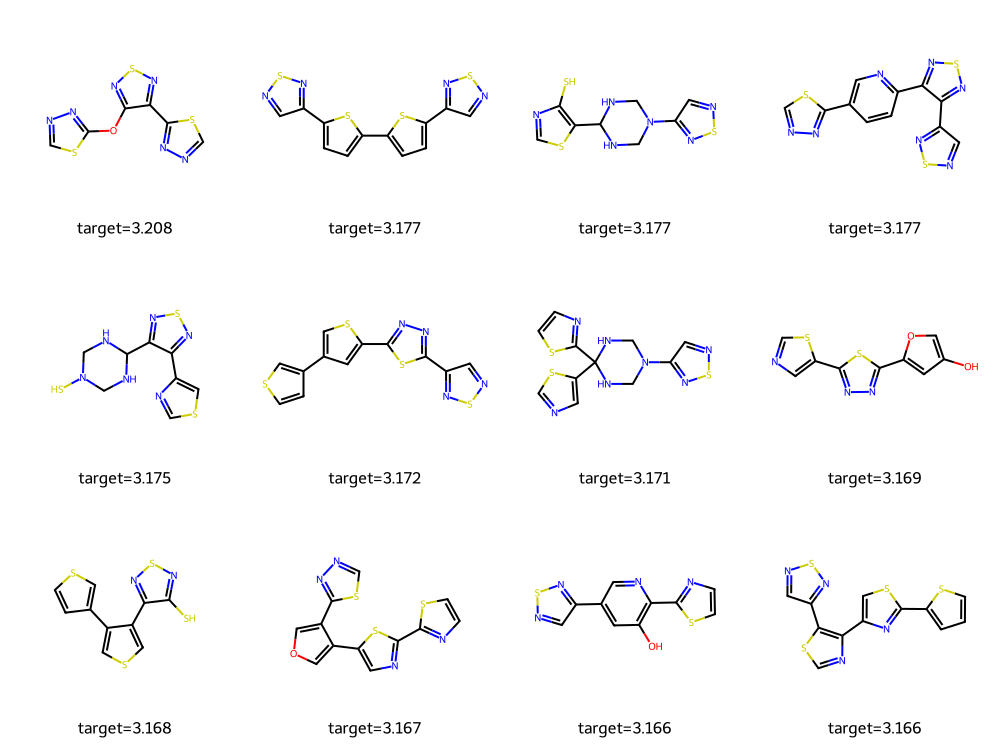

,canonical_smiles,target
0,c1nnc(Oc2nsnc2-c2nncs2)s1,3.208127
1,c1nsnc1-c1ccc(-c2ccc(-c3cnsn3)s2)s1,3.177291
2,Sc1ncsc1C1NCN(c2cnsn2)CN1,3.177231
3,c1nnc(-c2ccc(-c3nsnc3-c3cnsn3)nc2)s1,3.176806
4,SN1CNC(c2nsnc2-c2cscn2)NC1,3.175367
5,c1cc(-c2csc(-c3nnc(-c4cnsn4)s3)c2)cs1,3.172130
6,c1csc(C2(c3cncs3)NCN(c3cnsn3)CN2)n1,3.170869
7,Oc1coc(-c2nnc(-c3cncs3)s2)c1,3.169378
8,Sc1nsnc1-c1cscc1-c1ccsc1,3.168359
9,c1csc(-c2ncc(-c3cocc3-c3nncs3)s2)n1,3.167031


In [77]:
# @title 2A. Preview curated molecules { display-mode: "form" }
preview_molecules = 12 # @param {type:"slider", min:4, max:20, step:1}
preview_selection_mode = "Highest target values" # @param ["Highest target values", "Lowest target values", "Random sample", "Dataset order"]

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'preview_molecules', 'label': 'preview molecules', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 20, 'step': 1}, {'name': 'preview_selection_mode', 'label': 'preview selection mode', 'widget_kind': 'choice', 'default': 'Highest target values', 'options': ['Highest target values', 'Lowest target values', 'Random sample', 'Dataset order']}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '71f20340'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('2A. Preview curated molecules', '71f20340', [{'name': 'preview_molecules', 'label': 'preview molecules', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 20, 'step': 1}, {'name': 'preview_selection_mode', 'label': 'preview selection mode', 'widget_kind': 'choice', 'default': 'Highest target values', 'options': ['Highest target values', 'Lowest target values', 'Random sample', 'Dataset order']}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('71f20340', [{'name': 'preview_molecules', 'label': 'preview molecules', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 20, 'step': 1}, {'name': 'preview_selection_mode', 'label': 'preview selection mode', 'widget_kind': 'choice', 'default': 'Highest target values', 'options': ['Highest target values', 'Lowest target values', 'Random sample', 'Dataset order']}])
    preview_molecules = _local_form_values['preview_molecules']
    preview_selection_mode = _local_form_values['preview_selection_mode']

if "curated_df" not in STATE:
    raise RuntimeError("Please run the curation cell first.")

curated_df = STATE["curated_df"].copy()
preview_count = min(int(preview_molecules), len(curated_df))
if preview_selection_mode == "Highest target values":
    preview_df = curated_df.sort_values("target", ascending=False).head(preview_count).reset_index(drop=True)
elif preview_selection_mode == "Lowest target values":
    preview_df = curated_df.sort_values("target", ascending=True).head(preview_count).reset_index(drop=True)
elif preview_selection_mode == "Random sample":
    preview_df = curated_df.sample(preview_count, random_state=42).reset_index(drop=True)
else:
    preview_df = curated_df.head(preview_count).reset_index(drop=True)
legends = [f"target={value:.3f}" for value in preview_df["target"]]
try:
    from rdkit.Chem import Draw
    display(Draw.MolsToGridImage(preview_df["rdkit_mol"].tolist(), legends=legends, molsPerRow=4, subImgSize=(250, 250), useSVG=False))
except Exception as exc:
    print(f"Molecule preview skipped because RDKit drawing support is unavailable: {exc}")
display(preview_df[["canonical_smiles", "target"]])


### 2B. Generate Molecular Features

Select one or more molecular feature families below. Checking every box is the equivalent of an "all descriptors" representation.

**Avalon note:** there is no separate Avalon checkbox because Avalon-count fingerprints are already included inside **MapLight classic** (`maplight` family), alongside Morgan-count, ErG, and MapLight descriptor blocks.

This block now uses a persistent molecular feature store by default. The store is an append-only Parquet layout that keeps previously generated feature rows keyed by:

- canonical SMILES
- selected feature families
- fingerprint settings relevant to those families

Internally, each representation gets its own folder with:

- a schema file describing the feature columns
- append-only Parquet shard files for newly generated rows

When you rerun feature generation, the notebook first checks that store. Existing rows are loaded immediately, and only missing rows are newly generated and appended to the store.


In [78]:
# Local widget controls for: 2B. Generate molecular features
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('2B. Generate molecular features', '7cd52ba2', [{'name': 'use_morgan_features', 'label': 'use morgan features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_ecfp6_features', 'label': 'use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_fcfp6_features', 'label': 'use fcfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_layered_features', 'label': 'use layered features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_atom_pair_features', 'label': 'use atom pair features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_topological_torsion_features', 'label': 'use topological torsion features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdk_path_features', 'label': 'use rdk path features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maccs_keys', 'label': 'use maccs keys', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdkit_descriptors', 'label': 'use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maplight_classic', 'label': 'use maplight classic', 'widget_kind': 'boolean', 'default': True}, {'name': 'morgan_radius', 'label': 'morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'fingerprint_bits', 'label': 'fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'enable_persistent_feature_store', 'label': 'enable persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_persistent_feature_store', 'label': 'reuse persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'persistent_feature_store_path', 'label': 'persistent feature store path', 'widget_kind': 'string', 'default': 'AUTO'}])


In [79]:
# @title 2B. Generate molecular features { display-mode: "form" }
use_morgan_features = True # @param {type:"boolean"}
use_ecfp6_features = True # @param {type:"boolean"}
use_fcfp6_features = True # @param {type:"boolean"}
use_layered_features = True # @param {type:"boolean"}
use_atom_pair_features = True # @param {type:"boolean"}
use_topological_torsion_features = True # @param {type:"boolean"}
use_rdk_path_features = True # @param {type:"boolean"}
use_maccs_keys = True # @param {type:"boolean"}
use_rdkit_descriptors = True # @param {type:"boolean"}
# MapLight classic includes Avalon-count fingerprints (`avalon_count_*`) plus Morgan-count, ErG, and descriptor features.
use_maplight_classic = True # @param {type:"boolean"}
morgan_radius = 2 # @param {type:"slider", min:1, max:4, step:1}
fingerprint_bits = "1024" # @param ["256", "512", "1024", "2048"]
enable_persistent_feature_store = True # @param {type:"boolean"}
reuse_persistent_feature_store = True # @param {type:"boolean"}
persistent_feature_store_path = "AUTO" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'use_morgan_features', 'label': 'use morgan features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_ecfp6_features', 'label': 'use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_fcfp6_features', 'label': 'use fcfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_layered_features', 'label': 'use layered features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_atom_pair_features', 'label': 'use atom pair features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_topological_torsion_features', 'label': 'use topological torsion features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdk_path_features', 'label': 'use rdk path features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maccs_keys', 'label': 'use maccs keys', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdkit_descriptors', 'label': 'use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maplight_classic', 'label': 'use maplight classic', 'widget_kind': 'boolean', 'default': True}, {'name': 'morgan_radius', 'label': 'morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'fingerprint_bits', 'label': 'fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'enable_persistent_feature_store', 'label': 'enable persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_persistent_feature_store', 'label': 'reuse persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'persistent_feature_store_path', 'label': 'persistent feature store path', 'widget_kind': 'string', 'default': 'AUTO'}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '7cd52ba2'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('2B. Generate molecular features', '7cd52ba2', [{'name': 'use_morgan_features', 'label': 'use morgan features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_ecfp6_features', 'label': 'use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_fcfp6_features', 'label': 'use fcfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_layered_features', 'label': 'use layered features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_atom_pair_features', 'label': 'use atom pair features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_topological_torsion_features', 'label': 'use topological torsion features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdk_path_features', 'label': 'use rdk path features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maccs_keys', 'label': 'use maccs keys', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdkit_descriptors', 'label': 'use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maplight_classic', 'label': 'use maplight classic', 'widget_kind': 'boolean', 'default': True}, {'name': 'morgan_radius', 'label': 'morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'fingerprint_bits', 'label': 'fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'enable_persistent_feature_store', 'label': 'enable persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_persistent_feature_store', 'label': 'reuse persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'persistent_feature_store_path', 'label': 'persistent feature store path', 'widget_kind': 'string', 'default': 'AUTO'}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('7cd52ba2', [{'name': 'use_morgan_features', 'label': 'use morgan features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_ecfp6_features', 'label': 'use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_fcfp6_features', 'label': 'use fcfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_layered_features', 'label': 'use layered features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_atom_pair_features', 'label': 'use atom pair features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_topological_torsion_features', 'label': 'use topological torsion features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdk_path_features', 'label': 'use rdk path features', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maccs_keys', 'label': 'use maccs keys', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_rdkit_descriptors', 'label': 'use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'use_maplight_classic', 'label': 'use maplight classic', 'widget_kind': 'boolean', 'default': True}, {'name': 'morgan_radius', 'label': 'morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'fingerprint_bits', 'label': 'fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'enable_persistent_feature_store', 'label': 'enable persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_persistent_feature_store', 'label': 'reuse persistent feature store', 'widget_kind': 'boolean', 'default': True}, {'name': 'persistent_feature_store_path', 'label': 'persistent feature store path', 'widget_kind': 'string', 'default': 'AUTO'}])
    use_morgan_features = _local_form_values['use_morgan_features']
    use_ecfp6_features = _local_form_values['use_ecfp6_features']
    use_fcfp6_features = _local_form_values['use_fcfp6_features']
    use_layered_features = _local_form_values['use_layered_features']
    use_atom_pair_features = _local_form_values['use_atom_pair_features']
    use_topological_torsion_features = _local_form_values['use_topological_torsion_features']
    use_rdk_path_features = _local_form_values['use_rdk_path_features']
    use_maccs_keys = _local_form_values['use_maccs_keys']
    use_rdkit_descriptors = _local_form_values['use_rdkit_descriptors']
    use_maplight_classic = _local_form_values['use_maplight_classic']
    morgan_radius = _local_form_values['morgan_radius']
    fingerprint_bits = _local_form_values['fingerprint_bits']
    enable_persistent_feature_store = _local_form_values['enable_persistent_feature_store']
    reuse_persistent_feature_store = _local_form_values['reuse_persistent_feature_store']
    persistent_feature_store_path = _local_form_values['persistent_feature_store_path']

if "curated_df" not in STATE:
    raise RuntimeError("Please run the curation cell first.")

curated_df = STATE["curated_df"].copy()
selected_feature_families = normalize_selected_feature_families(
    use_morgan_features=use_morgan_features,
    use_ecfp6_features=use_ecfp6_features,
    use_fcfp6_features=use_fcfp6_features,
    use_layered_features=use_layered_features,
    use_atom_pair_features=use_atom_pair_features,
    use_topological_torsion_features=use_topological_torsion_features,
    use_rdk_path_features=use_rdk_path_features,
    use_maccs_keys=use_maccs_keys,
    use_rdkit_descriptors=use_rdkit_descriptors,
    use_maplight_classic=use_maplight_classic,
)
if not selected_feature_families and bool(use_maplight_classic):
    selected_feature_families = ["maplight"]
if not selected_feature_families:
    raise ValueError("Please select at least one molecular feature family.")

try:
    X, build_info = build_feature_matrix_from_smiles(
        curated_df["canonical_smiles"].tolist(),
        selected_feature_families=selected_feature_families,
        radius=int(morgan_radius),
        n_bits=int(fingerprint_bits),
        enable_persistent_feature_store=bool(enable_persistent_feature_store),
        reuse_persistent_feature_store=bool(reuse_persistent_feature_store),
        persistent_feature_store_path=str(persistent_feature_store_path),
    )
except Exception as exc:
    raise RuntimeError(
        "Could not build the selected molecular representation. "
        f"{exc}"
    ) from exc

auxiliary_columns = list(STATE.get("auxiliary_columns", []))
aux_feature_df = build_auxiliary_feature_matrix(curated_df, auxiliary_columns)
if not aux_feature_df.empty:
    X = pd.concat([X.reset_index(drop=True), aux_feature_df.reset_index(drop=True)], axis=1)

for warning_text in build_info["warnings"]:
    print(f"Warning: {warning_text}")

STATE["feature_matrix"] = X.copy()
STATE["unfiltered_feature_matrix"] = X.copy()
STATE["feature_names"] = list(X.columns)
STATE["auxiliary_feature_columns"] = list(aux_feature_df.columns) if not aux_feature_df.empty else []
STATE["fingerprint_radius"] = int(morgan_radius)
STATE["fingerprint_bits"] = int(fingerprint_bits)
STATE["selected_feature_families"] = list(build_info["selected_feature_families"])
STATE["built_feature_families"] = list(build_info["built_feature_families"])
STATE["skipped_feature_families"] = list(build_info["skipped_feature_families"])
STATE["molecular_feature_store_path"] = build_info.get("feature_store_path", "")
STATE["molecular_feature_store_representation_key"] = build_info.get("representation_key")
STATE["lasso_feature_selection_summary"] = {}
STATE["feature_builder_config"] = {
    "selected_feature_families": list(build_info["selected_feature_families"]),
    "built_feature_families": list(build_info["built_feature_families"]),
    "skipped_feature_families": list(build_info["skipped_feature_families"]),
    "fingerprint_radius": int(morgan_radius),
    "fingerprint_bits": int(fingerprint_bits),
    "enable_persistent_feature_store": bool(enable_persistent_feature_store),
    "reuse_persistent_feature_store": bool(reuse_persistent_feature_store),
    "persistent_feature_store_path": build_info.get("feature_store_path", str(persistent_feature_store_path)),
    "auxiliary_columns": list(auxiliary_columns),
    "auxiliary_feature_columns": list(aux_feature_df.columns) if not aux_feature_df.empty else [],
    "lasso_feature_selection_enabled": False,
    "lasso_alpha": None,
    "lasso_selected_feature_count": int(X.shape[1]),
}
STATE["representation_label"] = build_info["representation_label"]
STATE["base_representation_label"] = build_info["representation_label"]
print(f"Representation built: {STATE['representation_label']}")
print(f"Selected feature families: {', '.join(build_info['selected_feature_families'])}")
print(f"Built feature families: {', '.join(build_info['built_feature_families'])}")
if build_info["skipped_feature_families"]:
    print(f"Skipped feature families: {', '.join(build_info['skipped_feature_families'])}")
print(f"Feature matrix shape: {X.shape[0]:,} molecules x {X.shape[1]:,} features")
if auxiliary_columns:
    print(f"Auxiliary columns used: {', '.join(auxiliary_columns)}")
if bool(enable_persistent_feature_store):
    print(
        "Persistent feature store: "
        f"loaded {int(build_info.get('cached_rows_loaded', 0)):,} cached row(s), "
        f"generated and appended {int(build_info.get('generated_rows_added', 0)):,} new row(s)."
    )
    print(f"Feature store path: {build_info.get('feature_store_path', persistent_feature_store_path)}")
display(X.head(3))


Representation built: Morgan(radius=2, bits=1024) + ECFP6(bits=1024) + FCFP6(bits=1024) + RDKit layered(bits=1024) + Atom-pair(bits=1024) + Topological torsion(bits=1024) + RDKit path(bits=1024) + MACCS keys + RDKit descriptors + MapLight classic (Morgan+Avalon+ErG, bits=1024)
Selected feature families: morgan, ecfp6, fcfp6, layered, atom_pair, topological_torsion, rdk_path, maccs, rdkit, maplight
Built feature families: morgan, ecfp6, fcfp6, layered, atom_pair, topological_torsion, rdk_path, maccs, rdkit, maplight
Feature matrix shape: 500 molecules x 10,115 features
Persistent feature store: loaded 500 cached row(s), generated and appended 0 new row(s).
Feature store path: model_cache\feature_store_parquet


,morgan_bit_0000,morgan_bit_0001,morgan_bit_0002,morgan_bit_0003,morgan_bit_0004,morgan_bit_0005,morgan_bit_0006,morgan_bit_0007,morgan_bit_0008,morgan_bit_0009,...,maplight_desc_fr_sulfonamd,maplight_desc_fr_sulfone,maplight_desc_fr_term_acetylene,maplight_desc_fr_tetrazole,maplight_desc_fr_thiazole,maplight_desc_fr_thiocyan,maplight_desc_fr_thiophene,maplight_desc_fr_unbrch_alkane,maplight_desc_fr_urea,maplight_desc_qed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.681247
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.801678
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.670066


### 2D. Representation Note

`Morgan`, `ECFP6`, and `FCFP6` are all circular fingerprints:

- **Morgan** uses the user-selected radius and bit length
- **ECFP6** uses atom-identity style invariants
- **FCFP6** uses feature-based invariants
- **Layered fingerprint** captures layered path/subgraph pattern classes
- **Atom-pair** fingerprints encode atom-type pairs with topological distances
- **Topological torsion** fingerprints encode 4-atom bond paths
- **RDKit path** fingerprints capture hashed subgraph path patterns
- **MACCS** provides a compact fixed key set
- **RDKit descriptors** provide continuous physicochemical summary features

If the descriptor count becomes large relative to the number of molecules, configure the optional **train-only feature-selection** step in `2C` (placed just before `4B`). The selector is fit in `4B` after the train/test split so held-out test rows do not influence the selected feature set.


## 3. Chemical Similarity Map

Molecules that cluster together in this plot usually have more similar molecular feature profiles.


In [80]:
# Local widget controls for: 3A. Build an interactive PCA -> t-SNE map
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('3A. Build an interactive PCA -> t-SNE map', '65ad0deb', [{'name': 'tsne_use_morgan_features', 'label': 'tsne use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdkit_descriptors', 'label': 'tsne use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_ecfp6_features', 'label': 'tsne use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_fcfp6_features', 'label': 'tsne use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_layered_features', 'label': 'tsne use layered features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_atom_pair_features', 'label': 'tsne use atom pair features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_topological_torsion_features', 'label': 'tsne use topological torsion features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdk_path_features', 'label': 'tsne use rdk path features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_maccs_keys', 'label': 'tsne use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_all_descriptors', 'label': 'tsne use all descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_morgan_radius', 'label': 'tsne morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'tsne_fingerprint_bits', 'label': 'tsne fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'perplexity', 'label': 'perplexity', 'widget_kind': 'slider', 'default': 30, 'min': 5, 'max': 50, 'step': 1}, {'name': 'max_points_for_map', 'label': 'max points for map', 'widget_kind': 'slider', 'default': 1000, 'min': 100, 'max': 2000, 'step': 100}, {'name': 'embedding_random_seed', 'label': 'embedding random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_similarity_map_cache', 'label': 'enable similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_similarity_map_cache', 'label': 'reuse similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'similarity_map_cache_run_name', 'label': 'similarity map cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])


In [81]:
# @title 3A. Build an interactive PCA -> t-SNE map { display-mode: "form" }
tsne_use_morgan_features = False # @param {type:"boolean"}
tsne_use_rdkit_descriptors = True # @param {type:"boolean"}
tsne_use_ecfp6_features = True # @param {type:"boolean"}
tsne_use_fcfp6_features = False # @param {type:"boolean"}
tsne_use_layered_features = False # @param {type:"boolean"}
tsne_use_atom_pair_features = False # @param {type:"boolean"}
tsne_use_topological_torsion_features = False # @param {type:"boolean"}
tsne_use_rdk_path_features = False # @param {type:"boolean"}
tsne_use_maccs_keys = False # @param {type:"boolean"}
tsne_use_all_descriptors = False # @param {type:"boolean"}
tsne_morgan_radius = 2 # @param {type:"slider", min:1, max:4, step:1}
tsne_fingerprint_bits = "1024" # @param ["256", "512", "1024", "2048"]
perplexity = 30 # @param {type:"slider", min:5, max:50, step:1}
max_points_for_map = 1000 # @param {type:"slider", min:100, max:2000, step:100}
embedding_random_seed = 42 # @param {type:"integer"}
enable_similarity_map_cache = True # @param {type:"boolean"}
reuse_similarity_map_cache = True # @param {type:"boolean"}
similarity_map_cache_run_name = "AUTO" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'tsne_use_morgan_features', 'label': 'tsne use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdkit_descriptors', 'label': 'tsne use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_ecfp6_features', 'label': 'tsne use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_fcfp6_features', 'label': 'tsne use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_layered_features', 'label': 'tsne use layered features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_atom_pair_features', 'label': 'tsne use atom pair features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_topological_torsion_features', 'label': 'tsne use topological torsion features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdk_path_features', 'label': 'tsne use rdk path features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_maccs_keys', 'label': 'tsne use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_all_descriptors', 'label': 'tsne use all descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_morgan_radius', 'label': 'tsne morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'tsne_fingerprint_bits', 'label': 'tsne fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'perplexity', 'label': 'perplexity', 'widget_kind': 'slider', 'default': 30, 'min': 5, 'max': 50, 'step': 1}, {'name': 'max_points_for_map', 'label': 'max points for map', 'widget_kind': 'slider', 'default': 1000, 'min': 100, 'max': 2000, 'step': 100}, {'name': 'embedding_random_seed', 'label': 'embedding random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_similarity_map_cache', 'label': 'enable similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_similarity_map_cache', 'label': 'reuse similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'similarity_map_cache_run_name', 'label': 'similarity map cache run name', 'widget_kind': 'string', 'default': 'AUTO'}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '65ad0deb'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('3A. Build an interactive PCA -> t-SNE map', '65ad0deb', [{'name': 'tsne_use_morgan_features', 'label': 'tsne use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdkit_descriptors', 'label': 'tsne use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_ecfp6_features', 'label': 'tsne use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_fcfp6_features', 'label': 'tsne use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_layered_features', 'label': 'tsne use layered features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_atom_pair_features', 'label': 'tsne use atom pair features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_topological_torsion_features', 'label': 'tsne use topological torsion features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdk_path_features', 'label': 'tsne use rdk path features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_maccs_keys', 'label': 'tsne use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_all_descriptors', 'label': 'tsne use all descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_morgan_radius', 'label': 'tsne morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'tsne_fingerprint_bits', 'label': 'tsne fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'perplexity', 'label': 'perplexity', 'widget_kind': 'slider', 'default': 30, 'min': 5, 'max': 50, 'step': 1}, {'name': 'max_points_for_map', 'label': 'max points for map', 'widget_kind': 'slider', 'default': 1000, 'min': 100, 'max': 2000, 'step': 100}, {'name': 'embedding_random_seed', 'label': 'embedding random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_similarity_map_cache', 'label': 'enable similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_similarity_map_cache', 'label': 'reuse similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'similarity_map_cache_run_name', 'label': 'similarity map cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('65ad0deb', [{'name': 'tsne_use_morgan_features', 'label': 'tsne use morgan features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdkit_descriptors', 'label': 'tsne use rdkit descriptors', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_ecfp6_features', 'label': 'tsne use ecfp6 features', 'widget_kind': 'boolean', 'default': True}, {'name': 'tsne_use_fcfp6_features', 'label': 'tsne use fcfp6 features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_layered_features', 'label': 'tsne use layered features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_atom_pair_features', 'label': 'tsne use atom pair features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_topological_torsion_features', 'label': 'tsne use topological torsion features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_rdk_path_features', 'label': 'tsne use rdk path features', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_maccs_keys', 'label': 'tsne use maccs keys', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_use_all_descriptors', 'label': 'tsne use all descriptors', 'widget_kind': 'boolean', 'default': False}, {'name': 'tsne_morgan_radius', 'label': 'tsne morgan radius', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'tsne_fingerprint_bits', 'label': 'tsne fingerprint bits', 'widget_kind': 'choice', 'default': '1024', 'options': ['256', '512', '1024', '2048']}, {'name': 'perplexity', 'label': 'perplexity', 'widget_kind': 'slider', 'default': 30, 'min': 5, 'max': 50, 'step': 1}, {'name': 'max_points_for_map', 'label': 'max points for map', 'widget_kind': 'slider', 'default': 1000, 'min': 100, 'max': 2000, 'step': 100}, {'name': 'embedding_random_seed', 'label': 'embedding random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_similarity_map_cache', 'label': 'enable similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_similarity_map_cache', 'label': 'reuse similarity map cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'similarity_map_cache_run_name', 'label': 'similarity map cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
    tsne_use_morgan_features = _local_form_values['tsne_use_morgan_features']
    tsne_use_rdkit_descriptors = _local_form_values['tsne_use_rdkit_descriptors']
    tsne_use_ecfp6_features = _local_form_values['tsne_use_ecfp6_features']
    tsne_use_fcfp6_features = _local_form_values['tsne_use_fcfp6_features']
    tsne_use_layered_features = _local_form_values['tsne_use_layered_features']
    tsne_use_atom_pair_features = _local_form_values['tsne_use_atom_pair_features']
    tsne_use_topological_torsion_features = _local_form_values['tsne_use_topological_torsion_features']
    tsne_use_rdk_path_features = _local_form_values['tsne_use_rdk_path_features']
    tsne_use_maccs_keys = _local_form_values['tsne_use_maccs_keys']
    tsne_use_all_descriptors = _local_form_values['tsne_use_all_descriptors']
    tsne_morgan_radius = _local_form_values['tsne_morgan_radius']
    tsne_fingerprint_bits = _local_form_values['tsne_fingerprint_bits']
    perplexity = _local_form_values['perplexity']
    max_points_for_map = _local_form_values['max_points_for_map']
    embedding_random_seed = _local_form_values['embedding_random_seed']
    enable_similarity_map_cache = _local_form_values['enable_similarity_map_cache']
    reuse_similarity_map_cache = _local_form_values['reuse_similarity_map_cache']
    similarity_map_cache_run_name = _local_form_values['similarity_map_cache_run_name']

if "curated_df" not in STATE:
    raise RuntimeError("Please run the curation cell first.")

curated_df = STATE["curated_df"].copy()
if len(curated_df) < 6:
    raise ValueError("Please provide at least 6 valid molecules before building the similarity map.")
if len(curated_df) > max_points_for_map:
    sampled = curated_df.sample(max_points_for_map, random_state=int(embedding_random_seed)).index
    plot_df = curated_df.loc[sampled].reset_index(drop=True)
else:
    plot_df = curated_df.reset_index(drop=True)
sampled_smiles = plot_df["canonical_smiles"].astype(str).reset_index(drop=True)
selected_map_options = []
if tsne_use_morgan_features:
    selected_map_options.append(("Morgan fingerprints", ["morgan"]))
if tsne_use_rdkit_descriptors:
    selected_map_options.append(("RDKit descriptors", ["rdkit"]))
if tsne_use_ecfp6_features:
    selected_map_options.append(("ECFP6 fingerprints", ["ecfp6"]))
if tsne_use_fcfp6_features:
    selected_map_options.append(("FCFP6 fingerprints", ["fcfp6"]))
if tsne_use_layered_features:
    selected_map_options.append(("RDKit layered fingerprints", ["layered"]))
if tsne_use_atom_pair_features:
    selected_map_options.append(("Atom-pair fingerprints", ["atom_pair"]))
if tsne_use_topological_torsion_features:
    selected_map_options.append(("Topological torsion fingerprints", ["topological_torsion"]))
if tsne_use_rdk_path_features:
    selected_map_options.append(("RDKit path fingerprints", ["rdk_path"]))
if tsne_use_maccs_keys:
    selected_map_options.append(("MACCS keys", ["maccs"]))
if tsne_use_all_descriptors:
    selected_map_options.append(
        (
            "All descriptors",
            [
                "morgan",
                "ecfp6",
                "fcfp6",
                "layered",
                "atom_pair",
                "topological_torsion",
                "rdk_path",
                "maccs",
                "rdkit",
            ],
        )
    )
if not selected_map_options:
    raise ValueError("Please select at least one descriptor option for the similarity map.")

similarity_map_cache_dir = None
similarity_map_results = {}
similarity_map_cache_paths = {}
total_steps = max(1, len(selected_map_options) * 4)
progress = tqdm(total=total_steps, desc="Similarity map", leave=False)
if enable_similarity_map_cache:
    similarity_map_cache_dir = resolve_model_cache_dir(
        "similarity_map",
        similarity_map_cache_run_name,
        prefer_existing=bool(reuse_similarity_map_cache),
    )
    print(f"Similarity map cache directory: {similarity_map_cache_dir}")

for map_label, map_families in selected_map_options:
    progress.set_postfix_str(f"Building features: {map_label}")
    feature_df, build_info = build_feature_matrix_from_smiles(
        sampled_smiles.tolist(),
        selected_feature_families=map_families,
        radius=int(tsne_morgan_radius),
        n_bits=int(tsne_fingerprint_bits),
    )
    progress.update(1)

    tsne_perplexity = min(int(perplexity), max(2, len(feature_df) - 1))
    n_pca = min(50, feature_df.shape[1], max(2, feature_df.shape[0] - 1))
    map_df = None
    cache_key = slugify_cache_text(map_label)

    if enable_similarity_map_cache and reuse_similarity_map_cache and similarity_map_cache_dir is not None:
        metadata_candidates = sorted(
            similarity_map_cache_dir.glob(f"*_{cache_key}_similarity_map_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "workflow": "Similarity map",
                    "dataset_label": current_dataset_cache_label(),
                    "representation_label": build_info["representation_label"],
                    "feature_families": list(map_families),
                    "morgan_radius": int(tsne_morgan_radius),
                    "n_rows": len(feature_df),
                    "n_features": feature_df.shape[1],
                    "perplexity": tsne_perplexity,
                    "max_points_for_map": int(max_points_for_map),
                    "embedding_random_seed": int(embedding_random_seed),
                    "n_pca": int(n_pca),
                    "fingerprint_bits": int(tsne_fingerprint_bits),
                }
                if not cache_metadata_matches(metadata, expected_metadata):
                    continue
                map_path = Path(metadata["map_path"])
                if not map_path.exists():
                    continue
                cached_map_df = pd.read_csv(map_path)
                if len(cached_map_df) != len(sampled_smiles):
                    continue
                if not cached_map_df["canonical_smiles"].astype(str).reset_index(drop=True).equals(sampled_smiles):
                    continue
                map_df = cached_map_df.copy()
                similarity_map_cache_paths[map_label] = {
                    "map_path": str(map_path),
                    "metadata_path": str(metadata_path),
                }
                print(f"Loaded cached similarity map for {map_label} from {map_path.parent}", flush=True)
                break
            except Exception:
                continue
    progress.update(1)

    if map_df is None:
        progress.set_postfix_str(f"Running PCA/t-SNE: {map_label}")
        embedding_feature_df = feature_df.copy()
        embedding_feature_df = embedding_feature_df.replace([np.inf, -np.inf], np.nan)
        embedding_feature_df = embedding_feature_df.apply(pd.to_numeric, errors="coerce")
        float64_limit = np.finfo(np.float64).max / 1000.0
        embedding_feature_df = embedding_feature_df.mask(embedding_feature_df.abs() > float64_limit, np.nan)
        embedding_feature_df = embedding_feature_df.fillna(embedding_feature_df.median(numeric_only=True))
        embedding_feature_df = embedding_feature_df.fillna(0.0)
        embedding_matrix = StandardScaler().fit_transform(embedding_feature_df.to_numpy(dtype=np.float64))
        pca_scores = PCA(n_components=n_pca, random_state=int(embedding_random_seed)).fit_transform(embedding_matrix)
        tsne_scores = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=int(embedding_random_seed),
        ).fit_transform(pca_scores)
        map_df = plot_df[["canonical_smiles", "target"]].copy()
        map_df["PCA_tSNE_1"] = tsne_scores[:, 0]
        map_df["PCA_tSNE_2"] = tsne_scores[:, 1]
        progress.update(1)

        if enable_similarity_map_cache and similarity_map_cache_dir is not None:
            artifact_base = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_{cache_key}_similarity_map"
            map_path = similarity_map_cache_dir / f"{artifact_base}.csv"
            metadata_path = similarity_map_cache_dir / f"{artifact_base}_metadata.json"
            map_df.to_csv(map_path, index=False)
            write_cache_metadata(
                metadata_path,
                {
                    "workflow": "Similarity map",
                    "dataset_label": current_dataset_cache_label(),
                    "representation_label": build_info["representation_label"],
                    "feature_families": list(map_families),
                    "morgan_radius": int(tsne_morgan_radius),
                    "n_rows": len(feature_df),
                    "n_features": feature_df.shape[1],
                    "perplexity": tsne_perplexity,
                    "max_points_for_map": int(max_points_for_map),
                    "embedding_random_seed": int(embedding_random_seed),
                    "n_pca": int(n_pca),
                    "fingerprint_bits": int(tsne_fingerprint_bits),
                    "cache_run_name": similarity_map_cache_dir.name,
                    "map_path": str(map_path),
                },
            )
            similarity_map_cache_paths[map_label] = {
                "map_path": str(map_path),
                "metadata_path": str(metadata_path),
            }
    else:
        progress.update(1)

    fig = px.scatter(
        map_df,
        x="PCA_tSNE_1",
        y="PCA_tSNE_2",
        color="target",
        hover_data={"canonical_smiles": True, "target": ":.4f"},
        title=f"Chemical similarity map ({map_label} -> PCA -> t-SNE)",
        color_continuous_scale="Viridis",
    )
    fig.update_layout(height=600)
    show_plotly(fig)
    similarity_map_results[map_label] = {
        "map_df": map_df.copy(),
        "feature_families": list(map_families),
        "representation_label": build_info["representation_label"],
    }
    progress.update(1)

STATE["similarity_map_results"] = similarity_map_results
if similarity_map_results:
    first_label = next(iter(similarity_map_results))
    STATE["similarity_map_df"] = similarity_map_results[first_label]["map_df"].copy()
if similarity_map_cache_paths:
    STATE["similarity_map_cache_paths"] = similarity_map_cache_paths
if similarity_map_cache_dir is not None:
    STATE["similarity_map_cache_dir"] = str(similarity_map_cache_dir)
progress.set_postfix_str("Done")
progress.close()


Similarity map:   0%|          | 0/8 [00:00<?, ?it/s]

Similarity map cache directory: C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\similarity_map\20260427_155200_ChemML_bundled_dataset_organic_density_similarity_map
Loaded cached similarity map for RDKit descriptors from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\similarity_map\20260427_155200_ChemML_bundled_dataset_organic_density_similarity_map


Loaded cached similarity map for ECFP6 fingerprints from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\similarity_map\20260427_155200_ChemML_bundled_dataset_organic_density_similarity_map


## 4. Conventional QSAR Models

This section follows the same broad modeling logic used throughout the repository:

- build a numerical representation from SMILES
- split data into training and test sets
- optionally run the train-only feature selector configured in `2C`
- use scaling where the model benefits from it
- compare several algorithms with the **same split**
- judge the final models by both cross-validation and held-out test performance

The selector follows the stronger pattern from the QSAR references in `refs/`: split first, fit feature selection on the training data only, then evaluate the selected representation on held-out test data.

**Local Jupyter / VS Code note:** widget controls appear in the separate `Local widget controls for...` cell immediately before each runnable block. Run that controls cell first, adjust the widgets, then run the following block. In Google Colab, the `# @param` controls appear directly in the runnable block.


In [82]:
# Local widget controls for: 4A. Split train/test data
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('4A. Split train/test data', '04036e76', [{'name': 'data_split_strategy', 'label': 'data split strategy', 'widget_kind': 'choice', 'default': 'target_quartiles', 'options': ['random', 'target_quartiles', 'scaffold', 'predefined']}, {'name': 'test_fraction', 'label': 'test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}])


In [83]:
# @title 4A. Split train/test data { display-mode: "form" }
data_split_strategy = "target_quartiles" # @param ["random", "target_quartiles", "scaffold", "predefined"]
test_fraction = 0.2 # @param {type:"slider", min:0.1, max:0.4, step:0.05}
model_random_seed = 42 # @param {type:"integer"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'data_split_strategy', 'label': 'data split strategy', 'widget_kind': 'choice', 'default': 'target_quartiles', 'options': ['random', 'target_quartiles', 'scaffold', 'predefined']}, {'name': 'test_fraction', 'label': 'test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '04036e76'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('4A. Split train/test data', '04036e76', [{'name': 'data_split_strategy', 'label': 'data split strategy', 'widget_kind': 'choice', 'default': 'target_quartiles', 'options': ['random', 'target_quartiles', 'scaffold', 'predefined']}, {'name': 'test_fraction', 'label': 'test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('04036e76', [{'name': 'data_split_strategy', 'label': 'data split strategy', 'widget_kind': 'choice', 'default': 'target_quartiles', 'options': ['random', 'target_quartiles', 'scaffold', 'predefined']}, {'name': 'test_fraction', 'label': 'test fraction', 'widget_kind': 'slider', 'default': 0.2, 'min': 0.1, 'max': 0.4, 'step': 0.05}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}])
    data_split_strategy = _local_form_values['data_split_strategy']
    test_fraction = _local_form_values['test_fraction']
    model_random_seed = _local_form_values['model_random_seed']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

recommended_split_strategy = str(STATE.get("recommended_split_strategy", "")).strip().lower()
if (
    recommended_split_strategy in {"random", "target_quartiles", "scaffold", "predefined"}
    and str(data_split_strategy).strip().lower() == "target_quartiles"
):
    data_split_strategy = recommended_split_strategy

split_payload = apply_qsar_split(
    split_strategy=str(data_split_strategy),
    test_fraction=float(test_fraction),
    random_seed=int(model_random_seed),
    announce=True,
)
data_split_strategy = str(STATE.get("model_split_strategy", data_split_strategy))
test_fraction = float(STATE.get("model_test_fraction", test_fraction))
X_train = split_payload["X_train"]
X_test = split_payload["X_test"]
y_train = pd.Series(split_payload["y_train"], dtype=float)
y_test = pd.Series(split_payload["y_test"], dtype=float)
smiles_train = split_payload["smiles_train"]
smiles_test = split_payload["smiles_test"]
plot_train_test_target_distribution(
    y_train,
    y_test,
    split_strategy=str(data_split_strategy),
)

STATE["X_train_unselected"] = X_train.copy()
STATE["X_test_unselected"] = X_test.copy()
STATE["y_train_unselected"] = y_train.to_numpy(dtype=float)
STATE["y_test_unselected"] = y_test.to_numpy(dtype=float)
STATE["smiles_train_unselected"] = smiles_train.reset_index(drop=True)
STATE["smiles_test_unselected"] = smiles_test.reset_index(drop=True)
STATE["split_random_seed"] = int(model_random_seed)
STATE["split_strategy"] = str(data_split_strategy)
STATE["split_test_fraction"] = float(test_fraction)
STATE["traditional_feature_metadata"] = current_feature_metadata()

print(
    f"Saved raw train/test split: {X_train.shape[0]:,} train row(s), "
    f"{X_test.shape[0]:,} test row(s), {X_train.shape[1]:,} feature(s) before selection."
)
display_note("Configure selector settings in `2C` (now placed here), then run `4B` to fit or load the train-only feature selector.")


Canonical split signature established: dataset=ChemML_bundled_dataset_organic_density, source=apply_qsar_split(strategy=target_quartiles, test_fraction=0.20, random_seed=42), train=400, test=100
QSAR split: strategy=target_quartiles, test_fraction=0.20, random_seed=42, train=400, test=100


Saved raw train/test split: 400 train row(s), 100 test row(s), 10,115 feature(s) before selection.


Configure selector settings in `2C` (now placed here), then run `4B` to fit or load the train-only feature selector.

### 2C. Configure Train-Only Feature Selection

This configuration block is placed here so selector settings are chosen right before the selector implementation in `4B`.


In [84]:
# Local widget controls for: 2C. Configure train-only feature selection
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('2C. Configure train-only feature selection', 'cc53ba84', [{'widget_kind': 'markdown', 'label': '### Selector method'}, {'name': 'feature_selector_method', 'label': 'feature selector method', 'widget_kind': 'choice', 'default': 'elasticnet_cv', 'options': ['none', 'fixed_lasso', 'lasso_cv', 'elasticnet_cv', 'random_forest_importance']}, {'widget_kind': 'markdown', 'label': '### Fixed LASSO settings'}, {'name': 'lasso_feature_selection_alpha', 'label': 'lasso feature selection alpha', 'widget_kind': 'number', 'default': 1.0}, {'widget_kind': 'markdown', 'label': '### LassoCV and ElasticNetCV alpha grid'}, {'name': 'selector_alpha_grid_min_log10', 'label': 'selector alpha grid min log10', 'widget_kind': 'integer', 'default': -5}, {'name': 'selector_alpha_grid_max_log10', 'label': 'selector alpha grid max log10', 'widget_kind': 'integer', 'default': -1}, {'name': 'selector_alpha_grid_size', 'label': 'selector alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV l1-ratio grid'}, {'name': 'elasticnet_l1_ratio_grid', 'label': 'elasticnet l1 ratio grid', 'widget_kind': 'string', 'default': '0.3, 0.7'}, {'widget_kind': 'markdown', 'label': '### Cross-validation and convergence'}, {'name': 'selector_cv_folds', 'label': 'selector cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'lasso_coefficient_threshold', 'label': 'lasso coefficient threshold', 'widget_kind': 'number', 'default': 1e-10}, {'name': 'lasso_max_iter', 'label': 'lasso max iter', 'widget_kind': 'integer', 'default': 10000}, {'name': 'lasso_coordinate_selection', 'label': 'lasso coordinate selection', 'widget_kind': 'choice', 'default': 'cyclic coordinate updates', 'options': ['cyclic coordinate updates', 'random coordinate updates']}, {'name': 'estimate_selector_runtime', 'label': 'estimate selector runtime', 'widget_kind': 'boolean', 'default': False}, {'name': 'selector_auto_rf_by_dataset_size', 'label': 'selector auto rf by dataset size', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_auto_rf_threshold_seconds', 'label': 'selector auto rf threshold seconds', 'widget_kind': 'number', 'default': 7200.0}, {'name': 'selector_auto_rf_log10_slope', 'label': 'selector auto rf log10 slope', 'widget_kind': 'number', 'default': 1.225}, {'name': 'selector_auto_rf_log10_intercept', 'label': 'selector auto rf log10 intercept', 'widget_kind': 'number', 'default': -0.658}, {'widget_kind': 'markdown', 'label': '### Output size and diagnostics'}, {'name': 'max_selected_features', 'label': 'max selected features', 'widget_kind': 'integer', 'default': 512}, {'name': 'random_forest_selector_trees', 'label': 'random forest selector trees', 'widget_kind': 'integer', 'default': 500}, {'name': 'show_lasso_coefficient_diagnostics', 'label': 'show lasso coefficient diagnostics', 'widget_kind': 'boolean', 'default': True}, {'name': 'top_lasso_coefficients_to_show', 'label': 'top lasso coefficients to show', 'widget_kind': 'slider', 'default': 30, 'min': 10, 'max': 50, 'step': 5}, {'widget_kind': 'markdown', 'label': '### Selector cache'}, {'name': 'enable_feature_selector_cache', 'label': 'enable feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_feature_selector_cache', 'label': 'reuse feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_cache_run_name', 'label': 'selector cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])


In [85]:
# @title 2C. Configure train-only feature selection { display-mode: "form" }
# @markdown ### Selector method
feature_selector_method = "elasticnet_cv" # @param ["none", "fixed_lasso", "lasso_cv", "elasticnet_cv", "random_forest_importance"]
# @markdown ### Fixed LASSO settings
lasso_feature_selection_alpha = 1.0 # @param {type:"number"}
# @markdown ### LassoCV and ElasticNetCV alpha grid
selector_alpha_grid_min_log10 = -5 # @param {type:"integer"}
selector_alpha_grid_max_log10 = -1 # @param {type:"integer"}
selector_alpha_grid_size = 12 # @param {type:"slider", min:6, max:80, step:1}
# @markdown ### ElasticNetCV l1-ratio grid
elasticnet_l1_ratio_grid = "0.3, 0.7" # @param {type:"string"}
# @markdown ### Cross-validation and convergence
selector_cv_folds = 3 # @param [3, 5, 10]
lasso_coefficient_threshold = 1e-10 # @param {type:"number"}
lasso_max_iter = 10000 # @param {type:"integer"}
lasso_coordinate_selection = "cyclic coordinate updates" # @param ["cyclic coordinate updates", "random coordinate updates"]
estimate_selector_runtime = False # @param {type:"boolean"}
selector_auto_rf_by_dataset_size = True # @param {type:"boolean"}
selector_auto_rf_threshold_seconds = 7200.0 # @param {type:"number"}
selector_auto_rf_log10_slope = 1.225 # @param {type:"number"}
selector_auto_rf_log10_intercept = -0.658 # @param {type:"number"}
# @markdown ### Output size and diagnostics
max_selected_features = 512 # @param {type:"integer"}
random_forest_selector_trees = 500 # @param {type:"integer"}
show_lasso_coefficient_diagnostics = True # @param {type:"boolean"}
top_lasso_coefficients_to_show = 30 # @param {type:"slider", min:10, max:50, step:5}
# @markdown ### Selector cache
enable_feature_selector_cache = True # @param {type:"boolean"}
reuse_feature_selector_cache = True # @param {type:"boolean"}
selector_cache_run_name = "AUTO" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'widget_kind': 'markdown', 'label': '### Selector method'}, {'name': 'feature_selector_method', 'label': 'feature selector method', 'widget_kind': 'choice', 'default': 'elasticnet_cv', 'options': ['none', 'fixed_lasso', 'lasso_cv', 'elasticnet_cv', 'random_forest_importance']}, {'widget_kind': 'markdown', 'label': '### Fixed LASSO settings'}, {'name': 'lasso_feature_selection_alpha', 'label': 'lasso feature selection alpha', 'widget_kind': 'number', 'default': 1.0}, {'widget_kind': 'markdown', 'label': '### LassoCV and ElasticNetCV alpha grid'}, {'name': 'selector_alpha_grid_min_log10', 'label': 'selector alpha grid min log10', 'widget_kind': 'integer', 'default': -5}, {'name': 'selector_alpha_grid_max_log10', 'label': 'selector alpha grid max log10', 'widget_kind': 'integer', 'default': -1}, {'name': 'selector_alpha_grid_size', 'label': 'selector alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV l1-ratio grid'}, {'name': 'elasticnet_l1_ratio_grid', 'label': 'elasticnet l1 ratio grid', 'widget_kind': 'string', 'default': '0.3, 0.7'}, {'widget_kind': 'markdown', 'label': '### Cross-validation and convergence'}, {'name': 'selector_cv_folds', 'label': 'selector cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'lasso_coefficient_threshold', 'label': 'lasso coefficient threshold', 'widget_kind': 'number', 'default': 1e-10}, {'name': 'lasso_max_iter', 'label': 'lasso max iter', 'widget_kind': 'integer', 'default': 10000}, {'name': 'lasso_coordinate_selection', 'label': 'lasso coordinate selection', 'widget_kind': 'choice', 'default': 'cyclic coordinate updates', 'options': ['cyclic coordinate updates', 'random coordinate updates']}, {'name': 'estimate_selector_runtime', 'label': 'estimate selector runtime', 'widget_kind': 'boolean', 'default': False}, {'name': 'selector_auto_rf_by_dataset_size', 'label': 'selector auto rf by dataset size', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_auto_rf_threshold_seconds', 'label': 'selector auto rf threshold seconds', 'widget_kind': 'number', 'default': 7200.0}, {'name': 'selector_auto_rf_log10_slope', 'label': 'selector auto rf log10 slope', 'widget_kind': 'number', 'default': 1.225}, {'name': 'selector_auto_rf_log10_intercept', 'label': 'selector auto rf log10 intercept', 'widget_kind': 'number', 'default': -0.658}, {'widget_kind': 'markdown', 'label': '### Output size and diagnostics'}, {'name': 'max_selected_features', 'label': 'max selected features', 'widget_kind': 'integer', 'default': 512}, {'name': 'random_forest_selector_trees', 'label': 'random forest selector trees', 'widget_kind': 'integer', 'default': 500}, {'name': 'show_lasso_coefficient_diagnostics', 'label': 'show lasso coefficient diagnostics', 'widget_kind': 'boolean', 'default': True}, {'name': 'top_lasso_coefficients_to_show', 'label': 'top lasso coefficients to show', 'widget_kind': 'slider', 'default': 30, 'min': 10, 'max': 50, 'step': 5}, {'widget_kind': 'markdown', 'label': '### Selector cache'}, {'name': 'enable_feature_selector_cache', 'label': 'enable feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_feature_selector_cache', 'label': 'reuse feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_cache_run_name', 'label': 'selector cache run name', 'widget_kind': 'string', 'default': 'AUTO'}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'cc53ba84'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('2C. Configure train-only feature selection', 'cc53ba84', [{'widget_kind': 'markdown', 'label': '### Selector method'}, {'name': 'feature_selector_method', 'label': 'feature selector method', 'widget_kind': 'choice', 'default': 'elasticnet_cv', 'options': ['none', 'fixed_lasso', 'lasso_cv', 'elasticnet_cv', 'random_forest_importance']}, {'widget_kind': 'markdown', 'label': '### Fixed LASSO settings'}, {'name': 'lasso_feature_selection_alpha', 'label': 'lasso feature selection alpha', 'widget_kind': 'number', 'default': 1.0}, {'widget_kind': 'markdown', 'label': '### LassoCV and ElasticNetCV alpha grid'}, {'name': 'selector_alpha_grid_min_log10', 'label': 'selector alpha grid min log10', 'widget_kind': 'integer', 'default': -5}, {'name': 'selector_alpha_grid_max_log10', 'label': 'selector alpha grid max log10', 'widget_kind': 'integer', 'default': -1}, {'name': 'selector_alpha_grid_size', 'label': 'selector alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV l1-ratio grid'}, {'name': 'elasticnet_l1_ratio_grid', 'label': 'elasticnet l1 ratio grid', 'widget_kind': 'string', 'default': '0.3, 0.7'}, {'widget_kind': 'markdown', 'label': '### Cross-validation and convergence'}, {'name': 'selector_cv_folds', 'label': 'selector cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'lasso_coefficient_threshold', 'label': 'lasso coefficient threshold', 'widget_kind': 'number', 'default': 1e-10}, {'name': 'lasso_max_iter', 'label': 'lasso max iter', 'widget_kind': 'integer', 'default': 10000}, {'name': 'lasso_coordinate_selection', 'label': 'lasso coordinate selection', 'widget_kind': 'choice', 'default': 'cyclic coordinate updates', 'options': ['cyclic coordinate updates', 'random coordinate updates']}, {'name': 'estimate_selector_runtime', 'label': 'estimate selector runtime', 'widget_kind': 'boolean', 'default': False}, {'name': 'selector_auto_rf_by_dataset_size', 'label': 'selector auto rf by dataset size', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_auto_rf_threshold_seconds', 'label': 'selector auto rf threshold seconds', 'widget_kind': 'number', 'default': 7200.0}, {'name': 'selector_auto_rf_log10_slope', 'label': 'selector auto rf log10 slope', 'widget_kind': 'number', 'default': 1.225}, {'name': 'selector_auto_rf_log10_intercept', 'label': 'selector auto rf log10 intercept', 'widget_kind': 'number', 'default': -0.658}, {'widget_kind': 'markdown', 'label': '### Output size and diagnostics'}, {'name': 'max_selected_features', 'label': 'max selected features', 'widget_kind': 'integer', 'default': 512}, {'name': 'random_forest_selector_trees', 'label': 'random forest selector trees', 'widget_kind': 'integer', 'default': 500}, {'name': 'show_lasso_coefficient_diagnostics', 'label': 'show lasso coefficient diagnostics', 'widget_kind': 'boolean', 'default': True}, {'name': 'top_lasso_coefficients_to_show', 'label': 'top lasso coefficients to show', 'widget_kind': 'slider', 'default': 30, 'min': 10, 'max': 50, 'step': 5}, {'widget_kind': 'markdown', 'label': '### Selector cache'}, {'name': 'enable_feature_selector_cache', 'label': 'enable feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_feature_selector_cache', 'label': 'reuse feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_cache_run_name', 'label': 'selector cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('cc53ba84', [{'widget_kind': 'markdown', 'label': '### Selector method'}, {'name': 'feature_selector_method', 'label': 'feature selector method', 'widget_kind': 'choice', 'default': 'elasticnet_cv', 'options': ['none', 'fixed_lasso', 'lasso_cv', 'elasticnet_cv', 'random_forest_importance']}, {'widget_kind': 'markdown', 'label': '### Fixed LASSO settings'}, {'name': 'lasso_feature_selection_alpha', 'label': 'lasso feature selection alpha', 'widget_kind': 'number', 'default': 1.0}, {'widget_kind': 'markdown', 'label': '### LassoCV and ElasticNetCV alpha grid'}, {'name': 'selector_alpha_grid_min_log10', 'label': 'selector alpha grid min log10', 'widget_kind': 'integer', 'default': -5}, {'name': 'selector_alpha_grid_max_log10', 'label': 'selector alpha grid max log10', 'widget_kind': 'integer', 'default': -1}, {'name': 'selector_alpha_grid_size', 'label': 'selector alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV l1-ratio grid'}, {'name': 'elasticnet_l1_ratio_grid', 'label': 'elasticnet l1 ratio grid', 'widget_kind': 'string', 'default': '0.3, 0.7'}, {'widget_kind': 'markdown', 'label': '### Cross-validation and convergence'}, {'name': 'selector_cv_folds', 'label': 'selector cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'lasso_coefficient_threshold', 'label': 'lasso coefficient threshold', 'widget_kind': 'number', 'default': 1e-10}, {'name': 'lasso_max_iter', 'label': 'lasso max iter', 'widget_kind': 'integer', 'default': 10000}, {'name': 'lasso_coordinate_selection', 'label': 'lasso coordinate selection', 'widget_kind': 'choice', 'default': 'cyclic coordinate updates', 'options': ['cyclic coordinate updates', 'random coordinate updates']}, {'name': 'estimate_selector_runtime', 'label': 'estimate selector runtime', 'widget_kind': 'boolean', 'default': False}, {'name': 'selector_auto_rf_by_dataset_size', 'label': 'selector auto rf by dataset size', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_auto_rf_threshold_seconds', 'label': 'selector auto rf threshold seconds', 'widget_kind': 'number', 'default': 7200.0}, {'name': 'selector_auto_rf_log10_slope', 'label': 'selector auto rf log10 slope', 'widget_kind': 'number', 'default': 1.225}, {'name': 'selector_auto_rf_log10_intercept', 'label': 'selector auto rf log10 intercept', 'widget_kind': 'number', 'default': -0.658}, {'widget_kind': 'markdown', 'label': '### Output size and diagnostics'}, {'name': 'max_selected_features', 'label': 'max selected features', 'widget_kind': 'integer', 'default': 512}, {'name': 'random_forest_selector_trees', 'label': 'random forest selector trees', 'widget_kind': 'integer', 'default': 500}, {'name': 'show_lasso_coefficient_diagnostics', 'label': 'show lasso coefficient diagnostics', 'widget_kind': 'boolean', 'default': True}, {'name': 'top_lasso_coefficients_to_show', 'label': 'top lasso coefficients to show', 'widget_kind': 'slider', 'default': 30, 'min': 10, 'max': 50, 'step': 5}, {'widget_kind': 'markdown', 'label': '### Selector cache'}, {'name': 'enable_feature_selector_cache', 'label': 'enable feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_feature_selector_cache', 'label': 'reuse feature selector cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'selector_cache_run_name', 'label': 'selector cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
    feature_selector_method = _local_form_values['feature_selector_method']
    lasso_feature_selection_alpha = _local_form_values['lasso_feature_selection_alpha']
    selector_alpha_grid_min_log10 = _local_form_values['selector_alpha_grid_min_log10']
    selector_alpha_grid_max_log10 = _local_form_values['selector_alpha_grid_max_log10']
    selector_alpha_grid_size = _local_form_values['selector_alpha_grid_size']
    elasticnet_l1_ratio_grid = _local_form_values['elasticnet_l1_ratio_grid']
    selector_cv_folds = _local_form_values['selector_cv_folds']
    lasso_coefficient_threshold = _local_form_values['lasso_coefficient_threshold']
    lasso_max_iter = _local_form_values['lasso_max_iter']
    lasso_coordinate_selection = _local_form_values['lasso_coordinate_selection']
    estimate_selector_runtime = _local_form_values['estimate_selector_runtime']
    selector_auto_rf_by_dataset_size = _local_form_values['selector_auto_rf_by_dataset_size']
    selector_auto_rf_threshold_seconds = _local_form_values['selector_auto_rf_threshold_seconds']
    selector_auto_rf_log10_slope = _local_form_values['selector_auto_rf_log10_slope']
    selector_auto_rf_log10_intercept = _local_form_values['selector_auto_rf_log10_intercept']
    max_selected_features = _local_form_values['max_selected_features']
    random_forest_selector_trees = _local_form_values['random_forest_selector_trees']
    show_lasso_coefficient_diagnostics = _local_form_values['show_lasso_coefficient_diagnostics']
    top_lasso_coefficients_to_show = _local_form_values['top_lasso_coefficients_to_show']
    enable_feature_selector_cache = _local_form_values['enable_feature_selector_cache']
    reuse_feature_selector_cache = _local_form_values['reuse_feature_selector_cache']
    selector_cache_run_name = _local_form_values['selector_cache_run_name']

STATE.setdefault("feature_builder_config", {})
selected_selector_method = str(feature_selector_method).strip().lower()
if selected_selector_method not in {"none", "fixed_lasso", "lasso_cv", "elasticnet_cv", "random_forest_importance"}:
    raise ValueError(f"Unsupported feature selector method: {feature_selector_method}")
dataset_row_count = int(len(STATE["curated_df"])) if "curated_df" in STATE else 0
if int(max_selected_features) <= 0:
    effective_max_selected_features = max(1, int(math.ceil(0.10 * max(1, dataset_row_count))))
else:
    effective_max_selected_features = int(max_selected_features)

STATE["feature_selection_config"] = {
    "method": selected_selector_method,
    "fixed_lasso_alpha": float(lasso_feature_selection_alpha),
    "alpha_grid_min_log10": float(selector_alpha_grid_min_log10),
    "alpha_grid_max_log10": float(selector_alpha_grid_max_log10),
    "alpha_grid_size": int(selector_alpha_grid_size),
    "elasticnet_l1_ratio_grid": str(elasticnet_l1_ratio_grid),
    "cv_folds": int(selector_cv_folds),
    "coefficient_threshold": float(lasso_coefficient_threshold),
    "max_iter": int(lasso_max_iter),
    "selection_mode": str(lasso_coordinate_selection),
    "max_selected_features": int(effective_max_selected_features),
    "max_selected_features_mode": "10_percent_of_total_rows" if int(max_selected_features) <= 0 else "manual",
    "random_forest_selector_trees": int(random_forest_selector_trees),
    "estimate_runtime": bool(estimate_selector_runtime),
    "selector_auto_rf_by_dataset_size": bool(selector_auto_rf_by_dataset_size),
    "selector_auto_rf_threshold_seconds": float(selector_auto_rf_threshold_seconds),
    "selector_auto_rf_log10_slope": float(selector_auto_rf_log10_slope),
    "selector_auto_rf_log10_intercept": float(selector_auto_rf_log10_intercept),
    "show_diagnostics": bool(show_lasso_coefficient_diagnostics),
    "top_coefficients_to_show": int(top_lasso_coefficients_to_show),
    "enable_cache": bool(enable_feature_selector_cache),
    "reuse_cache": bool(reuse_feature_selector_cache),
    "cache_run_name": str(selector_cache_run_name),
}
STATE["lasso_feature_selection_summary"] = {}
STATE["feature_builder_config"]["lasso_feature_selection_enabled"] = False
STATE["feature_builder_config"]["lasso_selector_method"] = "none"
STATE["feature_builder_config"]["lasso_alpha"] = None
STATE["feature_builder_config"]["lasso_l1_ratio"] = None
STATE["feature_builder_config"]["lasso_selected_feature_count"] = int(STATE.get("feature_matrix", pd.DataFrame()).shape[1]) if "feature_matrix" in STATE else 0

print(f"Configured train-only feature selector: {selected_selector_method}")
if selected_selector_method == "elasticnet_cv":
    l1_ratio_values = parse_l1_ratio_grid(elasticnet_l1_ratio_grid)
    print(
        "ElasticNetCV will run in 4B after the train/test split: "
        f"{int(selector_alpha_grid_size)} alpha values x {len(l1_ratio_values)} l1_ratio values x up to "
        f"{int(selector_cv_folds)} CV folds."
    )
    try:
        _threshold_seconds = float(selector_auto_rf_threshold_seconds)
        _slope = float(selector_auto_rf_log10_slope)
        _intercept = float(selector_auto_rf_log10_intercept)
        if _slope > 0 and _threshold_seconds > 0:
            _threshold_n = float(10 ** ((math.log10(_threshold_seconds) - _intercept) / _slope))
            _threshold_n_text = f"{int(round(_threshold_n)):,}"
        else:
            _threshold_n_text = "unknown"
    except Exception:
        _threshold_n_text = "unknown"
    print(
        "Auto selector fallback by dataset size: "
        f"{'on' if bool(selector_auto_rf_by_dataset_size) else 'off'} "
        f"(ElasticNetCV threshold={float(selector_auto_rf_threshold_seconds):,.0f}s, "
        f"threshold_n~{_threshold_n_text})."
    )
elif selected_selector_method == "lasso_cv":
    print(
        "LassoCV will run in 4B after the train/test split: "
        f"{int(selector_alpha_grid_size)} alpha values x up to {int(selector_cv_folds)} CV folds."
    )
elif selected_selector_method == "fixed_lasso":
    print(f"Fixed LASSO will run in 4B after the train/test split at alpha={float(lasso_feature_selection_alpha)}.")
elif selected_selector_method == "random_forest_importance":
    print(f"Random-forest importance selection will run in 4B with {int(random_forest_selector_trees):,} trees.")
else:
    print("Feature selection disabled. 4B will train on the full feature matrix.")
if int(max_selected_features) <= 0:
    print(f"Maximum selected features: {effective_max_selected_features:,} (10% of {dataset_row_count:,} total curated molecule(s), rounded up).")
else:
    print(f"Maximum selected features: {int(max_selected_features):,}")
print(f"Selector cache enabled: {'yes' if enable_feature_selector_cache else 'no'}; reuse cache: {'yes' if reuse_feature_selector_cache else 'no'}")
print("Run 4B next to fit or load the cached selector, then continue to conventional model training.")


Configured train-only feature selector: elasticnet_cv
ElasticNetCV will run in 4B after the train/test split: 12 alpha values x 2 l1_ratio values x up to 3 CV folds.
Auto selector fallback by dataset size: on (ElasticNetCV threshold=7,200s, threshold_n~4,853).
Maximum selected features: 512
Selector cache enabled: yes; reuse cache: yes
Run 4B next to fit or load the cached selector, then continue to conventional model training.


In [86]:
# @title 4B. Run train-only feature selection { display-mode: "form" }
if "X_train_unselected" not in STATE or "X_test_unselected" not in STATE:
    raise RuntimeError("Please run block 4A first to create the train/test split.")

X_train = STATE["X_train_unselected"].copy()
X_test = STATE["X_test_unselected"].copy()
y_train = pd.Series(STATE["y_train_unselected"], dtype=float)
y_test = pd.Series(STATE["y_test_unselected"], dtype=float)
smiles_train = STATE["smiles_train_unselected"].reset_index(drop=True)
smiles_test = STATE["smiles_test_unselected"].reset_index(drop=True)
model_random_seed = int(STATE.get("split_random_seed", 42))
selector_cv_split_strategy = current_cv_split_strategy(default_strategy="random", fallback="random")
feature_metadata = current_feature_metadata()
feature_variance_threshold = 1e-8
feature_binary_prevalence_min = 0.005
feature_binary_prevalence_max = 0.995
X_train, X_test, feature_dedup_summary = drop_exact_and_near_duplicate_features(
    X_train,
    X_test,
    variance_threshold=float(feature_variance_threshold),
    binary_prevalence_min=float(feature_binary_prevalence_min),
    binary_prevalence_max=float(feature_binary_prevalence_max),
)
dedup_dropped_count = int(feature_dedup_summary.get("dropped_feature_count", 0))
if dedup_dropped_count > 0:
    print(
        "Feature de-duplication (pre-selector/model): "
        f"dropped {dedup_dropped_count:,} feature(s) "
        f"({int(feature_dedup_summary.get('dropped_low_variance_count', 0)):,} low-variance, "
        f"{int(feature_dedup_summary.get('dropped_binary_prevalence_count', 0)):,} binary-prevalence, "
        f"{int(feature_dedup_summary.get('dropped_exact_count', 0)):,} exact-duplicate)."
    )
else:
    print(
        "Feature pre-filtering/de-duplication (pre-selector/model): no columns were dropped."
    )
if str(feature_dedup_summary.get("near_duplicate_scan_error", "")).strip():
    print(
        "Feature de-duplication warning: "
        f"{str(feature_dedup_summary.get('near_duplicate_scan_error')).strip()}"
    )
X_train_unselected_dedup = X_train.copy()
X_test_unselected_dedup = X_test.copy()
feature_selection_config = dict(
    STATE.get(
        "feature_selection_config",
        {
            "method": "none",
            "fixed_lasso_alpha": 1.0,
            "alpha_grid_min_log10": -5.0,
            "alpha_grid_max_log10": -1.0,
            "alpha_grid_size": 12,
            "elasticnet_l1_ratio_grid": "0.3, 0.7",
            "cv_folds": 3,
            "coefficient_threshold": 1e-10,
            "max_iter": 10000,
            "selection_mode": "cyclic coordinate updates",
            "max_selected_features": 512,
            "random_forest_selector_trees": 500,
            "selector_auto_rf_by_dataset_size": True,
            "selector_auto_rf_threshold_seconds": 7200.0,
            "selector_auto_rf_log10_slope": 1.225,
            "selector_auto_rf_log10_intercept": -0.658,
            "show_diagnostics": True,
            "top_coefficients_to_show": 30,
            "enable_cache": True,
            "reuse_cache": True,
            "cache_run_name": "AUTO",
        },
    )
)
configured_train_selector_method = str(feature_selection_config.get("method", "none")).strip().lower()
train_selector_method = str(configured_train_selector_method)
train_selector_max_features = int(feature_selection_config.get("max_selected_features", 300))
selector_auto_rf_large_dataset_triggered = False
selector_predicted_elasticnet_seconds = np.nan
selector_auto_rf_threshold_seconds = float(
    feature_selection_config.get("selector_auto_rf_threshold_seconds", 7200.0)
)
selector_auto_rf_threshold_dataset_size = np.nan
if (
    train_selector_method == "elasticnet_cv"
    and bool(feature_selection_config.get("selector_auto_rf_by_dataset_size", True))
):
    try:
        _slope = float(feature_selection_config.get("selector_auto_rf_log10_slope", 1.225))
        _intercept = float(feature_selection_config.get("selector_auto_rf_log10_intercept", -0.658))
        if _slope > 0 and selector_auto_rf_threshold_seconds > 0 and int(len(y_train)) > 1:
            selector_predicted_elasticnet_seconds = float(
                10 ** (_intercept + _slope * math.log10(float(len(y_train))))
            )
            selector_auto_rf_threshold_dataset_size = float(
                10 ** ((math.log10(selector_auto_rf_threshold_seconds) - _intercept) / _slope)
            )
            if selector_predicted_elasticnet_seconds > selector_auto_rf_threshold_seconds:
                selector_auto_rf_large_dataset_triggered = True
                train_selector_method = "random_forest_importance"
                threshold_n_text = (
                    f"{int(round(selector_auto_rf_threshold_dataset_size)):,}"
                    if np.isfinite(selector_auto_rf_threshold_dataset_size)
                    else "unknown"
                )
                print(
                    "Train-only selector auto-switch: "
                    "ElasticNetCV predicted runtime exceeds threshold; "
                    f"using random_forest_importance instead (n={len(y_train):,}, "
                    f"estimate={selector_predicted_elasticnet_seconds:,.0f}s, "
                    f"threshold={selector_auto_rf_threshold_seconds:,.0f}s, "
                    f"threshold_n~{threshold_n_text})."
                )
    except Exception:
        pass
train_selector_summary = {
    "train_only_feature_selector_method": train_selector_method,
    "train_only_feature_selector_configured_method": configured_train_selector_method,
    "train_only_feature_selector_selected_count": int(X_train.shape[1]),
    "train_only_feature_selector_alpha": None,
    "train_only_feature_selector_l1_ratio": None,
    "train_only_feature_selector_max_features": int(train_selector_max_features),
    "train_only_feature_selector_auto_rf_large_dataset_triggered": bool(
        selector_auto_rf_large_dataset_triggered
    ),
    "train_only_feature_selector_predicted_elasticnet_seconds": (
        float(selector_predicted_elasticnet_seconds)
        if np.isfinite(selector_predicted_elasticnet_seconds)
        else np.nan
    ),
    "train_only_feature_selector_auto_rf_threshold_seconds": float(
        selector_auto_rf_threshold_seconds
    ),
    "train_only_feature_selector_auto_rf_threshold_dataset_size": (
        float(selector_auto_rf_threshold_dataset_size)
        if np.isfinite(selector_auto_rf_threshold_dataset_size)
        else np.nan
    ),
    "train_only_feature_dedup_threshold": float(feature_dedup_summary.get("correlation_threshold", np.nan)),
    "train_only_feature_count_before_dedup": int(feature_dedup_summary.get("original_feature_count", X_train.shape[1])),
    "train_only_feature_count_after_dedup": int(feature_dedup_summary.get("post_dedup_feature_count", X_train.shape[1])),
    "train_only_feature_dedup_dropped_count": int(feature_dedup_summary.get("dropped_feature_count", 0)),
    "train_only_feature_dedup_low_variance_count": int(feature_dedup_summary.get("dropped_low_variance_count", 0)),
    "train_only_feature_dedup_binary_prevalence_count": int(feature_dedup_summary.get("dropped_binary_prevalence_count", 0)),
    "train_only_feature_dedup_exact_count": int(feature_dedup_summary.get("dropped_exact_count", 0)),
    "train_only_feature_dedup_near_count": int(feature_dedup_summary.get("dropped_near_count", 0)),
    "train_only_feature_dedup_moderate_count": int(feature_dedup_summary.get("dropped_moderate_count", 0)),
    "train_only_feature_dedup_moderate_threshold": float(
        feature_dedup_summary.get("moderate_correlation_threshold", np.nan)
    ),
    "train_only_feature_dedup_variance_threshold": float(
        feature_dedup_summary.get("variance_threshold", feature_variance_threshold)
    ),
    "train_only_feature_dedup_binary_prevalence_min": float(
        feature_dedup_summary.get("binary_prevalence_min", feature_binary_prevalence_min)
    ),
    "train_only_feature_dedup_binary_prevalence_max": float(
        feature_dedup_summary.get("binary_prevalence_max", feature_binary_prevalence_max)
    ),
    "train_only_feature_dedup_scan_warning": str(feature_dedup_summary.get("near_duplicate_scan_error", "")),
}
selector_cache_dir = None
selector_cache_paths = {}

if train_selector_method != "none":
    if int(train_selector_max_features) < 1:
        raise ValueError("max_selected_features must be at least 1 when train-only selection is enabled.")
    if train_selector_method not in {"fixed_lasso", "lasso_cv", "elasticnet_cv", "random_forest_importance"}:
        raise ValueError(f"Unsupported train-only feature selector: {train_selector_method}")

    selector_data_signature = dataframe_cache_signature(X_train) + "_" + array_cache_signature(y_train)
    import hashlib

    selector_parameter_text = "|".join(
        [
            configured_train_selector_method,
            train_selector_method,
            str(feature_selection_config.get("fixed_lasso_alpha")),
            str(feature_selection_config.get("alpha_grid_min_log10")),
            str(feature_selection_config.get("alpha_grid_max_log10")),
            str(feature_selection_config.get("alpha_grid_size")),
            str(feature_selection_config.get("elasticnet_l1_ratio_grid")),
            str(feature_selection_config.get("cv_folds")),
            str(feature_selection_config.get("coefficient_threshold")),
            str(feature_selection_config.get("max_iter")),
            str(feature_selection_config.get("selection_mode")),
            str(feature_selection_config.get("max_selected_features")),
            str(feature_selection_config.get("random_forest_selector_trees")),
            str(feature_selection_config.get("selector_auto_rf_by_dataset_size", True)),
            str(feature_selection_config.get("selector_auto_rf_threshold_seconds", 7200.0)),
            str(feature_selection_config.get("selector_auto_rf_log10_slope", 1.225)),
            str(feature_selection_config.get("selector_auto_rf_log10_intercept", -0.658)),
            str(selector_cv_split_strategy),
            str(model_random_seed),
        ]
    )
    selector_parameter_signature = hashlib.sha256(selector_parameter_text.encode("utf-8")).hexdigest()
    selector_cache_enabled = bool(feature_selection_config.get("enable_cache", True))
    selector_cache_reuse = bool(feature_selection_config.get("reuse_cache", True))
    if selector_cache_enabled:
        selector_cache_dir = resolve_model_cache_dir(
            "feature_selector",
            feature_selection_config.get("cache_run_name", "AUTO"),
            prefer_existing=selector_cache_reuse,
        )
        print(f"Feature-selector cache directory: {selector_cache_dir}")

    expected_selector_metadata = {
        "workflow": "Train-only feature selector",
        "dataset_label": current_dataset_cache_label(),
        "representation_label": feature_metadata["representation_label"],
        "selector_method": train_selector_method,
        "cv_split_strategy": selector_cv_split_strategy,
        "data_signature": selector_data_signature,
        "parameter_signature": selector_parameter_signature,
        "random_seed": int(model_random_seed),
    }
    cached_selector_loaded = False
    selector_details = None
    selected_columns = None

    if selector_cache_enabled and selector_cache_reuse and selector_cache_dir is not None:
        metadata_candidates = sorted(
            selector_cache_dir.glob(f"*_{current_dataset_cache_label()}_{train_selector_method}_selector_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                if not cache_metadata_matches(metadata, expected_selector_metadata):
                    continue
                columns_path = resolve_cached_artifact_path(metadata["selected_columns_path"], metadata_path)
                diagnostics_path = resolve_cached_artifact_path(metadata["diagnostics_path"], metadata_path)
                cv_diagnostics_value = metadata.get("cv_diagnostics_path")
                cv_diagnostics_path = (
                    resolve_cached_artifact_path(cv_diagnostics_value, metadata_path)
                    if cv_diagnostics_value not in [None, "", "None"]
                    else None
                )
                if not columns_path.exists() or not diagnostics_path.exists():
                    continue
                cached_columns_df = pd.read_csv(columns_path)
                selected_columns = cached_columns_df["feature"].astype(str).tolist()
                if any(column not in X_train.columns for column in selected_columns):
                    continue
                diagnostics_df = pd.read_csv(diagnostics_path)
                cv_diagnostics_df = (
                    pd.read_csv(cv_diagnostics_path)
                    if cv_diagnostics_path is not None and cv_diagnostics_path.exists()
                    else pd.DataFrame()
                )
                selector_details = {
                    "selector_method": train_selector_method,
                    "selected_columns": selected_columns,
                    "selected_feature_count": int(len(selected_columns)),
                    "original_feature_count": int(metadata.get("original_feature_count", X_train.shape[1])),
                    "alpha": float(metadata["alpha"]) if metadata.get("alpha") not in [None, "", "None"] else None,
                    "l1_ratio": float(metadata["l1_ratio"]) if metadata.get("l1_ratio") not in [None, "", "None"] else None,
                    "cv_folds": int(metadata["cv_folds"]) if metadata.get("cv_folds") not in [None, "", "None"] else None,
                    "cv_split_strategy": metadata.get("cv_split_strategy"),
                    "n_iter": int(metadata["n_iter"]) if metadata.get("n_iter") not in [None, "", "None"] else 0,
                    "training_r2_on_scaled_features": float(metadata["training_r2_on_scaled_features"]) if metadata.get("training_r2_on_scaled_features") not in [None, "", "None"] else np.nan,
                    "top_coefficients": diagnostics_df,
                    "cv_diagnostics": cv_diagnostics_df,
                    "best_cv_rmse": float(metadata["best_cv_rmse"]) if metadata.get("best_cv_rmse") not in [None, "", "None"] else None,
                    "best_alpha_at_grid_edge": str(metadata.get("best_alpha_at_grid_edge", "")).lower() == "true",
                    "best_l1_ratio_at_grid_edge": str(metadata.get("best_l1_ratio_at_grid_edge", "")).lower() == "true",
                }
                cached_selector_loaded = True
                selector_cache_paths[train_selector_method] = {
                    "selected_columns_path": str(columns_path),
                    "diagnostics_path": str(diagnostics_path),
                    "cv_diagnostics_path": str(cv_diagnostics_path) if cv_diagnostics_path is not None and cv_diagnostics_path.exists() else "",
                    "metadata_path": str(metadata_path),
                }
                print(f"Loaded cached train-only {train_selector_method} selector from {metadata_path.parent}", flush=True)
                break
            except Exception:
                continue

    if train_selector_method in {"fixed_lasso", "lasso_cv", "elasticnet_cv"}:
        if not cached_selector_loaded:
            if train_selector_method == "elasticnet_cv":
                l1_ratio_values = parse_l1_ratio_grid(feature_selection_config.get("elasticnet_l1_ratio_grid", "0.3, 0.7"))
                estimated_fit_units = int(feature_selection_config.get("alpha_grid_size", 12)) * len(l1_ratio_values) * min(int(feature_selection_config.get("cv_folds", 3)), len(X_train))
                print(
                    "Running train-only ElasticNetCV selector: "
                    f"{int(feature_selection_config.get('alpha_grid_size', 12))} alpha values x {len(l1_ratio_values)} l1_ratio values x "
                    f"{min(int(feature_selection_config.get('cv_folds', 3)), len(X_train))} CV folds = about {estimated_fit_units:,} model fits."
                )
            elif train_selector_method == "lasso_cv":
                estimated_fit_units = int(feature_selection_config.get("alpha_grid_size", 12)) * min(int(feature_selection_config.get("cv_folds", 3)), len(X_train))
                print(
                    "Running train-only LassoCV selector: "
                    f"{int(feature_selection_config.get('alpha_grid_size', 12))} alpha values x "
                    f"{min(int(feature_selection_config.get('cv_folds', 3)), len(X_train))} CV folds = about {estimated_fit_units:,} model fits."
                )
            else:
                estimated_fit_units = 1
                print(f"Running train-only fixed LASSO selector at alpha={float(feature_selection_config.get('fixed_lasso_alpha', 1.0))}.")
            if (
                bool(feature_selection_config.get("estimate_runtime", False))
                and train_selector_method in {"lasso_cv", "elasticnet_cv"}
                and int(estimated_fit_units) > 0
            ):
                try:
                    import time as _time
                    sample_rows = min(int(X_train.shape[0]), 200)
                    if sample_rows >= 20:
                        rng = np.random.RandomState(int(model_random_seed))
                        sample_idx = rng.choice(X_train.index.to_numpy(), size=sample_rows, replace=False)
                        X_sample = X_train.loc[sample_idx].copy()
                        y_sample = y_train.loc[sample_idx].to_numpy(dtype=float)
                        warmup_alpha_grid = make_regularization_grid(
                            float(feature_selection_config.get("alpha_grid_min_log10", -5)),
                            float(feature_selection_config.get("alpha_grid_max_log10", -1)),
                            max(3, int(feature_selection_config.get("alpha_grid_size", 12) // 4)),
                        )
                        warmup_l1 = parse_l1_ratio_grid(
                            feature_selection_config.get("elasticnet_l1_ratio_grid", "0.3, 0.7")
                        )
                        if train_selector_method == "lasso_cv":
                            warmup_l1 = [1.0]
                        warmup_folds = max(2, int(feature_selection_config.get("cv_folds", 3)))
                        warmup_selector = ElasticNetCV(
                            l1_ratio=warmup_l1,
                            alphas=warmup_alpha_grid,
                            cv=warmup_folds,
                            max_iter=int(feature_selection_config.get("max_iter", 10000)),
                            n_jobs=-1,
                            random_state=int(model_random_seed),
                            selection=str(feature_selection_config.get("selection_mode", "cyclic coordinate updates")).strip().lower().startswith("random") and "random" or "cyclic",
                        ) if train_selector_method == "elasticnet_cv" else LassoCV(
                            alphas=warmup_alpha_grid,
                            cv=warmup_folds,
                            max_iter=int(feature_selection_config.get("max_iter", 10000)),
                            n_jobs=-1,
                            random_state=int(model_random_seed),
                            selection=str(feature_selection_config.get("selection_mode", "cyclic coordinate updates")).strip().lower().startswith("random") and "random" or "cyclic",
                        )
                        start = _time.perf_counter()
                        warmup_selector.fit(X_sample.to_numpy(dtype=np.float32), y_sample)
                        elapsed = _time.perf_counter() - start
                        warmup_units = int(len(warmup_alpha_grid) * len(warmup_l1) * warmup_folds)
                        if warmup_units > 0 and elapsed > 0:
                            seconds_per_unit = elapsed / float(warmup_units)
                            eta_seconds = seconds_per_unit * float(estimated_fit_units)
                            eta_hours = eta_seconds / 3600.0
                            print(
                                f"Estimated selector runtime (rough): {eta_hours:.2f} hours "
                                f"based on a warm-up of {warmup_units} fits."
                            )
                except Exception:
                    pass
            selector_progress = tqdm(total=int(estimated_fit_units) + 4, desc=f"Train-only {train_selector_method}", leave=False, unit="step")
            try:
                selected_X_train, selector_details = apply_sparse_linear_feature_selection(
                    feature_df=X_train,
                    target_values=y_train.to_numpy(dtype=float),
                    selector_method=train_selector_method,
                    alpha=float(feature_selection_config.get("fixed_lasso_alpha", 1.0)),
                    alpha_grid_min_log10=float(feature_selection_config.get("alpha_grid_min_log10", -5)),
                    alpha_grid_max_log10=float(feature_selection_config.get("alpha_grid_max_log10", -1)),
                    alpha_grid_size=int(feature_selection_config.get("alpha_grid_size", 12)),
                    elasticnet_l1_ratio_grid=str(feature_selection_config.get("elasticnet_l1_ratio_grid", "0.3, 0.7")),
                    cv_split_strategy=selector_cv_split_strategy,
                    cv_folds=int(feature_selection_config.get("cv_folds", 3)),
                    random_seed=int(model_random_seed),
                    coefficient_threshold=float(feature_selection_config.get("coefficient_threshold", 1e-10)),
                    max_iter=int(feature_selection_config.get("max_iter", 10000)),
                    selection_mode=str(feature_selection_config.get("selection_mode", "cyclic coordinate updates")),
                    max_selected_features=int(train_selector_max_features),
                    smiles_values=smiles_train,
                    progress_bar=selector_progress,
                    progress_fit_units=int(estimated_fit_units),
                )
            finally:
                selector_progress.close()
            selected_columns = selector_details["selected_columns"]
        else:
            selected_X_train = X_train.loc[:, selected_columns].reset_index(drop=True).copy()
        X_train = selected_X_train.copy()
        X_test = X_test.loc[:, selected_columns].reset_index(drop=True).copy()
        train_selector_summary.update(
            {
                "train_only_feature_selector_selected_count": int(X_train.shape[1]),
                "train_only_feature_selector_alpha": selector_details.get("alpha"),
                "train_only_feature_selector_l1_ratio": selector_details.get("l1_ratio"),
            }
        )
        print(
            f"Train-only {train_selector_method} selected {X_train.shape[1]:,} of "
            f"{selector_details['original_feature_count']:,} features "
            f"(alpha={selector_details.get('alpha')}, l1_ratio={selector_details.get('l1_ratio')})."
        )
        print(
            f"Selector CV folds: {selector_details.get('cv_folds')} "
            f"using {selector_details.get('cv_split_strategy')}; "
            f"iterations: {selector_details.get('n_iter')}"
        )
        if selector_details.get("best_cv_rmse") is not None:
            print(f"Best selector internal CV RMSE: {selector_details['best_cv_rmse']:.4f}")
        if selector_details.get("best_alpha_at_grid_edge"):
            print("Diagnostic warning: selected alpha is on the edge of the alpha grid; consider widening or shifting the alpha range.")
        if selector_details.get("best_l1_ratio_at_grid_edge"):
            print("Diagnostic warning: selected l1_ratio is on the edge of the l1_ratio grid; consider extending the l1_ratio grid.")
        if bool(feature_selection_config.get("show_diagnostics", True)):
            display(selector_details["top_coefficients"].head(int(feature_selection_config.get("top_coefficients_to_show", 30))))
            if not selector_details.get("cv_diagnostics", pd.DataFrame()).empty:
                cv_diagnostics_df = selector_details["cv_diagnostics"].copy()
                if train_selector_method == "elasticnet_cv" and "l1_ratio" in cv_diagnostics_df.columns:
                    import plotly.graph_objects as go

                    cv_diagnostics_df["alpha"] = pd.to_numeric(cv_diagnostics_df["alpha"], errors="coerce")
                    cv_diagnostics_df["l1_ratio"] = pd.to_numeric(cv_diagnostics_df["l1_ratio"], errors="coerce")
                    cv_diagnostics_df["mean_cv_rmse"] = pd.to_numeric(cv_diagnostics_df["mean_cv_rmse"], errors="coerce")
                    cv_heatmap_df = cv_diagnostics_df.dropna(subset=["alpha", "l1_ratio", "mean_cv_rmse"]).copy()
                    if cv_heatmap_df.empty:
                        display(cv_diagnostics_df.head(20))
                    else:
                        alpha_values = sorted(cv_heatmap_df["alpha"].unique())
                        l1_ratio_values = sorted(cv_heatmap_df["l1_ratio"].unique())
                        heatmap_matrix = (
                            cv_heatmap_df.pivot_table(
                                index="l1_ratio",
                                columns="alpha",
                                values="mean_cv_rmse",
                                aggfunc="mean",
                            )
                            .reindex(index=l1_ratio_values, columns=alpha_values)
                        )
                        heatmap_text = heatmap_matrix.to_numpy(dtype=float)
                        fig = go.Figure(
                            data=go.Heatmap(
                                z=heatmap_matrix.to_numpy(dtype=float),
                                x=[f"{value:.2e}" for value in alpha_values],
                                y=[f"{value:.2f}" for value in l1_ratio_values],
                                text=heatmap_text,
                                texttemplate="%{text:.3g}",
                                colorscale="Viridis_r",
                                colorbar={"title": "CV RMSE"},
                                hovertemplate=(
                                    "alpha=%{x}<br>"
                                    "l1_ratio=%{y}<br>"
                                    "CV RMSE=%{z:.4g}<extra></extra>"
                                ),
                            )
                        )
                        fig.update_layout(
                            title="ElasticNetCV selector grid performance",
                            xaxis_title="alpha",
                            yaxis_title="l1_ratio",
                            height=max(420, 70 + 45 * len(l1_ratio_values)),
                        )
                        show_plotly(fig)
                        display(cv_diagnostics_df.head(20))
                else:
                    display(cv_diagnostics_df.head(20))
    elif train_selector_method == "random_forest_importance":
        if cached_selector_loaded:
            importance_df = selector_details["top_coefficients"].copy()
        else:
            rf_progress = tqdm(total=3, desc="Train-only RF selector", leave=False)
            rf_selector = RandomForestRegressor(
                n_estimators=int(feature_selection_config.get("random_forest_selector_trees", 500)),
                random_state=int(model_random_seed),
                n_jobs=-1,
            )
            rf_progress.set_postfix_str("fitting forest")
            rf_selector.fit(X_train, y_train)
            rf_progress.update(1)
            importances = np.asarray(rf_selector.feature_importances_, dtype=float)
            ranked_indices = np.argsort(importances)[::-1]
            positive_ranked_indices = [idx for idx in ranked_indices if importances[idx] > 0]
            selected_indices = positive_ranked_indices[: int(train_selector_max_features)]
            if not selected_indices:
                selected_indices = ranked_indices[: min(int(train_selector_max_features), X_train.shape[1])].tolist()
            selected_columns = X_train.columns[selected_indices].tolist()
            importance_df = pd.DataFrame(
                {
                    "feature": X_train.columns.astype(str),
                    "importance": importances,
                    "selected": [column in set(selected_columns) for column in X_train.columns],
                }
            ).sort_values("importance", ascending=False).reset_index(drop=True)
            rf_progress.update(1)
            selector_details = {
                "selector_method": train_selector_method,
                "selected_columns": selected_columns,
                "selected_feature_count": int(len(selected_columns)),
                "original_feature_count": int(X_train.shape[1]),
                "alpha": None,
                "l1_ratio": None,
                "cv_folds": None,
                "n_iter": 0,
                "training_r2_on_scaled_features": float(rf_selector.score(X_train, y_train)),
                "top_coefficients": importance_df,
            }
            rf_progress.update(1)
            rf_progress.close()
        X_train = X_train.loc[:, selected_columns].reset_index(drop=True).copy()
        X_test = X_test.loc[:, selected_columns].reset_index(drop=True).copy()
        train_selector_summary["train_only_feature_selector_selected_count"] = int(X_train.shape[1])
        print(
            f"Train-only random forest importance selected {X_train.shape[1]:,} "
            f"of {importance_df.shape[0]:,} features."
        )
        if bool(feature_selection_config.get("show_diagnostics", True)):
            display(importance_df.head(20))
            fig = px.bar(
                importance_df.head(30).sort_values("importance", ascending=True),
                x="importance",
                y="feature",
                color="selected",
                orientation="h",
                title="Top train-only random forest feature importances",
            )
            fig.update_layout(height=max(420, 18 * min(30, len(importance_df))))
            show_plotly(fig)

    if selector_cache_enabled and not cached_selector_loaded and selector_cache_dir is not None and selector_details is not None:
        artifact_base = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_{train_selector_method}_selector"
        selected_columns_path = selector_cache_dir / f"{artifact_base}_selected_columns.csv"
        diagnostics_path = selector_cache_dir / f"{artifact_base}_diagnostics.csv"
        cv_diagnostics_path = selector_cache_dir / f"{artifact_base}_cv_diagnostics.csv"
        metadata_path = selector_cache_dir / f"{artifact_base}_metadata.json"
        pd.DataFrame({"feature": list(selector_details["selected_columns"])}).to_csv(selected_columns_path, index=False)
        selector_details["top_coefficients"].to_csv(diagnostics_path, index=False)
        selector_details.get("cv_diagnostics", pd.DataFrame()).to_csv(cv_diagnostics_path, index=False)
        write_cache_metadata(
            metadata_path,
            {
                **expected_selector_metadata,
                "cache_run_name": selector_cache_dir.name,
                "selected_columns_path": selected_columns_path,
                "diagnostics_path": diagnostics_path,
                "cv_diagnostics_path": cv_diagnostics_path,
                "selected_feature_count": int(len(selector_details["selected_columns"])),
                "original_feature_count": int(selector_details.get("original_feature_count", len(selector_details["selected_columns"]))),
                "alpha": selector_details.get("alpha"),
                "l1_ratio": selector_details.get("l1_ratio"),
                "cv_folds": selector_details.get("cv_folds"),
                "cv_split_strategy": selector_details.get("cv_split_strategy"),
                "n_iter": selector_details.get("n_iter"),
                "training_r2_on_scaled_features": selector_details.get("training_r2_on_scaled_features"),
                "best_cv_rmse": selector_details.get("best_cv_rmse"),
                "best_alpha_at_grid_edge": selector_details.get("best_alpha_at_grid_edge"),
                "best_l1_ratio_at_grid_edge": selector_details.get("best_l1_ratio_at_grid_edge"),
            },
        )
        selector_cache_paths[train_selector_method] = {
            "selected_columns_path": str(selected_columns_path),
            "diagnostics_path": str(diagnostics_path),
            "cv_diagnostics_path": str(cv_diagnostics_path),
            "metadata_path": str(metadata_path),
        }
        print(f"Saved train-only selector cache artifacts under: {selector_cache_dir}")

feature_metadata.update(train_selector_summary)
STATE["X_train_unselected"] = X_train_unselected_dedup.copy()
STATE["X_test_unselected"] = X_test_unselected_dedup.copy()
STATE["X_train"] = X_train.copy()
STATE["X_test"] = X_test.copy()
STATE["y_train"] = y_train.to_numpy(dtype=float)
STATE["y_test"] = y_test.to_numpy(dtype=float)
STATE["smiles_train"] = smiles_train.reset_index(drop=True)
STATE["smiles_test"] = smiles_test.reset_index(drop=True)
STATE["traditional_feature_metadata"] = dict(feature_metadata)
STATE["traditional_train_only_feature_selector"] = dict(train_selector_summary)
STATE["traditional_feature_dedup_summary"] = dict(feature_dedup_summary)
STATE["feature_selector_cache_paths"] = selector_cache_paths
if selector_cache_dir is not None:
    STATE["feature_selector_cache_dir"] = str(selector_cache_dir)

print(
    f"Prepared conventional modeling data: {X_train.shape[0]:,} train row(s), "
    f"{X_test.shape[0]:,} test row(s), {X_train.shape[1]:,} feature(s)."
)
if selector_cache_dir is not None:
    print(f"Feature-selector cache directory: {selector_cache_dir}")
display_note("Run `4C` next to train the conventional ML models on this prepared split.")


Feature de-duplication (pre-selector/model): dropped 2,882 feature(s) (1,596 low-variance, 601 binary-prevalence, 685 exact-duplicate).
Feature-selector cache directory: C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\feature_selector\20260427_155200_ChemML_bundled_dataset_organic_density_feature_selector
Loaded cached train-only elasticnet_cv selector from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\feature_selector\20260427_155200_ChemML_bundled_dataset_organic_density_feature_selector
Train-only elasticnet_cv selected 129 of 7,233 features (alpha=0.0006579332246575682, l1_ratio=0.7).
Selector CV folds: 3 using target_quartiles; iterations: 395
Best selector internal CV RMSE: 0.0069
Diagnostic warning: selected l1_ratio is on the edge of the l1_ratio grid; consider extending the l1_ratio grid.


,feature,coefficient,abs_coefficient,selected
0,rdkit_NumHAcceptors,0.012621,0.012621,True
1,rdkit_Chi4n,-0.004869,0.004869,True
2,rdkit_SMR_VSA5,-0.003509,0.003509,True
3,avalon_count_0267,0.002482,0.002482,True
4,avalon_count_0094,0.002428,0.002428,True
5,erg_075,0.002351,0.002351,True
6,rdkit_SMR_VSA10,0.002278,0.002278,True
7,avalon_count_0529,0.002050,0.002050,True
8,maplight_morgan_0064,-0.001850,0.001850,True
9,rdkit_BCUT2D_MWLOW,0.001312,0.001312,True


,alpha,l1_ratio,mean_cv_mse,std_cv_mse,mean_cv_rmse
0,0.000658,0.7,0.000048,0.000008,0.006899
1,0.001520,0.3,0.000048,0.000008,0.006913
2,0.000285,0.7,0.000048,0.000009,0.006958
3,0.000658,0.3,0.000049,0.000009,0.006965
4,0.000123,0.7,0.000050,0.000009,0.007051
5,0.000285,0.3,0.000050,0.000009,0.007057
6,0.000053,0.7,0.000050,0.000008,0.007064
7,0.000010,0.7,0.000050,0.000008,0.007067
8,0.000023,0.7,0.000050,0.000008,0.007067
9,0.000010,0.3,0.000050,0.000008,0.007069


Prepared conventional modeling data: 400 train row(s), 100 test row(s), 129 feature(s).
Feature-selector cache directory: C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\feature_selector\20260427_155200_ChemML_bundled_dataset_organic_density_feature_selector


Run `4C` next to train the conventional ML models on this prepared split.

### 4B.5. Configure TabPFN Authentication (PRIORLABS_API_KEY) Before 5B

TabPFN can require a Prior Labs access token. Use this helper to set `PRIORLABS_API_KEY`
for the current kernel session **without printing it**, then run a quick TabPFN preflight check.

If the preflight passes, `5B` can include TabPFN directly. If not, `5B` will skip TabPFN and continue with the other deep models.


In [87]:
# @title 4B.5. Set PRIORLABS_API_KEY securely and test TabPFN auth/access
if "STATE" not in globals():
    raise RuntimeError("Please run step 0 first.")

from IPython.display import clear_output

def _tabpfn_api_key_present():
    api_key = str(os.environ.get("PRIORLABS_API_KEY", "")).strip()
    if api_key:
        return api_key
    return str(os.environ.get("TABPFN_API_KEY", "")).strip()

def _apply_tabpfn_access_token(api_key):
    api_key = str(api_key or "").strip()
    if not api_key:
        return False, "No API key provided."
    os.environ["PRIORLABS_API_KEY"] = api_key
    os.environ["TABPFN_API_KEY"] = api_key
    try:
        from tabpfn_client import set_access_token

        set_access_token(api_key)
        return True, ""
    except Exception as exc:
        return False, str(exc)

def _tabpfn_auth_issue_text(exc):
    message = str(exc).lower()
    if "rmsnorm" in message and "torch.nn" in message:
        return (
            "Your local `tabpfn` backend requires a newer PyTorch build that includes torch.nn.RMSNorm. "
            "Prefer `tabpfn_client` (API backend) or upgrade PyTorch in this environment."
        )
    if ("version" in message and "too old" in message) or "client version" in message:
        return (
            "The `tabpfn-client` package is too old for the current Prior Labs API. "
            "Upgrade with: pip install --upgrade tabpfn-client tabpfn-common-utils\n"
            "Alternatively, enable `run_tabpfn_local` in block 5B to run TabPFN locally without the API."
        )
    auth_tokens = (
        "priorlabs_api_key",
        "tabpfn_api_key",
        "forbidden",
        "unauthorized",
        "authentication",
        "api key",
        "access token",
        "token",
        "login",
        "401",
        "403",
    )
    if any(token in message for token in auth_tokens):
        return "Authentication appears to be required. Set PRIORLABS_API_KEY and retry."
    return "TabPFN preflight failed for a non-auth reason."

def _run_tabpfn_auth_check():
    result = {
        "api_key_present": False,
        "access_token_set_ok": False,
        "access_token_set_error": "",
        "tabpfn_preflight_ok": False,
        "tabpfn_preflight_error": "",
        "auth_hint": "",
        "tabpfn_source": str(globals().get("TABPFN_REGRESSOR_SOURCE", "unavailable")),
    }

    api_key = _tabpfn_api_key_present()
    result["api_key_present"] = bool(api_key)
    if api_key:
        token_ok, token_error = _apply_tabpfn_access_token(api_key)
        result["access_token_set_ok"] = bool(token_ok)
        result["access_token_set_error"] = str(token_error or "")

    try:
        probe_model = make_tabpfn_regressor()
        probe_X = np.asarray(
            [
                [0.0, 1.0, 2.0, 3.0],
                [1.0, 2.0, 3.0, 4.0],
                [2.0, 3.0, 4.0, 5.0],
                [3.0, 4.0, 5.0, 6.0],
                [4.0, 5.0, 6.0, 7.0],
                [5.0, 6.0, 7.0, 8.0],
            ],
            dtype=float,
        )
        probe_y = np.asarray([0.0, 1.0, 0.5, 1.5, 1.0, 2.0], dtype=float)
        probe_model.fit(probe_X, probe_y)
        _ = probe_model.predict(probe_X[:2])
        result["tabpfn_preflight_ok"] = True
    except Exception as exc:
        result["tabpfn_preflight_error"] = str(exc)
        result["auth_hint"] = _tabpfn_auth_issue_text(exc)

    STATE["tabpfn_auth"] = dict(result)
    STATE["tabpfn_preflight_ok"] = bool(result.get("tabpfn_preflight_ok", False))
    return result

def _display_tabpfn_auth_result(result):
    if result.get("tabpfn_preflight_ok"):
        display_note(f"TabPFN preflight passed (source={result.get('tabpfn_source', 'unknown')}).")
        return

    summary_lines = []
    if not result.get("api_key_present"):
        summary_lines.append("No PRIORLABS_API_KEY is currently set in this kernel.")
    if result.get("access_token_set_error"):
        summary_lines.append(f"tabpfn_client.set_access_token failed: {result['access_token_set_error']}")
    if result.get("tabpfn_preflight_error"):
        summary_lines.append(f"TabPFN preflight error: {result['tabpfn_preflight_error']}")
    if result.get("auth_hint"):
        summary_lines.append(result["auth_hint"])
    summary_lines.append(
        "If needed, set PRIORLABS_API_KEY here and rerun this cell. "
        "Then run 5B with run_tabpfn_deep=True.\n"
        "To skip the API entirely, enable `run_tabpfn_local` in block 5B."
    )
    display_note("\n".join(summary_lines))

if widgets is not None:
    api_key_widget = widgets.Password(
        description="PRIORLABS_API_KEY",
        placeholder="paste key",
        layout=widgets.Layout(width="520px"),
    )
    apply_button = widgets.Button(
        description="Set key + test TabPFN",
        button_style="primary",
        tooltip="Store API key in environment and run TabPFN preflight",
    )
    clear_button = widgets.Button(
        description="Clear key",
        button_style="warning",
        tooltip="Remove PRIORLABS_API_KEY from this kernel session",
    )
    auth_output = widgets.Output()

    def _handle_apply(_):
        api_key = str(api_key_widget.value or "").strip()
        if api_key:
            _apply_tabpfn_access_token(api_key)
        api_key_widget.value = ""
        result = _run_tabpfn_auth_check()
        with auth_output:
            clear_output(wait=True)
            _display_tabpfn_auth_result(result)

    def _handle_clear(_):
        os.environ.pop("PRIORLABS_API_KEY", None)
        os.environ.pop("TABPFN_API_KEY", None)
        api_key_widget.value = ""
        result = _run_tabpfn_auth_check()
        with auth_output:
            clear_output(wait=True)
            _display_tabpfn_auth_result(result)

    apply_button.on_click(_handle_apply)
    clear_button.on_click(_handle_clear)

    display(
        widgets.VBox(
            [
                widgets.HTML("<b>TabPFN authentication helper</b>"),
                widgets.HTML("Enter PRIORLABS_API_KEY below (value is hidden), then click <i>Set key + test TabPFN</i>."),
                api_key_widget,
                widgets.HBox([apply_button, clear_button]),
                auth_output,
            ]
        )
    )
    with auth_output:
        clear_output(wait=True)
        _display_tabpfn_auth_result(_run_tabpfn_auth_check())
else:
    from getpass import getpass

    entered_key = getpass("Enter PRIORLABS_API_KEY (leave blank to keep current): ").strip()
    if entered_key:
        _apply_tabpfn_access_token(entered_key)
    _display_tabpfn_auth_result(_run_tabpfn_auth_check())


### 4C. Conventional-Model CV Note

When the train/test workflow uses **scaffold** splitting, the **outer** conventional-model evaluation still follows the scaffold groups.

One exception is the **inner** tuning loop inside `ElasticNetCV`: scikit-learn does not provide a way to pass scaffold groups into that nested internal CV. In that case, the notebook falls back to **random K-folds for the inner ElasticNetCV tuning only**, while keeping the outer scaffold-based evaluation unchanged.


### 4C.1. Conventional Model Family Note

This section focuses on single-model conventional learners (linear/kernel/tree/boosting/tabular NN/CNN).
Fusion methods (including **CFA**) are handled in section `7` so ensemble behavior is centralized.


In [88]:
# Local widget controls for: 4C. Train conventional ML models and show an interactive metrics table
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('4C. Train conventional ML models and show an interactive metrics table', '7efd6cc4', [{'name': 'use_cross_validation', 'label': 'use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'cv_folds', 'label': 'cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_conventional_model_cache', 'label': 'enable conventional model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_conventional_cached_models', 'label': 'reuse conventional cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'conventional_cache_run_name', 'label': 'conventional cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'widget_kind': 'markdown', 'label': '### ElasticNet comparison models'}, {'name': 'run_elasticnet_cv', 'label': 'run elasticnet cv', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### Other conventional models'}, {'name': 'run_svr', 'label': 'run svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_random_forest', 'label': 'run random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_extra_trees', 'label': 'run extra trees', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_hist_gradient_boosting', 'label': 'run hist gradient boosting', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_voting_knn_svr', 'label': 'run voting knn svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_adaboost', 'label': 'run adaboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabular_cnn', 'label': 'run tabular cnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'cnn_training_epochs', 'label': 'cnn training epochs', 'widget_kind': 'slider', 'default': 35, 'min': 10, 'max': 120, 'step': 5}, {'name': 'cnn_batch_size', 'label': 'cnn batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'run_xgboost', 'label': 'run xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_lightgbm', 'label': 'run lightgbm', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_catboost', 'label': 'run catboost', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV model settings'}, {'name': 'elasticnet_model_alpha_grid_min_log10', 'label': 'elasticnet model alpha grid min log10', 'widget_kind': 'integer', 'default': -4}, {'name': 'elasticnet_model_alpha_grid_max_log10', 'label': 'elasticnet model alpha grid max log10', 'widget_kind': 'integer', 'default': 0}, {'name': 'elasticnet_model_alpha_grid_size', 'label': 'elasticnet model alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'name': 'elasticnet_model_l1_ratio_grid', 'label': 'elasticnet model l1 ratio grid', 'widget_kind': 'string', 'default': '0.4, 0.8'}, {'name': 'elasticnet_model_cv_folds', 'label': 'elasticnet model cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'elasticnet_model_max_iter', 'label': 'elasticnet model max iter', 'widget_kind': 'integer', 'default': 15000}])


In [89]:
# @title 4C. Train conventional ML models and show an interactive metrics table { display-mode: "form" }
use_cross_validation = True # @param {type:"boolean"}
cv_folds = 5 # @param [3, 5, 10]
model_random_seed = 42 # @param {type:"integer"}
enable_conventional_model_cache = True # @param {type:"boolean"}
reuse_conventional_cached_models = True # @param {type:"boolean"}
conventional_cache_run_name = "AUTO" # @param {type:"string"}
# @markdown ### ElasticNet comparison models
run_elasticnet_cv = True # @param {type:"boolean"}
# @markdown ### Other conventional models
run_svr = True # @param {type:"boolean"}
run_random_forest = True # @param {type:"boolean"}
run_extra_trees = True # @param {type:"boolean"}
run_hist_gradient_boosting = True # @param {type:"boolean"}
run_voting_knn_svr = True # @param {type:"boolean"}
run_adaboost = True # @param {type:"boolean"}
run_tabular_cnn = True # @param {type:"boolean"}
cnn_training_epochs = 35 # @param {type:"slider", min:10, max:120, step:5}
cnn_batch_size = 64 # @param [16, 32, 64, 128]
run_xgboost = True # @param {type:"boolean"}
run_lightgbm = True # @param {type:"boolean"}
run_catboost = True # @param {type:"boolean"}
# @markdown ### ElasticNetCV model settings
elasticnet_model_alpha_grid_min_log10 = -4 # @param {type:"integer"}
elasticnet_model_alpha_grid_max_log10 = 0 # @param {type:"integer"}
elasticnet_model_alpha_grid_size = 12 # @param {type:"slider", min:6, max:80, step:1}
elasticnet_model_l1_ratio_grid = "0.4, 0.8" # @param {type:"string"}
elasticnet_model_cv_folds = 3 # @param [3, 5, 10]
elasticnet_model_max_iter = 15000 # @param {type:"integer"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'use_cross_validation', 'label': 'use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'cv_folds', 'label': 'cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_conventional_model_cache', 'label': 'enable conventional model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_conventional_cached_models', 'label': 'reuse conventional cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'conventional_cache_run_name', 'label': 'conventional cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'widget_kind': 'markdown', 'label': '### ElasticNet comparison models'}, {'name': 'run_elasticnet_cv', 'label': 'run elasticnet cv', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### Other conventional models'}, {'name': 'run_svr', 'label': 'run svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_random_forest', 'label': 'run random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_extra_trees', 'label': 'run extra trees', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_hist_gradient_boosting', 'label': 'run hist gradient boosting', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_voting_knn_svr', 'label': 'run voting knn svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_adaboost', 'label': 'run adaboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabular_cnn', 'label': 'run tabular cnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'cnn_training_epochs', 'label': 'cnn training epochs', 'widget_kind': 'slider', 'default': 35, 'min': 10, 'max': 120, 'step': 5}, {'name': 'cnn_batch_size', 'label': 'cnn batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'run_xgboost', 'label': 'run xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_lightgbm', 'label': 'run lightgbm', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_catboost', 'label': 'run catboost', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV model settings'}, {'name': 'elasticnet_model_alpha_grid_min_log10', 'label': 'elasticnet model alpha grid min log10', 'widget_kind': 'integer', 'default': -4}, {'name': 'elasticnet_model_alpha_grid_max_log10', 'label': 'elasticnet model alpha grid max log10', 'widget_kind': 'integer', 'default': 0}, {'name': 'elasticnet_model_alpha_grid_size', 'label': 'elasticnet model alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'name': 'elasticnet_model_l1_ratio_grid', 'label': 'elasticnet model l1 ratio grid', 'widget_kind': 'string', 'default': '0.4, 0.8'}, {'name': 'elasticnet_model_cv_folds', 'label': 'elasticnet model cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'elasticnet_model_max_iter', 'label': 'elasticnet model max iter', 'widget_kind': 'integer', 'default': 15000}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '7efd6cc4'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('4C. Train conventional ML models and show an interactive metrics table', '7efd6cc4', [{'name': 'use_cross_validation', 'label': 'use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'cv_folds', 'label': 'cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_conventional_model_cache', 'label': 'enable conventional model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_conventional_cached_models', 'label': 'reuse conventional cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'conventional_cache_run_name', 'label': 'conventional cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'widget_kind': 'markdown', 'label': '### ElasticNet comparison models'}, {'name': 'run_elasticnet_cv', 'label': 'run elasticnet cv', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### Other conventional models'}, {'name': 'run_svr', 'label': 'run svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_random_forest', 'label': 'run random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_extra_trees', 'label': 'run extra trees', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_hist_gradient_boosting', 'label': 'run hist gradient boosting', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_voting_knn_svr', 'label': 'run voting knn svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_adaboost', 'label': 'run adaboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabular_cnn', 'label': 'run tabular cnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'cnn_training_epochs', 'label': 'cnn training epochs', 'widget_kind': 'slider', 'default': 35, 'min': 10, 'max': 120, 'step': 5}, {'name': 'cnn_batch_size', 'label': 'cnn batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'run_xgboost', 'label': 'run xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_lightgbm', 'label': 'run lightgbm', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_catboost', 'label': 'run catboost', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV model settings'}, {'name': 'elasticnet_model_alpha_grid_min_log10', 'label': 'elasticnet model alpha grid min log10', 'widget_kind': 'integer', 'default': -4}, {'name': 'elasticnet_model_alpha_grid_max_log10', 'label': 'elasticnet model alpha grid max log10', 'widget_kind': 'integer', 'default': 0}, {'name': 'elasticnet_model_alpha_grid_size', 'label': 'elasticnet model alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'name': 'elasticnet_model_l1_ratio_grid', 'label': 'elasticnet model l1 ratio grid', 'widget_kind': 'string', 'default': '0.4, 0.8'}, {'name': 'elasticnet_model_cv_folds', 'label': 'elasticnet model cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'elasticnet_model_max_iter', 'label': 'elasticnet model max iter', 'widget_kind': 'integer', 'default': 15000}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('7efd6cc4', [{'name': 'use_cross_validation', 'label': 'use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'cv_folds', 'label': 'cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'model_random_seed', 'label': 'model random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_conventional_model_cache', 'label': 'enable conventional model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_conventional_cached_models', 'label': 'reuse conventional cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'conventional_cache_run_name', 'label': 'conventional cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'widget_kind': 'markdown', 'label': '### ElasticNet comparison models'}, {'name': 'run_elasticnet_cv', 'label': 'run elasticnet cv', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### Other conventional models'}, {'name': 'run_svr', 'label': 'run svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_random_forest', 'label': 'run random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_extra_trees', 'label': 'run extra trees', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_hist_gradient_boosting', 'label': 'run hist gradient boosting', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_voting_knn_svr', 'label': 'run voting knn svr', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_adaboost', 'label': 'run adaboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabular_cnn', 'label': 'run tabular cnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'cnn_training_epochs', 'label': 'cnn training epochs', 'widget_kind': 'slider', 'default': 35, 'min': 10, 'max': 120, 'step': 5}, {'name': 'cnn_batch_size', 'label': 'cnn batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'run_xgboost', 'label': 'run xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_lightgbm', 'label': 'run lightgbm', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_catboost', 'label': 'run catboost', 'widget_kind': 'boolean', 'default': True}, {'widget_kind': 'markdown', 'label': '### ElasticNetCV model settings'}, {'name': 'elasticnet_model_alpha_grid_min_log10', 'label': 'elasticnet model alpha grid min log10', 'widget_kind': 'integer', 'default': -4}, {'name': 'elasticnet_model_alpha_grid_max_log10', 'label': 'elasticnet model alpha grid max log10', 'widget_kind': 'integer', 'default': 0}, {'name': 'elasticnet_model_alpha_grid_size', 'label': 'elasticnet model alpha grid size', 'widget_kind': 'slider', 'default': 12, 'min': 6, 'max': 80, 'step': 1}, {'name': 'elasticnet_model_l1_ratio_grid', 'label': 'elasticnet model l1 ratio grid', 'widget_kind': 'string', 'default': '0.4, 0.8'}, {'name': 'elasticnet_model_cv_folds', 'label': 'elasticnet model cv folds', 'widget_kind': 'choice', 'default': 3, 'options': [3, 5, 10]}, {'name': 'elasticnet_model_max_iter', 'label': 'elasticnet model max iter', 'widget_kind': 'integer', 'default': 15000}])
    use_cross_validation = _local_form_values['use_cross_validation']
    cv_folds = _local_form_values['cv_folds']
    model_random_seed = _local_form_values['model_random_seed']
    enable_conventional_model_cache = _local_form_values['enable_conventional_model_cache']
    reuse_conventional_cached_models = _local_form_values['reuse_conventional_cached_models']
    conventional_cache_run_name = _local_form_values['conventional_cache_run_name']
    run_elasticnet_cv = _local_form_values['run_elasticnet_cv']
    run_svr = _local_form_values['run_svr']
    run_random_forest = _local_form_values['run_random_forest']
    run_extra_trees = _local_form_values['run_extra_trees']
    run_hist_gradient_boosting = _local_form_values['run_hist_gradient_boosting']
    run_voting_knn_svr = _local_form_values['run_voting_knn_svr']
    run_adaboost = _local_form_values['run_adaboost']
    run_tabular_cnn = _local_form_values['run_tabular_cnn']
    cnn_training_epochs = _local_form_values['cnn_training_epochs']
    cnn_batch_size = _local_form_values['cnn_batch_size']
    run_xgboost = _local_form_values['run_xgboost']
    run_lightgbm = _local_form_values['run_lightgbm']
    run_catboost = _local_form_values['run_catboost']
    elasticnet_model_alpha_grid_min_log10 = _local_form_values['elasticnet_model_alpha_grid_min_log10']
    elasticnet_model_alpha_grid_max_log10 = _local_form_values['elasticnet_model_alpha_grid_max_log10']
    elasticnet_model_alpha_grid_size = _local_form_values['elasticnet_model_alpha_grid_size']
    elasticnet_model_l1_ratio_grid = _local_form_values['elasticnet_model_l1_ratio_grid']
    elasticnet_model_cv_folds = _local_form_values['elasticnet_model_cv_folds']
    elasticnet_model_max_iter = _local_form_values['elasticnet_model_max_iter']

if "X_train" not in STATE or "X_test" not in STATE or "traditional_feature_metadata" not in STATE:
    raise RuntimeError("Please run block 4B first to prepare the feature-selected train/test split.")

X_train = STATE["X_train"].copy()
X_test = STATE["X_test"].copy()
y_train = pd.Series(STATE["y_train"], dtype=float)
y_test = pd.Series(STATE["y_test"], dtype=float)
smiles_train = STATE["smiles_train"].reset_index(drop=True)
smiles_test = STATE["smiles_test"].reset_index(drop=True)
feature_metadata = dict(STATE["traditional_feature_metadata"])
selector_cache_dir = Path(STATE["feature_selector_cache_dir"]) if STATE.get("feature_selector_cache_dir") else None
selector_cache_paths = dict(STATE.get("feature_selector_cache_paths", {}))
train_selector_summary = dict(STATE.get("traditional_train_only_feature_selector", {}))
training_cv_split_strategy = current_cv_split_strategy(default_strategy="random", fallback="random")
effective_cv_folds = None
if use_cross_validation:
    cv, effective_cv_folds, effective_cv_split_strategy = make_qsar_cv_splitter(
        X_train,
        y_train,
        smiles_train,
        split_strategy=training_cv_split_strategy,
        cv_folds=cv_folds,
        random_seed=int(model_random_seed),
    )
else:
    cv = None
    effective_cv_split_strategy = None

elasticnet_alpha_grid = make_regularization_grid(
    elasticnet_model_alpha_grid_min_log10,
    elasticnet_model_alpha_grid_max_log10,
    elasticnet_model_alpha_grid_size,
)
elasticnet_l1_ratio_values = parse_l1_ratio_grid(elasticnet_model_l1_ratio_grid)
elasticnet_internal_cv, elasticnet_internal_cv_folds, elasticnet_internal_cv_split_strategy = make_reusable_inner_cv_splitter(
    split_strategy=training_cv_split_strategy,
    cv_folds=elasticnet_model_cv_folds,
    random_seed=int(model_random_seed),
)

elasticnet_model_cache_metadata = {
    "elasticnet_model_cv": True,
    "elasticnet_model_alpha_grid_min_log10": float(elasticnet_model_alpha_grid_min_log10),
    "elasticnet_model_alpha_grid_max_log10": float(elasticnet_model_alpha_grid_max_log10),
    "elasticnet_model_alpha_grid_size": int(elasticnet_model_alpha_grid_size),
    "elasticnet_model_l1_ratio_grid": ", ".join(str(value) for value in elasticnet_l1_ratio_values),
    "elasticnet_model_cv_folds": int(elasticnet_internal_cv_folds),
    "elasticnet_model_cv_split_strategy": elasticnet_internal_cv_split_strategy,
    "elasticnet_model_max_iter": int(elasticnet_model_max_iter),
}
model_specific_cache_metadata = {
    "ElasticNetCV": elasticnet_model_cache_metadata,
}

elasticnet_cv_estimator = ElasticNetCV(
    l1_ratio=elasticnet_l1_ratio_values,
    alphas=elasticnet_alpha_grid,
    cv=elasticnet_internal_cv,
    max_iter=int(elasticnet_model_max_iter),
    n_jobs=-1,
    random_state=int(model_random_seed),
)
finite_numeric_transform = FunctionTransformer(
    np.nan_to_num,
    kw_args={"nan": np.nan, "posinf": np.nan, "neginf": np.nan},
    validate=False,
)
if run_tabular_cnn and tf is None:
    print(
        "Tabular CNN was requested, but TensorFlow is unavailable in this environment. "
        "This model will be skipped.",
        flush=True,
    )
    run_tabular_cnn = False

available_models = {
    "ElasticNetCV": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", elasticnet_cv_estimator),
        ]
    ),
    "SVR": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVR(C=10.0, epsilon=0.1, gamma="scale")),
        ]
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=400, random_state=int(model_random_seed), n_jobs=-1
    ),
    "Extra trees": ExtraTreesRegressor(
        n_estimators=500, random_state=int(model_random_seed), n_jobs=-1
    ),
    "HistGradientBoosting": Pipeline(
        [
            ("finite", finite_numeric_transform),
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                HistGradientBoostingRegressor(
                    learning_rate=0.05,
                    max_iter=500,
                    max_depth=8,
                    random_state=int(model_random_seed),
                ),
            ),
        ]
    ),
    "Voting Regressor (KNN, SVM)": VotingRegressor(
        estimators=[
            (
                "knn",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                        ("model", KNeighborsRegressor(n_neighbors=15, weights="distance")),
                    ]
                ),
            ),
            (
                "svr",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                        ("model", SVR(C=10.0, epsilon=0.1, gamma="scale")),
                    ]
                ),
            ),
        ]
    ),
    "AdaBoost": AdaBoostRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=int(model_random_seed),
    ),
    "XGBoost": XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=int(model_random_seed),
        n_jobs=2,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=400,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=int(model_random_seed),
        verbose=False,
    ),
}
if LGBMRegressor is not None:
    available_models["LightGBM"] = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=int(model_random_seed),
        n_jobs=2,
    )
if CatBoostRegressor is not None:
    available_models["MapLight CatBoost"] = CatBoostRegressor(
        iterations=400,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=int(model_random_seed),
        verbose=False,
    )
if run_tabular_cnn:
    available_models["Tabular CNN"] = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                TabularCNNRegressor(
                    conv_filters=64,
                    kernel_size=5,
                    dense_units=128,
                    dropout_rate=0.1,
                    learning_rate=1e-3,
                    epochs=int(cnn_training_epochs),
                    batch_size=int(cnn_batch_size),
                    validation_split=0.1,
                    early_stopping_patience=5,
                    random_seed=int(model_random_seed),
                    verbose=0,
                ),
            ),
        ]
    )

selected_models = {}
if run_elasticnet_cv:
    selected_models["ElasticNetCV"] = available_models["ElasticNetCV"]
if run_svr:
    selected_models["SVR"] = available_models["SVR"]
if run_random_forest:
    selected_models["Random forest"] = available_models["Random forest"]
if run_extra_trees:
    selected_models["Extra trees"] = available_models["Extra trees"]
if run_hist_gradient_boosting:
    selected_models["HistGradientBoosting"] = available_models["HistGradientBoosting"]
if run_voting_knn_svr:
    selected_models["Voting Regressor (KNN, SVM)"] = available_models["Voting Regressor (KNN, SVM)"]
if run_adaboost:
    selected_models["AdaBoost"] = available_models["AdaBoost"]
if run_tabular_cnn and "Tabular CNN" in available_models:
    selected_models["Tabular CNN"] = available_models["Tabular CNN"]
if run_xgboost:
    selected_models["XGBoost"] = available_models["XGBoost"]
if run_lightgbm and "LightGBM" in available_models:
    selected_models["LightGBM"] = available_models["LightGBM"]
if run_catboost:
    selected_models["CatBoost"] = available_models["CatBoost"]

maplight_feature_cols = []
maplight_prefixes = ("maplight_morgan_", "avalon_count_", "erg_", "maplight_desc_")
if "X_train_unselected" in STATE:
    maplight_feature_cols = [
        col for col in STATE["X_train_unselected"].columns
        if str(col).startswith(maplight_prefixes)
    ]
if maplight_feature_cols:
    selected_models["MapLight CatBoost"] = available_models["MapLight CatBoost"]
elif "MapLight CatBoost" in available_models:
    print(
        "MapLight CatBoost skipped: MapLight classic features were not found in the feature matrix."
    )

if not selected_models:
    raise ValueError("Please select at least one conventional model to run.")

if run_elasticnet_cv:
    estimated_elasticnet_fits = len(elasticnet_alpha_grid) * len(elasticnet_l1_ratio_values) * int(elasticnet_internal_cv_folds)
    print(
        "ElasticNetCV conventional model uses internal CV tuning: "
        f"{len(elasticnet_alpha_grid)} alpha values x {len(elasticnet_l1_ratio_values)} l1_ratio values x "
        f"{int(elasticnet_internal_cv_folds)} {elasticnet_internal_cv_split_strategy} CV folds = about {estimated_elasticnet_fits:,} model fits per final fit."
    )
    if training_cv_split_strategy == "scaffold":
        print(
            "Note: nested ElasticNetCV cannot receive scaffold groups inside sklearn's internal fit loop, "
            "so the inner tuning CV falls back to random folds while the outer evaluation CV still follows the scaffold split."
        )
    if use_cross_validation:
        print(
            "Outer conventional-model cross-validation is also enabled, so ElasticNetCV is evaluated with "
            "train-fold-only internal tuning in each outer fold."
        )
scoring = None
if use_cross_validation:
    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
    }

metrics_rows = []
fitted_models = {}
predictions = {}
traditional_model_feature_columns = {}
traditional_cache_paths = {}
conventional_cache_dir = None
conventional_dataset_label = current_dataset_cache_label()
if enable_conventional_model_cache:
    from joblib import dump as joblib_dump, load as joblib_load

    conventional_cache_dir = resolve_model_cache_dir(
        "conventional_ml",
        conventional_cache_run_name,
        prefer_existing=bool(reuse_conventional_cached_models),
    )
    print(f"Conventional model cache directory: {conventional_cache_dir}")

model_progress = tqdm(list(selected_models.items()), desc="Conventional models", leave=False)
for name, estimator in model_progress:
    model_progress.set_postfix_str(name)
    fitted = None
    pred_train = None
    pred_test = None
    cached_model_loaded = False
    cached_metadata = None
    model_slug = slugify_cache_text(name)
    model_X_train = X_train
    model_X_test = X_test
    if name == "MapLight CatBoost" and maplight_feature_cols:
        model_X_train = STATE["X_train_unselected"].loc[:, maplight_feature_cols].reset_index(drop=True)
        model_X_test = STATE["X_test_unselected"].loc[:, maplight_feature_cols].reset_index(drop=True)
    traditional_model_feature_columns[name] = [str(col) for col in model_X_train.columns]
    if enable_conventional_model_cache and reuse_conventional_cached_models:
        metadata_candidates = sorted(
            conventional_cache_dir.glob(f"*_{conventional_dataset_label}_{model_slug}_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "model_name": name,
                    "workflow": "Conventional ML",
                    "dataset_label": conventional_dataset_label,
                    "split_strategy": str(data_split_strategy),
                    "test_fraction": float(test_fraction),
                    "cross_validation_enabled": bool(use_cross_validation),
                    "cv_folds": int(effective_cv_folds) if effective_cv_folds is not None else None,
                    "cv_split_strategy": effective_cv_split_strategy if effective_cv_split_strategy is not None else None,
                    "random_seed": int(model_random_seed),
                    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                    "built_feature_families": list(feature_metadata["built_feature_families"]),
                    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                    "lasso_selector_method": feature_metadata["lasso_selector_method"],
                    "lasso_alpha": feature_metadata["lasso_alpha"],
                    "lasso_l1_ratio": feature_metadata["lasso_l1_ratio"],
                    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                    "train_only_feature_selector_method": feature_metadata["train_only_feature_selector_method"],
                    "train_only_feature_selector_selected_count": int(feature_metadata["train_only_feature_selector_selected_count"]),
                    "train_only_feature_selector_alpha": feature_metadata["train_only_feature_selector_alpha"],
                    "train_only_feature_selector_l1_ratio": feature_metadata["train_only_feature_selector_l1_ratio"],
                    "train_only_feature_selector_max_features": int(feature_metadata["train_only_feature_selector_max_features"]),
                    **model_specific_cache_metadata.get(name, {}),
                }
                if not cache_metadata_matches(metadata, expected_metadata):
                    continue
                model_path_text = str(metadata.get("model_path", "")).strip()
                if not model_path_text:
                    continue
                model_path = Path(model_path_text)
                prediction_path = Path(metadata["prediction_path"])
                if not model_path.exists() or not prediction_path.exists():
                    continue
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    smiles_train.astype(str),
                    smiles_test.astype(str),
                )
                fitted = joblib_load(model_path)
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                cached_model_loaded = True
                cached_metadata = metadata
                traditional_cache_paths[name] = {
                    "model_path": str(model_path),
                    "prediction_path": str(prediction_path),
                    "metadata_path": str(metadata_path),
                }
                print(f"Loaded cached conventional model for {name} from {model_path.parent}", flush=True)
                break
            except Exception:
                continue

    scores = None
    if not cached_model_loaded:
        if use_cross_validation:
            scores = cross_validate(clone(estimator), model_X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        fitted = clone(estimator)
        fitted.fit(model_X_train, y_train)
        pred_train = np.asarray(fitted.predict(model_X_train)).reshape(-1)
        pred_test = np.asarray(fitted.predict(model_X_test)).reshape(-1)

    row = {
        "Model": name,
        "CV R2": (
            float(np.mean(scores["test_r2"]))
            if scores is not None
            else float(cached_metadata.get("cv_r2"))
            if cached_model_loaded and cached_metadata is not None and cached_metadata.get("cv_r2") not in [None, "None", ""]
            else np.nan
        ),
        "CV RMSE": (
            float(np.mean(np.sqrt(-scores["test_mse"])))
            if scores is not None
            else float(cached_metadata.get("cv_rmse"))
            if cached_model_loaded and cached_metadata is not None and cached_metadata.get("cv_rmse") not in [None, "None", ""]
            else np.nan
        ),
        "CV MAE": (
            float(np.mean(-scores["test_mae"]))
            if scores is not None
            else float(cached_metadata.get("cv_mae"))
            if cached_model_loaded and cached_metadata is not None and cached_metadata.get("cv_mae") not in [None, "None", ""]
            else np.nan
        ),
    }
    row.update(summarize_regression(y_train, pred_train, "Train"))
    row.update(summarize_regression(y_test, pred_test, "Test"))
    if name == "ElasticNetCV":
        elasticnet_step = fitted.named_steps.get("model") if hasattr(fitted, "named_steps") else fitted
        row["Model alpha"] = (
            float(getattr(elasticnet_step, "alpha_", getattr(elasticnet_step, "alpha", np.nan)))
            if not cached_model_loaded
            else float(cached_metadata.get("model_alpha", np.nan))
            if cached_metadata is not None and cached_metadata.get("model_alpha") not in [None, "None", ""]
            else np.nan
        )
        row["Model l1_ratio"] = (
            float(getattr(elasticnet_step, "l1_ratio_", getattr(elasticnet_step, "l1_ratio", np.nan)))
            if not cached_model_loaded
            else float(cached_metadata.get("model_l1_ratio", np.nan))
            if cached_metadata is not None and cached_metadata.get("model_l1_ratio") not in [None, "None", ""]
            else np.nan
        )
    metrics_rows.append(row)
    fitted_models[name] = fitted
    predictions[name] = {"train": pred_train, "test": pred_test}
    if enable_conventional_model_cache and not cached_model_loaded:
        artifact_base = f"{STATE['cache_session_stamp']}_{conventional_dataset_label}_{model_slug}"
        model_path = conventional_cache_dir / f"{artifact_base}.joblib"
        prediction_path = conventional_cache_dir / f"{artifact_base}_predictions.csv"
        metadata_path = conventional_cache_dir / f"{artifact_base}_metadata.json"
        model_saved = False
        try:
            joblib_dump(fitted, model_path)
            model_saved = True
        except Exception as exc:
            print(
                f"Conventional model object cache save skipped for {name}: {exc}. "
                "Predictions and metadata will still be cached.",
                flush=True,
            )
        pd.DataFrame(
            {
                "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
                "smiles": list(smiles_train.astype(str)) + list(smiles_test.astype(str)),
                "observed": list(np.asarray(y_train, dtype=float)) + list(np.asarray(y_test, dtype=float)),
                "predicted": list(pred_train) + list(pred_test),
            }
        ).to_csv(prediction_path, index=False)
        write_cache_metadata(
            metadata_path,
            {
                "model_name": name,
                "workflow": "Conventional ML",
                "dataset_label": conventional_dataset_label,
                "representation_label": feature_metadata["representation_label"],
                "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                "built_feature_families": list(feature_metadata["built_feature_families"]),
                "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                "lasso_selector_method": feature_metadata["lasso_selector_method"],
                "lasso_alpha": feature_metadata["lasso_alpha"],
                "lasso_l1_ratio": feature_metadata["lasso_l1_ratio"],
                "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                "train_only_feature_selector_method": feature_metadata["train_only_feature_selector_method"],
                "train_only_feature_selector_selected_count": int(feature_metadata["train_only_feature_selector_selected_count"]),
                "train_only_feature_selector_alpha": feature_metadata["train_only_feature_selector_alpha"],
                "train_only_feature_selector_l1_ratio": feature_metadata["train_only_feature_selector_l1_ratio"],
                "train_only_feature_selector_max_features": int(feature_metadata["train_only_feature_selector_max_features"]),
                "cache_run_name": conventional_cache_dir.name,
                "model_path": model_path if model_saved else "",
                "prediction_path": prediction_path,
                "split_strategy": str(data_split_strategy),
                "test_fraction": float(test_fraction),
                "cross_validation_enabled": bool(use_cross_validation),
                "cv_folds": int(effective_cv_folds) if effective_cv_folds is not None else None,
                "cv_split_strategy": effective_cv_split_strategy if effective_cv_split_strategy is not None else None,
                "cv_r2": row["CV R2"],
                "cv_rmse": row["CV RMSE"],
                "cv_mae": row["CV MAE"],
                "random_seed": int(model_random_seed),
                "model_alpha": row.get("Model alpha"),
                "model_l1_ratio": row.get("Model l1_ratio"),
                **model_specific_cache_metadata.get(name, {}),
            },
        )
        traditional_cache_paths[name] = {
            "model_path": str(model_path) if model_saved else "",
            "prediction_path": str(prediction_path),
            "metadata_path": str(metadata_path),
        }
model_progress.close()

results_df = pd.DataFrame(metrics_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
best_model_name = results_df.loc[0, "Model"]

STATE["X_train"] = X_train.copy()
STATE["X_test"] = X_test.copy()
STATE["y_train"] = y_train.to_numpy(dtype=float)
STATE["y_test"] = y_test.to_numpy(dtype=float)
STATE["smiles_train"] = smiles_train.reset_index(drop=True)
STATE["smiles_test"] = smiles_test.reset_index(drop=True)
STATE["traditional_models"] = fitted_models
STATE["traditional_predictions"] = predictions
STATE["traditional_results"] = results_df.copy()
STATE["best_traditional_model_name"] = best_model_name
STATE["traditional_model_cache_paths"] = traditional_cache_paths
STATE["traditional_model_feature_columns"] = dict(traditional_model_feature_columns)
STATE["feature_selector_cache_paths"] = selector_cache_paths
STATE["traditional_train_only_feature_selector"] = dict(train_selector_summary)
if selector_cache_dir is not None:
    STATE["feature_selector_cache_dir"] = str(selector_cache_dir)
if conventional_cache_dir is not None:
    STATE["traditional_model_cache_dir"] = str(conventional_cache_dir)

ran_model_names = list(selected_models.keys())
print(f"Ran {len(ran_model_names)} conventional model(s): {', '.join(ran_model_names)}")
if use_cross_validation:
    print(f"Cross-validation enabled with {effective_cv_folds} folds using {effective_cv_split_strategy}.")
else:
    print("Cross-validation disabled. Ranking is based on held-out test performance only.")
print(f"Best conventional model on the held-out test set: {best_model_name}")
if enable_conventional_model_cache and conventional_cache_dir is not None:
    print(f"Conventional model cache directory: {conventional_cache_dir}")
if selector_cache_dir is not None:
    print(f"Feature-selector cache directory: {selector_cache_dir}")
display_interactive_table(results_df.round(4), rows=min(10, len(results_df)))
if use_cross_validation:
    display_note(
        "A strong model should look good in **both** cross-validation and the held-out test set. "
        "If training scores are much better than test scores, the model may be overfitting."
    )
else:
    display_note(
        "Cross-validation was disabled for this run, so model comparison is based on the single held-out test split plus the training metrics."
    )


ElasticNetCV conventional model uses internal CV tuning: 12 alpha values x 2 l1_ratio values x 3 target_quartiles CV folds = about 72 model fits per final fit.
Outer conventional-model cross-validation is also enabled, so ElasticNetCV is evaluated with train-fold-only internal tuning in each outer fold.
Conventional model cache directory: C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_conventional_ml


Conventional models:   0%|          | 0/11 [00:00<?, ?it/s]

Loaded cached conventional model for ElasticNetCV from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_conventional_ml
Loaded cached conventional model for SVR from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_conventional_ml
Loaded cached conventional model for Random forest from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_conventional_ml
Loaded cached conventional model for Extra trees from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_conventional_ml
Loaded cached conventional model for HistGradientBoosting from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_

,Model,CV R2,CV RMSE,CV MAE,Train R2,Train RMSE,Train MAE,Train Spearman,Test R2,Test RMSE,Test MAE,Test Spearman,Model alpha,Model l1_ratio
0,ElasticNetCV,0.9844,0.0037,0.0028,0.9948,0.0022,0.0017,0.9964,0.9568,0.0070,0.0050,0.9808,0.0001,0.4
1,HistGradientBoosting,0.9366,0.0075,0.0056,0.9982,0.0013,0.0008,0.9995,0.9552,0.0071,0.0054,0.9769,NaN,NaN
2,XGBoost,0.9170,0.0086,0.0063,0.9996,0.0006,0.0004,0.9997,0.9497,0.0076,0.0059,0.9714,NaN,NaN
3,CatBoost,0.9503,0.0066,0.0046,0.9973,0.0016,0.0012,0.9980,0.9477,0.0077,0.0057,0.9753,NaN,NaN
4,MapLight CatBoost,0.9265,0.0081,0.0058,0.9981,0.0013,0.0011,0.9987,0.9464,0.0078,0.0059,0.9781,NaN,NaN
5,Extra trees,0.9134,0.0088,0.0063,1.0000,0.0000,0.0000,1.0000,0.9110,0.0101,0.0075,0.9645,NaN,NaN
6,Random forest,0.8945,0.0097,0.0073,0.9871,0.0034,0.0025,0.9947,0.9095,0.0101,0.0079,0.9558,NaN,NaN
7,AdaBoost,0.8483,0.0117,0.0086,0.9181,0.0086,0.0069,0.9635,0.8686,0.0122,0.0097,0.9504,NaN,NaN
8,"Voting Regressor (KNN, SVM)",0.4460,0.0223,0.0176,0.7468,0.0151,0.0121,1.0000,0.4230,0.0256,0.0202,0.9153,NaN,NaN
9,SVR,-0.0438,0.0306,0.0244,-0.0126,0.0303,0.0241,0.5821,-0.0127,0.0339,0.0269,0.6284,NaN,NaN


A strong model should look good in **both** cross-validation and the held-out test set. If training scores are much better than test scores, the model may be overfitting.

In [90]:
# @title 4D. Plot observed vs predicted values for all conventional models { display-mode: "form" }
point_size = 10

if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

available_predictions = STATE["traditional_predictions"]
available_results = STATE["traditional_results"].set_index("Model")
requested_models = list(available_predictions.keys())
plotted_models = []
panel_frames = []

for model_name in requested_models:
    if model_name not in available_predictions:
        print(f"Skipping {model_name}: it was not trained in block 4C.")
        continue

    pred_train = available_predictions[model_name]["train"]
    pred_test = available_predictions[model_name]["test"]

    scatter_df = pd.concat(
        [
            pd.DataFrame(
                {
                    "Observed": STATE["y_train"],
                    "Predicted": pred_train,
                    "Split": "Train",
                    "SMILES": STATE["smiles_train"],
                    "Model": model_name,
                }
            ),
            pd.DataFrame(
                {
                    "Observed": STATE["y_test"],
                    "Predicted": pred_test,
                    "Split": "Test",
                    "SMILES": STATE["smiles_test"],
                    "Model": model_name,
                }
            ),
        ],
        axis=0,
        ignore_index=True,
    )
    panel_frames.append(scatter_df)
    row = available_results.loc[model_name]
    display_note(
        f"**{model_name}:** Points close to the dashed diagonal are predicted well. "
        f"On the held-out test set, this model achieved **R2 = {row['Test R2']:.3f}**, "
        f"**RMSE = {row['Test RMSE']:.3f}**, and **MAE = {row['Test MAE']:.3f}**."
    )
    plotted_models.append(model_name)

if not plotted_models:
    raise ValueError("None of the selected models were trained in block 4C.")

combined_df = pd.concat(panel_frames, axis=0, ignore_index=True)
low = float(combined_df["Observed"].min())
high = float(combined_df["Observed"].max())
use_log_axes = bool((combined_df["Observed"] > 0).all() and (combined_df["Predicted"] > 0).all())
if low == high:
    if use_log_axes:
        low = low / 1.1
        high = high * 1.1
    else:
        low -= 1.0
        high += 1.0
if use_log_axes:
    log_low = math.log10(low)
    log_high = math.log10(high)
    log_span = max(log_high - log_low, 0.05)
    plot_low = 10 ** (log_low - 0.05 * log_span)
    plot_high = 10 ** (log_high + 0.05 * log_span)
else:
    plot_span = high - low
    plot_low = low - 0.05 * plot_span
    plot_high = high + 0.05 * plot_span

n_panels = len(plotted_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=plotted_models,
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    vertical_spacing=0.14,
)

split_colors = {"Train": "#1f77b4", "Test": "#d62728"}
split_order = ["Train", "Test"]

for panel_index, model_name in enumerate(plotted_models, start=1):
    row_num = int(math.ceil(panel_index / n_cols))
    col_num = ((panel_index - 1) % n_cols) + 1
    model_df = combined_df.loc[combined_df["Model"] == model_name].copy()

    for split_name in split_order:
        split_df = model_df.loc[model_df["Split"] == split_name].copy()
        if split_df.empty:
            continue
        fig.add_trace(
            go.Scatter(
                x=split_df["Observed"],
                y=split_df["Predicted"],
                mode="markers",
                name=split_name,
                legendgroup=split_name,
                showlegend=(panel_index == 1),
                marker={
                    "size": int(point_size),
                    "color": split_colors[split_name],
                    "opacity": 0.8,
                },
                customdata=np.column_stack(
                    [
                        split_df["SMILES"].astype(str).to_numpy(),
                        split_df["Observed"].to_numpy(dtype=float),
                        split_df["Predicted"].to_numpy(dtype=float),
                    ]
                ),
                hovertemplate=(
                    "SMILES: %{customdata[0]}<br>"
                    "Observed: %{customdata[1]:.4f}<br>"
                    "Predicted: %{customdata[2]:.4f}<br>"
                    f"Split: {split_name}<extra>{model_name}</extra>"
                ),
            ),
            row=row_num,
            col=col_num,
        )

    fig.add_trace(
        go.Scatter(
            x=[plot_low, plot_high],
            y=[plot_low, plot_high],
            mode="lines",
            name="1x line",
            legendgroup="guide-lines",
            showlegend=(panel_index == 1),
            line={"color": "#444444", "dash": "dash"},
            hoverinfo="skip",
        ),
        row=row_num,
        col=col_num,
    )
    if use_log_axes:
        fig.update_xaxes(
            title_text="Observed (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
        fig.update_yaxes(
            title_text="Predicted (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
    else:
        fig.update_xaxes(title_text="Observed", range=[plot_low, plot_high], row=row_num, col=col_num)
        fig.update_yaxes(title_text="Predicted", range=[plot_low, plot_high], row=row_num, col=col_num)

fig.update_layout(
    title="Observed vs predicted values for all conventional models that ran",
    height=max(520, 420 * n_rows),
    width=1100 if n_cols == 2 else 700,
)
show_plotly(fig)
if use_log_axes:
    display_note(
        "These observed/predicted panels use **log10 axes**. The dashed line is the ideal **1:1** agreement line. "
        "Hover over any point to see the SMILES string and its observed and predicted values."
    )
else:
    display_note(
        "These observed/predicted panels use **linear axes** because at least one observed or predicted value is non-positive. "
        "The dashed line is the ideal **1:1** agreement line. Hover over any point to see the SMILES string and its observed and predicted values."
    )


**ElasticNetCV:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.957**, **RMSE = 0.007**, and **MAE = 0.005**.

**SVR:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = -0.013**, **RMSE = 0.034**, and **MAE = 0.027**.

**Random forest:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.909**, **RMSE = 0.010**, and **MAE = 0.008**.

**Extra trees:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.911**, **RMSE = 0.010**, and **MAE = 0.008**.

**HistGradientBoosting:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.955**, **RMSE = 0.007**, and **MAE = 0.005**.

...

**Tabular CNN:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = -23.650**, **RMSE = 0.167**, and **MAE = 0.123**.

**XGBoost:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.950**, **RMSE = 0.008**, and **MAE = 0.006**.

**CatBoost:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.948**, **RMSE = 0.008**, and **MAE = 0.006**.

**MapLight CatBoost:** Points close to the dashed diagonal are predicted well. On the held-out test set, this model achieved **R2 = 0.946**, **RMSE = 0.008**, and **MAE = 0.006**.

These observed/predicted panels use **log10 axes**. The dashed line is the ideal **1:1** agreement line. Hover over any point to see the SMILES string and its observed and predicted values.

### 4E. Genetic-Algorithm Hyperparameter Tuning

The hyperparameter tuning block in this notebook uses ChemML's own **genetic algorithm** implementation: `chemml.optimization.GeneticAlgorithm`.

Instead of exhaustively checking every point in a grid, the genetic algorithm proposes candidate hyperparameter combinations, evaluates them with cross-validation on the training set, and evolves toward better configurations over successive generations. That makes it a better match for mixed continuous, integer, and categorical search spaces like the ones used here.

By default this block now uses the prepared `4A`/`4B` split, so tuned models are evaluated on the same train/test rows and the same train-only selected features as the conventional models in `4C`. That differs from ChemML's original `ModelScreener`, which screens each representation separately with its own 90/10 random split.

The ElasticNet GA search space follows the installed ChemML AutoML implementation: alpha is searched from `1e-4` to `1e-1` on the log scale, and `l1_ratio` is chosen from `0.4, 0.8`. This is a model-tuning step, not a separate feature selector.

The defaults below are intentionally moderate for Colab. If you need a deeper search, increase the population size or number of generations.


In [91]:
# Local widget controls for: 4E. Run genetic-algorithm tuning for selected conventional models
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('4E. Run genetic-algorithm tuning for selected conventional models', '895b9585', [{'name': 'ga_cv_folds', 'label': 'ga cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5]}, {'name': 'ga_objective', 'label': 'ga objective', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae', 'r2']}, {'name': 'ga_generations', 'label': 'ga generations', 'widget_kind': 'slider', 'default': 8, 'min': 3, 'max': 20, 'step': 1}, {'name': 'ga_population_size', 'label': 'ga population size', 'widget_kind': 'slider', 'default': 16, 'min': 8, 'max': 40, 'step': 2}, {'name': 'ga_crossover_size', 'label': 'ga crossover size', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_size', 'label': 'ga mutation size', 'widget_kind': 'slider', 'default': 8, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_probability', 'label': 'ga mutation probability', 'widget_kind': 'slider', 'default': 0.6, 'min': 0.1, 'max': 0.9, 'step': 0.05}, {'name': 'ga_early_stopping', 'label': 'ga early stopping', 'widget_kind': 'slider', 'default': 4, 'min': 2, 'max': 10, 'step': 1}, {'name': 'enable_tuned_model_cache', 'label': 'enable tuned model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_tuned_cached_models', 'label': 'reuse tuned cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'tuned_cache_run_name', 'label': 'tuned cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'previous_ga_run_source', 'label': 'previous ga run source', 'widget_kind': 'string', 'default': ''}, {'name': 'upload_previous_ga_run_source', 'label': 'upload previous ga run source', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_elasticnet', 'label': 'tune elasticnet', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_svr', 'label': 'tune svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_random_forest', 'label': 'tune random forest', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_xgboost', 'label': 'tune xgboost', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_catboost', 'label': 'tune catboost', 'widget_kind': 'boolean', 'default': True}])


In [ ]:
# @title 4E. Run genetic-algorithm tuning for selected conventional models { display-mode: "form" }
use_prepared_4b_split_for_tuning = True
ga_cv_folds = 5 # @param [3, 5]
ga_objective = "rmse" # @param ["rmse", "mae", "r2"]
ga_generations = 8 # @param {type:"slider", min:3, max:20, step:1}
ga_population_size = 16 # @param {type:"slider", min:8, max:40, step:2}
ga_crossover_size = 12 # @param {type:"slider", min:4, max:40, step:2}
ga_mutation_size = 8 # @param {type:"slider", min:4, max:40, step:2}
ga_mutation_probability = 0.6 # @param {type:"slider", min:0.1, max:0.9, step:0.05}
ga_early_stopping = 4 # @param {type:"slider", min:2, max:10, step:1}
enable_tuned_model_cache = True # @param {type:"boolean"}
reuse_tuned_cached_models = True # @param {type:"boolean"}
tuned_cache_run_name = "AUTO" # @param {type:"string"}
previous_ga_run_source = "" # @param {type:"string"}
upload_previous_ga_run_source = False # @param {type:"boolean"}
tune_elasticnet = True # @param {type:"boolean"}
tune_svr = False # @param {type:"boolean"}
tune_random_forest = False # @param {type:"boolean"}
tune_xgboost = False # @param {type:"boolean"}
tune_catboost = True # @param {type:"boolean"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'ga_cv_folds', 'label': 'ga cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5]}, {'name': 'ga_objective', 'label': 'ga objective', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae', 'r2']}, {'name': 'ga_generations', 'label': 'ga generations', 'widget_kind': 'slider', 'default': 8, 'min': 3, 'max': 20, 'step': 1}, {'name': 'ga_population_size', 'label': 'ga population size', 'widget_kind': 'slider', 'default': 16, 'min': 8, 'max': 40, 'step': 2}, {'name': 'ga_crossover_size', 'label': 'ga crossover size', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_size', 'label': 'ga mutation size', 'widget_kind': 'slider', 'default': 8, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_probability', 'label': 'ga mutation probability', 'widget_kind': 'slider', 'default': 0.6, 'min': 0.1, 'max': 0.9, 'step': 0.05}, {'name': 'ga_early_stopping', 'label': 'ga early stopping', 'widget_kind': 'slider', 'default': 4, 'min': 2, 'max': 10, 'step': 1}, {'name': 'enable_tuned_model_cache', 'label': 'enable tuned model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_tuned_cached_models', 'label': 'reuse tuned cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'tuned_cache_run_name', 'label': 'tuned cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'previous_ga_run_source', 'label': 'previous ga run source', 'widget_kind': 'string', 'default': ''}, {'name': 'upload_previous_ga_run_source', 'label': 'upload previous ga run source', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_elasticnet', 'label': 'tune elasticnet', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_svr', 'label': 'tune svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_random_forest', 'label': 'tune random forest', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_xgboost', 'label': 'tune xgboost', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_catboost', 'label': 'tune catboost', 'widget_kind': 'boolean', 'default': True}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '895b9585'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('4E. Run genetic-algorithm tuning for selected conventional models', '895b9585', [{'name': 'ga_cv_folds', 'label': 'ga cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5]}, {'name': 'ga_objective', 'label': 'ga objective', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae', 'r2']}, {'name': 'ga_generations', 'label': 'ga generations', 'widget_kind': 'slider', 'default': 8, 'min': 3, 'max': 20, 'step': 1}, {'name': 'ga_population_size', 'label': 'ga population size', 'widget_kind': 'slider', 'default': 16, 'min': 8, 'max': 40, 'step': 2}, {'name': 'ga_crossover_size', 'label': 'ga crossover size', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_size', 'label': 'ga mutation size', 'widget_kind': 'slider', 'default': 8, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_probability', 'label': 'ga mutation probability', 'widget_kind': 'slider', 'default': 0.6, 'min': 0.1, 'max': 0.9, 'step': 0.05}, {'name': 'ga_early_stopping', 'label': 'ga early stopping', 'widget_kind': 'slider', 'default': 4, 'min': 2, 'max': 10, 'step': 1}, {'name': 'enable_tuned_model_cache', 'label': 'enable tuned model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_tuned_cached_models', 'label': 'reuse tuned cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'tuned_cache_run_name', 'label': 'tuned cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'previous_ga_run_source', 'label': 'previous ga run source', 'widget_kind': 'string', 'default': ''}, {'name': 'upload_previous_ga_run_source', 'label': 'upload previous ga run source', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_elasticnet', 'label': 'tune elasticnet', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_svr', 'label': 'tune svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_random_forest', 'label': 'tune random forest', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_xgboost', 'label': 'tune xgboost', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_catboost', 'label': 'tune catboost', 'widget_kind': 'boolean', 'default': True}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('895b9585', [{'name': 'ga_cv_folds', 'label': 'ga cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5]}, {'name': 'ga_objective', 'label': 'ga objective', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae', 'r2']}, {'name': 'ga_generations', 'label': 'ga generations', 'widget_kind': 'slider', 'default': 8, 'min': 3, 'max': 20, 'step': 1}, {'name': 'ga_population_size', 'label': 'ga population size', 'widget_kind': 'slider', 'default': 16, 'min': 8, 'max': 40, 'step': 2}, {'name': 'ga_crossover_size', 'label': 'ga crossover size', 'widget_kind': 'slider', 'default': 12, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_size', 'label': 'ga mutation size', 'widget_kind': 'slider', 'default': 8, 'min': 4, 'max': 40, 'step': 2}, {'name': 'ga_mutation_probability', 'label': 'ga mutation probability', 'widget_kind': 'slider', 'default': 0.6, 'min': 0.1, 'max': 0.9, 'step': 0.05}, {'name': 'ga_early_stopping', 'label': 'ga early stopping', 'widget_kind': 'slider', 'default': 4, 'min': 2, 'max': 10, 'step': 1}, {'name': 'enable_tuned_model_cache', 'label': 'enable tuned model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_tuned_cached_models', 'label': 'reuse tuned cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'tuned_cache_run_name', 'label': 'tuned cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'previous_ga_run_source', 'label': 'previous ga run source', 'widget_kind': 'string', 'default': ''}, {'name': 'upload_previous_ga_run_source', 'label': 'upload previous ga run source', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_elasticnet', 'label': 'tune elasticnet', 'widget_kind': 'boolean', 'default': True}, {'name': 'tune_svr', 'label': 'tune svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_random_forest', 'label': 'tune random forest', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_xgboost', 'label': 'tune xgboost', 'widget_kind': 'boolean', 'default': False}, {'name': 'tune_catboost', 'label': 'tune catboost', 'widget_kind': 'boolean', 'default': True}])
    ga_cv_folds = _local_form_values['ga_cv_folds']
    ga_objective = _local_form_values['ga_objective']
    ga_generations = _local_form_values['ga_generations']
    ga_population_size = _local_form_values['ga_population_size']
    ga_crossover_size = _local_form_values['ga_crossover_size']
    ga_mutation_size = _local_form_values['ga_mutation_size']
    ga_mutation_probability = _local_form_values['ga_mutation_probability']
    ga_early_stopping = _local_form_values['ga_early_stopping']
    enable_tuned_model_cache = _local_form_values['enable_tuned_model_cache']
    reuse_tuned_cached_models = _local_form_values['reuse_tuned_cached_models']
    tuned_cache_run_name = _local_form_values['tuned_cache_run_name']
    previous_ga_run_source = _local_form_values['previous_ga_run_source']
    upload_previous_ga_run_source = _local_form_values['upload_previous_ga_run_source']
    tune_elasticnet = _local_form_values['tune_elasticnet']
    tune_svr = _local_form_values['tune_svr']
    tune_random_forest = _local_form_values['tune_random_forest']
    tune_xgboost = _local_form_values['tune_xgboost']
    tune_catboost = _local_form_values['tune_catboost']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

from chemml.optimization import GeneticAlgorithm
import warnings

display_note(
    "Running this block should show three progress layers: "
    "**model progress** (which model is being tuned), "
    "**generation progress** (which generation is running for the current model), and "
    "**evaluation progress** (candidate evaluations within the current generation)."
)
warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used with `sklearn\.utils\.parallel\.Parallel`.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"sklearn\.utils\.parallel",
)

explicit_ga_metadata_candidates = []
explicit_ga_metadata_bundle = None
previous_ga_run_source = str(previous_ga_run_source).strip()
if upload_previous_ga_run_source:
    uploaded_ga_source = upload_support_file(
        extract_zip=True,
        destination_dir="./.cache/uploaded_ga_runs",
    )
    previous_ga_run_source = str(uploaded_ga_source)
    print(f"Uploaded previous GA source to: {previous_ga_run_source}", flush=True)

if previous_ga_run_source:
    previous_source_path = Path(previous_ga_run_source)
    if not previous_source_path.exists():
        raise FileNotFoundError(
            f"Previous GA source was provided but does not exist: {previous_source_path}"
        )
    if previous_source_path.is_dir():
        explicit_ga_metadata_candidates.extend(
            sorted(
                previous_source_path.rglob("*_ga_tuned_metadata.json"),
                key=lambda path: len(str(path)),
            )
        )
    elif previous_source_path.suffix.lower() == ".json":
        explicit_ga_metadata_candidates.append(previous_source_path)
    else:
        raise ValueError(
            "Previous GA source must be a directory containing GA cache artifacts or a "
            "`*_ga_tuned_metadata.json` file. In Colab you can also upload a `.zip` archive."
        )
    if not explicit_ga_metadata_candidates:
        raise FileNotFoundError(
            "No `*_ga_tuned_metadata.json` files were found in the supplied previous GA source."
        )
    representative_metadata_path = sorted(
        explicit_ga_metadata_candidates,
        key=lambda path: path.name,
        reverse=True,
    )[0]
    representative_metadata = read_cache_metadata(representative_metadata_path)
    discovered_model_names = sorted(
        {
            str(read_cache_metadata(path).get("model_name", "")).strip()
            for path in explicit_ga_metadata_candidates
        }
    )
    discovered_model_names = [name for name in discovered_model_names if name]
    metadata_override_values = {
        "ga_cv_folds": int(representative_metadata.get("ga_cv_folds", ga_cv_folds)),
        "ga_objective": str(representative_metadata.get("ga_objective", ga_objective)),
        "ga_generations": int(representative_metadata.get("ga_generations_requested", representative_metadata.get("ga_generations_completed", ga_generations))),
        "ga_population_size": int(representative_metadata.get("ga_population_size", ga_population_size)),
        "ga_crossover_size": int(representative_metadata.get("ga_crossover_size", ga_crossover_size)),
        "ga_mutation_size": int(representative_metadata.get("ga_mutation_size", ga_mutation_size)),
        "ga_mutation_probability": float(representative_metadata.get("ga_mutation_probability", ga_mutation_probability)),
        "ga_early_stopping": int(representative_metadata.get("ga_early_stopping", ga_early_stopping)),
        "tuned_cache_run_name": str(representative_metadata.get("cache_run_name", tuned_cache_run_name)),
        "tune_elasticnet": "ElasticNet" in discovered_model_names,
        "tune_svr": "SVR" in discovered_model_names,
        "tune_random_forest": "Random forest" in discovered_model_names,
        "tune_xgboost": "XGBoost" in discovered_model_names,
        "tune_catboost": "CatBoost" in discovered_model_names,
    }
    ga_cv_folds = metadata_override_values["ga_cv_folds"]
    ga_objective = metadata_override_values["ga_objective"]
    ga_generations = metadata_override_values["ga_generations"]
    ga_population_size = metadata_override_values["ga_population_size"]
    ga_crossover_size = metadata_override_values["ga_crossover_size"]
    ga_mutation_size = metadata_override_values["ga_mutation_size"]
    ga_mutation_probability = metadata_override_values["ga_mutation_probability"]
    ga_early_stopping = metadata_override_values["ga_early_stopping"]
    tuned_cache_run_name = metadata_override_values["tuned_cache_run_name"]
    tune_elasticnet = metadata_override_values["tune_elasticnet"]
    tune_svr = metadata_override_values["tune_svr"]
    tune_random_forest = metadata_override_values["tune_random_forest"]
    tune_xgboost = metadata_override_values["tune_xgboost"]
    tune_catboost = metadata_override_values["tune_catboost"]
    explicit_ga_metadata_bundle = {
        "representative_metadata_path": str(representative_metadata_path),
        "representative_metadata": representative_metadata,
        "discovered_model_names": discovered_model_names,
    }
    if not IN_COLAB and "_local_form_id" in locals():
        set_local_form_values(_local_form_id, metadata_override_values)
    print(
        f"Previous GA source supplied: {previous_source_path} "
        f"({len(explicit_ga_metadata_candidates)} metadata file(s) found)",
        flush=True,
    )
    display_note(
        "Previous GA metadata was supplied, so the `4E` tuning controls were updated to match "
        "that run before executing the block."
    )

required_keys = {"X_train", "X_test", "y_train", "y_test", "smiles_train", "smiles_test", "traditional_feature_metadata"}
missing_keys = sorted(required_keys.difference(STATE.keys()))
if missing_keys:
    raise RuntimeError(
        "Please run blocks 4A and 4B before GA tuning. "
        f"Missing: {', '.join(missing_keys)}"
    )
X_train = STATE["X_train"].copy()
X_test = STATE["X_test"].copy()
y_train = np.asarray(STATE["y_train"], dtype=float)
y_test = np.asarray(STATE["y_test"], dtype=float)
feature_metadata = dict(STATE["traditional_feature_metadata"])
tuning_split_strategy = str(STATE.get("model_split_strategy", "target_quartiles"))
tuning_test_fraction = float(STATE.get("model_test_fraction", 0.2))
tuning_random_seed = int(STATE.get("model_split_random_seed", 42))
print(
    "GA tuning is using the prepared 4A/4B split and feature-selected matrix: "
    f"strategy={tuning_split_strategy}, test_fraction={float(tuning_test_fraction):.2f}, "
    f"train={len(X_train)}, test={len(X_test)}, features={X_train.shape[1]}",
    flush=True,
)

def _rounded_float(value, digits=6):
    return float(np.round(float(value), digits))

def _clean_params(params):
    cleaned = {}
    for key, value in params.items():
        if isinstance(value, (np.floating, float)):
            cleaned[key] = _rounded_float(value)
        elif isinstance(value, (np.integer, int)):
            cleaned[key] = int(value)
        else:
            cleaned[key] = value
    return cleaned

def _score_predictions(y_true, y_pred, objective):
    if objective == "rmse":
        return float(math.sqrt(mean_squared_error(y_true, y_pred)))
    if objective == "mae":
        return float(mean_absolute_error(y_true, y_pred))
    if objective == "r2":
        return float(r2_score(y_true, y_pred))
    raise ValueError(f"Unsupported GA objective: {objective}")

ga_models = {
    "ElasticNet": (
        lambda params: Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    ElasticNet(
                        alpha=float(np.exp(params["log_alpha"])),
                        l1_ratio=float(params["l1_ratio"]),
                        max_iter=15000,
                        random_state=42,
                    ),
                ),
            ]
        ),
        (
            {"log_alpha": {"uniform": [float(np.log(0.0001)), float(np.log(0.1))], "mutation": [0.0, 1.0]}},
            {"l1_ratio": {"choice": [0.4, 0.8]}},
        ),
        lambda params: {
            "alpha": _rounded_float(np.exp(params["log_alpha"])),
            "l1_ratio": _rounded_float(params["l1_ratio"]),
        },
    ),
    "SVR": (
        lambda params: Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    SVR(
                        C=float(np.exp(params["log_c"])),
                        epsilon=float(np.exp(params["log_epsilon"])),
                        gamma=str(params["gamma"]),
                    ),
                ),
            ]
        ),
        (
            {"log_c": {"uniform": [float(np.log(0.5)), float(np.log(50.0))], "mutation": [0.0, 0.4]}},
            {"log_epsilon": {"uniform": [float(np.log(0.01)), float(np.log(0.3))], "mutation": [0.0, 0.25]}},
            {"gamma": {"choice": ["scale", "auto"]}},
        ),
        lambda params: {
            "C": _rounded_float(np.exp(params["log_c"])),
            "epsilon": _rounded_float(np.exp(params["log_epsilon"])),
            "gamma": str(params["gamma"]),
        },
    ),
    "Random forest": (
        lambda params: RandomForestRegressor(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            min_samples_split=int(params["min_samples_split"]),
            min_samples_leaf=int(params["min_samples_leaf"]),
            max_features=params["max_features"],
            random_state=42,
            n_jobs=1,
        ),
        (
            {"n_estimators": {"int": [200, 600]}},
            {"max_depth": {"int": [6, 24]}},
            {"min_samples_split": {"int": [2, 8]}},
            {"min_samples_leaf": {"int": [1, 4]}},
            {"max_features": {"choice": ["sqrt", "log2", 1.0]}},
        ),
        lambda params: _clean_params(params),
    ),
    "XGBoost": (
        lambda params: XGBRegressor(
            objective="reg:squarederror",
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            learning_rate=float(np.exp(params["log_learning_rate"])),
            subsample=float(params["subsample"]),
            colsample_bytree=float(params["colsample_bytree"]),
            min_child_weight=int(params["min_child_weight"]),
            random_state=42,
            n_jobs=2,
        ),
        (
            {"n_estimators": {"int": [200, 600]}},
            {"max_depth": {"int": [3, 10]}},
            {"log_learning_rate": {"uniform": [float(np.log(0.02)), float(np.log(0.2))], "mutation": [0.0, 0.3]}},
            {"subsample": {"uniform": [0.6, 1.0], "mutation": [0.0, 0.1]}},
            {"colsample_bytree": {"uniform": [0.6, 1.0], "mutation": [0.0, 0.1]}},
            {"min_child_weight": {"int": [1, 8]}},
        ),
        lambda params: {
            "n_estimators": int(params["n_estimators"]),
            "max_depth": int(params["max_depth"]),
            "learning_rate": _rounded_float(np.exp(params["log_learning_rate"])),
            "subsample": _rounded_float(params["subsample"]),
            "colsample_bytree": _rounded_float(params["colsample_bytree"]),
            "min_child_weight": int(params["min_child_weight"]),
        },
    ),
    "CatBoost": (
        lambda params: CatBoostRegressor(
            loss_function="RMSE",
            iterations=int(params["iterations"]),
            depth=int(params["depth"]),
            learning_rate=float(np.exp(params["log_learning_rate"])),
            l2_leaf_reg=float(params["l2_leaf_reg"]),
            random_seed=42,
            verbose=False,
        ),
        (
            {"iterations": {"int": [200, 600]}},
            {"depth": {"int": [4, 10]}},
            {"log_learning_rate": {"uniform": [float(np.log(0.02)), float(np.log(0.2))], "mutation": [0.0, 0.3]}},
            {"l2_leaf_reg": {"uniform": [1.0, 10.0], "mutation": [0.0, 1.0]}},
        ),
        lambda params: {
            "iterations": int(params["iterations"]),
            "depth": int(params["depth"]),
            "learning_rate": _rounded_float(np.exp(params["log_learning_rate"])),
            "l2_leaf_reg": _rounded_float(params["l2_leaf_reg"]),
        },
    ),
}

selected_search_models = []
if tune_elasticnet:
    selected_search_models.append("ElasticNet")
if tune_svr:
    selected_search_models.append("SVR")
if tune_random_forest:
    selected_search_models.append("Random forest")
if tune_xgboost:
    selected_search_models.append("XGBoost")
if tune_catboost:
    selected_search_models.append("CatBoost")

if not selected_search_models:
    raise ValueError("Please select at least one conventional model for genetic-algorithm tuning.")

effective_search_folds = min(int(ga_cv_folds), len(X_train))
if effective_search_folds < 2:
    raise ValueError("At least 2 folds are required for genetic-algorithm tuning.")
search_cv = KFold(n_splits=effective_search_folds, shuffle=True, random_state=42)

tuned_rows = []
tuned_models = {}
tuned_predictions = {}
tuned_model_feature_columns = {}
ga_histories = {}
tuned_cache_paths = {}
tuned_cache_dir = None
tuned_dataset_label = current_dataset_cache_label()
if enable_tuned_model_cache:
    from joblib import dump as joblib_dump, load as joblib_load

    tuned_cache_dir = resolve_model_cache_dir(
        "tuned_conventional_ml",
        tuned_cache_run_name,
        prefer_existing=bool(reuse_tuned_cached_models),
    )
    print(f"Tuned model cache directory: {tuned_cache_dir}")

objective_map = {
    "rmse": ("Min", "CV RMSE"),
    "mae": ("Min", "CV MAE"),
    "r2": ("Max", "CV R2"),
}
ga_fitness_mode, ga_score_label = objective_map[str(ga_objective)]

print(
    f"[GA] Tuning {len(selected_search_models)} model(s) with objective='{ga_objective}', "
    f"folds={effective_search_folds}, generations={int(ga_generations)}, "
    f"population={int(ga_population_size)}, crossover={int(ga_crossover_size)}, "
    f"mutation={int(ga_mutation_size)}.",
    flush=True,
)

per_model_init_work = max(1, int(ga_population_size))
per_model_generation_work = max(1, int(ga_crossover_size) + int(ga_mutation_size))
per_model_expected_work = per_model_init_work + (max(0, int(ga_generations)) * per_model_generation_work)
total_expected_work = max(1, len(selected_search_models) * per_model_expected_work)
overall_completed_work = 0

tuning_progress = tqdm(total=total_expected_work, desc="Genetic algorithm tuning", leave=False, unit="eval")
generation_progress = tqdm(total=int(ga_generations), desc="Current model generations", leave=False)
evaluation_progress = tqdm(total=int(ga_population_size), desc="Current generation evaluations", leave=False)
for model_name in selected_search_models:
    print(f"[GA] Starting {model_name}...", flush=True)
    model_completed_work = 0
    progress_state = {
        "overall_completed_work": overall_completed_work,
        "model_completed_work": model_completed_work,
    }
    tuning_progress.set_postfix_str(f"{model_name} (0/{per_model_expected_work} work)")
    generation_progress.reset(total=int(ga_generations))
    generation_progress.set_description(f"{model_name} generations")
    generation_progress.set_postfix_str("starting")
    evaluation_progress.reset(total=int(ga_population_size))
    evaluation_progress.set_description(f"{model_name} initialization")
    evaluation_progress.set_postfix_str("waiting")
    build_estimator, search_space, decode_params = ga_models[model_name]
    tuned_model_feature_columns[model_name] = [str(col) for col in X_train.columns]
    model_slug = slugify_cache_text(model_name)
    cached_model_loaded = False
    resume_state = None
    resume_history_prefix = None
    resume_generation_offset = 0
    if explicit_ga_metadata_candidates or (enable_tuned_model_cache and reuse_tuned_cached_models):
        metadata_candidates = []
        metadata_candidates.extend(
            [
                path
                for path in explicit_ga_metadata_candidates
                if path.name.endswith(f"_{model_slug}_ga_tuned_metadata.json")
            ]
        )
        if tuned_cache_dir is not None:
            metadata_candidates.extend(
                sorted(
                    tuned_cache_dir.glob(f"*_{tuned_dataset_label}_{model_slug}_ga_tuned_metadata.json"),
                    key=lambda path: path.name,
                    reverse=True,
                )
            )
        seen_metadata_paths = set()
        deduped_candidates = []
        for candidate in metadata_candidates:
            candidate_key = str(candidate.resolve()) if candidate.exists() else str(candidate)
            if candidate_key in seen_metadata_paths:
                continue
            seen_metadata_paths.add(candidate_key)
            deduped_candidates.append(candidate)
        metadata_candidates = deduped_candidates
        for metadata_path in metadata_candidates:
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "model_name": model_name,
                    "workflow": "Tuned conventional ML",
                    "dataset_label": tuned_dataset_label,
                    "split_strategy": str(tuning_split_strategy),
                    "test_fraction": float(tuning_test_fraction),
                    "random_seed": int(tuning_random_seed),
                    "ga_objective": ga_objective,
                    "ga_cv_folds": int(effective_search_folds),
                    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                    "built_feature_families": list(feature_metadata["built_feature_families"]),
                    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                    "lasso_selector_method": feature_metadata.get("lasso_selector_method"),
                    "lasso_alpha": feature_metadata["lasso_alpha"],
                    "lasso_l1_ratio": feature_metadata.get("lasso_l1_ratio"),
                    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                    "train_only_feature_selector_method": feature_metadata.get("train_only_feature_selector_method", "none"),
                    "train_only_feature_selector_selected_count": int(feature_metadata.get("train_only_feature_selector_selected_count", X_train.shape[1])),
                    "train_only_feature_selector_alpha": feature_metadata.get("train_only_feature_selector_alpha"),
                    "train_only_feature_selector_l1_ratio": feature_metadata.get("train_only_feature_selector_l1_ratio"),
                    "train_only_feature_selector_max_features": int(feature_metadata.get("train_only_feature_selector_max_features", X_train.shape[1])),
                    "use_prepared_4b_split_for_tuning": bool(use_prepared_4b_split_for_tuning),
                }
                if not cache_metadata_matches(metadata, expected_metadata):
                    continue
                model_path = resolve_cached_artifact_path(metadata["model_path"], metadata_path)
                prediction_path = resolve_cached_artifact_path(metadata["prediction_path"], metadata_path)
                history_path = resolve_cached_artifact_path(metadata["ga_history_path"], metadata_path)
                state_path_text = metadata.get("ga_state_path")
                state_path = (
                    resolve_cached_artifact_path(state_path_text, metadata_path)
                    if state_path_text
                    else None
                )
                history_exists = history_path.exists()
                best_history = (
                    pd.read_csv(history_path)
                    if history_exists
                    else pd.DataFrame(columns=["Best_individual", "Fitness_values", "Time (hours)"])
                )
                requested_generations = int(ga_generations)
                completed_generations = int(metadata.get("ga_generations_completed", len(best_history)))
                run_status = str(metadata.get("run_status", "")).strip().lower()
                completed_or_finalized = (
                    completed_generations >= requested_generations
                    or run_status == "completed"
                )
                ga_resume_compatible = (
                    not completed_or_finalized
                    and completed_generations < requested_generations
                    and state_path is not None
                    and state_path.exists()
                    and cache_metadata_matches(
                        metadata,
                        {
                            "ga_population_size": int(ga_population_size),
                            "ga_crossover_size": int(ga_crossover_size),
                            "ga_mutation_size": int(ga_mutation_size),
                            "ga_mutation_probability": float(ga_mutation_probability),
                        },
                    )
                )
                if ga_resume_compatible:
                    ga_state = read_ga_state(state_path)
                    if ga_state["population"] and ga_state["fitness_dict"]:
                        resume_state = ga_state
                        resume_history_prefix = best_history.copy()
                        resume_generation_offset = completed_generations
                        tuned_cache_paths[model_name] = {
                            "model_path": str(model_path),
                            "prediction_path": str(prediction_path),
                            "ga_history_path": str(history_path),
                            "ga_state_path": str(state_path),
                            "metadata_path": str(metadata_path),
                        }
                        print(
                            f"Resuming cached GA search for {model_name} from generation "
                            f"{completed_generations}/{int(ga_generations)} using {state_path.parent}",
                            flush=True,
                        )
                        break
                if not completed_or_finalized:
                    continue
                if not model_path.exists() or not prediction_path.exists() or not history_exists:
                    continue
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    STATE["smiles_train"].astype(str),
                    STATE["smiles_test"].astype(str),
                )
                best_model = joblib_load(model_path)
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                best_fitness = (
                    extract_ga_fitness_scalar(best_history.iloc[-1]["Fitness_values"])
                    if len(best_history)
                    else np.nan
                )
                best_params = metadata.get("best_params", "{}")
                row = {
                    "Model": model_name,
                    "Best GA Fitness": best_fitness,
                    "GA objective": str(ga_objective),
                    "Best params": str(best_params),
                }
                row[ga_score_label] = best_fitness
                row.update(summarize_regression(y_train, pred_train, "Train"))
                row.update(summarize_regression(y_test, pred_test, "Test"))
                tuned_rows.append(row)
                tuned_models[model_name] = best_model
                tuned_predictions[model_name] = {"train": pred_train, "test": pred_test}
                ga_histories[model_name] = best_history.copy()
                tuned_cache_paths[model_name] = {
                    "model_path": str(model_path),
                    "prediction_path": str(prediction_path),
                    "ga_history_path": str(history_path),
                    "ga_state_path": str(state_path) if state_path is not None else "",
                    "metadata_path": str(metadata_path),
                }
                cached_model_loaded = True
                remaining_model_work = max(0, per_model_expected_work - progress_state["model_completed_work"])
                if remaining_model_work > 0:
                    tuning_progress.update(remaining_model_work)
                    progress_state["overall_completed_work"] += remaining_model_work
                    progress_state["model_completed_work"] += remaining_model_work
                    overall_completed_work = progress_state["overall_completed_work"]
                    model_completed_work = progress_state["model_completed_work"]
                generation_progress.set_postfix_str("loaded from cache")
                evaluation_progress.set_postfix_str("loaded from cache")
                tuning_progress.set_postfix_str(
                    f"{model_name} (loaded from cache, {progress_state['model_completed_work']}/{per_model_expected_work} work)"
                )
                print(f"Loaded cached tuned model for {model_name} from {model_path.parent}", flush=True)
                break
            except Exception:
                continue

    if cached_model_loaded:
        continue

    def evaluate(candidate_values, _space=search_space, _objective=str(ga_objective), _builder=build_estimator):
        candidate_params = {
            next(iter(spec.keys())): value
            for spec, value in zip(_space, candidate_values)
        }
        estimator = _builder(candidate_params)
        fold_scores = []
        for fold_idx, (train_index, valid_index) in enumerate(search_cv.split(X_train, y_train), start=1):
            X_fold_train = X_train.iloc[train_index].copy()
            X_fold_valid = X_train.iloc[valid_index].copy()
            y_fold_train = y_train[train_index]
            y_fold_valid = y_train[valid_index]
            fitted = clone(estimator)
            fitted.fit(X_fold_train, y_fold_train)
            pred_valid = np.asarray(fitted.predict(X_fold_valid)).reshape(-1)
            fold_scores.append(_score_predictions(y_fold_valid, pred_valid, _objective))
        return (float(np.mean(fold_scores)),)

    active_model_path = None
    active_prediction_path = None
    active_history_path = None
    active_state_path = None
    active_metadata_path = None
    active_cache_run_name = None
    if enable_tuned_model_cache:
        if resume_state is not None and model_name in tuned_cache_paths:
            active_model_path = Path(tuned_cache_paths[model_name]["model_path"])
            active_prediction_path = Path(tuned_cache_paths[model_name]["prediction_path"])
            active_history_path = Path(tuned_cache_paths[model_name]["ga_history_path"])
            active_state_path = Path(tuned_cache_paths[model_name]["ga_state_path"])
            active_metadata_path = Path(tuned_cache_paths[model_name]["metadata_path"])
            active_cache_run_name = active_metadata_path.parent.name
        else:
            artifact_base = f"{STATE['cache_session_stamp']}_{tuned_dataset_label}_{model_slug}_ga_tuned"
            active_model_path = tuned_cache_dir / f"{artifact_base}.joblib"
            active_prediction_path = tuned_cache_dir / f"{artifact_base}_predictions.csv"
            active_history_path = tuned_cache_dir / f"{artifact_base}_ga_history.csv"
            active_state_path = tuned_cache_dir / f"{artifact_base}_ga_state.json"
            active_metadata_path = tuned_cache_dir / f"{artifact_base}_metadata.json"
            active_cache_run_name = tuned_cache_dir.name

    def persist_ga_checkpoint(
        run_status,
        completed_generations,
        history_df=None,
        best_params_value=None,
        best_fitness_value=None,
    ):
        if not enable_tuned_model_cache or active_metadata_path is None:
            return
        if history_df is not None:
            history_df.to_csv(active_history_path, index=False)
        if ga.population is not None and ga.fitness_dict is not None:
            write_ga_state(active_state_path, ga.population, ga.fitness_dict)
        metadata_payload = {
            "model_name": model_name,
            "selected_models": ", ".join(selected_search_models),
            "workflow": "Tuned conventional ML",
            "dataset_label": tuned_dataset_label,
            "representation_label": feature_metadata["representation_label"],
            "selected_feature_families": list(feature_metadata["selected_feature_families"]),
            "built_feature_families": list(feature_metadata["built_feature_families"]),
            "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
            "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
            "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
            "lasso_selector_method": feature_metadata.get("lasso_selector_method"),
            "lasso_alpha": feature_metadata["lasso_alpha"],
            "lasso_l1_ratio": feature_metadata.get("lasso_l1_ratio"),
            "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
            "train_only_feature_selector_method": feature_metadata.get("train_only_feature_selector_method", "none"),
            "train_only_feature_selector_selected_count": int(feature_metadata.get("train_only_feature_selector_selected_count", X_train.shape[1])),
            "train_only_feature_selector_alpha": feature_metadata.get("train_only_feature_selector_alpha"),
            "train_only_feature_selector_l1_ratio": feature_metadata.get("train_only_feature_selector_l1_ratio"),
            "train_only_feature_selector_max_features": int(feature_metadata.get("train_only_feature_selector_max_features", X_train.shape[1])),
            "cache_run_name": active_cache_run_name,
            "split_strategy": str(tuning_split_strategy),
            "test_fraction": float(tuning_test_fraction),
            "random_seed": int(tuning_random_seed),
            "use_prepared_4b_split_for_tuning": bool(use_prepared_4b_split_for_tuning),
            "train_rows": int(len(X_train)),
            "test_rows": int(len(X_test)),
            "feature_count": int(X_train.shape[1]),
            "model_path": active_model_path,
            "prediction_path": active_prediction_path,
            "ga_history_path": active_history_path,
            "ga_state_path": active_state_path,
            "ga_objective": ga_objective,
            "ga_cv_folds": int(effective_search_folds),
            "ga_generations_requested": int(ga_generations),
            "ga_generations_completed": int(completed_generations),
            "ga_population_size": int(ga_population_size),
            "ga_crossover_size": int(ga_crossover_size),
            "ga_mutation_size": int(ga_mutation_size),
            "ga_mutation_probability": float(ga_mutation_probability),
            "ga_early_stopping": int(ga_early_stopping),
            "tune_elasticnet": bool(tune_elasticnet),
            "tune_svr": bool(tune_svr),
            "tune_random_forest": bool(tune_random_forest),
            "tune_xgboost": bool(tune_xgboost),
            "tune_catboost": bool(tune_catboost),
            "run_status": str(run_status),
            "last_updated": time.strftime("%Y-%m-%d %H:%M:%S"),
            "best_params": best_params_value if best_params_value is not None else "",
            "best_fitness": "" if best_fitness_value is None else float(best_fitness_value),
        }
        write_cache_metadata(active_metadata_path, metadata_payload)

    ga = GeneticAlgorithm(
        evaluate=evaluate,
        space=search_space,
        fitness=(ga_fitness_mode,),
        pop_size=int(ga_population_size),
        crossover_size=int(ga_crossover_size),
        mutation_size=int(ga_mutation_size),
        crossover_type="Blend",
        mutation_prob=float(ga_mutation_probability),
        algorithm=1,
        n_jobs=1,
    )
    checkpoint_history_df = (
        resume_history_prefix.copy()
        if resume_history_prefix is not None
        else pd.DataFrame(columns=["Best_individual", "Fitness_values", "Time (hours)"])
    )
    if resume_state is not None:
        ga.population = list(resume_state["population"])
        ga.fitness_dict = dict(resume_state["fitness_dict"])
        resumed_model_work = min(
            per_model_expected_work,
            per_model_init_work + resume_generation_offset * per_model_generation_work,
        )
        if resumed_model_work > 0:
            tuning_progress.update(resumed_model_work)
            progress_state["overall_completed_work"] += resumed_model_work
            progress_state["model_completed_work"] += resumed_model_work
            overall_completed_work = progress_state["overall_completed_work"]
            model_completed_work = progress_state["model_completed_work"]
        if resume_generation_offset > 0:
            generation_progress.update(resume_generation_offset)
        generation_progress.set_postfix_str(f"resuming from {resume_generation_offset}/{int(ga_generations)}")
        evaluation_progress.set_postfix_str("resume pending")
        tuning_progress.set_postfix_str(
            f"{model_name} (resuming from gen {resume_generation_offset}/{int(ga_generations)}) | "
            f"overall {progress_state['overall_completed_work']}/{total_expected_work} work"
        )
        persist_ga_checkpoint(
            "running",
            resume_generation_offset,
            history_df=resume_history_prefix,
        )
    else:
        initial_population = ga.pop_generator(n=ga.pop_size)
        initial_fitness_dict = {}
        persist_ga_checkpoint(
            "initialized",
            0,
            history_df=checkpoint_history_df,
        )
        for init_index, individual in enumerate(initial_population, start=1):
            initial_fitness_dict[tuple(individual)] = evaluate(individual)
            if evaluation_progress.total != int(ga_population_size):
                evaluation_progress.reset(total=int(ga_population_size))
                evaluation_progress.set_description(f"{model_name} initialization")
            evaluation_progress.set_postfix_str("initial population")
            delta = init_index - evaluation_progress.n
            if delta > 0:
                evaluation_progress.update(delta)
            delta_work = init_index - progress_state["model_completed_work"]
            if delta_work > 0:
                tuning_progress.update(delta_work)
                progress_state["overall_completed_work"] += delta_work
                progress_state["model_completed_work"] += delta_work
                overall_completed_work = progress_state["overall_completed_work"]
                model_completed_work = progress_state["model_completed_work"]
            tuning_progress.set_postfix_str(
                f"{model_name} (init, eval {init_index}/{int(ga_population_size)}) | "
                f"overall {progress_state['overall_completed_work']}/{total_expected_work} work"
            )
        ga.population = list(initial_population)
        ga.fitness_dict = dict(initial_fitness_dict)
        persist_ga_checkpoint(
            "running",
            0,
            history_df=checkpoint_history_df,
        )

    def ga_progress_callback(payload, _model_name=model_name):
        event = payload.get("event", "generation_complete")
        completed = resume_generation_offset + int(payload.get("generation", 0))
        total = int(ga_generations)
        if generation_progress.total != total:
            generation_progress.total = total

        def sync_outer_progress(target_model_work, status_text):
            target_model_work = max(0, min(int(target_model_work), per_model_expected_work))
            delta = target_model_work - progress_state["model_completed_work"]
            if delta > 0:
                tuning_progress.update(delta)
                progress_state["overall_completed_work"] += delta
                progress_state["model_completed_work"] += delta
            tuning_progress.set_postfix_str(
                f"{status_text} | overall {progress_state['overall_completed_work']}/{total_expected_work} work"
            )

        if event == "generation_start":
            expected = max(1, int(payload.get("expected_generation_evaluations", int(ga_crossover_size) + int(ga_mutation_size))))
            evaluation_progress.reset(total=expected)
            evaluation_progress.set_description(f"{_model_name} generation {completed}")
            evaluation_progress.set_postfix_str("starting")
            sync_outer_progress(
                per_model_init_work + max(0, completed - 1) * per_model_generation_work,
                f"{_model_name} (generation {completed}/{total})",
            )
            return
        if event == "evaluation":
            expected = max(1, int(payload.get("expected_generation_evaluations", int(ga_crossover_size) + int(ga_mutation_size))))
            stage = str(payload.get("stage", "evaluation"))
            if completed == 0:
                if evaluation_progress.total != int(ga_population_size):
                    evaluation_progress.reset(total=int(ga_population_size))
                    evaluation_progress.set_description(f"{_model_name} initialization")
                evaluation_progress.set_postfix_str(stage)
            else:
                if evaluation_progress.total != expected:
                    evaluation_progress.reset(total=expected)
                    evaluation_progress.set_description(f"{_model_name} generation {completed}")
                evaluation_progress.set_postfix_str(stage)
            generation_eval_completed = int(payload.get("generation_evaluations_completed", 0))
            target_n = generation_eval_completed if completed > 0 else int(payload.get("evaluation_count", 0))
            delta = target_n - evaluation_progress.n
            if delta > 0:
                evaluation_progress.update(delta)
            target_model_work = (
                target_n
                if completed == 0
                else per_model_init_work + max(0, completed - 1) * per_model_generation_work + generation_eval_completed
            )
            sync_outer_progress(
                target_model_work,
                f"{_model_name} ({'init' if completed == 0 else f'gen {completed}/{total}'}, eval {evaluation_progress.n}/{evaluation_progress.total})",
            )
            return
        delta = completed - generation_progress.n
        if delta > 0:
            generation_progress.update(delta)
        best_fitness_value = payload.get("best_fitness")
        if isinstance(best_fitness_value, (tuple, list, np.ndarray)):
            best_fitness_value = best_fitness_value[0]
        if best_fitness_value is not None:
            generation_progress.set_postfix_str(f"best={float(best_fitness_value):.4f}")
        if event == "generation_complete":
            generation_eval_completed = int(payload.get("generation_evaluations_completed", evaluation_progress.n))
            if evaluation_progress.n < generation_eval_completed:
                evaluation_progress.update(generation_eval_completed - evaluation_progress.n)
            evaluation_progress.set_postfix_str("complete")
            sync_outer_progress(
                per_model_init_work + completed * per_model_generation_work,
                f"{_model_name} ({completed}/{total} gen)",
            )
            if best_fitness_value is not None:
                print(
                    f"[GA] {_model_name} generation {completed}/{total} complete | "
                    f"best {ga_objective}={float(best_fitness_value):.4f} | "
                    f"evaluations {generation_eval_completed}/{evaluation_progress.total}",
                    flush=True,
                )
            checkpoint_history_df.loc[len(checkpoint_history_df)] = {
                "Best_individual": payload.get("best_individual"),
                "Fitness_values": payload.get("best_fitness"),
                "Time (hours)": float(payload.get("elapsed_hours", 0.0)),
            }
            persist_ga_checkpoint(
                "running",
                completed,
                history_df=checkpoint_history_df,
                best_fitness_value=best_fitness_value,
            )

    remaining_generations = max(0, int(ga_generations) - resume_generation_offset)
    best_history, best_raw_params = ga.search(
        n_generations=remaining_generations,
        early_stopping=int(ga_early_stopping),
    )
    # chemml GeneticAlgorithm.search() has no callback support; simulate
    # generation_complete events from the returned history so progress bars
    # and checkpoints are updated correctly after the run.
    for _gen_idx, _row in best_history.iterrows():
        ga_progress_callback({
            "event": "generation_complete",
            "generation": resume_generation_offset + _gen_idx + 1,
            "best_individual": _row["Best_individual"],
            "best_fitness": _row["Fitness_values"],
            "elapsed_hours": _row["Time (hours)"],
            "generation_evaluations_completed": evaluation_progress.total,
        })
    if resume_history_prefix is not None:
        best_history = pd.concat([resume_history_prefix, best_history], ignore_index=True)
    if generation_progress.n < len(best_history):
        generation_progress.update(len(best_history) - generation_progress.n)
    generation_progress.set_postfix_str(f"done in {len(best_history)} gen")
    evaluation_progress.set_postfix_str("done")
    remaining_model_work = max(0, per_model_expected_work - progress_state["model_completed_work"])
    if remaining_model_work > 0:
        tuning_progress.update(remaining_model_work)
        progress_state["overall_completed_work"] += remaining_model_work
        progress_state["model_completed_work"] += remaining_model_work
    overall_completed_work = progress_state["overall_completed_work"]
    model_completed_work = progress_state["model_completed_work"]
    tuning_progress.set_postfix_str(
        f"{model_name} complete | overall {progress_state['overall_completed_work']}/{total_expected_work} work"
    )
    best_params = decode_params(best_raw_params)
    best_model = build_estimator(best_raw_params)
    best_model.fit(X_train, y_train)
    pred_train = np.asarray(best_model.predict(X_train)).reshape(-1)
    pred_test = np.asarray(best_model.predict(X_test)).reshape(-1)

    best_fitness = extract_ga_fitness_scalar(best_history.iloc[-1]["Fitness_values"])
    row = {
        "Model": model_name,
        "Best GA Fitness": best_fitness,
        "GA objective": str(ga_objective),
        "Best params": str(best_params),
    }
    row[ga_score_label] = best_fitness
    row.update(summarize_regression(y_train, pred_train, "Train"))
    row.update(summarize_regression(y_test, pred_test, "Test"))
    tuned_rows.append(row)
    tuned_models[model_name] = best_model
    tuned_predictions[model_name] = {"train": pred_train, "test": pred_test}
    ga_histories[model_name] = best_history.copy()
    if enable_tuned_model_cache:
        joblib_dump(best_model, active_model_path)
        pd.DataFrame(
            {
                "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
                "smiles": list(STATE["smiles_train"].astype(str)) + list(STATE["smiles_test"].astype(str)),
                "observed": list(np.asarray(y_train, dtype=float)) + list(np.asarray(y_test, dtype=float)),
                "predicted": list(pred_train) + list(pred_test),
            }
        ).to_csv(active_prediction_path, index=False)
        persist_ga_checkpoint(
            "completed",
            len(best_history),
            history_df=best_history,
            best_params_value=best_params,
            best_fitness_value=best_fitness,
        )
        tuned_cache_paths[model_name] = {
            "model_path": str(active_model_path),
            "prediction_path": str(active_prediction_path),
            "ga_history_path": str(active_history_path),
            "ga_state_path": str(active_state_path),
            "metadata_path": str(active_metadata_path),
        }
    print(
        f"[GA] Finished {model_name}: test R2={row['Test R2']:.4f}, "
        f"test RMSE={row['Test RMSE']:.4f}, test MAE={row['Test MAE']:.4f}",
        flush=True,
    )
    tuning_progress.update(1)
evaluation_progress.close()
generation_progress.close()
tuning_progress.close()

tuned_results = pd.DataFrame(tuned_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
tuned_best_model_name = tuned_results.loc[0, "Model"]

STATE["tuned_traditional_models"] = tuned_models
STATE["tuned_traditional_predictions"] = tuned_predictions
STATE["tuned_traditional_results"] = tuned_results.copy()
STATE["best_tuned_traditional_model_name"] = tuned_best_model_name
STATE["tuned_traditional_ga_histories"] = ga_histories
STATE["tuned_traditional_model_cache_paths"] = tuned_cache_paths
STATE["tuned_traditional_model_feature_columns"] = dict(tuned_model_feature_columns)
if tuned_cache_dir is not None:
    STATE["tuned_traditional_model_cache_dir"] = str(tuned_cache_dir)

print(f"Genetic-algorithm tuning completed for {len(selected_search_models)} model(s): {', '.join(selected_search_models)}")
print(f"GA objective: {ga_objective}")
print(f"Search CV folds: {effective_search_folds}")
print(f"Best tuned model on the held-out test set: {tuned_best_model_name}")
if enable_tuned_model_cache and tuned_cache_dir is not None:
    print(f"Saved tuned model cache artifacts under: {tuned_cache_dir}")
display_interactive_table(tuned_results.round(4), rows=min(10, len(tuned_results)))
display_note(
    "This section uses ChemML's **GeneticAlgorithm** implementation rather than sklearn grid search. "
    "Use the held-out test metrics below to judge whether the tuned hyperparameters actually generalized better."
)


Running this block should show three progress layers: **model progress** (which model is being tuned), **generation progress** (which generation is running for the current model), and **evaluation progress** (candidate evaluations within the current generation).

GA tuning is using the prepared 4A/4B split and feature-selected matrix: strategy=target_quartiles, test_fraction=0.20, train=400, test=100, features=129
Tuned model cache directory: C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\tuned_conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_tuned_conventional_ml
[GA] Tuning 2 model(s) with objective='rmse', folds=5, generations=8, population=16, crossover=12, mutation=8.


Genetic algorithm tuning:   0%|          | 0/352 [00:00<?, ?eval/s]

Current model generations:   0%|          | 0/8 [00:00<?, ?it/s]

Current generation evaluations:   0%|          | 0/16 [00:00<?, ?it/s]

[GA] Starting ElasticNet...
Loaded cached tuned model for ElasticNet from C:\Users\scott\AutoQSAR\portable_colab_qsar_bundle\model_cache\tuned_conventional_ml\20260427_155200_ChemML_bundled_dataset_organic_density_tuned_conventional_ml
[GA] Starting CatBoost...


In [ ]:
# @title 4F. Plot observed vs predicted values for all tuned conventional models { display-mode: "form" }
tuned_point_size = 10

if "tuned_traditional_results" not in STATE:
    raise RuntimeError("Please run block 4E first to fit tuned conventional models.")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

tuned_predictions = STATE["tuned_traditional_predictions"]
tuned_results = STATE["tuned_traditional_results"].set_index("Model")
tuned_requested_models = list(tuned_predictions.keys())
tuned_panel_frames = []
tuned_plotted_models = []

for model_name in tuned_requested_models:
    if model_name not in tuned_predictions:
        print(f"Skipping {model_name}: it was not tuned in block 4E.")
        continue

    pred_train = tuned_predictions[model_name]["train"]
    pred_test = tuned_predictions[model_name]["test"]

    tuned_scatter_df = pd.concat(
        [
            pd.DataFrame(
                {
                    "Observed": STATE["y_train"],
                    "Predicted": pred_train,
                    "Split": "Train",
                    "SMILES": STATE["smiles_train"],
                    "Model": model_name,
                }
            ),
            pd.DataFrame(
                {
                    "Observed": STATE["y_test"],
                    "Predicted": pred_test,
                    "Split": "Test",
                    "SMILES": STATE["smiles_test"],
                    "Model": model_name,
                }
            ),
        ],
        axis=0,
        ignore_index=True,
    )
    tuned_panel_frames.append(tuned_scatter_df)
    row = tuned_results.loc[model_name]
    display_note(
        f"**Tuned {model_name}:** On the held-out test set, this tuned model achieved **R2 = {row['Test R2']:.3f}**, "
        f"**RMSE = {row['Test RMSE']:.3f}**, and **MAE = {row['Test MAE']:.3f}**."
    )
    tuned_plotted_models.append(model_name)

if not tuned_plotted_models:
    raise ValueError("None of the selected tuned models were fit in block 4E.")

combined_df = pd.concat(tuned_panel_frames, axis=0, ignore_index=True)
low = float(combined_df["Observed"].min())
high = float(combined_df["Observed"].max())
use_log_axes = bool((combined_df["Observed"] > 0).all() and (combined_df["Predicted"] > 0).all())
if low == high:
    if use_log_axes:
        low = low / 1.1
        high = high * 1.1
    else:
        low -= 1.0
        high += 1.0
if use_log_axes:
    log_low = math.log10(low)
    log_high = math.log10(high)
    log_span = max(log_high - log_low, 0.05)
    plot_low = 10 ** (log_low - 0.05 * log_span)
    plot_high = 10 ** (log_high + 0.05 * log_span)
else:
    plot_span = high - low
    plot_low = low - 0.05 * plot_span
    plot_high = high + 0.05 * plot_span

n_panels = len(tuned_plotted_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f"Tuned {name}" for name in tuned_plotted_models],
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    vertical_spacing=0.14,
)

split_colors = {"Train": "#1f77b4", "Test": "#d62728"}
split_order = ["Train", "Test"]

for panel_index, model_name in enumerate(tuned_plotted_models, start=1):
    row_num = int(math.ceil(panel_index / n_cols))
    col_num = ((panel_index - 1) % n_cols) + 1
    model_df = combined_df.loc[combined_df["Model"] == model_name].copy()

    for split_name in split_order:
        split_df = model_df.loc[model_df["Split"] == split_name].copy()
        if split_df.empty:
            continue
        fig.add_trace(
            go.Scatter(
                x=split_df["Observed"],
                y=split_df["Predicted"],
                mode="markers",
                name=split_name,
                legendgroup=split_name,
                showlegend=(panel_index == 1),
                marker={
                    "size": int(tuned_point_size),
                    "color": split_colors[split_name],
                    "opacity": 0.8,
                },
                customdata=np.column_stack(
                    [
                        split_df["SMILES"].astype(str).to_numpy(),
                        split_df["Observed"].to_numpy(dtype=float),
                        split_df["Predicted"].to_numpy(dtype=float),
                    ]
                ),
                hovertemplate=(
                    "SMILES: %{customdata[0]}<br>"
                    "Observed: %{customdata[1]:.4f}<br>"
                    "Predicted: %{customdata[2]:.4f}<br>"
                    f"Split: {split_name}<extra>Tuned {model_name}</extra>"
                ),
            ),
            row=row_num,
            col=col_num,
        )

    fig.add_trace(
        go.Scatter(
            x=[plot_low, plot_high],
            y=[plot_low, plot_high],
            mode="lines",
            name="1x line",
            legendgroup="guide-lines",
            showlegend=(panel_index == 1),
            line={"color": "#444444", "dash": "dash"},
            hoverinfo="skip",
        ),
        row=row_num,
        col=col_num,
    )
    if use_log_axes:
        fig.update_xaxes(
            title_text="Observed (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
        fig.update_yaxes(
            title_text="Predicted (log10 scale)",
            type="log",
            range=[math.log10(plot_low), math.log10(plot_high)],
            row=row_num,
            col=col_num,
        )
    else:
        fig.update_xaxes(title_text="Observed", range=[plot_low, plot_high], row=row_num, col=col_num)
        fig.update_yaxes(title_text="Predicted", range=[plot_low, plot_high], row=row_num, col=col_num)

fig.update_layout(
    title="Observed vs predicted values for all tuned conventional models that ran",
    height=max(520, 420 * n_rows),
    width=1100 if n_cols == 2 else 700,
)
show_plotly(fig)
if use_log_axes:
    display_note(
        "These tuned observed/predicted panels use **log10 axes**. The dashed line is the ideal **1:1** agreement line. Hover over any point to inspect the SMILES string and its observed and predicted values."
    )
else:
    display_note(
        "These tuned observed/predicted panels use **linear axes** because at least one observed or predicted value is non-positive. "
        "The dashed line is the ideal **1:1** agreement line. Hover over any point to inspect the SMILES string and its observed and predicted values."
    )


In [ ]:
# Local widget controls for: 4G. Plot GA convergence history for tuned conventional models
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('4G. Plot GA convergence history for tuned conventional models', '4bdf896a', [{'name': 'show_ga_history_elasticnet', 'label': 'show ga history elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_svr', 'label': 'show ga history svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_random_forest', 'label': 'show ga history random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_xgboost', 'label': 'show ga history xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_catboost', 'label': 'show ga history catboost', 'widget_kind': 'boolean', 'default': True}])


In [ ]:
# @title 4G. Plot GA convergence history for tuned conventional models { display-mode: "form" }
show_ga_history_elasticnet = False # @param {type:"boolean"}
show_ga_history_svr = False # @param {type:"boolean"}
show_ga_history_random_forest = True # @param {type:"boolean"}
show_ga_history_xgboost = True # @param {type:"boolean"}
show_ga_history_catboost = True # @param {type:"boolean"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'show_ga_history_elasticnet', 'label': 'show ga history elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_svr', 'label': 'show ga history svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_random_forest', 'label': 'show ga history random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_xgboost', 'label': 'show ga history xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_catboost', 'label': 'show ga history catboost', 'widget_kind': 'boolean', 'default': True}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '4bdf896a'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('4G. Plot GA convergence history for tuned conventional models', '4bdf896a', [{'name': 'show_ga_history_elasticnet', 'label': 'show ga history elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_svr', 'label': 'show ga history svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_random_forest', 'label': 'show ga history random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_xgboost', 'label': 'show ga history xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_catboost', 'label': 'show ga history catboost', 'widget_kind': 'boolean', 'default': True}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('4bdf896a', [{'name': 'show_ga_history_elasticnet', 'label': 'show ga history elasticnet', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_svr', 'label': 'show ga history svr', 'widget_kind': 'boolean', 'default': False}, {'name': 'show_ga_history_random_forest', 'label': 'show ga history random forest', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_xgboost', 'label': 'show ga history xgboost', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_ga_history_catboost', 'label': 'show ga history catboost', 'widget_kind': 'boolean', 'default': True}])
    show_ga_history_elasticnet = _local_form_values['show_ga_history_elasticnet']
    show_ga_history_svr = _local_form_values['show_ga_history_svr']
    show_ga_history_random_forest = _local_form_values['show_ga_history_random_forest']
    show_ga_history_xgboost = _local_form_values['show_ga_history_xgboost']
    show_ga_history_catboost = _local_form_values['show_ga_history_catboost']

if "tuned_traditional_ga_histories" not in STATE or not STATE["tuned_traditional_ga_histories"]:
    raise RuntimeError("Please run block 4E first so GA tuning histories are available.")

import matplotlib.pyplot as plt

requested_history_models = []
if show_ga_history_elasticnet:
    requested_history_models.append("ElasticNet")
if show_ga_history_svr:
    requested_history_models.append("SVR")
if show_ga_history_random_forest:
    requested_history_models.append("Random forest")
if show_ga_history_xgboost:
    requested_history_models.append("XGBoost")
if show_ga_history_catboost:
    requested_history_models.append("CatBoost")

if not requested_history_models:
    raise ValueError("Please select at least one tuned model to plot the GA convergence history.")

ga_histories = STATE["tuned_traditional_ga_histories"]
tuned_results_lookup = STATE["tuned_traditional_results"].set_index("Model")
plotted_history_models = [name for name in requested_history_models if name in ga_histories]
if not plotted_history_models:
    raise ValueError("None of the selected models were tuned in block 4E.")

objective_name = str(tuned_results_lookup.iloc[0]["GA objective"]) if "GA objective" in tuned_results_lookup.columns else "fitness"
n_panels = len(plotted_history_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.8 * n_rows), dpi=140)
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, plotted_history_models):
    history_df = ga_histories[model_name].copy()
    generations = np.arange(1, len(history_df) + 1)
    best_fitness = history_df["Fitness_values"].apply(extract_ga_fitness_scalar).to_numpy(dtype=float)
    elapsed_hours = history_df["Time (hours)"].to_numpy(dtype=float)
    metrics_row = tuned_results_lookup.loc[model_name]

    ax.plot(generations, best_fitness, marker="o", linewidth=1.8, markersize=4, color="#1f77b4")
    ax.set_title(model_name)
    ax.set_xlabel("Generation")
    ax.set_ylabel(f"Best CV {objective_name}")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_xticks(generations)
    ax.text(
        0.03,
        0.97,
        f"Final fitness = {best_fitness[-1]:.4f}\nFinal test RMSE = {metrics_row['Test RMSE']:.4f}\nElapsed = {elapsed_hours[-1]:.3f} h",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

for ax in axes[len(plotted_history_models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
display_note(
    "These convergence plots show the **best GA fitness found by each generation** for the selected tuned models. "
    "Use them to judge whether the search was still improving or had already plateaued."
)


## 5. Deep Learning Workflows

This section trains the deep-learning workflows in this notebook:

- **ChemML MLP** (PyTorch and/or TensorFlow backends)
- **TabPFNRegressor** (tabular foundation-model regressor)
- **MapLight + GNN** (CatBoost on MapLight classic + pretrained GIN embeddings)

In plain language, ChemML takes the same fixed-length molecular feature matrix used by the conventional models and fits a multilayer perceptron:

- the input layer receives the molecular features
- one or more hidden layers learn nonlinear combinations of those features
- the output layer predicts the target value

That makes ChemML different from the later **Uni-Mol** workflow:

- **ChemML** learns from the 2D feature representation already generated in this notebook
- **Uni-Mol** uses a pretrained 3D molecular representation model with conformer generation and a different training stack

So ChemML is usually the simpler and lighter deep-learning baseline, while Uni-Mol is the more specialized 3D model family.


In [ ]:
# @title 5A. Check whether a GPU is available { display-mode: "form" }
torch_gpu = bool(torch is not None and torch.cuda.is_available())
tf_gpus = [] if tf is None else tf.config.list_physical_devices("GPU")
tf_gpu = len(tf_gpus) > 0
STATE["gpu_available"] = bool(torch_gpu or tf_gpu)
STATE["deep_learning_execution_mode"] = "gpu" if STATE["gpu_available"] else "cpu"

print(f"PyTorch GPU available: {torch_gpu}")
print(f"TensorFlow GPU devices: {tf_gpus}")
if STATE["gpu_available"]:
    display_note("GPU detected. Deep-learning cells should run much faster.")
else:
    display_note(
        "No GPU was detected. The deep-learning workflow can still run on small data, "
        "but larger jobs will be slower. In Colab, use **Runtime > Change runtime type > T4 GPU**. "
        "In local Jupyter, make sure your CUDA-enabled GPU is available to the active Python environment."
    )


### How To Use The Deep-Learning Controls

The `5B` controls are split into **backend-selection options** and **training-parameter options**:

- `run_chemml_pytorch`: train the ChemML multilayer perceptron with the PyTorch backend
- `run_chemml_tensorflow`: train the ChemML multilayer perceptron with the TensorFlow backend
- `run_maplight_gnn`: run the MapLight + GNN workflow (CatBoost on MapLight classic + GIN embeddings)
- `run_tabpfn_deep`: run TabPFNRegressor as a deep tabular foundation-model workflow
- `run_tabpfn_local`: when enabled, use the local `tabpfn` package for inference instead of the Prior Labs API; useful when no API key is available or when `tabpfn-client` gives a version error
- `tabpfn_max_train_rows`: guardrail for TabPFN training-set size in this notebook
- `chemml_hidden_layers`: number of hidden layers in the ChemML neural network
- `chemml_hidden_width`: number of neurons per hidden layer
- `chemml_training_epochs`: number of full passes through the training data
- `chemml_batch_size`: number of molecules processed per optimization step
- `chemml_learning_rate`: optimizer step size
- `chemml_use_cross_validation`, `chemml_cv_folds`: optional CV metrics for direct comparison with conventional-model CV tables (used by both ChemML and MapLight + GNN)
- `deep_random_seed`: random seed for reproducibility
- split controls are centralized: this block now always reuses the currently established QSAR split from earlier blocks for direct comparability

Practical interpretation:

- more hidden layers or wider layers increase model capacity
- more epochs give the model more chances to fit the training data
- larger batch sizes usually make training smoother but may reduce some of the noise that helps optimization
- the PyTorch and TensorFlow options let you compare two ChemML backends with the same dataset and split

Practical compatibility notes:

- **ChemML PyTorch** can run on CPU or GPU after the PyTorch dependency is installed
- **ChemML TensorFlow** can run on CPU or GPU, but it requires TensorFlow to be installed
- **TabPFNRegressor** can run through local `tabpfn` (enable `run_tabpfn_local`) or API-backed `tabpfn_client` (set key in block `4B.5`); if the API gives a version error, use local mode
- **MapLight + GNN** depends on `molfeat` + `dgl` + a PyTorch backend; the MapLight repo notes that it does not run reliably on Colab
- this section does **not** train Uni-Mol; the dedicated Uni-Mol workflow appears in section `6`


In [ ]:
# Local widget controls for: 5B. Train selected deep-learning models
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('5B. Train selected deep-learning models', '847981f2', [{'name': 'run_chemml_pytorch', 'label': 'run chemml pytorch', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemml_tensorflow', 'label': 'run chemml tensorflow', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_maplight_gnn', 'label': 'run maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_deep', 'label': 'run tabpfn deep', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_local', 'label': 'run tabpfn local', 'widget_kind': 'boolean', 'default': False}, {'name': 'tabpfn_max_train_rows', 'label': 'tabpfn max train rows', 'widget_kind': 'integer', 'default': 1000}, {'name': 'chemml_hidden_layers', 'label': 'chemml hidden layers', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'chemml_hidden_width', 'label': 'chemml hidden width', 'widget_kind': 'choice', 'default': 128, 'options': [64, 128, 256, 512]}, {'name': 'chemml_training_epochs', 'label': 'chemml training epochs', 'widget_kind': 'slider', 'default': 60, 'min': 20, 'max': 200, 'step': 10}, {'name': 'chemml_batch_size', 'label': 'chemml batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'chemml_learning_rate', 'label': 'chemml learning rate', 'widget_kind': 'number', 'default': 0.001}, {'name': 'chemml_use_cross_validation', 'label': 'chemml use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemml_cv_folds', 'label': 'chemml cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'deep_random_seed', 'label': 'deep random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_deep_model_cache', 'label': 'enable deep model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_deep_cached_models', 'label': 'reuse deep cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'deep_cache_run_name', 'label': 'deep cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])


In [ ]:
# @title 5B. Train selected deep-learning models { display-mode: "form" }
run_chemml_pytorch = True # @param {type:"boolean"}
run_chemml_tensorflow = False # @param {type:"boolean"}
run_maplight_gnn = True # @param {type:"boolean"}
run_tabpfn_deep = True # @param {type:"boolean"}
run_tabpfn_local = False # @param {type:"boolean"}
tabpfn_max_train_rows = 1000 # @param {type:"integer"}
chemml_hidden_layers = 2 # @param {type:"slider", min:1, max:4, step:1}
chemml_hidden_width = 128 # @param [64, 128, 256, 512]
chemml_training_epochs = 60 # @param {type:"slider", min:20, max:200, step:10}
chemml_batch_size = 64 # @param [16, 32, 64, 128]
chemml_learning_rate = 0.001 # @param {type:"number"}
chemml_use_cross_validation = True # @param {type:"boolean"}
chemml_cv_folds = 5 # @param [3, 5, 10]
deep_random_seed = 42 # @param {type:"integer"}
enable_deep_model_cache = True # @param {type:"boolean"}
reuse_deep_cached_models = True # @param {type:"boolean"}
deep_cache_run_name = "AUTO" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'run_chemml_pytorch', 'label': 'run chemml pytorch', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemml_tensorflow', 'label': 'run chemml tensorflow', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_maplight_gnn', 'label': 'run maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_deep', 'label': 'run tabpfn deep', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_local', 'label': 'run tabpfn local', 'widget_kind': 'boolean', 'default': False}, {'name': 'tabpfn_max_train_rows', 'label': 'tabpfn max train rows', 'widget_kind': 'integer', 'default': 1000}, {'name': 'chemml_hidden_layers', 'label': 'chemml hidden layers', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'chemml_hidden_width', 'label': 'chemml hidden width', 'widget_kind': 'choice', 'default': 128, 'options': [64, 128, 256, 512]}, {'name': 'chemml_training_epochs', 'label': 'chemml training epochs', 'widget_kind': 'slider', 'default': 60, 'min': 20, 'max': 200, 'step': 10}, {'name': 'chemml_batch_size', 'label': 'chemml batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'chemml_learning_rate', 'label': 'chemml learning rate', 'widget_kind': 'number', 'default': 0.001}, {'name': 'chemml_use_cross_validation', 'label': 'chemml use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemml_cv_folds', 'label': 'chemml cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'deep_random_seed', 'label': 'deep random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_deep_model_cache', 'label': 'enable deep model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_deep_cached_models', 'label': 'reuse deep cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'deep_cache_run_name', 'label': 'deep cache run name', 'widget_kind': 'string', 'default': 'AUTO'}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '847981f2'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('5B. Train selected deep-learning models', '847981f2', [{'name': 'run_chemml_pytorch', 'label': 'run chemml pytorch', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemml_tensorflow', 'label': 'run chemml tensorflow', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_maplight_gnn', 'label': 'run maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_deep', 'label': 'run tabpfn deep', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_local', 'label': 'run tabpfn local', 'widget_kind': 'boolean', 'default': False}, {'name': 'tabpfn_max_train_rows', 'label': 'tabpfn max train rows', 'widget_kind': 'integer', 'default': 1000}, {'name': 'chemml_hidden_layers', 'label': 'chemml hidden layers', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'chemml_hidden_width', 'label': 'chemml hidden width', 'widget_kind': 'choice', 'default': 128, 'options': [64, 128, 256, 512]}, {'name': 'chemml_training_epochs', 'label': 'chemml training epochs', 'widget_kind': 'slider', 'default': 60, 'min': 20, 'max': 200, 'step': 10}, {'name': 'chemml_batch_size', 'label': 'chemml batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'chemml_learning_rate', 'label': 'chemml learning rate', 'widget_kind': 'number', 'default': 0.001}, {'name': 'chemml_use_cross_validation', 'label': 'chemml use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemml_cv_folds', 'label': 'chemml cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'deep_random_seed', 'label': 'deep random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_deep_model_cache', 'label': 'enable deep model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_deep_cached_models', 'label': 'reuse deep cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'deep_cache_run_name', 'label': 'deep cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('847981f2', [{'name': 'run_chemml_pytorch', 'label': 'run chemml pytorch', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemml_tensorflow', 'label': 'run chemml tensorflow', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_maplight_gnn', 'label': 'run maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_deep', 'label': 'run tabpfn deep', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_tabpfn_local', 'label': 'run tabpfn local', 'widget_kind': 'boolean', 'default': False}, {'name': 'tabpfn_max_train_rows', 'label': 'tabpfn max train rows', 'widget_kind': 'integer', 'default': 1000}, {'name': 'chemml_hidden_layers', 'label': 'chemml hidden layers', 'widget_kind': 'slider', 'default': 2, 'min': 1, 'max': 4, 'step': 1}, {'name': 'chemml_hidden_width', 'label': 'chemml hidden width', 'widget_kind': 'choice', 'default': 128, 'options': [64, 128, 256, 512]}, {'name': 'chemml_training_epochs', 'label': 'chemml training epochs', 'widget_kind': 'slider', 'default': 60, 'min': 20, 'max': 200, 'step': 10}, {'name': 'chemml_batch_size', 'label': 'chemml batch size', 'widget_kind': 'choice', 'default': 64, 'options': [16, 32, 64, 128]}, {'name': 'chemml_learning_rate', 'label': 'chemml learning rate', 'widget_kind': 'number', 'default': 0.001}, {'name': 'chemml_use_cross_validation', 'label': 'chemml use cross validation', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemml_cv_folds', 'label': 'chemml cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'deep_random_seed', 'label': 'deep random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_deep_model_cache', 'label': 'enable deep model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_deep_cached_models', 'label': 'reuse deep cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'deep_cache_run_name', 'label': 'deep cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
    run_chemml_pytorch = _local_form_values['run_chemml_pytorch']
    run_chemml_tensorflow = _local_form_values['run_chemml_tensorflow']
    run_maplight_gnn = _local_form_values['run_maplight_gnn']
    run_tabpfn_deep = _local_form_values['run_tabpfn_deep']
    run_tabpfn_local = _local_form_values['run_tabpfn_local']
    tabpfn_max_train_rows = _local_form_values['tabpfn_max_train_rows']
    chemml_hidden_layers = _local_form_values['chemml_hidden_layers']
    chemml_hidden_width = _local_form_values['chemml_hidden_width']
    chemml_training_epochs = _local_form_values['chemml_training_epochs']
    chemml_batch_size = _local_form_values['chemml_batch_size']
    chemml_learning_rate = _local_form_values['chemml_learning_rate']
    chemml_use_cross_validation = _local_form_values['chemml_use_cross_validation']
    chemml_cv_folds = _local_form_values['chemml_cv_folds']
    deep_random_seed = _local_form_values['deep_random_seed']
    enable_deep_model_cache = _local_form_values['enable_deep_model_cache']
    reuse_deep_cached_models = _local_form_values['reuse_deep_cached_models']
    deep_cache_run_name = _local_form_values['deep_cache_run_name']

run_unimolv1 = False
run_unimolv2 = False

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

split_payload = ensure_shared_qsar_split(
    default_strategy="random",
    default_test_fraction=0.2,
    default_random_seed=42,
    source_label="5B deep-learning workflows",
)
deep_split_strategy = str(STATE.get("model_split_strategy", "random"))
deep_test_fraction = float(STATE.get("model_test_fraction", 0.2))
deep_split_random_seed = int(STATE.get("model_split_random_seed", 42))
ensure_global_split_signature(
    split_payload["smiles_train"],
    split_payload["smiles_test"],
    source_label="5B deep-learning split payload",
)
feature_metadata = current_feature_metadata()

gpu_available = bool(STATE.get("gpu_available", False))
STATE["deep_learning_execution_mode"] = "gpu" if gpu_available else "cpu"
print(f"Deep-learning execution mode: {'GPU acceleration' if gpu_available else 'CPU fallback'}")
if gpu_available:
    display_note("GPU detected. Deep-learning training will use GPU acceleration where the underlying library supports it.")
else:
    display_note(
        "No GPU detected. This block will use **CPU fallback** where supported. "
        "**ChemML PyTorch** can run on CPU if PyTorch is installed. "
        "**ChemML TensorFlow** can run on CPU if TensorFlow is installed. "
        "If you want the pretrained 3D molecular models, use the dedicated Uni-Mol section below."
    )
display_note(
    "Recommended MapLight + GNN runtime: GPU with 8+ GB VRAM (16+ GB preferred), "
    "16+ GB system RAM (32+ GB preferred), and 8+ CPU cores. "
    "Small datasets can run on CPU, but embedding generation will be slow."
)
print(
    "Selected deep-learning backends: "
    f"ChemML PyTorch={'on' if run_chemml_pytorch else 'off'}, "
    f"ChemML TensorFlow={'on' if run_chemml_tensorflow else 'off'}, "
    f"MapLight + GNN={'on' if run_maplight_gnn else 'off'}, "
    f"TabPFNRegressor={'on' if run_tabpfn_deep else 'off'}"
    + (f" (local inference)" if run_tabpfn_deep and run_tabpfn_local else " (API)" if run_tabpfn_deep else ""),
    flush=True,
)

def _version_key(version_text):
    parts = re.findall(r"\d+", str(version_text))
    parts = [int(part) for part in parts[:3]]
    while len(parts) < 3:
        parts.append(0)
    return tuple(parts)

def _recommended_torchdata_requirements(torch_base_text):
    torch_key = _version_key(torch_base_text)
    if torch_key <= (2, 3, 99):
        return ["torchdata==0.7.1", "torchdata==0.7.0", "torchdata<0.8,>=0.7.1"]
    if torch_key <= (2, 4, 99):
        return ["torchdata==0.8.0", "torchdata<0.9,>=0.8.0"]
    if torch_key <= (2, 5, 99):
        return ["torchdata==0.9.0", "torchdata<0.10,>=0.9.0"]
    return ["torchdata"]

def _patch_torchdata_dill_available():
    try:
        import torch.utils.data.datapipes.utils.common as _torch_datapipe_common

        if not hasattr(_torch_datapipe_common, "DILL_AVAILABLE"):
            _torch_datapipe_common.DILL_AVAILABLE = False
            return True
    except Exception:
        return False
    return False

def ensure_maplight_graphbolt_compatibility():
    if IN_COLAB:
        return

    def _run_pip_repair(attempts, failure_message):
        failed_attempts = []
        for attempt_label, attempt_cmd in attempts:
            print(f"[MapLight fix] Attempting install via {attempt_label}...", flush=True)
            result = subprocess.run(attempt_cmd, capture_output=True, text=True)
            if result.returncode == 0:
                print(f"[MapLight fix] Install succeeded via {attempt_label}.", flush=True)
                return True
            failure_text = ((result.stdout or "") + "\n" + (result.stderr or "")).strip()
            failed_attempts.append((attempt_label, result.returncode, failure_text[-1200:]))
            print(
                f"[MapLight fix] Install attempt failed via {attempt_label} (exit code {result.returncode}).",
                flush=True,
            )

        failure_summary = "; ".join(
            [f"{label} exit={code}" for label, code, _ in failed_attempts]
        )
        last_logs = failed_attempts[-1][2] if failed_attempts else ""
        raise RuntimeError(
            f"{failure_message} Automatic attempts failed ({failure_summary}).\n\n"
            "Last pip output snippet:\n"
            f"{last_logs}"
        )

    def _torchdata_datapipes_check():
        result = subprocess.run(
            [
                sys.executable,
                "-c",
                "import torch.utils.data.datapipes.utils.common as _c; "
                "_c.DILL_AVAILABLE = getattr(_c, 'DILL_AVAILABLE', False); "
                "from torchdata import datapipes as _dp; print('torchdata_datapipes_ok')",
            ],
            capture_output=True,
            text=True,
        )
        logs = ((result.stdout or "") + "\n" + (result.stderr or "")).strip()
        return result.returncode == 0, logs[-1200:]

    dgl_spec = importlib.util.find_spec("dgl")
    if dgl_spec is None or not getattr(dgl_spec, "origin", None):
        return
    dgl_root = Path(dgl_spec.origin).resolve().parent
    graphbolt_dir = dgl_root / "graphbolt"
    if not graphbolt_dir.exists():
        return

    if sys.platform.startswith("win"):
        graphbolt_pattern = "graphbolt_pytorch_*.dll"
        graphbolt_regex = re.compile(r"^graphbolt_pytorch_([0-9]+[.][0-9]+[.][0-9]+)[.]dll$")
    elif sys.platform.startswith("linux"):
        graphbolt_pattern = "libgraphbolt_pytorch_*.so"
        graphbolt_regex = re.compile(r"^libgraphbolt_pytorch_([0-9]+[.][0-9]+[.][0-9]+)[.]so$")
    elif sys.platform.startswith("darwin"):
        graphbolt_pattern = "libgraphbolt_pytorch_*.dylib"
        graphbolt_regex = re.compile(r"^libgraphbolt_pytorch_([0-9]+[.][0-9]+[.][0-9]+)[.]dylib$")
    else:
        return

    available_versions = []
    for path in graphbolt_dir.glob(graphbolt_pattern):
        match = graphbolt_regex.match(path.name)
        if match:
            available_versions.append(match.group(1))
    if not available_versions:
        return
    available_versions = sorted(set(available_versions), key=_version_key)

    repaired_components = []

    torch_version = ""
    if torch is not None:
        torch_version = str(getattr(torch, "__version__", "") or "")
    if not torch_version:
        try:
            import importlib.metadata as _importlib_metadata

            torch_version = str(_importlib_metadata.version("torch"))
        except Exception:
            return
    torch_base = torch_version.split("+", 1)[0]
    _torch_is_cuda_build = "+cu" in torch_version.lower()
    effective_torch_base = torch_base
    if torch_base not in available_versions:
        if _torch_is_cuda_build:
            print(
                f"[MapLight] torch={torch_base} (CUDA build) has no matching DGL GraphBolt binary "
                f"({available_versions}); skipping torch reinstall to preserve CUDA. "
                "MapLight + GNN will run without GraphBolt acceleration.",
                flush=True,
            )
        else:
            target_torch = available_versions[-1]
            print(
                "MapLight + GNN compatibility check: "
                f"installed torch={torch_base}, but DGL provides GraphBolt binaries for {available_versions}.",
                flush=True,
            )
            print(
                "Installing a CPU PyTorch build compatible with installed DGL: "
                f"torch=={target_torch}",
                flush=True,
            )

            install_attempts = [
                (
                    "PyTorch CPU index (no deps)",
                    [
                        sys.executable,
                        "-m",
                        "pip",
                        "install",
                        "-q",
                        "--force-reinstall",
                        "--no-deps",
                        "--index-url",
                        "https://download.pytorch.org/whl/cpu",
                        f"torch=={target_torch}",
                    ],
                ),
                (
                    "Default pip index (no deps)",
                    [
                        sys.executable,
                        "-m",
                        "pip",
                        "install",
                        "-q",
                        "--force-reinstall",
                        "--no-deps",
                        f"torch=={target_torch}",
                    ],
                ),
            ]
            _run_pip_repair(
                install_attempts,
                (
                    "MapLight + GNN local CPU setup failed while trying to align PyTorch with DGL GraphBolt binaries.\n"
                    "Please run manually in this environment:\n"
                    f"{sys.executable} -m pip install --force-reinstall --no-deps --index-url https://download.pytorch.org/whl/cpu torch=={target_torch}\n"
                    "Then restart the kernel, rerun step 0, and rerun block 5B.\n"
                ),
            )
            repaired_components.append(f"torch=={target_torch}")
            effective_torch_base = target_torch

    if _patch_torchdata_dill_available():
        print(
            "MapLight + GNN compatibility check: applied runtime torchdata compatibility shim for missing DILL_AVAILABLE.",
            flush=True,
        )

    torchdata_ok, torchdata_probe_logs = _torchdata_datapipes_check()
    if not torchdata_ok:
        torchdata_requirements = _recommended_torchdata_requirements(effective_torch_base)
        print(
            "MapLight + GNN compatibility check: `torchdata.datapipes` is not importable; "
            f"trying candidates {torchdata_requirements}.",
            flush=True,
        )
        torchdata_fixed = False
        torchdata_failures = []
        for torchdata_requirement in torchdata_requirements:
            install_attempts = [
                (
                    f"Default pip index (no deps): {torchdata_requirement}",
                    [
                        sys.executable,
                        "-m",
                        "pip",
                        "install",
                        "-q",
                        "--force-reinstall",
                        "--no-deps",
                        torchdata_requirement,
                    ],
                ),
            ]
            for attempt_label, attempt_cmd in install_attempts:
                print(f"[MapLight fix] Attempting install via {attempt_label}...", flush=True)
                install_result = subprocess.run(attempt_cmd, capture_output=True, text=True)
                install_logs = ((install_result.stdout or "") + "\n" + (install_result.stderr or "")).strip()
                if install_result.returncode != 0:
                    torchdata_failures.append(
                        f"{attempt_label} exit={install_result.returncode}: {install_logs[-400:]}"
                    )
                    continue
                probe_ok, probe_logs = _torchdata_datapipes_check()
                if probe_ok:
                    print(f"[MapLight fix] torchdata validated via {attempt_label}.", flush=True)
                    repaired_components.append(torchdata_requirement)
                    torchdata_fixed = True
                    break
                torchdata_failures.append(
                    f"{attempt_label} installed but probe failed: {probe_logs}"
                )
            if torchdata_fixed:
                break

        if not torchdata_fixed:
            failure_summary = "\n".join(torchdata_failures[-8:])
            raise RuntimeError(
                "MapLight + GNN local CPU setup failed while trying to align torchdata with PyTorch/DGL.\n"
                "Please run manually in this environment:\n"
                f"{sys.executable} -m pip install --force-reinstall --no-deps 'torchdata==0.7.1'\n"
                "Then restart the kernel, rerun step 0, and rerun block 5B.\n\n"
                "Initial torchdata probe output:\n"
                f"{torchdata_probe_logs}\n\n"
                "Recent torchdata install/probe failures:\n"
                f"{failure_summary}"
            )

    if repaired_components:
        raise RuntimeError(
            "Installed/updated MapLight + GNN compatibility dependencies "
            f"({', '.join(repaired_components)}). "
            "Restart the kernel, rerun step 0, then rerun block 5B."
        )

maplight_gnn_available = True
if run_maplight_gnn:
    if not IN_COLAB:
        ensure_maplight_graphbolt_compatibility()
    try:
        from molfeat.trans.pretrained import PretrainedDGLTransformer
        import dgl  # noqa: F401
        _patch_torchdata_dill_available()
        from torchdata import datapipes as _torchdata_datapipes  # noqa: F401
    except Exception:
        print("Installing MapLight + GNN dependencies (molfeat, dgl, dgllife, torchdata)...", flush=True)
        try:
            runtime_torch_version = ""
            if torch is not None:
                runtime_torch_version = str(getattr(torch, "__version__", "") or "")
            if not runtime_torch_version:
                try:
                    import importlib.metadata as _importlib_metadata

                    runtime_torch_version = str(_importlib_metadata.version("torch"))
                except Exception:
                    runtime_torch_version = ""
            runtime_torch_base = runtime_torch_version.split("+", 1)[0] if runtime_torch_version else "2.3.0"
            torchdata_requirement = _recommended_torchdata_requirements(runtime_torch_base)[0]
            install_dependencies(["molfeat", "dgl", "dgllife", torchdata_requirement])
            from molfeat.trans.pretrained import PretrainedDGLTransformer  # noqa: F401
            import dgl  # noqa: F401
            _patch_torchdata_dill_available()
            from torchdata import datapipes as _torchdata_datapipes  # noqa: F401
        except Exception as exc:
            maplight_gnn_available = False
            message = (
                "MapLight + GNN dependencies could not be loaded after installation. "
                f"{exc}"
            )
            print(message, flush=True)
            if IN_COLAB:
                display_note(
                    "MapLight + GNN is known to fail on Colab due to DGL installation issues. "
                    "This run was skipped so the notebook can continue."
                )
            else:
                display_note(
                    "MapLight + GNN is not available in this environment. "
                    f"Detected Python {sys.version_info.major}.{sys.version_info.minor}. "
                    "Some DGL/torchdata wheels may be unavailable or incompatible for this stack. "
                    "If you need this model, install a supported Python version (e.g., 3.10/3.11) "
                    "and rerun this cell."
                )

def _is_maplight_store_access_error(exc):
    message = str(exc).lower()
    markers = [
        "molfeat-store-prod",
        "storage.objects.list",
        "anonymous caller",
        "default credentials",
        "httperror",
        "cannot connect to host storage.googleapis.com",
    ]
    return any(marker in message for marker in markers)

def _build_maplight_gnn_embedder(kind="gin_supervised_masking"):
    _patch_torchdata_dill_available()
    from molfeat.trans.pretrained import PretrainedDGLTransformer

    try:
        transformer = PretrainedDGLTransformer(kind=kind, dtype=float)

        def _embed_with_molfeat(smiles_values):
            return transformer(smiles_values)

        return _embed_with_molfeat, "molfeat-store"
    except Exception as primary_exc:
        if not _is_maplight_store_access_error(primary_exc):
            raise
        try:
            import dgl
            import dgllife
            import torch
            from torch.utils.data import DataLoader

            pretrained_cache_dir = resolve_output_path("model_cache/maplight_gnn_pretrained")
            pretrained_cache_dir.mkdir(parents=True, exist_ok=True)
            cache_filename = f"{kind}_pre_trained.pth"
            env_download_dir = str(os.environ.get("DGL_DOWNLOAD_DIR", "")).strip()
            if env_download_dir:
                candidate_env_cache = Path(env_download_dir).expanduser() / cache_filename
                if candidate_env_cache.exists():
                    pretrained_cache_dir = candidate_env_cache.parent
            os.environ["DGL_DOWNLOAD_DIR"] = str(pretrained_cache_dir.resolve())
            cached_weight_file = pretrained_cache_dir / cache_filename
            if cached_weight_file.exists():
                print(
                    f"MapLight + GNN note: reusing cached pretrained weights at {cached_weight_file}.",
                    flush=True,
                )
            fallback_model = None
            if cached_weight_file.exists():
                try:
                    from dgllife.model.pretrain import create_property_model

                    fallback_model = create_property_model(kind)
                    if fallback_model is None:
                        raise ValueError(f"dgllife has no direct property-model constructor for kind={kind}")
                    checkpoint = torch.load(str(cached_weight_file), map_location="cpu")
                    try:
                        fallback_model.load_state_dict(checkpoint["model_state_dict"])
                    except Exception:
                        fallback_model.load_state_dict(checkpoint)
                except Exception as cache_exc:
                    fallback_model = None
                    print(
                        f"MapLight + GNN note: cached pretrained weights could not be loaded directly ({cache_exc}); "
                        "falling back to dgllife loader.",
                        flush=True,
                    )
            if fallback_model is None:
                with contextlib.chdir(pretrained_cache_dir):
                    fallback_model = dgllife.model.load_pretrained(kind)
            fallback_model.eval()
            pooling = PretrainedDGLTransformer.get_pooling("mean")

            def _embed_with_dgllife(smiles_values):
                smiles_list = [str(value) for value in list(smiles_values)]
                dataset, successes = PretrainedDGLTransformer.graph_featurizer(smiles_list, kind=kind)
                data_loader = DataLoader(
                    dataset,
                    batch_size=32,
                    collate_fn=dgl.batch,
                    shuffle=False,
                    drop_last=False,
                )
                mol_emb = []
                for bg in data_loader:
                    nfeats = [
                        bg.ndata.pop("atomic_number").to(torch.device("cpu")),
                        bg.ndata.pop("chirality_type").to(torch.device("cpu")),
                    ]
                    efeats = [
                        bg.edata.pop("bond_type").to(torch.device("cpu")),
                        bg.edata.pop("bond_direction_type").to(torch.device("cpu")),
                    ]
                    with torch.no_grad():
                        node_repr = fallback_model(bg, nfeats, efeats)
                    mol_emb.append(pooling(bg, node_repr).detach().cpu().numpy())

                if mol_emb:
                    mol_emb = np.concatenate(mol_emb, axis=0)
                else:
                    mol_emb = np.empty((0, 0), dtype=float)

                out = []
                emb_idx = 0
                for success in successes:
                    if success:
                        out.append(mol_emb[emb_idx])
                        emb_idx += 1
                    else:
                        out.append(None)
                return out

            return _embed_with_dgllife, "dgllife-direct"
        except Exception as fallback_exc:
            raise RuntimeError(
                "MapLight + GNN could not load pretrained GIN weights. "
                "The molfeat store backend failed and dgllife direct fallback download/load also failed.\n"
                f"molfeat-store error: {primary_exc}\n"
                f"dgllife direct fallback error: {fallback_exc}"
            ) from fallback_exc

deep_rows = []
deep_models = {}
deep_predictions = {}
unimol_rows = []
unimol_predictions = {}
unimol_model_dirs = {}
unimol_model_cache_paths = {}
deep_model_cache_paths = {}
deep_cache_dir = None
deep_dataset_label = current_dataset_cache_label()
if enable_deep_model_cache:
    from joblib import dump as joblib_dump, load as joblib_load

    deep_cache_dir = resolve_model_cache_dir(
        "chemml_deep_learning",
        deep_cache_run_name,
        prefer_existing=bool(reuse_deep_cached_models),
    )
    print(f"Deep-learning cache directory: {deep_cache_dir}")

def load_cached_chemml_artifacts(model_dir, metadata, label):
    chemml_model_jsons = sorted(model_dir.glob("*_chemml_model.json"), key=lambda path: path.name, reverse=True)
    if not chemml_model_jsons:
        raise FileNotFoundError(f"No ChemML model JSON found in {model_dir}")
    chemml_model_json = chemml_model_jsons[0]
    chemml_options = read_cache_metadata(chemml_model_json)
    scaler_path = Path(metadata["scaler_path"])
    prediction_path = Path(metadata["prediction_path"])
    scaler_bundle = joblib_load(scaler_path)
    loaded_splits = load_prediction_splits(
        prediction_path,
        STATE["smiles_train"].astype(str),
        STATE["smiles_test"].astype(str),
    )
    restored_model = None
    try:
        from chemml.models.mlp import MLP

        base_init_kwargs = dict(
            engine=str(metadata["engine"]),
            nfeatures=int(chemml_options["nfeatures"]),
            nneurons=chemml_options.get("nneurons"),
            activations=chemml_options.get("activations"),
            learning_rate=float(chemml_options["learning_rate"]),
            nepochs=int(chemml_options["nepochs"]),
            batch_size=int(chemml_options["batch_size"]),
            alpha=float(chemml_options["alpha"]),
            loss=chemml_options["loss"],
            is_regression=bool(chemml_options["is_regression"]),
            nclasses=None if chemml_options.get("nclasses") in [None, "None"] else chemml_options.get("nclasses"),
            layer_config_file=chemml_options.get("layer_config_file"),
            opt_config=chemml_options["opt_config"],
            random_seed=int(chemml_options["random_seed"]),
            # Use the current cache directory to avoid stale absolute paths from prior environments.
            path_to_file=str(model_dir),
        )
        if metadata["engine"] == "pytorch":
            base_init_kwargs["layers"] = chemml_options["layers"]
            base_init_kwargs["losses"] = chemml_options.get("losses", [])

        opt_candidates = []
        for candidate in [chemml_options.get("opt_config"), "Adam", "adam", None]:
            if candidate not in opt_candidates:
                opt_candidates.append(candidate)

        restore_errors = []
        for opt_candidate in opt_candidates:
            init_kwargs = dict(base_init_kwargs)
            if opt_candidate is None:
                init_kwargs.pop("opt_config", None)
            else:
                init_kwargs["opt_config"] = opt_candidate
            try:
                restored_model = MLP(**init_kwargs)
                if opt_candidate != chemml_options.get("opt_config"):
                    print(
                        f"Loaded cached ChemML model object for {label} with fallback optimizer config "
                        f"`{opt_candidate}`.",
                        flush=True,
                    )
                break
            except Exception as exc:
                restore_errors.append(str(exc))
        if restored_model is None and restore_errors:
            raise RuntimeError(restore_errors[-1])
    except Exception as exc:
        print(
            f"Cached predictions for {label} were loaded, but the full ChemML model object could not be restored ({exc}).",
            flush=True,
        )

    return {
        "model": restored_model,
        "pred_train": loaded_splits["train"]["predicted"].to_numpy(dtype=float),
        "pred_test": loaded_splits["test"]["predicted"].to_numpy(dtype=float),
        "x_scaler": scaler_bundle["x_scaler"],
        "y_scaler": scaler_bundle["y_scaler"],
        "train_columns": scaler_bundle.get("train_columns", []),
    }

selected_any = any(
    [
        run_chemml_pytorch,
        run_chemml_tensorflow,
        run_maplight_gnn,
        run_tabpfn_deep,
    ]
)
if not selected_any:
    raise ValueError("Please enable at least one deep-learning model.")

if run_chemml_pytorch and torch is None:
    print(
        "ChemML PyTorch was requested, but PyTorch is unavailable in this environment. "
        "This backend will be skipped.",
        flush=True,
    )
    run_chemml_pytorch = False
if run_chemml_tensorflow and tf is None:
    print(
        "ChemML TensorFlow was requested, but TensorFlow is unavailable in this environment. "
        "This backend will be skipped.",
        flush=True,
    )
    run_chemml_tensorflow = False

if not any([run_chemml_pytorch, run_chemml_tensorflow, run_maplight_gnn, run_tabpfn_deep]):
    raise RuntimeError(
        "All selected deep-learning backends were disabled due to missing dependencies. "
        "Install the requested backend(s) or enable a different workflow."
    )

smiles_train_for_cv = split_payload["smiles_train"].astype(str).reset_index(drop=True)
deep_cv_splitter = None
deep_effective_cv_folds = None
deep_cv_split_strategy = None
deep_requested_cv_split_strategy = current_cv_split_strategy(
    default_strategy=deep_split_strategy,
    fallback="random",
)
if bool(chemml_use_cross_validation):
    try:
        deep_cv_splitter, deep_effective_cv_folds, deep_cv_split_strategy = make_qsar_cv_splitter(
            split_payload["X_train"],
            pd.Series(split_payload["y_train"], dtype=float),
            smiles_train_for_cv,
            split_strategy=str(deep_requested_cv_split_strategy),
            cv_folds=int(chemml_cv_folds),
            random_seed=int(deep_random_seed),
        )
    except Exception as exc:
        print(
            "Deep-learning CV split fallback: requested split strategy could not be used for CV "
            f"({exc}). Falling back to random CV folds.",
            flush=True,
        )
        deep_cv_splitter, deep_effective_cv_folds, deep_cv_split_strategy = make_qsar_cv_splitter(
            split_payload["X_train"],
            pd.Series(split_payload["y_train"], dtype=float),
            smiles_train_for_cv,
            split_strategy="random",
            cv_folds=int(chemml_cv_folds),
            random_seed=int(deep_random_seed),
        )

if bool(chemml_use_cross_validation) and deep_effective_cv_folds is not None:
    print(
        f"Deep-learning CV enabled with {deep_effective_cv_folds} folds using {deep_cv_split_strategy}.",
        flush=True,
    )

if run_chemml_pytorch or run_chemml_tensorflow:
    try:
        from chemml.models.mlp import MLP
    except Exception as exc:
        raise RuntimeError(
            "ChemML deep-learning models are unavailable in this environment. "
            "For CPU fallback, the PyTorch backend only requires PyTorch; "
            "the TensorFlow backend requires TensorFlow."
        ) from exc

    X_train = split_payload["X_train"].to_numpy(dtype=np.float32)
    X_test = split_payload["X_test"].to_numpy(dtype=np.float32)
    y_train = np.asarray(split_payload["y_train"], dtype=np.float32).reshape(-1, 1)
    y_test = np.asarray(split_payload["y_test"], dtype=np.float32).reshape(-1, 1)

    def fit_chemml_mlp(engine_name, X_fit_raw, y_fit_raw, X_predict_raw, random_seed_value):
        x_scaler_local = StandardScaler()
        y_scaler_local = StandardScaler()
        X_fit_scaled = x_scaler_local.fit_transform(np.asarray(X_fit_raw, dtype=np.float32)).astype(np.float32)
        X_predict_scaled = x_scaler_local.transform(np.asarray(X_predict_raw, dtype=np.float32)).astype(np.float32)
        y_fit_scaled = y_scaler_local.fit_transform(np.asarray(y_fit_raw, dtype=np.float32).reshape(-1, 1)).astype(np.float32)
        mlp = MLP(
            engine=engine_name,
            nfeatures=X_fit_scaled.shape[1],
            nneurons=[int(chemml_hidden_width)] * int(chemml_hidden_layers),
            activations=["ReLU"] * int(chemml_hidden_layers),
            learning_rate=float(chemml_learning_rate),
            alpha=0.0001,
            nepochs=int(chemml_training_epochs),
            batch_size=int(chemml_batch_size),
            loss="mean_squared_error",
            is_regression=True,
            nclasses=None,
            layer_config_file=None,
            opt_config="Adam",
            random_seed=int(random_seed_value),
        )
        mlp.fit(X_fit_scaled, y_fit_scaled)
        fit_pred = y_scaler_local.inverse_transform(np.asarray(mlp.predict(X_fit_scaled)).reshape(-1, 1)).reshape(-1)
        predict_pred = y_scaler_local.inverse_transform(np.asarray(mlp.predict(X_predict_scaled)).reshape(-1, 1)).reshape(-1)
        return mlp, fit_pred, predict_pred, x_scaler_local, y_scaler_local

    X_train_scaled = None
    X_test_scaled = None
    y_train_scaled = None
    x_scaler = None
    y_scaler = None
    cv_splitter = deep_cv_splitter
    chemml_effective_cv_folds = deep_effective_cv_folds
    chemml_cv_split_strategy = deep_cv_split_strategy

    selected_chemml_models = []
    if run_chemml_pytorch:
        selected_chemml_models.append(("pytorch", "ChemML MLP (PyTorch)"))
    if run_chemml_tensorflow:
        selected_chemml_models.append(("tensorflow", "ChemML MLP (TensorFlow)"))
    chemml_progress = tqdm(selected_chemml_models, desc="ChemML models", leave=False)
    for engine_name, label in chemml_progress:
        chemml_progress.set_postfix_str(label)
        model_slug = slugify_cache_text(label)
        cached_model_loaded = False
        cached_metadata = None
        mlp = None
        cv_summary = None
        if enable_deep_model_cache and reuse_deep_cached_models:
            model_dir = deep_cache_dir / model_slug
            metadata_candidates = sorted(model_dir.glob("*_metadata.json"), key=lambda path: path.name, reverse=True) if model_dir.exists() else []
            for metadata_path in metadata_candidates:
                try:
                    metadata = read_cache_metadata(metadata_path)
                    expected_metadata = {
                        "model_name": label,
                        "workflow": "ChemML deep learning",
                        "engine": engine_name,
                        "dataset_label": deep_dataset_label,
                        "qsar_split_strategy": str(deep_split_strategy),
                        "qsar_test_fraction": float(deep_test_fraction),
                        "qsar_split_random_seed": int(deep_split_random_seed),
                        "chemml_hidden_layers": int(chemml_hidden_layers),
                        "chemml_hidden_width": int(chemml_hidden_width),
                        "chemml_training_epochs": int(chemml_training_epochs),
                        "chemml_batch_size": int(chemml_batch_size),
                        "chemml_learning_rate": float(chemml_learning_rate),
                        "deep_random_seed": int(deep_random_seed),
                        "chemml_use_cross_validation": bool(chemml_use_cross_validation),
                        "chemml_cv_folds": int(chemml_effective_cv_folds) if chemml_effective_cv_folds is not None else None,
                        "chemml_cv_split_strategy": chemml_cv_split_strategy if chemml_cv_split_strategy is not None else None,
                        "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                        "built_feature_families": list(feature_metadata["built_feature_families"]),
                        "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                        "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                        "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                        "lasso_alpha": feature_metadata["lasso_alpha"],
                        "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                    }
                    if not cache_metadata_matches(metadata, expected_metadata):
                        continue
                    loaded_cache = load_cached_chemml_artifacts(model_dir, metadata, label)
                    mlp = loaded_cache["model"]
                    train_pred = loaded_cache["pred_train"]
                    test_pred = loaded_cache["pred_test"]
                    x_scaler = loaded_cache["x_scaler"]
                    y_scaler = loaded_cache["y_scaler"]
                    X_train_scaled = x_scaler.transform(np.asarray(X_train, dtype=np.float32)).astype(np.float32)
                    X_test_scaled = x_scaler.transform(np.asarray(X_test, dtype=np.float32)).astype(np.float32)
                    y_train_scaled = y_scaler.transform(np.asarray(y_train, dtype=np.float32)).astype(np.float32)
                    cv_summary = {
                        "CV R2": float(metadata.get("cv_r2")) if metadata.get("cv_r2") not in [None, "None", ""] else np.nan,
                        "CV RMSE": float(metadata.get("cv_rmse")) if metadata.get("cv_rmse") not in [None, "None", ""] else np.nan,
                        "CV MAE": float(metadata.get("cv_mae")) if metadata.get("cv_mae") not in [None, "None", ""] else np.nan,
                    }
                    cached_metadata = metadata
                    cached_model_loaded = True
                    deep_model_cache_paths[label] = {
                        "model_dir": str(model_dir),
                        "prediction_path": str(metadata["prediction_path"]),
                        "scaler_path": str(metadata["scaler_path"]),
                        "metadata_path": str(metadata_path),
                    }
                    print(f"Loaded cached ChemML artifacts for {label} from {model_dir}", flush=True)
                    break
                except Exception:
                    continue

        if not cached_model_loaded:
            mlp, train_pred, test_pred, x_scaler, y_scaler = fit_chemml_mlp(
                engine_name,
                X_train,
                y_train,
                X_test,
                random_seed_value=int(deep_random_seed),
            )
            X_train_scaled = x_scaler.transform(np.asarray(X_train, dtype=np.float32)).astype(np.float32)
            X_test_scaled = x_scaler.transform(np.asarray(X_test, dtype=np.float32)).astype(np.float32)
            y_train_scaled = y_scaler.transform(np.asarray(y_train, dtype=np.float32)).astype(np.float32)
            if bool(chemml_use_cross_validation) and cv_splitter is not None:
                y_train_flat = np.asarray(y_train, dtype=float).reshape(-1)
                if isinstance(cv_splitter, list):
                    fold_splits = list(cv_splitter)
                else:
                    fold_splits = list(cv_splitter.split(split_payload["X_train"], y_train_flat))
                fold_metrics = []
                fold_progress = tqdm(fold_splits, desc=f"{label} CV folds", leave=False)
                for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(fold_progress, start=1):
                    fold_train_idx = np.asarray(fold_train_idx, dtype=int)
                    fold_val_idx = np.asarray(fold_val_idx, dtype=int)
                    _, _, fold_val_pred, _, _ = fit_chemml_mlp(
                        engine_name,
                        X_train[fold_train_idx],
                        y_train[fold_train_idx],
                        X_train[fold_val_idx],
                        random_seed_value=int(deep_random_seed) + int(fold_idx),
                    )
                    fold_y_true = y_train_flat[fold_val_idx]
                    fold_metrics.append(
                        {
                            "r2": float(r2_score(fold_y_true, fold_val_pred)),
                            "rmse": float(np.sqrt(mean_squared_error(fold_y_true, fold_val_pred))),
                            "mae": float(mean_absolute_error(fold_y_true, fold_val_pred)),
                        }
                    )
                fold_progress.close()
                if fold_metrics:
                    cv_summary = {
                        "CV R2": float(np.mean([item["r2"] for item in fold_metrics])),
                        "CV RMSE": float(np.mean([item["rmse"] for item in fold_metrics])),
                        "CV MAE": float(np.mean([item["mae"] for item in fold_metrics])),
                    }
                else:
                    cv_summary = {"CV R2": np.nan, "CV RMSE": np.nan, "CV MAE": np.nan}

        deep_models[label] = mlp
        deep_predictions[label] = {
            "train": train_pred,
            "test": test_pred,
            "train_observed": STATE["y_train"],
            "test_observed": STATE["y_test"],
            "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "workflow": "ChemML deep learning",
        }
        row = {"Model": label, "Workflow": "ChemML deep learning"}
        row["Execution mode"] = "GPU" if gpu_available else "CPU"
        row["CV R2"] = cv_summary["CV R2"] if cv_summary is not None else np.nan
        row["CV RMSE"] = cv_summary["CV RMSE"] if cv_summary is not None else np.nan
        row["CV MAE"] = cv_summary["CV MAE"] if cv_summary is not None else np.nan
        row.update(summarize_regression(y_train.reshape(-1), train_pred, "Train"))
        row.update(summarize_regression(y_test.reshape(-1), test_pred, "Test"))
        deep_rows.append(row)
        if enable_deep_model_cache and not cached_model_loaded:
            artifact_base = f"{STATE['cache_session_stamp']}_{deep_dataset_label}_{model_slug}"
            model_dir = deep_cache_dir / model_slug
            model_dir.mkdir(parents=True, exist_ok=True)
            mlp.save(str(model_dir), artifact_base)
            scaler_path = model_dir / f"{artifact_base}_scalers.joblib"
            prediction_path = model_dir / f"{artifact_base}_predictions.csv"
            metadata_path = model_dir / f"{artifact_base}_metadata.json"
            joblib_dump(
                {
                    "x_scaler": x_scaler,
                    "y_scaler": y_scaler,
                    "train_columns": list(STATE["X_train"].columns),
                },
                scaler_path,
            )
            pd.DataFrame(
                {
                    "split": ["train"] * len(train_pred) + ["test"] * len(test_pred),
                    "smiles": list(STATE["smiles_train"].astype(str)) + list(STATE["smiles_test"].astype(str)),
                    "observed": list(np.asarray(STATE["y_train"], dtype=float)) + list(np.asarray(STATE["y_test"], dtype=float)),
                    "predicted": list(train_pred) + list(test_pred),
                }
            ).to_csv(prediction_path, index=False)
            write_cache_metadata(
                metadata_path,
                {
                    "model_name": label,
                    "workflow": "ChemML deep learning",
                    "engine": engine_name,
                    "dataset_label": deep_dataset_label,
                    "representation_label": feature_metadata["representation_label"],
                    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                    "built_feature_families": list(feature_metadata["built_feature_families"]),
                    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                    "lasso_alpha": feature_metadata["lasso_alpha"],
                    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                    "cache_run_name": deep_cache_dir.name,
                    "qsar_split_strategy": str(deep_split_strategy),
                    "qsar_test_fraction": float(deep_test_fraction),
                    "qsar_split_random_seed": int(deep_split_random_seed),
                    "model_dir": model_dir,
                    "prediction_path": prediction_path,
                    "scaler_path": scaler_path,
                    "chemml_hidden_layers": int(chemml_hidden_layers),
                    "chemml_hidden_width": int(chemml_hidden_width),
                    "chemml_training_epochs": int(chemml_training_epochs),
                    "chemml_batch_size": int(chemml_batch_size),
                    "chemml_learning_rate": float(chemml_learning_rate),
                    "deep_random_seed": int(deep_random_seed),
                    "chemml_use_cross_validation": bool(chemml_use_cross_validation),
                    "chemml_cv_folds": int(chemml_effective_cv_folds) if chemml_effective_cv_folds is not None else None,
                    "chemml_cv_split_strategy": chemml_cv_split_strategy if chemml_cv_split_strategy is not None else None,
                    "cv_r2": row["CV R2"],
                    "cv_rmse": row["CV RMSE"],
                    "cv_mae": row["CV MAE"],
                },
            )
            deep_model_cache_paths[label] = {
                "model_dir": str(model_dir),
                "prediction_path": str(prediction_path),
                "scaler_path": str(scaler_path),
                "metadata_path": str(metadata_path),
            }
    chemml_progress.close()

    STATE["deep_models"] = deep_models
    STATE["X_train_scaled"] = X_train_scaled
    STATE["X_test_scaled"] = X_test_scaled
    STATE["y_train_scaled"] = y_train_scaled
    STATE["y_scaler"] = y_scaler
    STATE["x_scaler"] = x_scaler

if run_maplight_gnn:
    maplight_label = "MapLight + GNN (CatBoost)"
    if not maplight_gnn_available:
        print("MapLight + GNN skipped: dependencies are unavailable in this environment.", flush=True)
    elif CatBoostRegressor is None:
        print("MapLight + GNN skipped: CatBoost is not available.", flush=True)
    else:
        try:
            from molfeat.trans.pretrained import PretrainedDGLTransformer
        except Exception as exc:
            message = (
                "MapLight + GNN requires `molfeat` and its DGL/PyTorch dependencies. "
                f"Import error: {exc}"
            )
            if IN_COLAB:
                print(f"[skip] {message}", flush=True)
                display_note(
                    "MapLight + GNN is known to fail on Colab due to the upstream DGL installation issue. "
                    "This run was skipped so the notebook can continue."
                )
            else:
                print(f"[skip] {message}", flush=True)
                display_note(
                    "MapLight + GNN was skipped in this local run because the DGL/PyTorch stack is not importable. "
                    "Rerun block 5B after completing the compatibility fix message from earlier in this cell."
                )
        else:
            try:
                from rdkit import Chem, RDLogger
            except Exception as exc:
                raise RuntimeError("RDKit is required for MapLight + GNN.") from exc

            RDLogger.DisableLog("rdApp.*")
            maplight_smiles = STATE["curated_df"]["canonical_smiles"].astype(str).reset_index(drop=True)
            train_smiles = split_payload["smiles_train"].astype(str).reset_index(drop=True)
            test_smiles = split_payload["smiles_test"].astype(str).reset_index(drop=True)
            y_train_maplight = np.asarray(split_payload["y_train"], dtype=float)
            y_test_maplight = np.asarray(split_payload["y_test"], dtype=float)
            maplight_cv_summary = {"CV R2": np.nan, "CV RMSE": np.nan, "CV MAE": np.nan}
            maplight_embedding_backend = "molfeat-store"
            maplight_aux_fusion_payload = None
            maplight_model = None
            pred_train = None
            pred_test = None
            maplight_cache_loaded = False
            maplight_model_slug = slugify_cache_text(maplight_label)
            maplight_iterations = 400
            maplight_depth = 6
            maplight_learning_rate = 0.05
            maplight_loss = "RMSE"

            if enable_deep_model_cache and reuse_deep_cached_models:
                model_dir = deep_cache_dir / maplight_model_slug
                metadata_candidates = sorted(
                    model_dir.glob("*_metadata.json"),
                    key=lambda path: path.name,
                    reverse=True,
                ) if model_dir.exists() else []
                for metadata_path in metadata_candidates:
                    try:
                        metadata = read_cache_metadata(metadata_path)
                        expected_metadata = {
                            "model_name": maplight_label,
                            "workflow": "MapLight + GNN",
                            "dataset_label": deep_dataset_label,
                            "representation_label": feature_metadata["representation_label"],
                            "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                            "built_feature_families": list(feature_metadata["built_feature_families"]),
                            "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                            "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                            "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                            "lasso_alpha": feature_metadata["lasso_alpha"],
                            "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                            "qsar_split_strategy": str(deep_split_strategy),
                            "qsar_test_fraction": float(deep_test_fraction),
                            "qsar_split_random_seed": int(deep_split_random_seed),
                            "deep_random_seed": int(deep_random_seed),
                            "chemml_use_cross_validation": bool(chemml_use_cross_validation),
                            "chemml_cv_folds": int(deep_effective_cv_folds) if deep_effective_cv_folds is not None else None,
                            "chemml_cv_split_strategy": deep_cv_split_strategy if deep_cv_split_strategy is not None else None,
                            "catboost_iterations": int(maplight_iterations),
                            "catboost_depth": int(maplight_depth),
                            "catboost_learning_rate": float(maplight_learning_rate),
                            "catboost_loss_function": str(maplight_loss),
                        }
                        if not cache_metadata_matches(metadata, expected_metadata):
                            continue

                        prediction_path = resolve_cached_artifact_path(metadata["prediction_path"], metadata_path)
                        loaded_splits = load_prediction_splits(
                            prediction_path,
                            train_smiles,
                            test_smiles,
                        )

                        model_path = resolve_cached_artifact_path(metadata["model_path"], metadata_path)
                        restored_model = None
                        if model_path.exists():
                            try:
                                restored_model = CatBoostRegressor()
                                restored_model.load_model(str(model_path))
                            except Exception as exc:
                                print(
                                    "Cached predictions for MapLight + GNN were loaded, but the CatBoost model "
                                    f"object could not be restored ({exc}).",
                                    flush=True,
                                )

                        aux_fusion_path = None
                        if metadata.get("aux_fusion_path") not in [None, "None", ""]:
                            aux_fusion_path = resolve_cached_artifact_path(metadata.get("aux_fusion_path"), metadata_path)
                        if aux_fusion_path is not None and aux_fusion_path.exists():
                            try:
                                maplight_aux_fusion_payload = joblib_load(aux_fusion_path)
                            except Exception as exc:
                                print(
                                    "Cached predictions for MapLight + GNN were loaded, but auxiliary fusion "
                                    f"artifacts could not be restored ({exc}).",
                                    flush=True,
                                )
                                maplight_aux_fusion_payload = None
                        else:
                            maplight_aux_fusion_payload = None

                        pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                        pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                        maplight_model = restored_model
                        maplight_embedding_backend = str(metadata.get("maplight_embedding_backend", "cached"))
                        maplight_cv_summary = {
                            "CV R2": float(metadata.get("cv_r2")) if metadata.get("cv_r2") not in [None, "None", ""] else np.nan,
                            "CV RMSE": float(metadata.get("cv_rmse")) if metadata.get("cv_rmse") not in [None, "None", ""] else np.nan,
                            "CV MAE": float(metadata.get("cv_mae")) if metadata.get("cv_mae") not in [None, "None", ""] else np.nan,
                        }
                        maplight_cache_loaded = True
                        deep_model_cache_paths[maplight_label] = {
                            "model_dir": str(model_dir),
                            "model_path": str(model_path),
                            "prediction_path": str(prediction_path),
                            "metadata_path": str(metadata_path),
                            "aux_fusion_path": str(aux_fusion_path) if aux_fusion_path is not None else "",
                        }
                        print(f"Loaded cached MapLight + GNN artifacts for {maplight_label} from {model_dir}", flush=True)
                        break
                    except Exception:
                        continue

            if not maplight_cache_loaded:
                maplight_base, _ = build_feature_matrix_from_smiles(
                    maplight_smiles.tolist(),
                    selected_feature_families=["maplight"],
                    radius=int(feature_metadata["fingerprint_radius"]),
                    n_bits=int(feature_metadata["fingerprint_bits"]),
                    enable_persistent_feature_store=True,
                    reuse_persistent_feature_store=True,
                    persistent_feature_store_path=str(feature_metadata.get("persistent_feature_store_path", "AUTO")),
                )
                embed_maplight_gnn, maplight_embedding_backend = _build_maplight_gnn_embedder("gin_supervised_masking")
                if maplight_embedding_backend != "molfeat-store":
                    print(
                        "MapLight + GNN embedding backend switched to "
                        f"{maplight_embedding_backend} due to molfeat store access issues.",
                        flush=True,
                    )
                gin_embeddings = embed_maplight_gnn(maplight_smiles.tolist())
                gin_array = np.asarray(gin_embeddings)
                if gin_array.ndim == 1:
                    gin_array = gin_array.reshape(len(maplight_smiles), -1)
                gin_df = pd.DataFrame(
                    gin_array,
                    columns=[f"maplight_gin_{i:04d}" for i in range(gin_array.shape[1])],
                )
                maplight_features = pd.concat([maplight_base.reset_index(drop=True), gin_df], axis=1)
                maplight_features.index = maplight_smiles

                X_train_maplight = maplight_features.loc[train_smiles].reset_index(drop=True)
                X_test_maplight = maplight_features.loc[test_smiles].reset_index(drop=True)

                maplight_model = CatBoostRegressor(
                    iterations=int(maplight_iterations),
                    depth=int(maplight_depth),
                    learning_rate=float(maplight_learning_rate),
                    loss_function=str(maplight_loss),
                    random_seed=int(deep_random_seed),
                    verbose=False,
                )
                maplight_model.fit(X_train_maplight, y_train_maplight)
                base_pred_train = np.asarray(maplight_model.predict(X_train_maplight)).reshape(-1)
                base_pred_test = np.asarray(maplight_model.predict(X_test_maplight)).reshape(-1)
                pred_train, pred_test, maplight_aux_fusion_payload = fit_auxiliary_fusion_head(
                    base_pred_train,
                    base_pred_test,
                    y_train_maplight,
                    train_smiles,
                    test_smiles,
                    random_seed=int(deep_random_seed),
                    label=maplight_label,
                )

                if bool(chemml_use_cross_validation) and deep_cv_splitter is not None:
                    if isinstance(deep_cv_splitter, list):
                        fold_splits = list(deep_cv_splitter)
                    else:
                        fold_splits = list(deep_cv_splitter.split(split_payload["X_train"], y_train_maplight))
                    fold_metrics = []
                    fold_progress = tqdm(fold_splits, desc=f"{maplight_label} CV folds", leave=False)
                    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(fold_progress, start=1):
                        fold_train_idx = np.asarray(fold_train_idx, dtype=int)
                        fold_val_idx = np.asarray(fold_val_idx, dtype=int)
                        fold_model = CatBoostRegressor(
                            iterations=int(maplight_iterations),
                            depth=int(maplight_depth),
                            learning_rate=float(maplight_learning_rate),
                            loss_function=str(maplight_loss),
                            random_seed=int(deep_random_seed) + int(fold_idx),
                            verbose=False,
                        )
                        fold_model.fit(
                            X_train_maplight.iloc[fold_train_idx].reset_index(drop=True),
                            y_train_maplight[fold_train_idx],
                        )
                        fold_val_pred = np.asarray(
                            fold_model.predict(
                                X_train_maplight.iloc[fold_val_idx].reset_index(drop=True)
                            )
                        ).reshape(-1)
                        fold_y_true = y_train_maplight[fold_val_idx]
                        fold_metrics.append(
                            {
                                "r2": float(r2_score(fold_y_true, fold_val_pred)),
                                "rmse": float(np.sqrt(mean_squared_error(fold_y_true, fold_val_pred))),
                                "mae": float(mean_absolute_error(fold_y_true, fold_val_pred)),
                            }
                        )
                    fold_progress.close()
                    if fold_metrics:
                        maplight_cv_summary = {
                            "CV R2": float(np.mean([item["r2"] for item in fold_metrics])),
                            "CV RMSE": float(np.mean([item["rmse"] for item in fold_metrics])),
                            "CV MAE": float(np.mean([item["mae"] for item in fold_metrics])),
                        }

                if enable_deep_model_cache:
                    artifact_base = f"{STATE['cache_session_stamp']}_{deep_dataset_label}_{maplight_model_slug}"
                    model_dir = deep_cache_dir / maplight_model_slug
                    model_dir.mkdir(parents=True, exist_ok=True)
                    model_path = model_dir / f"{artifact_base}_model.cbm"
                    prediction_path = model_dir / f"{artifact_base}_predictions.csv"
                    metadata_path = model_dir / f"{artifact_base}_metadata.json"
                    aux_fusion_path = model_dir / f"{artifact_base}_aux_fusion.joblib"

                    maplight_model.save_model(str(model_path))
                    if maplight_aux_fusion_payload is not None:
                        joblib_dump(maplight_aux_fusion_payload, aux_fusion_path)
                    elif aux_fusion_path.exists():
                        aux_fusion_path.unlink()

                    pd.DataFrame(
                        {
                            "split": ["train"] * len(pred_train) + ["test"] * len(pred_test),
                            "smiles": list(train_smiles.astype(str)) + list(test_smiles.astype(str)),
                            "observed": list(y_train_maplight) + list(y_test_maplight),
                            "predicted": list(pred_train) + list(pred_test),
                        }
                    ).to_csv(prediction_path, index=False)
                    write_cache_metadata(
                        metadata_path,
                        {
                            "model_name": maplight_label,
                            "workflow": "MapLight + GNN",
                            "dataset_label": deep_dataset_label,
                            "representation_label": feature_metadata["representation_label"],
                            "selected_feature_families": list(feature_metadata["selected_feature_families"]),
                            "built_feature_families": list(feature_metadata["built_feature_families"]),
                            "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                            "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                            "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
                            "lasso_alpha": feature_metadata["lasso_alpha"],
                            "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
                            "cache_run_name": deep_cache_dir.name,
                            "qsar_split_strategy": str(deep_split_strategy),
                            "qsar_test_fraction": float(deep_test_fraction),
                            "qsar_split_random_seed": int(deep_split_random_seed),
                            "deep_random_seed": int(deep_random_seed),
                            "chemml_use_cross_validation": bool(chemml_use_cross_validation),
                            "chemml_cv_folds": int(deep_effective_cv_folds) if deep_effective_cv_folds is not None else None,
                            "chemml_cv_split_strategy": deep_cv_split_strategy if deep_cv_split_strategy is not None else None,
                            "catboost_iterations": int(maplight_iterations),
                            "catboost_depth": int(maplight_depth),
                            "catboost_learning_rate": float(maplight_learning_rate),
                            "catboost_loss_function": str(maplight_loss),
                            "maplight_embedding_backend": maplight_embedding_backend,
                            "model_dir": model_dir,
                            "model_path": model_path,
                            "prediction_path": prediction_path,
                            "aux_fusion_path": aux_fusion_path if maplight_aux_fusion_payload is not None else None,
                            "cv_r2": maplight_cv_summary["CV R2"],
                            "cv_rmse": maplight_cv_summary["CV RMSE"],
                            "cv_mae": maplight_cv_summary["CV MAE"],
                        },
                    )
                    deep_model_cache_paths[maplight_label] = {
                        "model_dir": str(model_dir),
                        "model_path": str(model_path),
                        "prediction_path": str(prediction_path),
                        "metadata_path": str(metadata_path),
                        "aux_fusion_path": str(aux_fusion_path) if maplight_aux_fusion_payload is not None else "",
                    }

            if "maplight_gnn_models" not in STATE:
                STATE["maplight_gnn_models"] = {}
            if maplight_model is not None:
                STATE["maplight_gnn_models"][maplight_label] = maplight_model
            else:
                STATE["maplight_gnn_models"].pop(maplight_label, None)
            if "maplight_gnn_aux_fusion_models" not in STATE:
                STATE["maplight_gnn_aux_fusion_models"] = {}
            if maplight_aux_fusion_payload is not None:
                STATE["maplight_gnn_aux_fusion_models"][maplight_label] = maplight_aux_fusion_payload
                print("MapLight + GNN auxiliary fusion: enabled", flush=True)
            else:
                STATE["maplight_gnn_aux_fusion_models"].pop(maplight_label, None)
            STATE["maplight_gnn_feature_config"] = {
                "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
                "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
                "persistent_feature_store_path": str(feature_metadata.get("persistent_feature_store_path", "AUTO")),
            }
            STATE["maplight_gnn_embedding_backend"] = maplight_embedding_backend

            deep_predictions[maplight_label] = {
                "train": pred_train,
                "test": pred_test,
                "train_observed": y_train_maplight,
                "test_observed": y_test_maplight,
                "train_smiles": train_smiles,
                "test_smiles": test_smiles,
                "workflow": "MapLight + GNN",
            }
            row = {"Model": maplight_label, "Workflow": "MapLight + GNN"}
            row["Execution mode"] = "GPU" if gpu_available else "CPU"
            row["CV R2"] = maplight_cv_summary["CV R2"]
            row["CV RMSE"] = maplight_cv_summary["CV RMSE"]
            row["CV MAE"] = maplight_cv_summary["CV MAE"]
            row.update(summarize_regression(y_train_maplight, pred_train, "Train"))
            row.update(summarize_regression(y_test_maplight, pred_test, "Test"))
            deep_rows.append(row)

if run_tabpfn_deep:
    tabpfn_label = "TabPFN (Regressor)"
    tabpfn_exec_source = "tabpfn (local)" if bool(run_tabpfn_local) else str(TABPFN_REGRESSOR_SOURCE)
    tabpfn_device = ("cuda" if gpu_available else "cpu") if bool(run_tabpfn_local) else None
    tabpfn_model = None
    try:
        tabpfn_model = make_tabpfn_regressor(force_local=bool(run_tabpfn_local), device=tabpfn_device)
    except RuntimeError as exc:
        print(f"[skip] TabPFN unavailable: {exc}", flush=True)
        display_note(
            f"TabPFN was enabled but the required package is unavailable: {exc}\n"
            "Run block 4B.5 to check TabPFN preflight status."
        )

    if tabpfn_model is not None and not bool(run_tabpfn_local):
        if not bool(STATE.get("tabpfn_preflight_ok", False)):
            display_note(
                "TabPFN was enabled but the API preflight failed in block 4B.5. "
                "Set PRIORLABS_API_KEY in block 4B.5 and rerun, "
                "or enable `run_tabpfn_local` to use local inference without the API."
            )
            tabpfn_model = None

    if tabpfn_model is not None:
        X_train_tabpfn = split_payload["X_train"]
        X_test_tabpfn = split_payload["X_test"]
        y_train_tabpfn = np.asarray(split_payload["y_train"], dtype=float)
        y_test_tabpfn = np.asarray(split_payload["y_test"], dtype=float)

        if int(tabpfn_max_train_rows) > 0 and len(X_train_tabpfn) > int(tabpfn_max_train_rows):
            rng = np.random.RandomState(int(deep_random_seed))
            subset_idx = rng.choice(len(X_train_tabpfn), int(tabpfn_max_train_rows), replace=False)
            X_fit = X_train_tabpfn.iloc[subset_idx].reset_index(drop=True)
            y_fit = y_train_tabpfn[subset_idx]
            print(
                f"[TabPFN] Subsampled training set: {len(X_train_tabpfn)} → {int(tabpfn_max_train_rows)} rows.",
                flush=True,
            )
        else:
            X_fit = X_train_tabpfn
            y_fit = y_train_tabpfn

        _tabpfn_preds = None
        try:
            print(f"[TabPFN] Fitting ({tabpfn_exec_source})...", flush=True)
            tabpfn_model.fit(X_fit, y_fit)
            _tabpfn_preds = (
                np.asarray(tabpfn_model.predict(X_train_tabpfn)).reshape(-1),
                np.asarray(tabpfn_model.predict(X_test_tabpfn)).reshape(-1),
            )
        except Exception as exc:
            _exc_lower = str(exc).lower()
            if bool(run_tabpfn_local) and gpu_available and any(
                kw in _exc_lower for kw in ("cuda", "out of memory", "nccl", "nvrtc", "device")
            ):
                print(f"[TabPFN] GPU error ({exc!r}); retrying with device='cpu'...", flush=True)
                try:
                    tabpfn_model = make_tabpfn_regressor(force_local=True, device="cpu")
                    tabpfn_exec_source = "tabpfn (local, CPU fallback)"
                    print("[TabPFN] Fitting (CPU fallback)...", flush=True)
                    tabpfn_model.fit(X_fit, y_fit)
                    _tabpfn_preds = (
                        np.asarray(tabpfn_model.predict(X_train_tabpfn)).reshape(-1),
                        np.asarray(tabpfn_model.predict(X_test_tabpfn)).reshape(-1),
                    )
                except Exception as exc2:
                    print(f"[skip] TabPFN CPU fallback also failed: {exc2}", flush=True)
                    display_note(
                        f"TabPFN failed on GPU and CPU fallback: {exc2}\n"
                        "Check your tabpfn and PyTorch installation."
                    )
            else:
                print(f"[skip] TabPFN training failed: {exc}", flush=True)
                display_note(
                    f"TabPFN training failed: {exc}\n"
                    "If using the API backend, verify PRIORLABS_API_KEY in block 4B.5 or enable `run_tabpfn_local`."
                )

        if _tabpfn_preds is not None:
            train_pred_tabpfn, test_pred_tabpfn = _tabpfn_preds
            deep_models[tabpfn_label] = tabpfn_model
            deep_predictions[tabpfn_label] = {
                "train": train_pred_tabpfn,
                "test": test_pred_tabpfn,
                "train_observed": y_train_tabpfn,
                "test_observed": y_test_tabpfn,
                "train_smiles": split_payload["smiles_train"].astype(str).reset_index(drop=True),
                "test_smiles": split_payload["smiles_test"].astype(str).reset_index(drop=True),
                "workflow": "TabPFN deep learning",
            }
            _tabpfn_exec_mode = (
                "CPU fallback" if "CPU fallback" in tabpfn_exec_source
                else ("GPU" if gpu_available else "CPU") if bool(run_tabpfn_local)
                else "API"
            )
            row = {"Model": tabpfn_label, "Workflow": "TabPFN deep learning"}
            row["Execution mode"] = _tabpfn_exec_mode
            row["CV R2"] = np.nan
            row["CV RMSE"] = np.nan
            row["CV MAE"] = np.nan
            row.update(summarize_regression(y_train_tabpfn, train_pred_tabpfn, "Train"))
            row.update(summarize_regression(y_test_tabpfn, test_pred_tabpfn, "Test"))
            deep_rows.append(row)
            print(f"[TabPFN] Training complete (source={tabpfn_exec_source}).", flush=True)

if run_unimolv1 or run_unimolv2:
    try:
        from unimol_tools import MolPredict, MolTrain
        from unimol_tools.config import MODEL_CONFIG, MODEL_CONFIG_V2
        from unimol_tools.weights import get_weight_dir, weight_download, weight_download_v2
    except Exception as exc:
        raise RuntimeError(
            "Uni-Mol packages are not available in this environment. "
            "Run the Uni-Mol install cell first, then rerun this block."
        ) from exc

    def ensure_unimol_weights(need_v1=False, need_v2=False, v2_size="84m"):
        weight_dir = Path(get_weight_dir())
        weight_dir.mkdir(parents=True, exist_ok=True)
        print(f"Uni-Mol weight directory: {weight_dir}", flush=True)
        try:
            if need_v1:
                required_v1 = [
                    MODEL_CONFIG["weight"]["molecule_all_h"],
                    MODEL_CONFIG["dict"]["molecule_all_h"],
                ]
                for artifact in required_v1:
                    artifact_path = weight_dir / artifact
                    if not artifact_path.exists():
                        print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                        weight_download(artifact, str(weight_dir))
            if need_v2:
                artifact = MODEL_CONFIG_V2["weight"][str(v2_size)]
                artifact_path = weight_dir / artifact
                if not artifact_path.exists():
                    print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                    weight_download_v2(artifact, str(weight_dir))
        except Exception as exc:
            raise RuntimeError(
                "Uni-Mol pretrained weights could not be downloaded automatically. "
                "Check internet access and `huggingface_hub`, or download the weights manually, "
                f"then place them in: {weight_dir}"
            ) from exc

    ensure_unimol_weights(
        need_v1=bool(run_unimolv1),
        need_v2=bool(run_unimolv2),
        v2_size=str(unimol_model_size),
    )

    train_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_train"], dtype=float).reset_index(drop=True),
        }
    )
    test_df = pd.DataFrame(
        {
            "SMILES": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "TARGET": pd.Series(STATE["y_test"], dtype=float).reset_index(drop=True),
        }
    )

    if int(unimol_train_subset_size) > 0 and int(unimol_train_subset_size) < len(train_df):
        train_df = train_df.sample(int(unimol_train_subset_size), random_state=int(deep_random_seed)).reset_index(drop=True)

    train_df["ROW_ID"] = np.arange(len(train_df))
    test_df["ROW_ID"] = np.arange(len(test_df))

    if enable_deep_model_cache:
        output_dir = resolve_model_cache_dir(
            "unimol",
            unimol_run_label,
            prefer_existing=bool(reuse_deep_cached_models),
        )
    else:
        resolved_unimol_run_label = str(unimol_run_label).strip()
        if not resolved_unimol_run_label or resolved_unimol_run_label.upper() == "AUTO":
            resolved_unimol_run_label = f"{STATE['cache_session_stamp']}_{deep_dataset_label}_unimol"
        output_dir = resolve_output_path("unimol_runs") / slugify_cache_text(resolved_unimol_run_label)
    output_dir.mkdir(parents=True, exist_ok=True)
    base_train_csv = output_dir / "train.csv"
    base_test_csv = output_dir / "test.csv"
    train_df.to_csv(base_train_csv, index=False)
    test_df.to_csv(base_test_csv, index=False)

    v2_train_csv = base_train_csv
    v2_test_csv = base_test_csv
    v2_train_df = train_df.copy()
    v2_test_df = test_df.copy()

    if filter_unimolv2_incompatible and run_unimolv2:
        from unimol_tools.data.conformer import UniMolV2Feature

        feature_extractor = UniMolV2Feature(model_name="unimolv2")

        def is_unimol_v2_compatible(smiles):
            try:
                feature_extractor.single_process(smiles)
                return True
            except Exception:
                return False

        train_mask = v2_train_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
        test_mask = v2_test_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
        removed_train = int((~train_mask).sum())
        removed_test = int((~test_mask).sum())
        v2_train_df = v2_train_df.loc[train_mask].reset_index(drop=True)
        v2_test_df = v2_test_df.loc[test_mask].reset_index(drop=True)
        v2_train_csv = output_dir / "train_unimolv2_filtered.csv"
        v2_test_csv = output_dir / "test_unimolv2_filtered.csv"
        v2_train_df.to_csv(v2_train_csv, index=False)
        v2_test_df.to_csv(v2_test_csv, index=False)
        print(f"UniMol V2 compatibility filter removed {removed_train} training molecules and {removed_test} test molecules.")

    selected_unimol_models = []
    if run_unimolv1:
        selected_unimol_models.append(("unimolv1", "Uni-Mol V1", base_train_csv, base_test_csv, train_df, test_df))
    if run_unimolv2:
        selected_unimol_models.append(("unimolv2", f"Uni-Mol V2 ({unimol_model_size})", v2_train_csv, v2_test_csv, v2_train_df, v2_test_df))

    effective_unimol_use_amp = bool(unimol_use_amp and gpu_available)
    if bool(unimol_use_amp) and not effective_unimol_use_amp:
        print("Uni-Mol AMP was disabled because no GPU is available.", flush=True)

    unimol_progress = tqdm(selected_unimol_models, desc="Uni-Mol models", leave=False)
    for model_name, label, model_train_csv, model_test_csv, model_train_df, model_test_df in unimol_progress:
        unimol_progress.set_postfix_str(label)
        ensure_global_split_signature(
            model_train_df["SMILES"].astype(str),
            model_test_df["SMILES"].astype(str),
            source_label=f"5B {label}",
        )
        save_dir = output_dir / label.lower().replace(" ", "_").replace("(", "").replace(")", "")
        metadata_path = save_dir / "cache_metadata.json"
        prediction_path = save_dir / "cached_predictions.csv"
        cached_model_loaded = False
        if reuse_deep_cached_models and metadata_path.exists() and prediction_path.exists():
            try:
                metadata = read_cache_metadata(metadata_path)
                expected_metadata = {
                    "model_name": label,
                    "workflow": "Uni-Mol",
                    "dataset_label": deep_dataset_label,
                    "qsar_split_strategy": str(deep_split_strategy),
                    "qsar_test_fraction": float(deep_test_fraction),
                    "qsar_split_random_seed": int(deep_split_random_seed),
                    "split": str(unimol_internal_split),
                    "epochs": int(unimol_epochs),
                    "learning_rate": float(unimol_learning_rate),
                    "batch_size": int(unimol_batch_size),
                    "early_stopping": int(unimol_early_stopping),
                }
                if model_name == "unimolv2":
                    expected_metadata["model_size"] = str(unimol_model_size)
                    expected_metadata["max_atoms"] = int(unimol_max_atoms)
                    expected_metadata["use_amp"] = bool(effective_unimol_use_amp)
                if cache_metadata_matches(metadata, expected_metadata):
                    loaded_splits = load_prediction_splits(
                        prediction_path,
                        model_train_df["SMILES"].astype(str),
                        model_test_df["SMILES"].astype(str),
                        allow_reorder=True,
                    )
                    pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                    pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                    cached_model_loaded = True
                    print(f"Loaded cached Uni-Mol artifacts for {label} from {save_dir}", flush=True)
            except Exception:
                cached_model_loaded = False

        trainer_kwargs = dict(
            task="regression",
            data_type="molecule",
            model_name=model_name,
            epochs=int(unimol_epochs),
            learning_rate=float(unimol_learning_rate),
            batch_size=int(unimol_batch_size),
            early_stopping=int(unimol_early_stopping),
            metrics="mse",
            split=str(unimol_internal_split),
            save_path=str(save_dir),
            num_workers=int(unimol_num_workers),
        )
        if model_name == "unimolv2":
            trainer_kwargs["model_size"] = str(unimol_model_size)
            trainer_kwargs["max_atoms"] = int(unimol_max_atoms)
            trainer_kwargs["use_amp"] = effective_unimol_use_amp

        if not cached_model_loaded:
            trainer = MolTrain(**trainer_kwargs)
            trainer.fit(str(model_train_csv))

            predictor = MolPredict(load_model=str(save_dir))
            pred_train = np.asarray(predictor.predict(str(model_train_csv))).reshape(-1)
            pred_test = np.asarray(predictor.predict(str(model_test_csv))).reshape(-1)
        base_pred_train = np.asarray(pred_train, dtype=float).reshape(-1)
        base_pred_test = np.asarray(pred_test, dtype=float).reshape(-1)
        pred_train, pred_test, unimol_aux_fusion_payload = fit_auxiliary_fusion_head(
            base_pred_train,
            base_pred_test,
            model_train_df["TARGET"].to_numpy(dtype=float),
            model_train_df["SMILES"].astype(str).reset_index(drop=True),
            model_test_df["SMILES"].astype(str).reset_index(drop=True),
            random_seed=int(deep_random_seed),
            label=label,
        )
        if "unimol_aux_fusion_models" not in STATE:
            STATE["unimol_aux_fusion_models"] = {}
        if unimol_aux_fusion_payload is not None:
            STATE["unimol_aux_fusion_models"][label] = unimol_aux_fusion_payload
            print(f"{label} auxiliary fusion: enabled", flush=True)
        else:
            STATE["unimol_aux_fusion_models"].pop(label, None)

        unimol_predictions[label] = {
            "train": pred_train,
            "test": pred_test,
            "train_observed": model_train_df["TARGET"].to_numpy(dtype=float),
            "test_observed": model_test_df["TARGET"].to_numpy(dtype=float),
            "train_smiles": model_train_df["SMILES"].astype(str).reset_index(drop=True),
            "test_smiles": model_test_df["SMILES"].astype(str).reset_index(drop=True),
            "workflow": "Uni-Mol",
        }
        row = {"Model": label, "Workflow": "Uni-Mol"}
        row["Execution mode"] = "GPU" if gpu_available else "CPU"
        row.update(summarize_regression(model_train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
        row.update(summarize_regression(model_test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
        deep_rows.append(row)
        unimol_rows.append(row.copy())
        unimol_model_dirs[label] = str(save_dir)
        if enable_deep_model_cache:
            write_cache_metadata(
                metadata_path,
                {
                    "model_name": label,
                    "workflow": "Uni-Mol",
                    "dataset_label": deep_dataset_label,
                    "cache_run_name": output_dir.name,
                    "qsar_split_strategy": str(deep_split_strategy),
                    "qsar_test_fraction": float(deep_test_fraction),
                    "qsar_split_random_seed": int(deep_split_random_seed),
                    "model_dir": save_dir,
                    "train_csv": model_train_csv,
                    "test_csv": model_test_csv,
                    "execution_mode": "GPU" if gpu_available else "CPU",
                    "split": str(unimol_internal_split),
                    "epochs": int(unimol_epochs),
                    "learning_rate": float(unimol_learning_rate),
                    "batch_size": int(unimol_batch_size),
                    "early_stopping": int(unimol_early_stopping),
                    "num_workers": int(unimol_num_workers),
                    "model_size": str(unimol_model_size) if model_name == "unimolv2" else None,
                    "max_atoms": int(unimol_max_atoms) if model_name == "unimolv2" else None,
                    "use_amp": bool(effective_unimol_use_amp) if model_name == "unimolv2" else None,
                    "prediction_path": prediction_path,
                },
            )
            pd.DataFrame(
                {
                    "split": ["train"] * len(base_pred_train) + ["test"] * len(base_pred_test),
                    "smiles": list(model_train_df["SMILES"].astype(str)) + list(model_test_df["SMILES"].astype(str)),
                    "observed": list(model_train_df["TARGET"].to_numpy(dtype=float)) + list(model_test_df["TARGET"].to_numpy(dtype=float)),
                    "predicted": list(base_pred_train) + list(base_pred_test),
                }
            ).to_csv(prediction_path, index=False)
            deep_model_cache_paths[label] = {
                "model_dir": str(save_dir),
                "prediction_path": str(prediction_path),
                "metadata_path": str(metadata_path),
            }
    unimol_progress.close()

    STATE["unimol_output_dir"] = str(output_dir)
    STATE["unimol_train_csv"] = str(base_train_csv)
    STATE["unimol_test_csv"] = str(base_test_csv)
    STATE["unimol_train_df"] = train_df.copy()
    STATE["unimol_test_df"] = test_df.copy()
    if unimol_rows:
        STATE["unimol_results"] = pd.DataFrame(unimol_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
        STATE["unimol_predictions"] = unimol_predictions
        STATE["unimol_model_dirs"] = unimol_model_dirs
        STATE["best_unimol_model_name"] = STATE["unimol_results"].loc[0, "Model"]

current_deep_results = pd.DataFrame(deep_rows)
current_deep_predictions = deep_predictions | unimol_predictions
current_model_names = list(current_deep_results["Model"]) if not current_deep_results.empty else []

previous_deep_results = STATE.get("deep_results")
if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
    retained_previous_results = previous_deep_results.loc[
        ~previous_deep_results["Model"].astype(str).isin(current_model_names)
    ].copy()
    deep_results = pd.concat([retained_previous_results, current_deep_results], ignore_index=True)
else:
    deep_results = current_deep_results.copy()
if deep_results.empty:
    raise RuntimeError(
        "No deep-learning models completed in this run. "
        "Enable at least one supported deep backend in 5B (ChemML, TabPFNRegressor, or MapLight + GNN) "
        "and verify dependencies/authentication."
    )
deep_results = deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

merged_deep_models = dict(STATE.get("deep_models", {}))
for model_name in current_model_names:
    merged_deep_models.pop(model_name, None)
merged_deep_models.update(deep_models)

merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
for model_name in current_deep_predictions:
    merged_deep_predictions.pop(model_name, None)
merged_deep_predictions.update(current_deep_predictions)

STATE["deep_results"] = deep_results.copy()
STATE["deep_models"] = merged_deep_models
STATE["deep_predictions"] = merged_deep_predictions
STATE["best_deep_model_name"] = deep_results.loc[0, "Model"]
if 'x_scaler' in locals() and 'y_scaler' in locals():
    STATE["deep_x_scaler"] = x_scaler
    STATE["deep_y_scaler"] = y_scaler
STATE["deep_model_cache_paths"] = deep_model_cache_paths
if deep_cache_dir is not None:
    STATE["deep_model_cache_dir"] = str(deep_cache_dir)

display_interactive_table(deep_results.round(4), rows=min(12, len(deep_results)))
best_deep_name = deep_results.loc[0, "Model"]
if enable_deep_model_cache:
    if deep_cache_dir is not None:
        print(f"Deep-learning cache artifacts saved under: {deep_cache_dir}")
display_note(
    f"The strongest deep-learning model in this run is **{best_deep_name}**. "
    "This summary includes every deep workflow enabled in block `5B` (ChemML, TabPFNRegressor, and/or MapLight + GNN). "
    "If you also want the separate pretrained 3D workflow, continue to section `6` for Uni-Mol."
)


In [ ]:
# Local widget controls for: 5C. Compare conventional and deep-learning performance
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('5C. Compare conventional and deep-learning performance', 'eb81b4bf', [{'name': 'comparison_scatter_top_n', 'label': 'comparison scatter top n', 'widget_kind': 'slider', 'default': 6, 'min': 2, 'max': 12, 'step': 1}, {'name': 'include_tuned_models_in_comparison', 'label': 'include tuned models in comparison', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 5C. Compare conventional and deep-learning performance { display-mode: "form" }
if "traditional_results" not in STATE:
    raise RuntimeError("Please run the conventional modeling cell first.")
if "deep_results" not in STATE:
    raise RuntimeError("Please run the deep-learning cell first.")
comparison_scatter_top_n = 6 # @param {type:"slider", min:2, max:12, step:1}
include_tuned_models_in_comparison = False # @param {type:"boolean"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'comparison_scatter_top_n', 'label': 'comparison scatter top n', 'widget_kind': 'slider', 'default': 6, 'min': 2, 'max': 12, 'step': 1}, {'name': 'include_tuned_models_in_comparison', 'label': 'include tuned models in comparison', 'widget_kind': 'boolean', 'default': False}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'eb81b4bf'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('5C. Compare conventional and deep-learning performance', 'eb81b4bf', [{'name': 'comparison_scatter_top_n', 'label': 'comparison scatter top n', 'widget_kind': 'slider', 'default': 6, 'min': 2, 'max': 12, 'step': 1}, {'name': 'include_tuned_models_in_comparison', 'label': 'include tuned models in comparison', 'widget_kind': 'boolean', 'default': False}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('eb81b4bf', [{'name': 'comparison_scatter_top_n', 'label': 'comparison scatter top n', 'widget_kind': 'slider', 'default': 6, 'min': 2, 'max': 12, 'step': 1}, {'name': 'include_tuned_models_in_comparison', 'label': 'include tuned models in comparison', 'widget_kind': 'boolean', 'default': False}])
    comparison_scatter_top_n = _local_form_values['comparison_scatter_top_n']
    include_tuned_models_in_comparison = _local_form_values['include_tuned_models_in_comparison']

import matplotlib.pyplot as plt
import seaborn as sns

conventional = STATE["traditional_results"].copy()
conventional["Workflow"] = "Conventional ML"
frames = [conventional]

if include_tuned_models_in_comparison and "tuned_traditional_results" in STATE:
    tuned = STATE["tuned_traditional_results"].copy()
    tuned["Model"] = "Tuned " + tuned["Model"].astype(str)
    tuned["Workflow"] = "Tuned conventional ML"
    frames.append(tuned)

deep = STATE["deep_results"].copy()
if deep.empty:
    raise RuntimeError("No deep-learning results are available yet. Run block 5B first.")
compare_df = pd.concat(frames + [deep], axis=0, ignore_index=True)
compare_df = compare_df.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
STATE["comparison_results"] = compare_df.copy()

display_interactive_table(compare_df.round(4), rows=min(20, len(compare_df)))

plt.figure(figsize=(max(9, 0.7 * len(compare_df)), 5), dpi=140)
sns.barplot(data=compare_df, x="Model", y="Test RMSE", hue="Workflow")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out test RMSE")
plt.xlabel("Model")
plt.title("RMSE across conventional and deep-learning models")
plt.tight_layout()
plt.show()

plt.figure(figsize=(max(9, 0.7 * len(compare_df)), 5), dpi=140)
sns.barplot(data=compare_df, x="Model", y="Test R2", hue="Workflow")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out test R2")
plt.xlabel("Model")
plt.title("R2 across conventional and deep-learning models")
plt.tight_layout()
plt.show()

prediction_payloads = {}
for model_name, payload in STATE["traditional_predictions"].items():
    prediction_payloads[model_name] = {
        "train": np.asarray(payload["train"], dtype=float),
        "test": np.asarray(payload["test"], dtype=float),
        "train_observed": np.asarray(STATE["y_train"], dtype=float),
        "test_observed": np.asarray(STATE["y_test"], dtype=float),
        "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
        "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
        "workflow": "Conventional ML",
    }

if include_tuned_models_in_comparison and "tuned_traditional_predictions" in STATE:
    for model_name, payload in STATE["tuned_traditional_predictions"].items():
        prediction_payloads[f"Tuned {model_name}"] = {
            "train": np.asarray(payload["train"], dtype=float),
            "test": np.asarray(payload["test"], dtype=float),
            "train_observed": np.asarray(STATE["y_train"], dtype=float),
            "test_observed": np.asarray(STATE["y_test"], dtype=float),
            "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
            "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
            "workflow": "Tuned conventional ML",
        }

for model_name, payload in STATE.get("deep_predictions", {}).items():
    prediction_payloads[model_name] = payload

top_models = [name for name in compare_df["Model"].head(min(int(comparison_scatter_top_n), len(compare_df))) if name in prediction_payloads]
if top_models:
    n_panels = len(top_models)
    n_cols = 2 if n_panels > 1 else 1
    n_rows = int(math.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), dpi=140)
    axes = np.atleast_1d(axes).ravel()
    linear_fallback_models = []

    for ax, model_name in zip(axes, top_models):
        payload = prediction_payloads[model_name]
        train_obs = np.asarray(payload["train_observed"], dtype=float)
        test_obs = np.asarray(payload["test_observed"], dtype=float)
        pred_train = np.asarray(payload["train"], dtype=float)
        pred_test = np.asarray(payload["test"], dtype=float)
        combined_obs = np.concatenate([train_obs, test_obs])
        combined_pred = np.concatenate([pred_train, pred_test])
        low = float(min(combined_obs.min(), combined_pred.min()))
        high = float(max(combined_obs.max(), combined_pred.max()))
        use_log_axes = bool(np.all(combined_obs > 0) and np.all(combined_pred > 0))
        if low == high:
            low -= 1.0
            high += 1.0

        ax.scatter(train_obs, pred_train, alpha=0.55, label="Train", color="#1f77b4")
        ax.scatter(test_obs, pred_test, alpha=0.70, label="Test", color="#d62728")
        ax.plot([low, high], [low, high], linestyle="--", color="#444444", linewidth=1.0)
        ax.plot([low, high], [3.0 * low, 3.0 * high], linestyle=":", color="#7f7f7f", linewidth=1.0)
        ax.plot([low, high], [low / 3.0, high / 3.0], linestyle=":", color="#7f7f7f", linewidth=1.0)
        row = compare_df.set_index("Model").loc[model_name]
        ax.set_title(f"{model_name}\n{row['Workflow']}")
        if use_log_axes:
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(low, high)
            ax.set_ylim(low, high)
            ax.set_xlabel("Observed (log10 scale)")
            ax.set_ylabel("Predicted (log10 scale)")
        else:
            linear_fallback_models.append(model_name)
            ax.set_xlabel("Observed")
            ax.set_ylabel("Predicted")
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.text(
            0.03,
            0.97,
            f"R2 = {row['Test R2']:.3f}\nRMSE = {row['Test RMSE']:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )
        ax.legend()

    for ax in axes[len(top_models):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    if linear_fallback_models:
        display_note(
            "Some comparison scatter panels fell back to **linear axes** because they contained non-positive observed or predicted values: "
            + ", ".join(linear_fallback_models)
        )
    else:
        display_note("The comparison scatter panels use **log10 axes**.")

best_model = compare_df.loc[0, "Model"]
best_workflow = compare_df.loc[0, "Workflow"]
display_note(
    f"On this dataset and split, the strongest overall model was **{best_model}** from the **{best_workflow}** workflow. "
    "The bar plots summarize overall accuracy, and the scatter panels show whether that accuracy is balanced across the train and test sets."
)


## 6. Uni-Mol 3D Molecular Representation Learning

### Pretrained Models and Why They Matter

In QSAR, one of the biggest practical challenges is that labeled activity data are often limited. Pretraining is one way to address that problem: the model first learns broad chemical structure information from very large unlabeled collections, then it is fine-tuned on the smaller task-specific dataset.

This follows the same general logic used in fields like natural language processing and computer vision. A pretrained model starts with stronger general representations, which can improve performance when the downstream dataset is modest in size.

### Introduction to Uni-Mol

Uni-Mol is a molecular representation learning framework based on **3D molecular structures**, released by DP Technology in 2022. It takes **3D molecular geometry as input** and was pretrained on **about 200 million small-molecule conformations** and **3 million protein pocket structures** using self-supervised tasks that recover **atom types** and **atom coordinates**.

> Uni-Mol paper: [https://openreview.net/forum?id=6K2RM6wVqKu](https://openreview.net/forum?id=6K2RM6wVqKu)
> Open-source code: [https://github.com/dptech-corp/Uni-Mol](https://github.com/dptech-corp/Uni-Mol)

Because Uni-Mol is built around 3D information, it is especially relevant when stereochemistry, conformation, and spatial arrangement matter. Compared with the 2D feature-based models above, Uni-Mol is slower and more demanding, but it can capture molecular information that 2D descriptors do not directly encode.

In this notebook, **Uni-Mol V1** can be attempted on CPU for smaller demonstrations, but **Uni-Mol V2 is treated as GPU-only** because of its substantially higher resource demands.

<img src="https://bohrium.oss-cn-zhangjiakou.aliyuncs.com/article/110155/60ae7257eca14ef288e15ebb9fdf1565/d592ed9f-78e4-4d51-84d4-44a2f88e95f3.png" width="70%" height="70%">

In this notebook, Uni-Mol uses the **same held-out train/test split** established earlier in the workflow so its external test performance can be compared more fairly with the other QSAR workflows.

### Uni-Mol V2 Model Sizes

| Model size | Parameters | Approximate inference VRAM | Approximate training VRAM | Typical use |
| --- | ---: | ---: | ---: | --- |
| `84m` | ~84 million | ~4 GB | ~8-12 GB | safest Colab-scale option |
| `164m` | ~164 million | ~8 GB | ~16-20 GB | larger but more demanding |
| `310m` | ~310 million | ~12-16 GB | ~24-32 GB | research-grade GPU recommended |

For most users, start with **Uni-Mol V1** or **Uni-Mol V2 (`84m`)**. Those are the safest options for Colab-scale GPUs and modest local workstations.


In [ ]:
# Local widget controls for: 6A. Install Uni-Mol packages (optional; may restart the runtime)
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6A. Install Uni-Mol packages (optional; may restart the runtime)', '8206303c', [{'name': 'force_reinstall_unimol', 'label': 'force reinstall unimol', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 6A. Install Uni-Mol packages (optional; may restart the runtime) { display-mode: "form" }
force_reinstall_unimol = False # @param {type:"boolean"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'force_reinstall_unimol', 'label': 'force reinstall unimol', 'widget_kind': 'boolean', 'default': False}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '8206303c'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6A. Install Uni-Mol packages (optional; may restart the runtime)', '8206303c', [{'name': 'force_reinstall_unimol', 'label': 'force reinstall unimol', 'widget_kind': 'boolean', 'default': False}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('8206303c', [{'name': 'force_reinstall_unimol', 'label': 'force reinstall unimol', 'widget_kind': 'boolean', 'default': False}])
    force_reinstall_unimol = _local_form_values['force_reinstall_unimol']

import importlib
import subprocess
import sys
import time

install_targets = [
    ("unimol_tools", "unimol_tools"),
    ("huggingface_hub", "huggingface_hub"),
]

installed_any = False
for import_name, pip_name in install_targets:
    already_available = importlib.util.find_spec(import_name) is not None
    if already_available and not force_reinstall_unimol:
        print(f"[ok] {pip_name} is already available")
        continue
    print(f"[install] {pip_name}", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", pip_name])
    elapsed = time.perf_counter() - start
    installed_any = True
    print(f"[done] {pip_name} installed in {elapsed:.1f}s", flush=True)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

try:
    import unimol_tools
    print(f"Uni-Mol tools import succeeded: {getattr(unimol_tools, '__version__', 'version not reported')}")
except Exception as exc:
    raise RuntimeError(
        "Uni-Mol packages were installed, but the import did not succeed in the current kernel. "
        "Restart the runtime, rerun the setup cell, then return to the Uni-Mol section."
    ) from exc

if installed_any and IN_COLAB:
    print(
        "Uni-Mol packages were newly installed or upgraded. Colab should be restarted before training "
        "to avoid mixed-package issues. After reconnecting, rerun the setup cell and the notebook cells "
        "up to this section.",
        flush=True,
    )
else:
    print("Uni-Mol package check complete.")


In [ ]:
# Local widget controls for: 6B. Prepare Uni-Mol train and test files from the QSAR split
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6B. Prepare Uni-Mol train and test files from the QSAR split', '722a881c', [{'name': 'enable_unimol_model_cache', 'label': 'enable unimol model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_unimol_cached_models', 'label': 'reuse unimol cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_run_label', 'label': 'unimol run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'unimol_train_subset_size', 'label': 'unimol train subset size', 'widget_kind': 'integer', 'default': 0}, {'name': 'unimol_prepare_random_seed', 'label': 'unimol prepare random seed', 'widget_kind': 'integer', 'default': 42}])


In [ ]:
# @title 6B. Prepare Uni-Mol train and test files from the QSAR split { display-mode: "form" }
enable_unimol_model_cache = True # @param {type:"boolean"}
reuse_unimol_cached_models = True # @param {type:"boolean"}
unimol_run_label = "AUTO" # @param {type:"string"}
unimol_train_subset_size = 0 # @param {type:"integer"}
unimol_prepare_random_seed = 42 # @param {type:"integer"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'enable_unimol_model_cache', 'label': 'enable unimol model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_unimol_cached_models', 'label': 'reuse unimol cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_run_label', 'label': 'unimol run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'unimol_train_subset_size', 'label': 'unimol train subset size', 'widget_kind': 'integer', 'default': 0}, {'name': 'unimol_prepare_random_seed', 'label': 'unimol prepare random seed', 'widget_kind': 'integer', 'default': 42}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '722a881c'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6B. Prepare Uni-Mol train and test files from the QSAR split', '722a881c', [{'name': 'enable_unimol_model_cache', 'label': 'enable unimol model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_unimol_cached_models', 'label': 'reuse unimol cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_run_label', 'label': 'unimol run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'unimol_train_subset_size', 'label': 'unimol train subset size', 'widget_kind': 'integer', 'default': 0}, {'name': 'unimol_prepare_random_seed', 'label': 'unimol prepare random seed', 'widget_kind': 'integer', 'default': 42}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('722a881c', [{'name': 'enable_unimol_model_cache', 'label': 'enable unimol model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_unimol_cached_models', 'label': 'reuse unimol cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_run_label', 'label': 'unimol run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'unimol_train_subset_size', 'label': 'unimol train subset size', 'widget_kind': 'integer', 'default': 0}, {'name': 'unimol_prepare_random_seed', 'label': 'unimol prepare random seed', 'widget_kind': 'integer', 'default': 42}])
    enable_unimol_model_cache = _local_form_values['enable_unimol_model_cache']
    reuse_unimol_cached_models = _local_form_values['reuse_unimol_cached_models']
    unimol_run_label = _local_form_values['unimol_run_label']
    unimol_train_subset_size = _local_form_values['unimol_train_subset_size']
    unimol_prepare_random_seed = _local_form_values['unimol_prepare_random_seed']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

ensure_shared_qsar_split(
    default_strategy="random",
    default_test_fraction=0.2,
    default_random_seed=42,
    source_label="6B Uni-Mol file preparation",
)
unimol_data_split_strategy = str(STATE.get("model_split_strategy", "random"))
unimol_test_fraction = float(STATE.get("model_test_fraction", 0.2))
unimol_split_random_seed = int(STATE.get("model_split_random_seed", 42))

if enable_unimol_model_cache:
    output_dir = resolve_model_cache_dir(
        "unimol",
        unimol_run_label,
        prefer_existing=bool(reuse_unimol_cached_models),
    )
else:
    resolved_unimol_run_label = str(unimol_run_label).strip()
    if not resolved_unimol_run_label or resolved_unimol_run_label.upper() == "AUTO":
        resolved_unimol_run_label = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_unimol"
    output_dir = resolve_output_path("unimol_runs") / slugify_cache_text(resolved_unimol_run_label)
output_dir.mkdir(parents=True, exist_ok=True)
train_df, test_df, train_csv, test_csv = prepare_unimol_files_from_current_split(
    output_dir,
    train_subset_size=int(unimol_train_subset_size),
    prepare_random_seed=int(unimol_prepare_random_seed),
)

STATE["unimol_output_dir"] = str(output_dir)
STATE["unimol_train_csv"] = str(train_csv)
STATE["unimol_test_csv"] = str(test_csv)
STATE["unimol_train_df"] = train_df.copy()
STATE["unimol_test_df"] = test_df.copy()
STATE["unimol_model_cache_enabled"] = bool(enable_unimol_model_cache)
STATE["reuse_unimol_cached_models"] = bool(reuse_unimol_cached_models)
STATE["unimol_data_split_strategy"] = str(unimol_data_split_strategy)
STATE["unimol_test_fraction"] = float(unimol_test_fraction)
STATE["unimol_split_random_seed"] = int(unimol_split_random_seed)

print(f"Uni-Mol train file: {train_csv}")
print(f"Uni-Mol test file: {test_csv}")
if enable_unimol_model_cache:
    print(f"Uni-Mol model cache directory: {output_dir}")
print(f"Training molecules: {len(train_df)}")
print(f"Test molecules: {len(test_df)}")
display(train_df.head(3))


In [ ]:
# Local widget controls for: 6C. Train and evaluate Uni-Mol V1
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6C. Train and evaluate Uni-Mol V1', '9185f1c4', [{'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])


In [ ]:
# @title 6C. Train and evaluate Uni-Mol V1 { display-mode: "form" }
unimol_internal_split = "random" # @param ["random", "scaffold"]
unimol_epochs = 10 # @param {type:"slider", min:1, max:50, step:1}
unimol_learning_rate = 0.0001 # @param {type:"number"}
unimol_batch_size = 16 # @param [4, 8, 16, 32]
unimol_early_stopping = 5 # @param {type:"slider", min:2, max:15, step:1}
unimol_num_workers = 0 # @param [0, 1, 2]

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '9185f1c4'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6C. Train and evaluate Uni-Mol V1', '9185f1c4', [{'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('9185f1c4', [{'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])
    unimol_internal_split = _local_form_values['unimol_internal_split']
    unimol_epochs = _local_form_values['unimol_epochs']
    unimol_learning_rate = _local_form_values['unimol_learning_rate']
    unimol_batch_size = _local_form_values['unimol_batch_size']
    unimol_early_stopping = _local_form_values['unimol_early_stopping']
    unimol_num_workers = _local_form_values['unimol_num_workers']

if "unimol_train_csv" not in STATE:
    raise RuntimeError("Please prepare the Uni-Mol train/test files first in block 6B.")

ensure_shared_qsar_split(
    default_strategy="random",
    default_test_fraction=0.2,
    default_random_seed=42,
    source_label="6C Uni-Mol V1",
)
unimol_data_split_strategy = str(STATE.get("model_split_strategy", "random"))
unimol_test_fraction = float(STATE.get("model_test_fraction", 0.2))
unimol_split_random_seed = int(STATE.get("model_split_random_seed", 42))
prepare_unimol_files_from_current_split(
    STATE["unimol_output_dir"],
    train_subset_size=int(STATE.get("unimol_train_subset_size", 0)),
    prepare_random_seed=int(STATE.get("unimol_prepare_random_seed", 42)),
)

gpu_available = bool(STATE.get("gpu_available", False))
print(f"Uni-Mol execution mode: {'GPU acceleration' if gpu_available else 'CPU fallback'}")
if not gpu_available:
    display_note(
        "No GPU detected. Uni-Mol will run in **CPU fallback** mode. "
        "This is supported for smaller demonstrations but may be much slower than GPU execution."
    )

try:
    from unimol_tools import MolPredict, MolTrain
    from unimol_tools.config import MODEL_CONFIG_V2, MODEL_CONFIG
    from unimol_tools.weights import get_weight_dir, weight_download, weight_download_v2
except Exception as exc:
    raise RuntimeError(
        "Uni-Mol packages are not available in this environment. Run the Uni-Mol install cell first."
    ) from exc

def ensure_unimol_weights(need_v1=False, need_v2=False, v2_size="84m"):
    weight_dir = Path(get_weight_dir())
    weight_dir.mkdir(parents=True, exist_ok=True)
    print(f"Uni-Mol weight directory: {weight_dir}", flush=True)
    try:
        if need_v1:
            required_v1 = [
                MODEL_CONFIG["weight"]["molecule_all_h"],
                MODEL_CONFIG["dict"]["molecule_all_h"],
            ]
            for artifact in required_v1:
                artifact_path = weight_dir / artifact
                if not artifact_path.exists():
                    print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                    weight_download(artifact, str(weight_dir))
        if need_v2:
            artifact = MODEL_CONFIG_V2["weight"][str(v2_size)]
            artifact_path = weight_dir / artifact
            if not artifact_path.exists():
                print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                weight_download_v2(artifact, str(weight_dir))
    except Exception as exc:
        raise RuntimeError(
            "Uni-Mol pretrained weights could not be downloaded automatically. "
            "Check internet access and `huggingface_hub`, or download the weights manually, "
            f"then place them in: {weight_dir}"
        ) from exc

train_csv = Path(STATE["unimol_train_csv"])
test_csv = Path(STATE["unimol_test_csv"])
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)
ensure_global_split_signature(
    train_df["SMILES"].astype(str),
    test_df["SMILES"].astype(str),
    source_label="6C Uni-Mol V1",
)

selected_unimol_models = [("unimolv1", "Uni-Mol V1")]

ensure_unimol_weights(need_v1=True, need_v2=False)

unimol_rows = []
unimol_predictions = {}
unimol_model_dirs = {}
unimol_model_cache_paths = {}

unimol_progress = tqdm(selected_unimol_models, desc="Uni-Mol models", leave=False)
for model_name, label in unimol_progress:
    unimol_progress.set_postfix_str(label)
    save_dir = Path(STATE["unimol_output_dir"]) / label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    metadata_path = save_dir / "cache_metadata.json"
    prediction_path = save_dir / "cached_predictions.csv"
    cached_model_loaded = False
    if reuse_unimol_cached_models and metadata_path.exists() and prediction_path.exists():
        try:
            metadata = read_cache_metadata(metadata_path)
            expected_metadata = {
                "model_name": label,
                "workflow": "Uni-Mol",
                "dataset_label": current_dataset_cache_label(),
                "qsar_split_strategy": str(unimol_data_split_strategy),
                "qsar_test_fraction": float(unimol_test_fraction),
                "qsar_split_random_seed": int(unimol_split_random_seed),
                "split": str(unimol_internal_split),
                "epochs": int(unimol_epochs),
                "learning_rate": float(unimol_learning_rate),
                "batch_size": int(unimol_batch_size),
                "early_stopping": int(unimol_early_stopping),
            }
            if cache_metadata_matches(metadata, expected_metadata):
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    train_df["SMILES"].astype(str),
                    test_df["SMILES"].astype(str),
                    allow_reorder=True,
                )
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                cached_model_loaded = True
                print(f"Loaded cached Uni-Mol predictions for {label} from {save_dir}", flush=True)
        except Exception:
            cached_model_loaded = False

    trainer_kwargs = dict(
        task="regression",
        data_type="molecule",
        model_name=model_name,
        epochs=int(unimol_epochs),
        learning_rate=float(unimol_learning_rate),
        batch_size=int(unimol_batch_size),
        early_stopping=int(unimol_early_stopping),
        metrics="mse",
        split=str(unimol_internal_split),
        save_path=str(save_dir),
        num_workers=int(unimol_num_workers),
    )
    if not cached_model_loaded:
        trainer = MolTrain(**trainer_kwargs)
        trainer.fit(str(train_csv))

        predictor = MolPredict(load_model=str(save_dir))
        pred_train = np.asarray(predictor.predict(str(train_csv))).reshape(-1)
        pred_test = np.asarray(predictor.predict(str(test_csv))).reshape(-1)
    base_pred_train = np.asarray(pred_train, dtype=float).reshape(-1)
    base_pred_test = np.asarray(pred_test, dtype=float).reshape(-1)
    pred_train, pred_test, unimol_aux_fusion_payload = fit_auxiliary_fusion_head(
        base_pred_train,
        base_pred_test,
        train_df["TARGET"].to_numpy(dtype=float),
        train_df["SMILES"].astype(str).reset_index(drop=True),
        test_df["SMILES"].astype(str).reset_index(drop=True),
        random_seed=int(unimol_split_random_seed),
        label=label,
    )
    if "unimol_aux_fusion_models" not in STATE:
        STATE["unimol_aux_fusion_models"] = {}
    if unimol_aux_fusion_payload is not None:
        STATE["unimol_aux_fusion_models"][label] = unimol_aux_fusion_payload
        print(f"{label} auxiliary fusion: enabled", flush=True)
    else:
        STATE["unimol_aux_fusion_models"].pop(label, None)

    row = {"Model": label, "Execution mode": "GPU" if gpu_available else "CPU"}
    row.update(summarize_regression(train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
    row.update(summarize_regression(test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
    unimol_rows.append(row)
    unimol_predictions[label] = {
        "train": pred_train,
        "test": pred_test,
        "train_df": train_df.copy(),
        "test_df": test_df.copy(),
    }
    unimol_model_dirs[label] = str(save_dir)
    write_cache_metadata(
        metadata_path,
        {
            "model_name": label,
            "workflow": "Uni-Mol",
            "dataset_label": current_dataset_cache_label(),
            "cache_run_name": Path(STATE["unimol_output_dir"]).name,
            "qsar_split_strategy": str(unimol_data_split_strategy),
            "qsar_test_fraction": float(unimol_test_fraction),
            "qsar_split_random_seed": int(unimol_split_random_seed),
            "model_dir": save_dir,
            "train_csv": train_csv,
            "test_csv": test_csv,
            "execution_mode": "GPU" if gpu_available else "CPU",
            "split": str(unimol_internal_split),
            "epochs": int(unimol_epochs),
            "learning_rate": float(unimol_learning_rate),
            "batch_size": int(unimol_batch_size),
            "early_stopping": int(unimol_early_stopping),
            "num_workers": int(unimol_num_workers),
            "model_size": None,
            "max_atoms": None,
            "use_amp": None,
            "prediction_path": prediction_path,
        },
    )
    pd.DataFrame(
        {
            "split": ["train"] * len(base_pred_train) + ["test"] * len(base_pred_test),
            "smiles": list(train_df["SMILES"].astype(str)) + list(test_df["SMILES"].astype(str)),
            "observed": list(train_df["TARGET"].to_numpy(dtype=float)) + list(test_df["TARGET"].to_numpy(dtype=float)),
            "predicted": list(base_pred_train) + list(base_pred_test),
        }
    ).to_csv(prediction_path, index=False)
    unimol_model_cache_paths[label] = {
        "model_dir": str(save_dir),
        "prediction_path": str(prediction_path),
        "metadata_path": str(metadata_path),
    }
unimol_progress.close()

unimol_results = pd.DataFrame(unimol_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
best_unimol_name = unimol_results.loc[0, "Model"]

STATE["unimol_results"] = unimol_results.copy()
STATE["unimol_predictions"] = unimol_predictions
STATE["unimol_model_dirs"] = unimol_model_dirs
STATE["unimol_model_cache_paths"] = unimol_model_cache_paths
STATE["best_unimol_model_name"] = best_unimol_name

current_unimol_results_for_deep = unimol_results.copy()
current_unimol_results_for_deep["Workflow"] = "Uni-Mol"
current_unimol_model_names = list(current_unimol_results_for_deep["Model"])
previous_deep_results = STATE.get("deep_results")
if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
    retained_previous_results = previous_deep_results.loc[
        ~previous_deep_results["Model"].astype(str).isin(current_unimol_model_names)
    ].copy()
    merged_deep_results = pd.concat([retained_previous_results, current_unimol_results_for_deep], ignore_index=True)
else:
    merged_deep_results = current_unimol_results_for_deep.copy()
merged_deep_results = merged_deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
for model_name in unimol_predictions:
    merged_deep_predictions.pop(model_name, None)
for model_name, payload in unimol_predictions.items():
    merged_deep_predictions[model_name] = {
        "train": np.asarray(payload["train"], dtype=float),
        "test": np.asarray(payload["test"], dtype=float),
        "train_observed": payload["train_df"]["TARGET"].to_numpy(dtype=float),
        "test_observed": payload["test_df"]["TARGET"].to_numpy(dtype=float),
        "train_smiles": payload["train_df"]["SMILES"].astype(str).reset_index(drop=True),
        "test_smiles": payload["test_df"]["SMILES"].astype(str).reset_index(drop=True),
        "workflow": "Uni-Mol",
    }

STATE["deep_results"] = merged_deep_results
STATE["deep_predictions"] = merged_deep_predictions
if len(merged_deep_results):
    STATE["best_deep_model_name"] = merged_deep_results.loc[0, "Model"]

print(f"Best Uni-Mol model on the held-out test set: {best_unimol_name}")
print(f"Uni-Mol model cache directory: {STATE['unimol_output_dir']}")
display_interactive_table(unimol_results.round(4), rows=min(10, len(unimol_results)))
display_note(
    "Uni-Mol uses 3D-aware pretrained representations, so it often takes substantially longer than the 2D fingerprint workflows above. "
    "Judge it by the same held-out test metrics used for the other models."
)


In [ ]:
# Local widget controls for: 6D. Train and evaluate Uni-Mol V2
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6D. Train and evaluate Uni-Mol V2', '99eea3fe', [{'name': 'filter_unimolv2_incompatible', 'label': 'filter unimolv2 incompatible', 'widget_kind': 'boolean', 'default': False}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_model_size', 'label': 'unimol model size', 'widget_kind': 'choice', 'default': '84m', 'options': ['84m', '164m', '310m']}, {'name': 'unimol_max_atoms', 'label': 'unimol max atoms', 'widget_kind': 'choice', 'default': 96, 'options': [64, 96, 128]}, {'name': 'unimol_use_amp', 'label': 'unimol use amp', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])


In [ ]:
# @title 6D. Train and evaluate Uni-Mol V2 { display-mode: "form" }
filter_unimolv2_incompatible = False # @param {type:"boolean"}
unimol_internal_split = "random" # @param ["random", "scaffold"]
unimol_epochs = 10 # @param {type:"slider", min:1, max:50, step:1}
unimol_learning_rate = 0.0001 # @param {type:"number"}
unimol_batch_size = 16 # @param [4, 8, 16, 32]
unimol_early_stopping = 5 # @param {type:"slider", min:2, max:15, step:1}
unimol_model_size = "84m" # @param ["84m", "164m", "310m"]
unimol_max_atoms = 96 # @param [64, 96, 128]
unimol_use_amp = True # @param {type:"boolean"}
unimol_num_workers = 0 # @param [0, 1, 2]

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'filter_unimolv2_incompatible', 'label': 'filter unimolv2 incompatible', 'widget_kind': 'boolean', 'default': False}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_model_size', 'label': 'unimol model size', 'widget_kind': 'choice', 'default': '84m', 'options': ['84m', '164m', '310m']}, {'name': 'unimol_max_atoms', 'label': 'unimol max atoms', 'widget_kind': 'choice', 'default': 96, 'options': [64, 96, 128]}, {'name': 'unimol_use_amp', 'label': 'unimol use amp', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '99eea3fe'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6D. Train and evaluate Uni-Mol V2', '99eea3fe', [{'name': 'filter_unimolv2_incompatible', 'label': 'filter unimolv2 incompatible', 'widget_kind': 'boolean', 'default': False}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_model_size', 'label': 'unimol model size', 'widget_kind': 'choice', 'default': '84m', 'options': ['84m', '164m', '310m']}, {'name': 'unimol_max_atoms', 'label': 'unimol max atoms', 'widget_kind': 'choice', 'default': 96, 'options': [64, 96, 128]}, {'name': 'unimol_use_amp', 'label': 'unimol use amp', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('99eea3fe', [{'name': 'filter_unimolv2_incompatible', 'label': 'filter unimolv2 incompatible', 'widget_kind': 'boolean', 'default': False}, {'name': 'unimol_internal_split', 'label': 'unimol internal split', 'widget_kind': 'choice', 'default': 'random', 'options': ['random', 'scaffold']}, {'name': 'unimol_epochs', 'label': 'unimol epochs', 'widget_kind': 'slider', 'default': 10, 'min': 1, 'max': 50, 'step': 1}, {'name': 'unimol_learning_rate', 'label': 'unimol learning rate', 'widget_kind': 'number', 'default': 0.0001}, {'name': 'unimol_batch_size', 'label': 'unimol batch size', 'widget_kind': 'choice', 'default': 16, 'options': [4, 8, 16, 32]}, {'name': 'unimol_early_stopping', 'label': 'unimol early stopping', 'widget_kind': 'slider', 'default': 5, 'min': 2, 'max': 15, 'step': 1}, {'name': 'unimol_model_size', 'label': 'unimol model size', 'widget_kind': 'choice', 'default': '84m', 'options': ['84m', '164m', '310m']}, {'name': 'unimol_max_atoms', 'label': 'unimol max atoms', 'widget_kind': 'choice', 'default': 96, 'options': [64, 96, 128]}, {'name': 'unimol_use_amp', 'label': 'unimol use amp', 'widget_kind': 'boolean', 'default': True}, {'name': 'unimol_num_workers', 'label': 'unimol num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2]}])
    filter_unimolv2_incompatible = _local_form_values['filter_unimolv2_incompatible']
    unimol_internal_split = _local_form_values['unimol_internal_split']
    unimol_epochs = _local_form_values['unimol_epochs']
    unimol_learning_rate = _local_form_values['unimol_learning_rate']
    unimol_batch_size = _local_form_values['unimol_batch_size']
    unimol_early_stopping = _local_form_values['unimol_early_stopping']
    unimol_model_size = _local_form_values['unimol_model_size']
    unimol_max_atoms = _local_form_values['unimol_max_atoms']
    unimol_use_amp = _local_form_values['unimol_use_amp']
    unimol_num_workers = _local_form_values['unimol_num_workers']

if "unimol_train_csv" not in STATE:
    raise RuntimeError("Please prepare the Uni-Mol train/test files first in block 6B.")

ensure_shared_qsar_split(
    default_strategy="random",
    default_test_fraction=0.2,
    default_random_seed=42,
    source_label="6D Uni-Mol V2",
)
unimol_data_split_strategy = str(STATE.get("model_split_strategy", "random"))
unimol_test_fraction = float(STATE.get("model_test_fraction", 0.2))
unimol_split_random_seed = int(STATE.get("model_split_random_seed", 42))
prepare_unimol_files_from_current_split(
    STATE["unimol_output_dir"],
    train_subset_size=int(STATE.get("unimol_train_subset_size", 0)),
    prepare_random_seed=int(STATE.get("unimol_prepare_random_seed", 42)),
)

gpu_available = bool(STATE.get("gpu_available", False))
print("Uni-Mol V2 execution mode: GPU required")

if not gpu_available:
    display_note(
        "Uni-Mol V2 skipped: GPU runtime not detected in this kernel. "
        "Enable a GPU runtime to run block 6D."
    )
    print("Skipping Uni-Mol V2 (no GPU runtime detected).", flush=True)
    STATE["unimol_v2_last_status"] = "skipped_no_gpu"
else:
    display_note(
        "Uni-Mol V2 is the heavier 3D model. It is GPU-only in this notebook and may take substantially longer "
        "than Uni-Mol V1. The optional compatibility filter removes molecules that fail Uni-Mol V2 featurization."
    )

    try:
        from unimol_tools import MolPredict, MolTrain
        from unimol_tools.config import MODEL_CONFIG_V2, MODEL_CONFIG
        from unimol_tools.weights import get_weight_dir, weight_download, weight_download_v2
    except Exception as exc:
        raise RuntimeError(
            "Uni-Mol packages are not available in this environment. Run the Uni-Mol install cell first."
        ) from exc

    def ensure_unimol_weights(need_v1=False, need_v2=False, v2_size="84m"):
        weight_dir = Path(get_weight_dir())
        weight_dir.mkdir(parents=True, exist_ok=True)
        print(f"Uni-Mol weight directory: {weight_dir}", flush=True)
        try:
            if need_v1:
                required_v1 = [
                    MODEL_CONFIG["weight"]["molecule_all_h"],
                    MODEL_CONFIG["dict"]["molecule_all_h"],
                ]
                for artifact in required_v1:
                    artifact_path = weight_dir / artifact
                    if not artifact_path.exists():
                        print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                        weight_download(artifact, str(weight_dir))
            if need_v2:
                artifact = MODEL_CONFIG_V2["weight"][str(v2_size)]
                artifact_path = weight_dir / artifact
                if not artifact_path.exists():
                    print(f"[Uni-Mol] Downloading {artifact}...", flush=True)
                    weight_download_v2(artifact, str(weight_dir))
        except Exception as exc:
            raise RuntimeError(
                "Uni-Mol pretrained weights could not be downloaded automatically. "
                "Check internet access and `huggingface_hub`, or download the weights manually, "
                f"then place them in: {weight_dir}"
            ) from exc

    ensure_unimol_weights(need_v1=False, need_v2=True, v2_size=str(unimol_model_size))

    train_csv = Path(STATE["unimol_train_csv"])
    test_csv = Path(STATE["unimol_test_csv"])
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)

    if filter_unimolv2_incompatible:
        from unimol_tools.data.conformer import UniMolV2Feature

        feature_extractor = UniMolV2Feature(model_name="unimolv2")

        def is_unimol_v2_compatible(smiles):
            try:
                feature_extractor.single_process(smiles)
                return True
            except Exception:
                return False

        train_mask = train_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
        test_mask = test_df["SMILES"].astype(str).apply(is_unimol_v2_compatible)
        removed_train = int((~train_mask).sum())
        removed_test = int((~test_mask).sum())
        train_df = train_df.loc[train_mask].reset_index(drop=True)
        test_df = test_df.loc[test_mask].reset_index(drop=True)
        filtered_train_csv = train_csv.parent / "train_unimolv2_filtered.csv"
        filtered_test_csv = train_csv.parent / "test_unimolv2_filtered.csv"
        train_df.to_csv(filtered_train_csv, index=False)
        test_df.to_csv(filtered_test_csv, index=False)
        train_csv = filtered_train_csv
        test_csv = filtered_test_csv
        print(f"UniMol V2 compatibility filter removed {removed_train} training molecules and {removed_test} test molecules.")

    ensure_global_split_signature(
        train_df["SMILES"].astype(str),
        test_df["SMILES"].astype(str),
        source_label="6D Uni-Mol V2",
    )

    label = f"Uni-Mol V2 ({unimol_model_size})"
    model_name = "unimolv2"
    effective_unimol_use_amp = bool(unimol_use_amp and gpu_available)

    unimol_rows = []
    unimol_predictions = {}
    unimol_model_dirs = {}
    unimol_model_cache_paths = {}

    save_dir = Path(STATE["unimol_output_dir"]) / label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    metadata_path = save_dir / "cache_metadata.json"
    prediction_path = save_dir / "cached_predictions.csv"
    cached_model_loaded = False
    if reuse_unimol_cached_models and metadata_path.exists() and prediction_path.exists():
        try:
            metadata = read_cache_metadata(metadata_path)
            expected_metadata = {
                "model_name": label,
                "workflow": "Uni-Mol",
                "dataset_label": current_dataset_cache_label(),
                "qsar_split_strategy": str(unimol_data_split_strategy),
                "qsar_test_fraction": float(unimol_test_fraction),
                "qsar_split_random_seed": int(unimol_split_random_seed),
                "split": str(unimol_internal_split),
                "epochs": int(unimol_epochs),
                "learning_rate": float(unimol_learning_rate),
                "batch_size": int(unimol_batch_size),
                "early_stopping": int(unimol_early_stopping),
                "model_size": str(unimol_model_size),
                "max_atoms": int(unimol_max_atoms),
                "use_amp": bool(effective_unimol_use_amp),
            }
            if cache_metadata_matches(metadata, expected_metadata):
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    train_df["SMILES"].astype(str),
                    test_df["SMILES"].astype(str),
                    allow_reorder=True,
                )
                pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                cached_model_loaded = True
                print(f"Loaded cached Uni-Mol predictions for {label} from {save_dir}", flush=True)
        except Exception:
            cached_model_loaded = False

    trainer_kwargs = dict(
        task="regression",
        data_type="molecule",
        model_name=model_name,
        epochs=int(unimol_epochs),
        learning_rate=float(unimol_learning_rate),
        batch_size=int(unimol_batch_size),
        early_stopping=int(unimol_early_stopping),
        metrics="mse",
        split=str(unimol_internal_split),
        save_path=str(save_dir),
        num_workers=int(unimol_num_workers),
        model_size=str(unimol_model_size),
        max_atoms=int(unimol_max_atoms),
        use_amp=effective_unimol_use_amp,
    )

    if not cached_model_loaded:
        trainer = MolTrain(**trainer_kwargs)
        trainer.fit(str(train_csv))

        predictor = MolPredict(load_model=str(save_dir))
        pred_train = np.asarray(predictor.predict(str(train_csv))).reshape(-1)
        pred_test = np.asarray(predictor.predict(str(test_csv))).reshape(-1)
    base_pred_train = np.asarray(pred_train, dtype=float).reshape(-1)
    base_pred_test = np.asarray(pred_test, dtype=float).reshape(-1)
    pred_train, pred_test, unimol_aux_fusion_payload = fit_auxiliary_fusion_head(
        base_pred_train,
        base_pred_test,
        train_df["TARGET"].to_numpy(dtype=float),
        train_df["SMILES"].astype(str).reset_index(drop=True),
        test_df["SMILES"].astype(str).reset_index(drop=True),
        random_seed=int(unimol_split_random_seed),
        label=label,
    )
    if "unimol_aux_fusion_models" not in STATE:
        STATE["unimol_aux_fusion_models"] = {}
    if unimol_aux_fusion_payload is not None:
        STATE["unimol_aux_fusion_models"][label] = unimol_aux_fusion_payload
        print(f"{label} auxiliary fusion: enabled", flush=True)
    else:
        STATE["unimol_aux_fusion_models"].pop(label, None)

    row = {"Model": label, "Execution mode": "GPU"}
    row.update(summarize_regression(train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
    row.update(summarize_regression(test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
    unimol_rows.append(row)
    unimol_predictions[label] = {
        "train": pred_train,
        "test": pred_test,
        "train_df": train_df.copy(),
        "test_df": test_df.copy(),
    }
    unimol_model_dirs[label] = str(save_dir)
    write_cache_metadata(
        metadata_path,
        {
            "model_name": label,
            "workflow": "Uni-Mol",
            "dataset_label": current_dataset_cache_label(),
            "cache_run_name": Path(STATE["unimol_output_dir"]).name,
            "qsar_split_strategy": str(unimol_data_split_strategy),
            "qsar_test_fraction": float(unimol_test_fraction),
            "qsar_split_random_seed": int(unimol_split_random_seed),
            "model_dir": save_dir,
            "train_csv": train_csv,
            "test_csv": test_csv,
            "execution_mode": "GPU",
            "split": str(unimol_internal_split),
            "epochs": int(unimol_epochs),
            "learning_rate": float(unimol_learning_rate),
            "batch_size": int(unimol_batch_size),
            "early_stopping": int(unimol_early_stopping),
            "num_workers": int(unimol_num_workers),
            "model_size": str(unimol_model_size),
            "max_atoms": int(unimol_max_atoms),
            "use_amp": bool(effective_unimol_use_amp),
            "prediction_path": prediction_path,
        },
    )
    pd.DataFrame(
        {
            "split": ["train"] * len(base_pred_train) + ["test"] * len(base_pred_test),
            "smiles": list(train_df["SMILES"].astype(str)) + list(test_df["SMILES"].astype(str)),
            "observed": list(train_df["TARGET"].to_numpy(dtype=float)) + list(test_df["TARGET"].to_numpy(dtype=float)),
            "predicted": list(base_pred_train) + list(base_pred_test),
        }
    ).to_csv(prediction_path, index=False)
    unimol_model_cache_paths[label] = {
        "model_dir": str(save_dir),
        "prediction_path": str(prediction_path),
        "metadata_path": str(metadata_path),
    }

    new_unimol_results = pd.DataFrame(unimol_rows).reset_index(drop=True)
    previous_unimol_results = STATE.get("unimol_results")
    if isinstance(previous_unimol_results, pd.DataFrame) and not previous_unimol_results.empty:
        retained_unimol_results = previous_unimol_results.loc[
            ~previous_unimol_results["Model"].astype(str).isin(new_unimol_results["Model"].astype(str))
        ].copy()
        unimol_results = pd.concat([retained_unimol_results, new_unimol_results], ignore_index=True)
    else:
        unimol_results = new_unimol_results.copy()
    unimol_results = unimol_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
    best_unimol_name = unimol_results.loc[0, "Model"]

    merged_unimol_predictions = dict(STATE.get("unimol_predictions", {}))
    merged_unimol_predictions.update(unimol_predictions)
    merged_unimol_model_dirs = dict(STATE.get("unimol_model_dirs", {}))
    merged_unimol_model_dirs.update(unimol_model_dirs)
    merged_unimol_model_cache_paths = dict(STATE.get("unimol_model_cache_paths", {}))
    merged_unimol_model_cache_paths.update(unimol_model_cache_paths)

    STATE["unimol_results"] = unimol_results.copy()
    STATE["unimol_predictions"] = merged_unimol_predictions
    STATE["unimol_model_dirs"] = merged_unimol_model_dirs
    STATE["unimol_model_cache_paths"] = merged_unimol_model_cache_paths
    STATE["best_unimol_model_name"] = best_unimol_name

    current_unimol_results_for_deep = new_unimol_results.copy()
    current_unimol_results_for_deep["Workflow"] = "Uni-Mol"
    current_unimol_model_names = list(current_unimol_results_for_deep["Model"])
    previous_deep_results = STATE.get("deep_results")
    if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
        retained_previous_results = previous_deep_results.loc[
            ~previous_deep_results["Model"].astype(str).isin(current_unimol_model_names)
        ].copy()
        merged_deep_results = pd.concat([retained_previous_results, current_unimol_results_for_deep], ignore_index=True)
    else:
        merged_deep_results = current_unimol_results_for_deep.copy()
    merged_deep_results = merged_deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

    merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
    for deep_model_name in unimol_predictions:
        merged_deep_predictions[deep_model_name] = {
            "train": np.asarray(unimol_predictions[deep_model_name]["train"], dtype=float),
            "test": np.asarray(unimol_predictions[deep_model_name]["test"], dtype=float),
            "train_observed": unimol_predictions[deep_model_name]["train_df"]["TARGET"].to_numpy(dtype=float),
            "test_observed": unimol_predictions[deep_model_name]["test_df"]["TARGET"].to_numpy(dtype=float),
            "train_smiles": unimol_predictions[deep_model_name]["train_df"]["SMILES"].astype(str).reset_index(drop=True),
            "test_smiles": unimol_predictions[deep_model_name]["test_df"]["SMILES"].astype(str).reset_index(drop=True),
            "workflow": "Uni-Mol",
        }

    STATE["deep_results"] = merged_deep_results
    STATE["deep_predictions"] = merged_deep_predictions
    if len(merged_deep_results):
        STATE["best_deep_model_name"] = merged_deep_results.loc[0, "Model"]

    print(f"Best Uni-Mol model on the held-out test set: {best_unimol_name}")
    print(f"Uni-Mol model cache directory: {STATE['unimol_output_dir']}")
    display_interactive_table(unimol_results.round(4), rows=min(10, len(unimol_results)))


In [ ]:
# Local widget controls for: 6E. Install Chemprop v2 packages (optional; may restart the runtime)
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6E. Install Chemprop v2 packages (optional; may restart the runtime)', '0705d1e0', [{'name': 'force_reinstall_chemprop', 'label': 'force reinstall chemprop', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 6E. Install Chemprop v2 packages (optional; may restart the runtime) { display-mode: "form" }
force_reinstall_chemprop = False # @param {type:"boolean"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'force_reinstall_chemprop', 'label': 'force reinstall chemprop', 'widget_kind': 'boolean', 'default': False}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '0705d1e0'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6E. Install Chemprop v2 packages (optional; may restart the runtime)', '0705d1e0', [{'name': 'force_reinstall_chemprop', 'label': 'force reinstall chemprop', 'widget_kind': 'boolean', 'default': False}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('0705d1e0', [{'name': 'force_reinstall_chemprop', 'label': 'force reinstall chemprop', 'widget_kind': 'boolean', 'default': False}])
    force_reinstall_chemprop = _local_form_values['force_reinstall_chemprop']

import importlib
import subprocess
import sys
import time

install_targets = [
    ("chemprop", "chemprop>=2.0.0"),
    ("lightning", "lightning"),
]

installed_any = False
for import_name, pip_name in install_targets:
    already_available = importlib.util.find_spec(import_name) is not None
    if already_available and not force_reinstall_chemprop:
        print(f"[ok] {pip_name} is already available")
        continue
    print(f"[install] {pip_name}", flush=True)
    start = time.perf_counter()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", pip_name])
    elapsed = time.perf_counter() - start
    installed_any = True
    print(f"[done] {pip_name} installed in {elapsed:.1f}s", flush=True)

try:
    import chemprop
    print(f"Chemprop import succeeded: {getattr(chemprop, '__version__', 'version not reported')}")
except Exception as exc:
    raise RuntimeError(
        "Chemprop packages were installed, but the import did not succeed in the current kernel. "
        "Restart the runtime/kernel, rerun step 0, then rerun this cell."
    ) from exc

if installed_any and IN_COLAB:
    print(
        "Chemprop packages were newly installed or upgraded. Colab should be restarted before training "
        "to avoid mixed-package issues. After reconnecting, rerun the setup cell and this section.",
        flush=True,
    )
elif installed_any:
    print(
        "Chemprop packages were newly installed or upgraded. "
        "If the next Chemprop block fails to import, restart the kernel and rerun from step 0.",
        flush=True,
    )
else:
    print("Chemprop package check complete.")


In [ ]:
# Local widget controls for: 6F. Train and evaluate Chemprop v2 graph variants
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6F. Train and evaluate Chemprop v2 graph variants', 'f7011f60', [{'name': 'enable_chemprop_model_cache', 'label': 'enable chemprop model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_chemprop_cached_models', 'label': 'reuse chemprop cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_run_label', 'label': 'chemprop run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'run_chemprop_dmpnn', 'label': 'run chemprop dmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_cmpnn', 'label': 'run chemprop cmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_attentivefp', 'label': 'run chemprop attentivefp', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemprop_rdkit2d_extra', 'label': 'run chemprop rdkit2d extra', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_selected_features', 'label': 'run chemprop selected features', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_epochs', 'label': 'chemprop epochs', 'widget_kind': 'slider', 'default': 15, 'min': 3, 'max': 100, 'step': 1}, {'name': 'chemprop_batch_size', 'label': 'chemprop batch size', 'widget_kind': 'choice', 'default': 32, 'options': [16, 32, 64, 128]}, {'name': 'chemprop_num_workers', 'label': 'chemprop num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2, 4]}, {'name': 'chemprop_ensemble_size', 'label': 'chemprop ensemble size', 'widget_kind': 'choice', 'default': 1, 'options': [1, 3, 5]}, {'name': 'chemprop_random_seed', 'label': 'chemprop random seed', 'widget_kind': 'integer', 'default': 42}])


In [ ]:
# @title 6F. Train and evaluate Chemprop v2 graph variants { display-mode: "form" }
enable_chemprop_model_cache = True # @param {type:"boolean"}
reuse_chemprop_cached_models = True # @param {type:"boolean"}
chemprop_run_label = "AUTO" # @param {type:"string"}
run_chemprop_dmpnn = False # @param {type:"boolean"}
run_chemprop_cmpnn = False # @param {type:"boolean"}
run_chemprop_attentivefp = True # @param {type:"boolean"}
run_chemprop_rdkit2d_extra = False # @param {type:"boolean"}
run_chemprop_selected_features = True # @param {type:"boolean"}
chemprop_epochs = 15 # @param {type:"slider", min:3, max:100, step:1}
chemprop_batch_size = 32 # @param [16, 32, 64, 128]
chemprop_num_workers = 0 # @param [0, 1, 2, 4]
chemprop_ensemble_size = 1 # @param [1, 3, 5]
chemprop_random_seed = 42 # @param {type:"integer"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'enable_chemprop_model_cache', 'label': 'enable chemprop model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_chemprop_cached_models', 'label': 'reuse chemprop cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_run_label', 'label': 'chemprop run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'run_chemprop_dmpnn', 'label': 'run chemprop dmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_cmpnn', 'label': 'run chemprop cmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_attentivefp', 'label': 'run chemprop attentivefp', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemprop_rdkit2d_extra', 'label': 'run chemprop rdkit2d extra', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_selected_features', 'label': 'run chemprop selected features', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_epochs', 'label': 'chemprop epochs', 'widget_kind': 'slider', 'default': 15, 'min': 3, 'max': 100, 'step': 1}, {'name': 'chemprop_batch_size', 'label': 'chemprop batch size', 'widget_kind': 'choice', 'default': 32, 'options': [16, 32, 64, 128]}, {'name': 'chemprop_num_workers', 'label': 'chemprop num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2, 4]}, {'name': 'chemprop_ensemble_size', 'label': 'chemprop ensemble size', 'widget_kind': 'choice', 'default': 1, 'options': [1, 3, 5]}, {'name': 'chemprop_random_seed', 'label': 'chemprop random seed', 'widget_kind': 'integer', 'default': 42}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'f7011f60'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6F. Train and evaluate Chemprop v2 graph variants', 'f7011f60', [{'name': 'enable_chemprop_model_cache', 'label': 'enable chemprop model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_chemprop_cached_models', 'label': 'reuse chemprop cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_run_label', 'label': 'chemprop run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'run_chemprop_dmpnn', 'label': 'run chemprop dmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_cmpnn', 'label': 'run chemprop cmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_attentivefp', 'label': 'run chemprop attentivefp', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemprop_rdkit2d_extra', 'label': 'run chemprop rdkit2d extra', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_selected_features', 'label': 'run chemprop selected features', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_epochs', 'label': 'chemprop epochs', 'widget_kind': 'slider', 'default': 15, 'min': 3, 'max': 100, 'step': 1}, {'name': 'chemprop_batch_size', 'label': 'chemprop batch size', 'widget_kind': 'choice', 'default': 32, 'options': [16, 32, 64, 128]}, {'name': 'chemprop_num_workers', 'label': 'chemprop num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2, 4]}, {'name': 'chemprop_ensemble_size', 'label': 'chemprop ensemble size', 'widget_kind': 'choice', 'default': 1, 'options': [1, 3, 5]}, {'name': 'chemprop_random_seed', 'label': 'chemprop random seed', 'widget_kind': 'integer', 'default': 42}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('f7011f60', [{'name': 'enable_chemprop_model_cache', 'label': 'enable chemprop model cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_chemprop_cached_models', 'label': 'reuse chemprop cached models', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_run_label', 'label': 'chemprop run label', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'run_chemprop_dmpnn', 'label': 'run chemprop dmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_cmpnn', 'label': 'run chemprop cmpnn', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_attentivefp', 'label': 'run chemprop attentivefp', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_chemprop_rdkit2d_extra', 'label': 'run chemprop rdkit2d extra', 'widget_kind': 'boolean', 'default': False}, {'name': 'run_chemprop_selected_features', 'label': 'run chemprop selected features', 'widget_kind': 'boolean', 'default': True}, {'name': 'chemprop_epochs', 'label': 'chemprop epochs', 'widget_kind': 'slider', 'default': 15, 'min': 3, 'max': 100, 'step': 1}, {'name': 'chemprop_batch_size', 'label': 'chemprop batch size', 'widget_kind': 'choice', 'default': 32, 'options': [16, 32, 64, 128]}, {'name': 'chemprop_num_workers', 'label': 'chemprop num workers', 'widget_kind': 'choice', 'default': 0, 'options': [0, 1, 2, 4]}, {'name': 'chemprop_ensemble_size', 'label': 'chemprop ensemble size', 'widget_kind': 'choice', 'default': 1, 'options': [1, 3, 5]}, {'name': 'chemprop_random_seed', 'label': 'chemprop random seed', 'widget_kind': 'integer', 'default': 42}])
    enable_chemprop_model_cache = _local_form_values['enable_chemprop_model_cache']
    reuse_chemprop_cached_models = _local_form_values['reuse_chemprop_cached_models']
    chemprop_run_label = _local_form_values['chemprop_run_label']
    run_chemprop_dmpnn = _local_form_values['run_chemprop_dmpnn']
    run_chemprop_cmpnn = _local_form_values['run_chemprop_cmpnn']
    run_chemprop_attentivefp = _local_form_values['run_chemprop_attentivefp']
    run_chemprop_rdkit2d_extra = _local_form_values['run_chemprop_rdkit2d_extra']
    run_chemprop_selected_features = _local_form_values['run_chemprop_selected_features']
    chemprop_epochs = _local_form_values['chemprop_epochs']
    chemprop_batch_size = _local_form_values['chemprop_batch_size']
    chemprop_num_workers = _local_form_values['chemprop_num_workers']
    chemprop_ensemble_size = _local_form_values['chemprop_ensemble_size']
    chemprop_random_seed = _local_form_values['chemprop_random_seed']

if "feature_matrix" not in STATE:
    raise RuntimeError("Please build the molecular feature matrix first.")

ensure_shared_qsar_split(
    default_strategy="random",
    default_test_fraction=0.2,
    default_random_seed=42,
    source_label="6F Chemprop v2",
)
chemprop_data_split_strategy = str(STATE.get("model_split_strategy", "random"))
chemprop_test_fraction = float(STATE.get("model_test_fraction", 0.2))
chemprop_split_random_seed = int(STATE.get("model_split_random_seed", 42))
chemprop_split_mode = "SCAFFOLD_BALANCED" if chemprop_data_split_strategy.strip().lower() == "scaffold" else "RANDOM"

selected_architectures = []
if run_chemprop_dmpnn:
    selected_architectures.append("dmpnn")
if run_chemprop_cmpnn:
    selected_architectures.append("cmpnn")
if run_chemprop_attentivefp:
    selected_architectures.append("attentivefp")
if not selected_architectures:
    raise ValueError("Enable at least one Chemprop variant (D-MPNN, CMPNN, or AttentiveFP).")

chemprop_variant_specs = resolve_chemprop_architecture_specs(
    selected_architectures,
    ensemble_size=int(chemprop_ensemble_size),
    include_rdkit2d_extra=bool(run_chemprop_rdkit2d_extra),
    include_selected_feature_variant=bool(run_chemprop_selected_features),
)
if not chemprop_variant_specs:
    raise RuntimeError("No Chemprop variants were resolved from the selected options.")

try:
    import chemprop  # noqa: F401
except Exception as exc:
    raise RuntimeError(
        "Chemprop v2 is not available in this environment. "
        "Run block 6E first, then rerun this block."
    ) from exc

try:
    import torch
except Exception:
    torch = None

if enable_chemprop_model_cache:
    chemprop_output_dir = resolve_model_cache_dir(
        "chemprop_v2",
        chemprop_run_label,
        prefer_existing=bool(reuse_chemprop_cached_models),
    )
else:
    resolved_run_label = str(chemprop_run_label).strip()
    if not resolved_run_label or resolved_run_label.upper() == "AUTO":
        resolved_run_label = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_chemprop_v2"
    chemprop_output_dir = resolve_output_path("chemprop_v2_runs") / slugify_cache_text(resolved_run_label)
chemprop_output_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.DataFrame(
    {
        "SMILES": STATE["smiles_train"].astype(str).reset_index(drop=True),
        "TARGET": pd.Series(STATE["y_train"], dtype=float).reset_index(drop=True),
    }
)
test_df = pd.DataFrame(
    {
        "SMILES": STATE["smiles_test"].astype(str).reset_index(drop=True),
        "TARGET": pd.Series(STATE["y_test"], dtype=float).reset_index(drop=True),
    }
)
ensure_global_split_signature(
    train_df["SMILES"].astype(str),
    test_df["SMILES"].astype(str),
    source_label="6F Chemprop v2",
)

def _resolve_chemprop_command():
    exe_parent = Path(sys.executable).resolve().parent
    candidates = [[sys.executable, "-m", "chemprop"]]
    for candidate_dir in [exe_parent / "Scripts", exe_parent / "bin", exe_parent]:
        candidates.append([str(candidate_dir / "chemprop.exe")])
        candidates.append([str(candidate_dir / "chemprop")])
    candidates.append(["chemprop"])
    for candidate in candidates:
        try:
            probe = subprocess.run(
                candidate + ["--help"],
                capture_output=True,
                text=True,
            )
        except FileNotFoundError:
            continue
        if probe.returncode == 0:
            return candidate
    raise RuntimeError(
        "Could not locate a working Chemprop CLI command. "
        "Try reinstalling Chemprop in block 6E, then restart the kernel."
    )

def _run_chemprop(command_prefix, args, description):
    cmd = command_prefix + args
    print(f"[Chemprop] {description}: {' '.join(str(part) for part in cmd)}", flush=True)
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        stdout_tail = (result.stdout or "").strip()[-1500:]
        stderr_tail = (result.stderr or "").strip()[-1500:]
        raise RuntimeError(
            f"Chemprop command failed during {description} (exit={result.returncode}).\n"
            f"Command: {' '.join(str(part) for part in cmd)}\n"
            f"stdout tail:\n{stdout_tail}\n\n"
            f"stderr tail:\n{stderr_tail}"
        )

def _align_predictions_by_smiles_occurrence(expected_smiles, actual_smiles, pred_values):
    expected_df = pd.DataFrame({"smiles": pd.Series(expected_smiles, dtype=str).str.strip()})
    actual_df = pd.DataFrame(
        {
            "smiles": pd.Series(actual_smiles, dtype=str).str.strip(),
            "predicted": pd.to_numeric(pred_values, errors="coerce"),
        }
    )
    expected_df["_occurrence"] = expected_df.groupby("smiles", sort=False).cumcount()
    expected_df["_expected_row"] = np.arange(len(expected_df), dtype=int)
    actual_df["_occurrence"] = actual_df.groupby("smiles", sort=False).cumcount()
    merged = expected_df.merge(
        actual_df,
        on=["smiles", "_occurrence"],
        how="left",
        sort=False,
        validate="one_to_one",
    )
    if merged["predicted"].isna().any():
        return None
    aligned = merged.sort_values("_expected_row")["predicted"].to_numpy(dtype=float)
    if len(aligned) != len(expected_df):
        return None
    return np.asarray(aligned, dtype=float)

def _extract_chemprop_predictions(preds_csv_path, expected_smiles):
    preds_df = pd.read_csv(preds_csv_path)
    smiles_col = None
    for candidate in ["SMILES", "smiles", "Smiles"]:
        if candidate in preds_df.columns:
            smiles_col = candidate
            break
    prediction_cols = [col for col in preds_df.columns if "pred" in str(col).lower()]
    if not prediction_cols:
        non_smiles_cols = [col for col in preds_df.columns if str(col) not in {"SMILES", "smiles", "Smiles"}]
        if len(non_smiles_cols) == 1:
            prediction_cols = non_smiles_cols
        else:
            prediction_cols = [col for col in non_smiles_cols if str(col) != "split"]
    if not prediction_cols:
        raise ValueError(
            f"Could not identify a prediction column in Chemprop output: {list(preds_df.columns)}"
        )
    pred_values = pd.to_numeric(preds_df[prediction_cols[0]], errors="coerce")

    expected_smiles = pd.Series(expected_smiles, dtype=str).astype(str).str.strip().reset_index(drop=True)
    if smiles_col is not None:
        actual_smiles = preds_df[smiles_col].astype(str).str.strip().reset_index(drop=True)
        valid_mask = pred_values.notna()
        if not bool(valid_mask.all()):
            pred_values = pred_values.loc[valid_mask].reset_index(drop=True)
            actual_smiles = actual_smiles.loc[valid_mask].reset_index(drop=True)
        if len(actual_smiles) == len(expected_smiles) and actual_smiles.equals(expected_smiles):
            return pred_values.to_numpy(dtype=float)
        aligned = _align_predictions_by_smiles_occurrence(expected_smiles, actual_smiles, pred_values)
        if aligned is not None:
            return aligned

    if pred_values.isna().any():
        raise ValueError("Chemprop prediction output contains non-numeric values.")
    if len(pred_values) != len(expected_smiles):
        raise ValueError(
            f"Chemprop prediction length mismatch: got {len(pred_values)} rows, expected {len(expected_smiles)}."
        )
    return pred_values.to_numpy(dtype=float)

def _is_chemprop_descriptor_scale_error(exc):
    message = str(exc).lower()
    markers = [
        "input x contains infinity",
        "value too large for dtype",
        "standardscaler",
        "check_array",
    ]
    return any(marker in message for marker in markers)

command_prefix = _resolve_chemprop_command()
chemprop_rows = []
chemprop_predictions = {}
chemprop_model_dirs = {}
chemprop_model_cache_paths = {}
if "chemprop_aux_fusion_models" not in STATE:
    STATE["chemprop_aux_fusion_models"] = {}

for variant in chemprop_variant_specs:
    architecture_key = str(variant.get("architecture_key", "dmpnn"))
    workflow_name = str(variant.get("workflow", "Chemprop v2"))
    label = str(variant.get("label", f"Chemprop v2 ({architecture_key}, ensemble={int(chemprop_ensemble_size)})"))
    variant_tag = str(variant.get("variant_tag", architecture_key))
    train_extra_args = [str(item).strip() for item in list(variant.get("train_args", [])) if str(item).strip()]
    molecule_featurizers = [str(item).strip() for item in list(variant.get("featurizers", [])) if str(item).strip()]
    chemprop_use_selected_descriptors = bool(variant.get("use_selected_descriptors", False))
    effective_molecule_featurizers = list(molecule_featurizers)
    descriptor_fallback_applied = False

    model_slug = slugify_cache_text(label)
    save_dir = chemprop_output_dir / model_slug
    save_dir.mkdir(parents=True, exist_ok=True)

    train_csv = save_dir / "train.csv"
    test_csv = save_dir / "test.csv"
    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)
    descriptor_args_train = []
    descriptor_args_train_predict = []
    descriptor_args_test_predict = []
    selected_descriptor_count = 0
    selected_descriptor_columns_sha256 = ""
    if chemprop_use_selected_descriptors:
        if "X_train" not in STATE or "X_test" not in STATE:
            raise RuntimeError(
                f"{label} requested selected-feature descriptors, but 4B outputs are missing. "
                "Run blocks 4A and 4B first."
            )
        descriptor_train_path = save_dir / "train_descriptors.npz"
        descriptor_test_path = save_dir / "test_descriptors.npz"
        selected_descriptor_columns = [str(col) for col in pd.DataFrame(STATE["X_train"]).columns]
        selected_descriptor_count = int(len(selected_descriptor_columns))
        selected_descriptor_columns_sha256 = hashlib.sha256(
            "||".join(selected_descriptor_columns).encode("utf-8")
        ).hexdigest()
        descriptor_train_values = np.nan_to_num(
            pd.DataFrame(STATE["X_train"]).to_numpy(dtype=np.float32, copy=True),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        descriptor_test_values = np.nan_to_num(
            pd.DataFrame(STATE["X_test"]).to_numpy(dtype=np.float32, copy=True),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        np.savez(descriptor_train_path, descriptor_train_values)
        np.savez(descriptor_test_path, descriptor_test_values)
        descriptor_args_train = ["--descriptors-path", str(descriptor_train_path)]
        descriptor_args_train_predict = ["--descriptors-path", str(descriptor_train_path)]
        descriptor_args_test_predict = ["--descriptors-path", str(descriptor_test_path)]

    metadata_path = save_dir / "cache_metadata.json"
    prediction_path = save_dir / "cached_predictions.csv"
    train_preds_path = save_dir / "train_predictions.csv"
    test_preds_path = save_dir / "test_predictions.csv"
    cached_model_loaded = False
    base_pred_train = None
    base_pred_test = None

    if reuse_chemprop_cached_models and metadata_path.exists() and prediction_path.exists():
        try:
            metadata = read_cache_metadata(metadata_path)
            expected_metadata = {
                "model_name": label,
                "workflow": workflow_name,
                "dataset_label": current_dataset_cache_label(),
                "qsar_split_strategy": str(chemprop_data_split_strategy),
                "qsar_test_fraction": float(chemprop_test_fraction),
                "qsar_split_random_seed": int(chemprop_split_random_seed),
                "split_mode": str(chemprop_split_mode),
                "architecture_key": architecture_key,
                "variant_tag": variant_tag,
                "train_extra_args": list(train_extra_args),
                "molecule_featurizers": list(molecule_featurizers),
                "effective_molecule_featurizers": list(effective_molecule_featurizers),
                "rdkit2d_fallback_applied": bool(descriptor_fallback_applied),
                "uses_selected_descriptors": bool(chemprop_use_selected_descriptors),
                "selected_descriptor_count": int(selected_descriptor_count),
                "selected_descriptor_columns_sha256": str(selected_descriptor_columns_sha256),
                "epochs": int(chemprop_epochs),
                "batch_size": int(chemprop_batch_size),
                "num_workers": int(chemprop_num_workers),
                "ensemble_size": int(chemprop_ensemble_size),
                "random_seed": int(chemprop_random_seed),
                "auxiliary_columns": list(STATE.get("auxiliary_columns", [])),
            }
            if cache_metadata_matches(metadata, expected_metadata):
                loaded_splits = load_prediction_splits(
                    prediction_path,
                    train_df["SMILES"].astype(str),
                    test_df["SMILES"].astype(str),
                    allow_reorder=True,
                )
                base_pred_train = loaded_splits["train"]["predicted"].to_numpy(dtype=float)
                base_pred_test = loaded_splits["test"]["predicted"].to_numpy(dtype=float)
                cached_model_loaded = True
                print(f"Loaded cached Chemprop predictions for {label} from {save_dir}", flush=True)
        except Exception:
            cached_model_loaded = False

    feature_args = ["--molecule-featurizers", *effective_molecule_featurizers] if effective_molecule_featurizers else []
    if not cached_model_loaded:
        def _train_and_predict_with_feature_args(active_feature_args, retry_suffix=""):
            _run_chemprop(
                command_prefix,
                [
                    "train",
                    "--data-path", str(train_csv),
                    "--smiles-columns", "SMILES",
                    "--target-columns", "TARGET",
                    "--task-type", "regression",
                    "--epochs", str(int(chemprop_epochs)),
                    "--batch-size", str(int(chemprop_batch_size)),
                    "--num-workers", str(int(chemprop_num_workers)),
                    "--ensemble-size", str(int(chemprop_ensemble_size)),
                    "--pytorch-seed", str(int(chemprop_random_seed)),
                    "--data-seed", str(int(chemprop_random_seed)),
                    "--split", str(chemprop_split_mode),
                    "--split-sizes", "0.9", "0.1", "0.0",
                    "--output-dir", str(save_dir),
                    *train_extra_args,
                    *active_feature_args,
                    *descriptor_args_train,
                ],
                description=f"training ({label}){retry_suffix}",
            )
            _run_chemprop(
                command_prefix,
                [
                    "predict",
                    "--test-path", str(train_csv),
                    "--smiles-columns", "SMILES",
                    "--model-paths", str(save_dir),
                    "--preds-path", str(train_preds_path),
                    *active_feature_args,
                    *descriptor_args_train_predict,
                ],
                description=f"train-set prediction ({label}){retry_suffix}",
            )
            _run_chemprop(
                command_prefix,
                [
                    "predict",
                    "--test-path", str(test_csv),
                    "--smiles-columns", "SMILES",
                    "--model-paths", str(save_dir),
                    "--preds-path", str(test_preds_path),
                    *active_feature_args,
                    *descriptor_args_test_predict,
                ],
                description=f"test-set prediction ({label}){retry_suffix}",
            )
            return (
                _extract_chemprop_predictions(train_preds_path, train_df["SMILES"].astype(str)),
                _extract_chemprop_predictions(test_preds_path, test_df["SMILES"].astype(str)),
            )

        try:
            base_pred_train, base_pred_test = _train_and_predict_with_feature_args(feature_args)
        except Exception as exc:
            can_retry_without_rdkit2d = (
                "rdkit_2d" in {str(item).strip() for item in molecule_featurizers}
                and bool(feature_args)
                and _is_chemprop_descriptor_scale_error(exc)
            )
            if not can_retry_without_rdkit2d:
                raise
            descriptor_fallback_applied = True
            effective_molecule_featurizers = [
                item for item in molecule_featurizers if str(item).strip() != "rdkit_2d"
            ]
            feature_args = (
                ["--molecule-featurizers", *effective_molecule_featurizers]
                if effective_molecule_featurizers
                else []
            )
            print(
                "[Chemprop] detected non-finite RDKit2D descriptor values; retrying without rdkit_2d features.",
                flush=True,
            )
            base_pred_train, base_pred_test = _train_and_predict_with_feature_args(
                feature_args,
                retry_suffix=" (retry without rdkit_2d)",
            )

    pred_train, pred_test, chemprop_aux_fusion_payload = fit_auxiliary_fusion_head(
        np.asarray(base_pred_train, dtype=float).reshape(-1),
        np.asarray(base_pred_test, dtype=float).reshape(-1),
        train_df["TARGET"].to_numpy(dtype=float),
        train_df["SMILES"].astype(str).reset_index(drop=True),
        test_df["SMILES"].astype(str).reset_index(drop=True),
        random_seed=int(chemprop_random_seed),
        label=label,
    )
    if chemprop_aux_fusion_payload is not None:
        STATE["chemprop_aux_fusion_models"][label] = chemprop_aux_fusion_payload
        print(f"{label} auxiliary fusion: enabled", flush=True)
    else:
        STATE["chemprop_aux_fusion_models"].pop(label, None)

    execution_mode = "GPU" if (torch is not None and bool(torch.cuda.is_available())) else "CPU"
    row = {
        "Model": label,
        "Workflow": workflow_name,
        "Architecture": architecture_key,
        "Execution mode": execution_mode,
        "Molecule featurizers": ", ".join(effective_molecule_featurizers),
        "RDKit2D fallback applied": bool(descriptor_fallback_applied),
        "Uses selected descriptors": bool(chemprop_use_selected_descriptors),
        "Selected descriptor count": int(selected_descriptor_count),
    }
    row.update(summarize_regression(train_df["TARGET"].to_numpy(dtype=float), pred_train, "Train"))
    row.update(summarize_regression(test_df["TARGET"].to_numpy(dtype=float), pred_test, "Test"))
    chemprop_rows.append(row)

    chemprop_predictions[label] = {
        "train": np.asarray(pred_train, dtype=float),
        "test": np.asarray(pred_test, dtype=float),
        "train_df": train_df.copy(),
        "test_df": test_df.copy(),
    }
    chemprop_model_dirs[label] = str(save_dir)
    chemprop_model_cache_paths[label] = {
        "model_dir": str(save_dir),
        "prediction_path": str(prediction_path),
        "metadata_path": str(metadata_path),
    }

    if enable_chemprop_model_cache:
        write_cache_metadata(
            metadata_path,
            {
                "model_name": label,
                "workflow": workflow_name,
                "dataset_label": current_dataset_cache_label(),
                "cache_run_name": Path(chemprop_output_dir).name,
                "qsar_split_strategy": str(chemprop_data_split_strategy),
                "qsar_test_fraction": float(chemprop_test_fraction),
                "qsar_split_random_seed": int(chemprop_split_random_seed),
                "split_mode": str(chemprop_split_mode),
                "architecture_key": architecture_key,
                "variant_tag": variant_tag,
                "train_extra_args": list(train_extra_args),
                "molecule_featurizers": list(molecule_featurizers),
                "effective_molecule_featurizers": list(effective_molecule_featurizers),
                "rdkit2d_fallback_applied": bool(descriptor_fallback_applied),
                "uses_selected_descriptors": bool(chemprop_use_selected_descriptors),
                "selected_descriptor_count": int(selected_descriptor_count),
                "selected_descriptor_columns_sha256": str(selected_descriptor_columns_sha256),
                "epochs": int(chemprop_epochs),
                "batch_size": int(chemprop_batch_size),
                "num_workers": int(chemprop_num_workers),
                "ensemble_size": int(chemprop_ensemble_size),
                "random_seed": int(chemprop_random_seed),
                "model_dir": save_dir,
                "train_csv": train_csv,
                "test_csv": test_csv,
                "prediction_path": prediction_path,
                "execution_mode": execution_mode,
                "auxiliary_columns": list(STATE.get("auxiliary_columns", [])),
            },
        )
        pd.DataFrame(
            {
                "split": ["train"] * len(base_pred_train) + ["test"] * len(base_pred_test),
                "smiles": list(train_df["SMILES"].astype(str)) + list(test_df["SMILES"].astype(str)),
                "observed": list(train_df["TARGET"].to_numpy(dtype=float)) + list(test_df["TARGET"].to_numpy(dtype=float)),
                "predicted": list(np.asarray(base_pred_train, dtype=float)) + list(np.asarray(base_pred_test, dtype=float)),
            }
        ).to_csv(prediction_path, index=False)

new_results = pd.DataFrame(chemprop_rows)
previous_chemprop_results = STATE.get("chemprop_v2_results")
if isinstance(previous_chemprop_results, pd.DataFrame) and not previous_chemprop_results.empty:
    retained_results = previous_chemprop_results.loc[
        ~previous_chemprop_results["Model"].astype(str).isin(new_results["Model"].astype(str))
    ].copy()
    chemprop_results = pd.concat([retained_results, new_results], ignore_index=True)
else:
    chemprop_results = new_results.copy()
chemprop_results = chemprop_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

STATE["chemprop_v2_output_dir"] = str(chemprop_output_dir)
STATE["chemprop_v2_results"] = chemprop_results.copy()
merged_chemprop_predictions = dict(STATE.get("chemprop_v2_predictions", {}))
merged_chemprop_predictions.update(chemprop_predictions)
STATE["chemprop_v2_predictions"] = merged_chemprop_predictions
merged_chemprop_model_dirs = dict(STATE.get("chemprop_v2_model_dirs", {}))
merged_chemprop_model_dirs.update(chemprop_model_dirs)
STATE["chemprop_v2_model_dirs"] = merged_chemprop_model_dirs
merged_chemprop_model_cache_paths = dict(STATE.get("chemprop_v2_model_cache_paths", {}))
merged_chemprop_model_cache_paths.update(chemprop_model_cache_paths)
STATE["chemprop_v2_model_cache_paths"] = merged_chemprop_model_cache_paths

previous_deep_results = STATE.get("deep_results")
if isinstance(previous_deep_results, pd.DataFrame) and not previous_deep_results.empty:
    retained_previous_results = previous_deep_results.loc[
        ~previous_deep_results["Model"].astype(str).isin(new_results["Model"].astype(str))
    ].copy()
    merged_deep_results = pd.concat([retained_previous_results, new_results], ignore_index=True)
else:
    merged_deep_results = new_results.copy()
merged_deep_results = merged_deep_results.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

merged_deep_predictions = dict(STATE.get("deep_predictions", {}))
for model_name, payload in chemprop_predictions.items():
    workflow_name = str(
        new_results.loc[new_results["Model"].astype(str) == str(model_name), "Workflow"].iloc[0]
    )
    merged_deep_predictions[model_name] = {
        "train": np.asarray(payload["train"], dtype=float),
        "test": np.asarray(payload["test"], dtype=float),
        "train_observed": payload["train_df"]["TARGET"].to_numpy(dtype=float),
        "test_observed": payload["test_df"]["TARGET"].to_numpy(dtype=float),
        "train_smiles": payload["train_df"]["SMILES"].astype(str).reset_index(drop=True),
        "test_smiles": payload["test_df"]["SMILES"].astype(str).reset_index(drop=True),
        "workflow": workflow_name,
    }
STATE["deep_results"] = merged_deep_results
STATE["deep_predictions"] = merged_deep_predictions
if len(merged_deep_results):
    STATE["best_deep_model_name"] = merged_deep_results.loc[0, "Model"]

merged_deep_cache_paths = dict(STATE.get("deep_model_cache_paths", {}))
merged_deep_cache_paths.update(chemprop_model_cache_paths)
STATE["deep_model_cache_paths"] = merged_deep_cache_paths

print("Chemprop variants run:")
for item in chemprop_variant_specs:
    print(f"  - {item.get('label', item.get('architecture_key', 'chemprop'))}")
print(f"Best Chemprop model on the held-out test set: {chemprop_results.loc[0, 'Model']}")
if enable_chemprop_model_cache:
    print(f"Chemprop model cache directory: {chemprop_output_dir}")
display_interactive_table(chemprop_results.round(4), rows=min(12, len(chemprop_results)))
display_note(
    "This block now supports multiple Chemprop graph variants (D-MPNN, CMPNN-style, and AttentiveFP-style proxy settings). "
    "All trained variants are added to the shared deep-learning tables and can participate in ensembling in section 7."
)


In [ ]:
# Local widget controls for: 6G. Plot observed vs predicted values for selected Uni-Mol models
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('6G. Plot observed vs predicted values for selected Uni-Mol models', '1e91caec', [{'name': 'show_unimolv1_plot', 'label': 'show unimolv1 plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_unimolv2_plot', 'label': 'show unimolv2 plot', 'widget_kind': 'boolean', 'default': False}])


In [ ]:
# @title 6G. Plot observed vs predicted values for selected Uni-Mol models { display-mode: "form" }
show_unimolv1_plot = True # @param {type:"boolean"}
show_unimolv2_plot = False # @param {type:"boolean"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'show_unimolv1_plot', 'label': 'show unimolv1 plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_unimolv2_plot', 'label': 'show unimolv2 plot', 'widget_kind': 'boolean', 'default': False}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '1e91caec'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('6G. Plot observed vs predicted values for selected Uni-Mol models', '1e91caec', [{'name': 'show_unimolv1_plot', 'label': 'show unimolv1 plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_unimolv2_plot', 'label': 'show unimolv2 plot', 'widget_kind': 'boolean', 'default': False}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('1e91caec', [{'name': 'show_unimolv1_plot', 'label': 'show unimolv1 plot', 'widget_kind': 'boolean', 'default': True}, {'name': 'show_unimolv2_plot', 'label': 'show unimolv2 plot', 'widget_kind': 'boolean', 'default': False}])
    show_unimolv1_plot = _local_form_values['show_unimolv1_plot']
    show_unimolv2_plot = _local_form_values['show_unimolv2_plot']

if "unimol_results" not in STATE:
    raise RuntimeError("Please train at least one Uni-Mol model first in blocks 6C or 6D.")

import matplotlib.pyplot as plt

requested_models = []
if show_unimolv1_plot:
    requested_models.append("Uni-Mol V1")
for model_name in STATE["unimol_predictions"]:
    if model_name.startswith("Uni-Mol V2") and show_unimolv2_plot:
        requested_models.append(model_name)

requested_models = [name for name in requested_models if name in STATE["unimol_predictions"]]
if not requested_models:
    raise ValueError("None of the selected Uni-Mol models were trained in blocks 6C or 6D.")

n_panels = len(requested_models)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), dpi=140)
if n_panels == 1:
    axes = [axes]

results_lookup = STATE["unimol_results"].set_index("Model")

for ax, model_name in zip(axes, requested_models):
    payload = STATE["unimol_predictions"][model_name]
    train_df = payload["train_df"].copy()
    test_df = payload["test_df"].copy()
    pred_train = np.asarray(payload["train"], dtype=float)
    pred_test = np.asarray(payload["test"], dtype=float)

    combined_obs = np.concatenate([train_df["TARGET"].to_numpy(dtype=float), test_df["TARGET"].to_numpy(dtype=float)])
    combined_pred = np.concatenate([pred_train, pred_test])
    low = float(min(combined_obs.min(), combined_pred.min()))
    high = float(max(combined_obs.max(), combined_pred.max()))
    use_log_axes = bool(np.all(combined_obs > 0) and np.all(combined_pred > 0))
    if low == high:
        low -= 1.0
        high += 1.0

    ax.scatter(train_df["TARGET"], pred_train, alpha=0.6, label="Train", color="#1f77b4")
    ax.scatter(test_df["TARGET"], pred_test, alpha=0.7, label="Test", color="#d62728")
    ax.plot([low, high], [low, high], linestyle="--", color="#444444", linewidth=1.0)
    ax.set_title(model_name)
    if use_log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)
        ax.set_xlabel("Observed (log10 scale)")
        ax.set_ylabel("Predicted (log10 scale)")
    else:
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
    ax.grid(True, linestyle=":", alpha=0.5)
    metrics_row = results_lookup.loc[model_name]
    ax.text(
        0.03,
        0.97,
        f"R2 = {metrics_row['Test R2']:.3f}\nRMSE = {metrics_row['Test RMSE']:.3f}\nMAE = {metrics_row['Test MAE']:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    ax.legend()

plt.tight_layout()
plt.show()
display_note(
    "The dashed diagonal is the ideal 1:1 line. "
    "Axes are shown on a **log10 scale** when all observed and predicted values are positive; otherwise the affected panel uses linear axes. "
    "Because this uses a static Matplotlib figure, hover inspection is not available here."
)


In [ ]:
# @title 6H. Compare conventional ML, ChemML deep learning, and Uni-Mol { display-mode: "form" }
if "traditional_results" not in STATE:
    raise RuntimeError("Please run the conventional-model section first.")
if "unimol_results" not in STATE:
    raise RuntimeError("Please run the Uni-Mol section first.")

import matplotlib.pyplot as plt
import seaborn as sns

frames = []

conventional = STATE["traditional_results"].copy()
conventional["Workflow"] = "Conventional ML"
frames.append(conventional)

if "tuned_traditional_results" in STATE:
    tuned = STATE["tuned_traditional_results"].copy()
    tuned["Model"] = "Tuned " + tuned["Model"].astype(str)
    tuned["Workflow"] = "Tuned conventional ML"
    frames.append(tuned)

if "deep_results" in STATE:
    deep = STATE["deep_results"].copy()
    frames.append(deep)
elif "unimol_results" in STATE:
    unimol = STATE["unimol_results"].copy()
    unimol["Workflow"] = "Uni-Mol"
    frames.append(unimol)

compare_df = pd.concat(frames, axis=0, ignore_index=True)
compare_df = compare_df.sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)
STATE["comparison_results_with_unimol"] = compare_df.copy()

display_interactive_table(compare_df.round(4), rows=min(20, len(compare_df)))

plt.figure(figsize=(max(9, 0.7 * len(compare_df)), 5), dpi=140)
sns.barplot(data=compare_df, x="Model", y="Test RMSE", hue="Workflow")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Held-out test RMSE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

best_row = compare_df.iloc[0]
display_note(
    f"Across all trained models in this session, the strongest held-out result came from **{best_row['Model']}** "
    f"within the **{best_row['Workflow']}** workflow."
)


## 7. Ensemble Models

An **ensemble** combines predictions from multiple models instead of relying on a single model alone.

The workflow in this notebook now runs **three ensemble strategies by default**:

1. collect candidate base models from all successful conventional and deep workflows by default
2. align their train/test predictions on shared molecules
3. optionally prune weak or highly redundant members
4. evaluate:
   - **OOF Stacking (RidgeCV)**
   - **Weighted average (inverse train RMSE)**
   - **CFA fusion (score+rank, diversity-aware)**
5. keep all ensemble rows in the results table and mark the best-performing ensemble for downstream prediction plots

By default, CFA now first keeps only the **best model per workflow family** before the combinatorial fusion search.

Why this design:

- stacked generalization has shown gains in QSAR and can be strengthened with applicability-domain filtering
- simple consensus weighting is not always superior, especially when weak/redundant members are included
- CFA-style combinatorial fusion can improve robustness by balancing model performance and diversity, including rank-space fusion when model outputs are heterogeneous
- scaffold-aware and leakage-aware validation is critical for realistic molecular generalization

References:

- Grenet et al. (JCIM, 2019): *Stacked Generalization with Applicability Domain Outperforms Simple QSAR on in Vitro Toxicological Data*  
  https://doi.org/10.1021/acs.jcim.8b00553
- Kwon et al. (BMC Bioinformatics, 2019): *Comprehensive ensemble in QSAR prediction for drug discovery*  
  https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-019-3135-4
- OECD validation principles for (Q)SAR  
  https://www.oecd.org/content/dam/oecd/en/topics/policy-sub-issues/assessment-of-chemicals/oecd-principles-for-the-validation-for-regulatory-purposes-of-quantitative-structure-activity-relationship-models.pdf
- OECD (Q)SAR Assessment Framework  
  https://www.oecd.org/content/dam/oecd/en/publications/reports/2023/11/q-sar-assessment-framework-guidance-for-the-regulatory-assessment-of-quantitative-structure-activity-relationship-models-and-predictions_9b064821/d96118f6-en.pdf
- MoleculeNet scaffold-split benchmark context  
  https://pubs.rsc.org/en/content/articlehtml/2018/sc/c7sc02664a
- scikit-learn StackingRegressor / cross-validated meta-training behavior  
  https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html
- CFA repository  
  https://github.com/mquazi/cfanalysis
- CFA paper  
  https://doi.org/10.1186/s13321-023-00799-6

In this notebook, the ensemble is evaluated on the **shared molecules predicted by all selected members**. That is especially important when Uni-Mol runs on a filtered subset.


In [ ]:
# Local widget controls for: 7A. Build an optional ensemble from trained models
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('7A. Build an optional ensemble from trained models', 'edbe0b6b', [{'name': 'build_ensemble', 'label': 'build ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_oof_stacking_ensemble', 'label': 'run oof stacking ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_weighted_inverse_rmse_ensemble', 'label': 'run weighted inverse rmse ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_cfa_ensemble', 'label': 'run cfa ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'stacking_cv_folds', 'label': 'stacking cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'stacking_random_seed', 'label': 'stacking random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'exclude_negative_test_r2_members', 'label': 'exclude negative test r2 members', 'widget_kind': 'boolean', 'default': True}, {'name': 'drop_highly_correlated_members', 'label': 'drop highly correlated members', 'widget_kind': 'boolean', 'default': True}, {'name': 'max_train_prediction_correlation', 'label': 'max train prediction correlation', 'widget_kind': 'number', 'default': 0.95}, {'name': 'include_best_conventional', 'label': 'include best conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tuned_conventional', 'label': 'include best tuned conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemml', 'label': 'include best chemml', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tabpfn', 'label': 'include best tabpfn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_maplight_gnn', 'label': 'include best maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemprop', 'label': 'include best chemprop', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_unimol', 'label': 'include best unimol', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_best_per_workflow_only', 'label': 'cfa best per workflow only', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_optimize_metric', 'label': 'cfa optimize metric', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae']}, {'name': 'cfa_max_models', 'label': 'cfa max models', 'widget_kind': 'integer', 'default': 0}, {'name': 'cfa_max_candidate_subsets', 'label': 'cfa max candidate subsets', 'widget_kind': 'integer', 'default': 100000}])


In [ ]:
# @title 7A. Build an optional ensemble from trained models { display-mode: "form" }
build_ensemble = True # @param {type:"boolean"}
run_oof_stacking_ensemble = True # @param {type:"boolean"}
run_weighted_inverse_rmse_ensemble = True # @param {type:"boolean"}
run_cfa_ensemble = True # @param {type:"boolean"}
stacking_cv_folds = 5 # @param [3, 5, 10]
stacking_random_seed = 42 # @param {type:"integer"}
exclude_negative_test_r2_members = True # @param {type:"boolean"}
drop_highly_correlated_members = True # @param {type:"boolean"}
max_train_prediction_correlation = 0.95 # @param {type:"number"}
include_best_conventional = True # @param {type:"boolean"}
include_best_tuned_conventional = True # @param {type:"boolean"}
include_best_chemml = True # @param {type:"boolean"}
include_best_tabpfn = True # @param {type:"boolean"}
include_best_maplight_gnn = True # @param {type:"boolean"}
include_best_chemprop = True # @param {type:"boolean"}
include_best_unimol = True # @param {type:"boolean"}
cfa_best_per_workflow_only = True # @param {type:"boolean"}
cfa_optimize_metric = "rmse" # @param ["rmse", "mae"]
cfa_max_models = 0 # @param {type:"integer"}
cfa_max_candidate_subsets = 100000 # @param {type:"integer"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'build_ensemble', 'label': 'build ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_oof_stacking_ensemble', 'label': 'run oof stacking ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_weighted_inverse_rmse_ensemble', 'label': 'run weighted inverse rmse ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_cfa_ensemble', 'label': 'run cfa ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'stacking_cv_folds', 'label': 'stacking cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'stacking_random_seed', 'label': 'stacking random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'exclude_negative_test_r2_members', 'label': 'exclude negative test r2 members', 'widget_kind': 'boolean', 'default': True}, {'name': 'drop_highly_correlated_members', 'label': 'drop highly correlated members', 'widget_kind': 'boolean', 'default': True}, {'name': 'max_train_prediction_correlation', 'label': 'max train prediction correlation', 'widget_kind': 'number', 'default': 0.95}, {'name': 'include_best_conventional', 'label': 'include best conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tuned_conventional', 'label': 'include best tuned conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemml', 'label': 'include best chemml', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tabpfn', 'label': 'include best tabpfn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_maplight_gnn', 'label': 'include best maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemprop', 'label': 'include best chemprop', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_unimol', 'label': 'include best unimol', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_best_per_workflow_only', 'label': 'cfa best per workflow only', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_optimize_metric', 'label': 'cfa optimize metric', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae']}, {'name': 'cfa_max_models', 'label': 'cfa max models', 'widget_kind': 'integer', 'default': 0}, {'name': 'cfa_max_candidate_subsets', 'label': 'cfa max candidate subsets', 'widget_kind': 'integer', 'default': 100000}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'edbe0b6b'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('7A. Build an optional ensemble from trained models', 'edbe0b6b', [{'name': 'build_ensemble', 'label': 'build ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_oof_stacking_ensemble', 'label': 'run oof stacking ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_weighted_inverse_rmse_ensemble', 'label': 'run weighted inverse rmse ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_cfa_ensemble', 'label': 'run cfa ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'stacking_cv_folds', 'label': 'stacking cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'stacking_random_seed', 'label': 'stacking random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'exclude_negative_test_r2_members', 'label': 'exclude negative test r2 members', 'widget_kind': 'boolean', 'default': True}, {'name': 'drop_highly_correlated_members', 'label': 'drop highly correlated members', 'widget_kind': 'boolean', 'default': True}, {'name': 'max_train_prediction_correlation', 'label': 'max train prediction correlation', 'widget_kind': 'number', 'default': 0.95}, {'name': 'include_best_conventional', 'label': 'include best conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tuned_conventional', 'label': 'include best tuned conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemml', 'label': 'include best chemml', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tabpfn', 'label': 'include best tabpfn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_maplight_gnn', 'label': 'include best maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemprop', 'label': 'include best chemprop', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_unimol', 'label': 'include best unimol', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_best_per_workflow_only', 'label': 'cfa best per workflow only', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_optimize_metric', 'label': 'cfa optimize metric', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae']}, {'name': 'cfa_max_models', 'label': 'cfa max models', 'widget_kind': 'integer', 'default': 0}, {'name': 'cfa_max_candidate_subsets', 'label': 'cfa max candidate subsets', 'widget_kind': 'integer', 'default': 100000}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('edbe0b6b', [{'name': 'build_ensemble', 'label': 'build ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_oof_stacking_ensemble', 'label': 'run oof stacking ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_weighted_inverse_rmse_ensemble', 'label': 'run weighted inverse rmse ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'run_cfa_ensemble', 'label': 'run cfa ensemble', 'widget_kind': 'boolean', 'default': True}, {'name': 'stacking_cv_folds', 'label': 'stacking cv folds', 'widget_kind': 'choice', 'default': 5, 'options': [3, 5, 10]}, {'name': 'stacking_random_seed', 'label': 'stacking random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'exclude_negative_test_r2_members', 'label': 'exclude negative test r2 members', 'widget_kind': 'boolean', 'default': True}, {'name': 'drop_highly_correlated_members', 'label': 'drop highly correlated members', 'widget_kind': 'boolean', 'default': True}, {'name': 'max_train_prediction_correlation', 'label': 'max train prediction correlation', 'widget_kind': 'number', 'default': 0.95}, {'name': 'include_best_conventional', 'label': 'include best conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tuned_conventional', 'label': 'include best tuned conventional', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemml', 'label': 'include best chemml', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_tabpfn', 'label': 'include best tabpfn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_maplight_gnn', 'label': 'include best maplight gnn', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_chemprop', 'label': 'include best chemprop', 'widget_kind': 'boolean', 'default': True}, {'name': 'include_best_unimol', 'label': 'include best unimol', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_best_per_workflow_only', 'label': 'cfa best per workflow only', 'widget_kind': 'boolean', 'default': True}, {'name': 'cfa_optimize_metric', 'label': 'cfa optimize metric', 'widget_kind': 'choice', 'default': 'rmse', 'options': ['rmse', 'mae']}, {'name': 'cfa_max_models', 'label': 'cfa max models', 'widget_kind': 'integer', 'default': 0}, {'name': 'cfa_max_candidate_subsets', 'label': 'cfa max candidate subsets', 'widget_kind': 'integer', 'default': 100000}])
    build_ensemble = _local_form_values['build_ensemble']
    run_oof_stacking_ensemble = _local_form_values['run_oof_stacking_ensemble']
    run_weighted_inverse_rmse_ensemble = _local_form_values['run_weighted_inverse_rmse_ensemble']
    run_cfa_ensemble = _local_form_values['run_cfa_ensemble']
    stacking_cv_folds = _local_form_values['stacking_cv_folds']
    stacking_random_seed = _local_form_values['stacking_random_seed']
    exclude_negative_test_r2_members = _local_form_values['exclude_negative_test_r2_members']
    drop_highly_correlated_members = _local_form_values['drop_highly_correlated_members']
    max_train_prediction_correlation = _local_form_values['max_train_prediction_correlation']
    include_best_conventional = _local_form_values['include_best_conventional']
    include_best_tuned_conventional = _local_form_values['include_best_tuned_conventional']
    include_best_chemml = _local_form_values['include_best_chemml']
    include_best_tabpfn = _local_form_values['include_best_tabpfn']
    include_best_maplight_gnn = _local_form_values['include_best_maplight_gnn']
    include_best_chemprop = _local_form_values['include_best_chemprop']
    include_best_unimol = _local_form_values['include_best_unimol']
    cfa_best_per_workflow_only = _local_form_values['cfa_best_per_workflow_only']
    cfa_optimize_metric = _local_form_values['cfa_optimize_metric']
    cfa_max_models = _local_form_values['cfa_max_models']
    cfa_max_candidate_subsets = _local_form_values['cfa_max_candidate_subsets']

if not build_ensemble:
    print("Ensemble step skipped.")
else:
    if "traditional_results" not in STATE:
        raise RuntimeError("Please train at least the conventional models first.")

    selected_models = []
    requested_categories = []
    availability_messages = []
    unavailable_categories = []

    unimol_results_source = None
    unimol_predictions_source = None
    if "unimol_results" in STATE and "unimol_predictions" in STATE:
        unimol_results_source = STATE["unimol_results"]
        unimol_predictions_source = STATE["unimol_predictions"]
    elif "deep_results" in STATE and "deep_predictions" in STATE:
        candidate_unimol_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "Uni-Mol"]
        if not candidate_unimol_rows.empty:
            unimol_results_source = candidate_unimol_rows.reset_index(drop=True)
            unimol_predictions_source = STATE["deep_predictions"]

    if include_best_conventional and "best_traditional_model_name" in STATE:
        requested_categories.append("best conventional")
        selected_models.append(("Conventional ML", STATE["best_traditional_model_name"]))
        availability_messages.append(f"best conventional: {STATE['best_traditional_model_name']}")
    elif include_best_conventional:
        requested_categories.append("best conventional")
        unavailable_categories.append("best conventional")
        availability_messages.append("best conventional: unavailable")

    if include_best_tuned_conventional and "tuned_traditional_results" in STATE:
        requested_categories.append("best tuned conventional")
        tuned_best = STATE["tuned_traditional_results"].iloc[0]["Model"]
        selected_models.append(("Tuned conventional ML", tuned_best))
        availability_messages.append(f"best tuned conventional: {tuned_best}")
    elif include_best_tuned_conventional:
        requested_categories.append("best tuned conventional")
        unavailable_categories.append("best tuned conventional")
        availability_messages.append("best tuned conventional: unavailable")

    if include_best_chemml and "deep_results" in STATE:
        requested_categories.append("best ChemML")
        chemml_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "ChemML deep learning"]
        if not chemml_rows.empty:
            selected_models.append(("ChemML deep learning", chemml_rows.iloc[0]["Model"]))
            availability_messages.append(f"best ChemML: {chemml_rows.iloc[0]['Model']}")
        else:
            unavailable_categories.append("best ChemML")
            availability_messages.append("best ChemML: unavailable")
    elif include_best_chemml:
        requested_categories.append("best ChemML")
        unavailable_categories.append("best ChemML")
        availability_messages.append("best ChemML: unavailable")

    if include_best_tabpfn and "deep_results" in STATE:
        requested_categories.append("best TabPFN")
        tabpfn_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "TabPFN deep learning"]
        if not tabpfn_rows.empty:
            selected_models.append(("TabPFN deep learning", tabpfn_rows.iloc[0]["Model"]))
            availability_messages.append(f"best TabPFN: {tabpfn_rows.iloc[0]['Model']}")
        else:
            unavailable_categories.append("best TabPFN")
            availability_messages.append("best TabPFN: unavailable")
    elif include_best_tabpfn:
        requested_categories.append("best TabPFN")
        unavailable_categories.append("best TabPFN")
        availability_messages.append("best TabPFN: unavailable")

    if include_best_maplight_gnn and "deep_results" in STATE:
        requested_categories.append("best MapLight + GNN")
        gnn_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "MapLight + GNN"]
        if not gnn_rows.empty:
            selected_models.append(("MapLight + GNN", gnn_rows.iloc[0]["Model"]))
            availability_messages.append(f"best MapLight + GNN: {gnn_rows.iloc[0]['Model']}")
        else:
            unavailable_categories.append("best MapLight + GNN")
            availability_messages.append("best MapLight + GNN: unavailable")
    elif include_best_maplight_gnn:
        requested_categories.append("best MapLight + GNN")
        unavailable_categories.append("best MapLight + GNN")
        availability_messages.append("best MapLight + GNN: unavailable")

    if include_best_chemprop and "deep_results" in STATE:
        requested_categories.append("best Chemprop")
        chemprop_rows = STATE["deep_results"].loc[STATE["deep_results"]["Workflow"] == "Chemprop v2"]
        if not chemprop_rows.empty:
            selected_models.append(("Chemprop v2", chemprop_rows.iloc[0]["Model"]))
            availability_messages.append(f"best Chemprop: {chemprop_rows.iloc[0]['Model']}")
        else:
            unavailable_categories.append("best Chemprop")
            availability_messages.append("best Chemprop: unavailable")
    elif include_best_chemprop:
        requested_categories.append("best Chemprop")
        unavailable_categories.append("best Chemprop")
        availability_messages.append("best Chemprop: unavailable")

    if include_best_unimol:
        requested_categories.append("best Uni-Mol")
        if unimol_results_source is not None and unimol_predictions_source is not None and not unimol_results_source.empty:
            unimol_best = unimol_results_source.iloc[0]["Model"]
            selected_models.append(("Uni-Mol", unimol_best))
            if "unimol_results" in STATE and "unimol_predictions" in STATE:
                availability_messages.append(f"best Uni-Mol: {unimol_best} (from 6C)")
            else:
                availability_messages.append(f"best Uni-Mol: {unimol_best} (from 5B)")
        else:
            unavailable_categories.append("best Uni-Mol")
            availability_messages.append("best Uni-Mol: unavailable")

    deduped = []
    seen = set()
    for workflow_label, model_name in selected_models:
        key = (workflow_label, model_name)
        if key not in seen:
            deduped.append((workflow_label, model_name))
            seen.add(key)
    selected_models = deduped

    print("Requested ensemble sources:")
    for message in availability_messages:
        print(f"  - {message}")
    if selected_models:
        print("Selected ensemble members:")
        for workflow_label, model_name in selected_models:
            print(f"  - {workflow_label}: {model_name}")
    else:
        print("Selected ensemble members: none")

    if len(selected_models) < 2:
        details = []
        if requested_categories:
            details.append(f"requested: {', '.join(requested_categories)}")
        if unavailable_categories:
            details.append(f"unavailable: {', '.join(unavailable_categories)}")
        details.append(
            "If Uni-Mol was trained only in blocks 6C or 6D, this block now checks STATE['unimol_results'] and "
            "STATE['unimol_predictions']; rerun the relevant Uni-Mol training block if those artifacts were not created in this session."
        )
        raise ValueError(
            "Please select at least two trained models to build an ensemble. " + " ".join(details)
        )

    payloads = {}
    metrics_lookup = {}

    traditional_lookup = STATE["traditional_results"].set_index("Model") if "traditional_results" in STATE else None
    tuned_lookup = STATE["tuned_traditional_results"].set_index("Model") if "tuned_traditional_results" in STATE else None
    deep_lookup = STATE["deep_results"].set_index("Model") if "deep_results" in STATE else None
    unimol_lookup = STATE["unimol_results"].set_index("Model") if "unimol_results" in STATE else None

    for workflow_label, model_name in selected_models:
        payload_key = model_name
        if workflow_label == "Conventional ML":
            payload = STATE["traditional_predictions"][model_name]
            payloads[model_name] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": np.asarray(STATE["y_train"], dtype=float),
                "test_observed": np.asarray(STATE["y_test"], dtype=float),
                "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
                "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[model_name] = traditional_lookup.loc[model_name]
        elif workflow_label == "Tuned conventional ML":
            payload = STATE["tuned_traditional_predictions"][model_name]
            payload_key = f"Tuned {model_name}"
            payloads[payload_key] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": np.asarray(STATE["y_train"], dtype=float),
                "test_observed": np.asarray(STATE["y_test"], dtype=float),
                "train_smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
                "test_smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[payload_key] = tuned_lookup.loc[model_name]
        elif workflow_label == "Uni-Mol" and "unimol_predictions" in STATE and model_name in STATE["unimol_predictions"]:
            payload = STATE["unimol_predictions"][model_name]
            train_df = payload["train_df"].copy().reset_index(drop=True)
            test_df = payload["test_df"].copy().reset_index(drop=True)
            payloads[model_name] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": train_df["TARGET"].to_numpy(dtype=float),
                "test_observed": test_df["TARGET"].to_numpy(dtype=float),
                "train_smiles": train_df["SMILES"].astype(str).reset_index(drop=True),
                "test_smiles": test_df["SMILES"].astype(str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[model_name] = unimol_lookup.loc[model_name]
        else:
            payload = STATE["deep_predictions"][model_name]
            payloads[model_name] = {
                "train": np.asarray(payload["train"], dtype=float),
                "test": np.asarray(payload["test"], dtype=float),
                "train_observed": np.asarray(payload["train_observed"], dtype=float),
                "test_observed": np.asarray(payload["test_observed"], dtype=float),
                "train_smiles": pd.Series(payload["train_smiles"], dtype=str).reset_index(drop=True),
                "test_smiles": pd.Series(payload["test_smiles"], dtype=str).reset_index(drop=True),
                "workflow": workflow_label,
            }
            metrics_lookup[model_name] = deep_lookup.loc[model_name]

        ensure_global_split_signature(
            payloads[payload_key]["train_smiles"],
            payloads[payload_key]["test_smiles"],
            source_label=f"7A ensemble member: {payload_key}",
        )

    def build_split_frame(model_payloads, split_name):
        merged = None
        prediction_columns = []
        for model_name, payload in model_payloads.items():
            split_df = pd.DataFrame(
                {
                    "SMILES": pd.Series(payload[f"{split_name}_smiles"], dtype=str).str.strip(),
                    "Observed": np.asarray(payload[f"{split_name}_observed"], dtype=float),
                    model_name: np.asarray(payload[split_name], dtype=float),
                }
            )
            split_df = split_df.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)
            if merged is None:
                merged = split_df
            else:
                merged = merged.merge(split_df, on=["SMILES"], how="inner", suffixes=("", "__new_obs"))
                if "Observed__new_obs" in merged.columns:
                    obs_a = merged["Observed"].to_numpy(dtype=float)
                    obs_b = merged["Observed__new_obs"].to_numpy(dtype=float)
                    disagreement_mask = ~np.isclose(obs_a, obs_b, rtol=1e-5, atol=1e-8)
                    disagreement_count = int(disagreement_mask.sum())
                    if disagreement_count > 0:
                        print(
                            f"[ensemble] warning: {disagreement_count} {split_name} row(s) had slight observed-value disagreement across members; "
                            "using the first model's observed values for alignment.",
                            flush=True,
                        )
                    merged = merged.drop(columns=["Observed__new_obs"])
            prediction_columns.append(model_name)
        return merged, prediction_columns

    aligned_train, prediction_columns = build_split_frame(payloads, "train")
    aligned_test, _ = build_split_frame(payloads, "test")

    fallback_used = False
    if aligned_train is None or aligned_test is None or aligned_train.empty or aligned_test.empty:
        combined = None
        for model_name, payload in payloads.items():
            combined_df = pd.concat(
                [
                    pd.DataFrame(
                        {
                            "SMILES": pd.Series(payload["train_smiles"], dtype=str).str.strip(),
                            "Observed": np.asarray(payload["train_observed"], dtype=float),
                            model_name: np.asarray(payload["train"], dtype=float),
                        }
                    ),
                    pd.DataFrame(
                        {
                            "SMILES": pd.Series(payload["test_smiles"], dtype=str).str.strip(),
                            "Observed": np.asarray(payload["test_observed"], dtype=float),
                            model_name: np.asarray(payload["test"], dtype=float),
                        }
                    ),
                ],
                axis=0,
                ignore_index=True,
            ).drop_duplicates(subset=["SMILES"])
            if combined is None:
                combined = combined_df
            else:
                combined = combined.merge(combined_df, on=["SMILES"], how="inner", suffixes=("", "__new_obs"))
                if "Observed__new_obs" in combined.columns:
                    combined = combined.drop(columns=["Observed__new_obs"])
        reference_train_smiles = pd.Series(STATE.get("smiles_train", []), dtype=str).str.strip()
        reference_test_smiles = pd.Series(STATE.get("smiles_test", []), dtype=str).str.strip()
        if combined is not None and not combined.empty and not reference_train_smiles.empty and not reference_test_smiles.empty:
            aligned_train = combined.loc[combined["SMILES"].isin(set(reference_train_smiles))].copy().reset_index(drop=True)
            aligned_test = combined.loc[combined["SMILES"].isin(set(reference_test_smiles))].copy().reset_index(drop=True)
            fallback_used = True

    if aligned_train is None or aligned_test is None or aligned_train.empty or aligned_test.empty:
        raise ValueError(
            "The selected models do not have enough shared molecules to build an ensemble. "
            "Try removing models that were trained on filtered subsets."
        )

    from sklearn.linear_model import RidgeCV
    from sklearn.model_selection import KFold, cross_val_predict

    member_filter_notes = []
    member_metrics = {}
    for model_name in prediction_columns:
        split_metrics = {}
        split_metrics.update(summarize_regression(aligned_train["Observed"], aligned_train[model_name], "Train"))
        split_metrics.update(summarize_regression(aligned_test["Observed"], aligned_test[model_name], "Test"))
        member_metrics[model_name] = split_metrics

    active_columns = list(prediction_columns)

    if bool(exclude_negative_test_r2_members):
        positive_test_columns = [
            model_name
            for model_name in active_columns
            if float(member_metrics[model_name]["Test R2"]) > 0.0
        ]
        removed_negative = [model_name for model_name in active_columns if model_name not in positive_test_columns]
        if removed_negative:
            if len(positive_test_columns) >= 2:
                active_columns = positive_test_columns
                member_filter_notes.append(
                    "Dropped members with non-positive overlap Test R2: " + ", ".join(removed_negative)
                )
            else:
                member_filter_notes.append(
                    "Skipped non-positive Test R2 filtering because it would leave fewer than two members."
                )

    if bool(drop_highly_correlated_members) and len(active_columns) > 2:
        threshold = float(max_train_prediction_correlation)
        threshold = min(max(threshold, 0.0), 0.999999)
        removed_correlated = []
        while len(active_columns) > 2:
            corr_matrix = (
                aligned_train[active_columns]
                .corr()
                .abs()
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0.0)
            )
            corr_values = corr_matrix.to_numpy(dtype=float, copy=True)
            np.fill_diagonal(corr_values, 0.0)
            max_corr = float(corr_values.max())
            if max_corr <= threshold:
                break
            max_idx = np.unravel_index(np.argmax(corr_values), corr_values.shape)
            model_a = str(corr_matrix.index[max_idx[0]])
            model_b = str(corr_matrix.columns[max_idx[1]])
            rmse_a = float(member_metrics[model_a]["Test RMSE"])
            rmse_b = float(member_metrics[model_b]["Test RMSE"])
            r2_a = float(member_metrics[model_a]["Test R2"])
            r2_b = float(member_metrics[model_b]["Test R2"])
            if rmse_a > rmse_b:
                drop_model = model_a
            elif rmse_b > rmse_a:
                drop_model = model_b
            else:
                drop_model = model_a if r2_a < r2_b else model_b
            removed_correlated.append((model_a, model_b, drop_model, max_corr))
            active_columns = [name for name in active_columns if name != drop_model]

        if removed_correlated:
            detail_parts = [
                f"{drop} (pair={a}/{b}, corr={corr_value:.3f})"
                for a, b, drop, corr_value in removed_correlated
            ]
            member_filter_notes.append(
                "Dropped highly correlated members using overlap train predictions: " + "; ".join(detail_parts)
            )

    if len(active_columns) < 2:
        raise ValueError(
            "Ensemble filtering left fewer than two members. "
            "Disable strict filtering or enable additional workflows."
        )

    prediction_columns = list(active_columns)
    X_meta_train = aligned_train[prediction_columns].to_numpy(dtype=float)
    X_meta_test = aligned_test[prediction_columns].to_numpy(dtype=float)
    y_meta_train = aligned_train["Observed"].to_numpy(dtype=float)
    y_meta_test = aligned_test["Observed"].to_numpy(dtype=float)

    methods_to_run = []
    if bool(run_oof_stacking_ensemble):
        methods_to_run.append("OOF Stacking (RidgeCV)")
    if bool(run_weighted_inverse_rmse_ensemble):
        methods_to_run.append("Weighted average (inverse train RMSE)")
    if bool(run_cfa_ensemble):
        methods_to_run.append("CFA Fusion (Score+Rank, diversity-aware)")
    if not methods_to_run:
        raise ValueError("Please enable at least one ensemble strategy (OOF, weighted, or CFA).")

    ensemble_rows = []
    for model_name in prediction_columns:
        row = {"Model": model_name, "Workflow": payloads[model_name]["workflow"]}
        row.update(member_metrics[model_name])
        ensemble_rows.append(row)

    ensemble_method_runs = []
    ensemble_weight_tables = {}
    cfa_run_summaries = {}
    cfa_candidate_tables = {}

    for method_name in methods_to_run:
        current_prediction_columns = list(prediction_columns)
        X_meta_train_current = aligned_train[current_prediction_columns].to_numpy(dtype=float)
        X_meta_test_current = aligned_test[current_prediction_columns].to_numpy(dtype=float)
        y_meta_train_current = aligned_train["Observed"].to_numpy(dtype=float)
        y_meta_test_current = aligned_test["Observed"].to_numpy(dtype=float)

        meta_model = None
        ensemble_intercept = 0.0
        ensemble_cfa_result = None
        ensemble_method_label = str(method_name)

        if method_name == "CFA Fusion (Score+Rank, diversity-aware)":
            if bool(cfa_best_per_workflow_only):
                workflow_best: dict[str, tuple[str, float]] = {}
                for model_name in current_prediction_columns:
                    workflow_label = str(payloads[model_name].get("workflow", "")).strip() or "Unknown"
                    if str(cfa_optimize_metric).strip().lower() == "mae":
                        score_value = float(member_metrics[model_name]["Test MAE"])
                    else:
                        score_value = float(member_metrics[model_name]["Test RMSE"])
                    current_best = workflow_best.get(workflow_label)
                    if current_best is None or score_value < current_best[1]:
                        workflow_best[workflow_label] = (str(model_name), float(score_value))
                selected_by_workflow = {
                    model_name for model_name, _score in workflow_best.values()
                }
                current_prediction_columns = [
                    model_name
                    for model_name in current_prediction_columns
                    if model_name in selected_by_workflow
                ]
                if workflow_best:
                    selection_notes = []
                    metric_name = "test_mae" if str(cfa_optimize_metric).strip().lower() == "mae" else "test_rmse"
                    for workflow_label in sorted(workflow_best):
                        model_name, score_value = workflow_best[workflow_label]
                        selection_notes.append(f"{workflow_label}: {model_name} ({metric_name}={float(score_value):.4f})")
                    print(
                        "CFA best-per-workflow selection: " + "; ".join(selection_notes),
                        flush=True,
                    )
                if len(current_prediction_columns) < 2:
                    raise RuntimeError(
                        "CFA best-per-workflow filtering left fewer than two member models."
                    )
            requested_cfa_max_models = (
                int(len(current_prediction_columns))
                if int(cfa_max_models) <= 0
                else int(cfa_max_models)
            )
            effective_cfa_max_models, effective_subset_count = resolve_cfa_max_models_for_budget(
                len(current_prediction_columns),
                min_models=2,
                requested_max_models=requested_cfa_max_models,
                max_candidate_subsets=int(cfa_max_candidate_subsets),
            )
            include_rank_candidates = True
            candidate_variant_multiplier = 6 if include_rank_candidates else 3
            requested_subset_count = cfa_candidate_subset_count(
                len(current_prediction_columns),
                min_models=2,
                max_models=requested_cfa_max_models,
            )
            estimated_candidate_count = int(effective_subset_count * candidate_variant_multiplier)
            if (
                int(effective_cfa_max_models) < int(requested_cfa_max_models)
                or int(effective_subset_count) < int(requested_subset_count)
            ):
                print(
                    "CFA search space was adaptively trimmed: "
                    f"requested max_models={int(requested_cfa_max_models)}, "
                    f"effective max_models={int(effective_cfa_max_models)}, "
                    f"subset_budget={int(cfa_max_candidate_subsets):,}, "
                    f"subsets={int(effective_subset_count):,}, "
                    f"candidates~{int(estimated_candidate_count):,}.",
                    flush=True,
                )
            ensemble_cfa_result = run_cfa_regression_fusion(
                train_prediction_map=aligned_train[current_prediction_columns].copy(),
                test_prediction_map=aligned_test[current_prediction_columns].copy(),
                y_train=y_meta_train_current,
                min_models=2,
                max_models=int(effective_cfa_max_models),
                optimize_metric="mae",
                include_rank_combinations=include_rank_candidates,
                rank_prefer_when_diverse=True,
                rank_diversity_threshold=0.15,
                rank_metric_discount=0.98,
            )
            current_prediction_columns = [
                str(name)
                for name in list(ensemble_cfa_result.get("selected_models", []))
                if str(name) in payloads
            ]
            if len(current_prediction_columns) < 2:
                raise RuntimeError(
                    "CFA fusion selected fewer than two member models after alignment filtering."
                )
            ensemble_train_pred = np.asarray(ensemble_cfa_result["pred_train"], dtype=float).reshape(-1)
            ensemble_test_pred = np.asarray(ensemble_cfa_result["pred_test"], dtype=float).reshape(-1)
            combination_space = str(ensemble_cfa_result.get("combination_space", "score"))
            variant_name = str(ensemble_cfa_result.get("variant", ""))
            ensemble_method_label = f"CFA ({combination_space}:{variant_name})"
            weight_df = pd.DataFrame(
                {
                    "Model": current_prediction_columns,
                    "Weight": [
                        float(ensemble_cfa_result.get("weights", {}).get(model_name, np.nan))
                        for model_name in current_prediction_columns
                    ],
                    "Workflow": [payloads[name]["workflow"] for name in current_prediction_columns],
                }
            )
            cfa_run_summaries[ensemble_method_label] = {
                "variant": str(ensemble_cfa_result.get("variant", "")),
                "combination_space": str(ensemble_cfa_result.get("combination_space", "")),
                "optimize_metric": str(ensemble_cfa_result.get("optimize_metric", "")),
                "train_metric": float(ensemble_cfa_result.get("train_metric", np.nan)),
                "adjusted_metric": float(ensemble_cfa_result.get("adjusted_metric", np.nan)),
                "subset_diversity_mean": float(ensemble_cfa_result.get("subset_diversity_mean", np.nan)),
                "best_per_workflow_only": bool(cfa_best_per_workflow_only),
                "requested_max_models": int(requested_cfa_max_models),
                "effective_max_models": int(effective_cfa_max_models),
                "subset_budget": int(cfa_max_candidate_subsets),
                "effective_subset_count": int(effective_subset_count),
                "estimated_candidate_count": int(estimated_candidate_count),
                "selected_models": list(current_prediction_columns),
                "weights": {
                    str(name): float(ensemble_cfa_result.get("weights", {}).get(name, np.nan))
                    for name in current_prediction_columns
                },
                "rank_descending": bool(ensemble_cfa_result.get("rank_descending", True)),
                "rank_calibration_slope": float(ensemble_cfa_result.get("rank_calibration_slope", np.nan)),
                "rank_calibration_intercept": float(ensemble_cfa_result.get("rank_calibration_intercept", np.nan)),
            }
            candidate_table = ensemble_cfa_result.get("candidate_table")
            cfa_candidate_tables[ensemble_method_label] = (
                candidate_table.copy()
                if isinstance(candidate_table, pd.DataFrame)
                else pd.DataFrame()
            )
        elif method_name == "OOF Stacking (RidgeCV)":
            n_splits = int(min(max(2, int(stacking_cv_folds)), len(aligned_train)))
            if n_splits < 2:
                raise ValueError("At least two aligned training molecules are required for OOF stacking.")
            cv = KFold(n_splits=n_splits, shuffle=True, random_state=int(stacking_random_seed))
            meta_model = RidgeCV(alphas=np.logspace(-6, 3, 30), fit_intercept=True)
            oof_train_pred = np.asarray(
                cross_val_predict(meta_model, X_meta_train_current, y_meta_train_current, cv=cv, method="predict")
            ).reshape(-1)
            meta_model.fit(X_meta_train_current, y_meta_train_current)
            ensemble_test_pred = np.asarray(meta_model.predict(X_meta_test_current)).reshape(-1)
            ensemble_train_pred = oof_train_pred
            ensemble_method_label = f"OOF Stacking (RidgeCV, {n_splits}-fold)"
            ensemble_intercept = float(getattr(meta_model, "intercept_", 0.0))
            raw_coeffs = np.asarray(getattr(meta_model, "coef_", np.zeros(len(current_prediction_columns))), dtype=float).reshape(-1)
            abs_total = float(np.abs(raw_coeffs).sum())
            norm_contrib = np.abs(raw_coeffs) / abs_total if abs_total > 0 else np.zeros_like(raw_coeffs)
            weight_df = pd.DataFrame(
                {
                    "Model": current_prediction_columns,
                    "Weight": raw_coeffs,
                    "Abs normalized contribution": norm_contrib,
                    "Workflow": [payloads[name]["workflow"] for name in current_prediction_columns],
                }
            )
        else:
            raw_weights = []
            for model_name in current_prediction_columns:
                train_rmse = float(member_metrics[model_name]["Train RMSE"])
                raw_weights.append(1.0 / max(train_rmse, 1e-8))
            raw_weights = np.asarray(raw_weights, dtype=float)
            weights = raw_weights / raw_weights.sum()
            ensemble_train_pred = np.dot(X_meta_train_current, weights)
            ensemble_test_pred = np.dot(X_meta_test_current, weights)
            weight_df = pd.DataFrame(
                {
                    "Model": current_prediction_columns,
                    "Weight": weights,
                    "Workflow": [payloads[name]["workflow"] for name in current_prediction_columns],
                }
            )

        ensemble_row = {"Model": f"Ensemble ({ensemble_method_label})", "Workflow": "Ensemble"}
        ensemble_row.update(summarize_regression(y_meta_train_current, ensemble_train_pred, "Train"))
        ensemble_row.update(summarize_regression(y_meta_test_current, ensemble_test_pred, "Test"))
        ensemble_rows.append(ensemble_row)
        ensemble_method_runs.append(
            {
                "method_label": ensemble_method_label,
                "prediction_columns": list(current_prediction_columns),
                "meta_model": meta_model,
                "meta_intercept": float(ensemble_intercept),
                "train_pred": np.asarray(ensemble_train_pred, dtype=float),
                "test_pred": np.asarray(ensemble_test_pred, dtype=float),
                "weight_df": weight_df.copy(),
                "result_row": dict(ensemble_row),
            }
        )
        ensemble_weight_tables[ensemble_method_label] = weight_df.copy()

    if not ensemble_method_runs:
        raise RuntimeError("No ensemble methods produced results.")

    best_run = sorted(
        ensemble_method_runs,
        key=lambda item: (
            float(item["result_row"]["Test RMSE"]),
            float(item["result_row"]["Test MAE"]),
        ),
    )[0]
    ensemble_method_label = str(best_run["method_label"])
    ensemble_model_label = str(best_run["result_row"]["Model"])
    prediction_columns_for_best = list(best_run["prediction_columns"])
    weight_df = best_run["weight_df"].copy()
    meta_model = best_run["meta_model"]
    ensemble_intercept = float(best_run["meta_intercept"])
    aligned_train["Ensemble prediction"] = np.asarray(best_run["train_pred"], dtype=float)
    aligned_test["Ensemble prediction"] = np.asarray(best_run["test_pred"], dtype=float)

    ensemble_results = pd.DataFrame(ensemble_rows).sort_values(["Test RMSE", "Test MAE"], ascending=True).reset_index(drop=True)

    STATE["ensemble_results"] = ensemble_results.copy()
    STATE["ensemble_weight_table"] = weight_df.copy()
    STATE["ensemble_train_aligned"] = aligned_train.copy()
    STATE["ensemble_test_aligned"] = aligned_test.copy()
    STATE["ensemble_prediction_columns"] = prediction_columns_for_best
    STATE["ensemble_model_label"] = ensemble_model_label
    STATE["ensemble_best_model_name"] = ensemble_results.iloc[0]["Model"]
    STATE["ensemble_method"] = ensemble_method_label
    STATE["ensemble_meta_model"] = meta_model
    STATE["ensemble_meta_intercept"] = float(ensemble_intercept)
    STATE["ensemble_member_filter_notes"] = list(member_filter_notes)
    STATE["ensemble_weight_tables"] = dict(ensemble_weight_tables)
    STATE["ensemble_method_summaries"] = pd.DataFrame(
        [
            {
                "Method": run_payload["method_label"],
                "Train RMSE": float(run_payload["result_row"]["Train RMSE"]),
                "Test RMSE": float(run_payload["result_row"]["Test RMSE"]),
                "Train R2": float(run_payload["result_row"]["Train R2"]),
                "Test R2": float(run_payload["result_row"]["Test R2"]),
                "Member count": int(len(run_payload["prediction_columns"])),
            }
            for run_payload in ensemble_method_runs
        ]
    ).sort_values(["Test RMSE", "Train RMSE"], ascending=True).reset_index(drop=True)
    STATE["ensemble_cfa_summaries"] = dict(cfa_run_summaries)
    STATE["ensemble_cfa_candidate_tables"] = dict(cfa_candidate_tables)
    if ensemble_method_label in cfa_run_summaries:
        STATE["ensemble_cfa_summary"] = dict(cfa_run_summaries[ensemble_method_label])
        STATE["ensemble_cfa_candidate_table"] = cfa_candidate_tables.get(ensemble_method_label, pd.DataFrame()).copy()
        STATE["ensemble_cfa_prediction_payload"] = dict(cfa_run_summaries[ensemble_method_label])
    elif cfa_run_summaries:
        STATE["ensemble_cfa_summary"] = dict(next(iter(cfa_run_summaries.values())))
        first_cfa_key = next(iter(cfa_candidate_tables.keys())) if cfa_candidate_tables else None
        STATE["ensemble_cfa_candidate_table"] = (
            cfa_candidate_tables.get(first_cfa_key, pd.DataFrame()).copy()
            if first_cfa_key is not None
            else pd.DataFrame()
        )
        first_cfa_summary_key = next(iter(cfa_run_summaries.keys()))
        STATE["ensemble_cfa_prediction_payload"] = dict(cfa_run_summaries[first_cfa_summary_key])
    else:
        STATE.pop("ensemble_cfa_summary", None)
        STATE["ensemble_cfa_candidate_table"] = pd.DataFrame()
        STATE.pop("ensemble_cfa_prediction_payload", None)

    print(f"Ensemble built from {len(prediction_columns_for_best)} model(s): {', '.join(prediction_columns_for_best)}")
    print(f"Train overlap used: {len(aligned_train)} molecules")
    print(f"Test overlap used: {len(aligned_test)} molecules")
    print("Ensemble strategies run:")
    for run_payload in sorted(
        ensemble_method_runs,
        key=lambda item: float(item["result_row"]["Test RMSE"]),
    ):
        print(
            f"  - {run_payload['method_label']}: Test RMSE={float(run_payload['result_row']['Test RMSE']):.4f}, "
            f"members={len(run_payload['prediction_columns'])}"
        )
    print(f"Selected best ensemble strategy for downstream use: {ensemble_method_label}")
    if "OOF Stacking (RidgeCV" in ensemble_method_label:
        print(f"Meta-model intercept: {ensemble_intercept:.6f}")
    if ensemble_method_label in cfa_run_summaries:
        cfa_summary = cfa_run_summaries[ensemble_method_label]
        print(
            "Selected CFA strategy details: "
            f"space={cfa_summary.get('combination_space', 'score')}, "
            f"variant={cfa_summary.get('variant', '')}, "
            f"train_metric={float(cfa_summary.get('train_metric', np.nan)):.6f}, "
            f"adjusted_metric={float(cfa_summary.get('adjusted_metric', np.nan)):.6f}, "
            f"subset_diversity_mean={float(cfa_summary.get('subset_diversity_mean', np.nan)):.6f}"
        )
    if fallback_used:
        print(
            "Ensemble alignment fallback was used: members were merged by canonical SMILES across train+test predictions, "
            "then remapped to the current active train/test split.",
            flush=True,
        )
    for note in member_filter_notes:
        print(f"[ensemble filter] {note}", flush=True)
    display_interactive_table(ensemble_results.round(4), rows=min(10, len(ensemble_results)))
    display(weight_df.round(4))
    if "ensemble_method_summaries" in STATE and not STATE["ensemble_method_summaries"].empty:
        display_interactive_table(STATE["ensemble_method_summaries"].round(4), rows=len(STATE["ensemble_method_summaries"]))
    ensemble_note = (
        "The ensemble is evaluated only on molecules that were predicted by every selected model. "
        "That matters most when a Uni-Mol model was trained or filtered on a reduced subset."
    )
    ensemble_note += (
        " This run evaluated OOF stacking, weighted inverse-RMSE averaging, and CFA fusion, "
        f"then selected **{ensemble_method_label}** as the best-performing ensemble for downstream plots/predictions."
    )
    if fallback_used:
        ensemble_note += (
            " Split-alignment fallback was used because model train/test partitions were not directly compatible; "
            "for the strictest comparison, rerun workflows with a shared split."
        )
    if member_filter_notes:
        ensemble_note += " Member filtering applied before stacking: " + " | ".join(member_filter_notes)
    display_note(ensemble_note)


In [ ]:
# @title 7B. Plot ensemble-member performance and the final ensemble { display-mode: "form" }
if "ensemble_results" not in STATE:
    raise RuntimeError("Please build the ensemble first in block 7A.")

import matplotlib.pyplot as plt

ensemble_results = STATE["ensemble_results"].copy().set_index("Model")
aligned_train = STATE["ensemble_train_aligned"].copy()
aligned_test = STATE["ensemble_test_aligned"].copy()
base_plot_models = STATE["ensemble_prediction_columns"]
ensemble_model_label = STATE["ensemble_model_label"]
plot_models = base_plot_models + [ensemble_model_label]

n_panels = len(plot_models)
n_cols = 2 if n_panels > 1 else 1
n_rows = int(math.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), dpi=140)
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, plot_models):
    train_obs = aligned_train["Observed"].to_numpy(dtype=float)
    test_obs = aligned_test["Observed"].to_numpy(dtype=float)
    prediction_col = "Ensemble prediction" if model_name == ensemble_model_label else model_name
    train_pred = aligned_train[prediction_col].to_numpy(dtype=float)
    test_pred = aligned_test[prediction_col].to_numpy(dtype=float)
    combined_obs = np.concatenate([train_obs, test_obs])
    combined_pred = np.concatenate([train_pred, test_pred])
    low = float(min(combined_obs.min(), combined_pred.min()))
    high = float(max(combined_obs.max(), combined_pred.max()))
    use_log_axes = bool(np.all(combined_obs > 0) and np.all(combined_pred > 0))
    if low == high:
        low -= 1.0
        high += 1.0

    ax.scatter(train_obs, train_pred, alpha=0.55, label="Train", color="#1f77b4")
    ax.scatter(test_obs, test_pred, alpha=0.70, label="Test", color="#d62728")
    ax.plot([low, high], [low, high], linestyle="--", color="#444444", linewidth=1.0)
    ax.set_title(model_name)
    if use_log_axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)
        ax.set_xlabel("Observed (log10 scale)")
        ax.set_ylabel("Predicted (log10 scale)")
    else:
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
    ax.grid(True, linestyle=":", alpha=0.5)
    metrics_row = ensemble_results.loc[model_name]
    ax.text(
        0.03,
        0.97,
        f"R2 = {metrics_row['Test R2']:.3f}\nRMSE = {metrics_row['Test RMSE']:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    ax.legend()

for ax in axes[len(plot_models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
display_note(
    "These panels let you compare the selected member models directly against the final ensemble on the same shared molecules. "
    "Axes are shown on a **log10 scale** when all observed and predicted values in a panel are positive; otherwise that panel uses linear axes."
)


## 8. Model Explanation

Model explanation answers a different question than model accuracy.

- **Accuracy** asks whether predictions are reliable.
- **Explanation** asks which molecular patterns the model appears to rely on.

In this tutorial:

- the best conventional model is explained with **feature importance**
- the ChemML PyTorch neural network is explained with **ChemML's `Explain` tools**

The deep-model explanation block is adapted from `references/Explain_visualizations.ipynb`, so it uses the same native ChemML visualization patterns:

- **DeepSHAP** local waterfall plots and global summary plots
- **LRP** local and global relevance heatmaps
- **LIME** local relevance bar plots

Because this tutorial can use either fingerprints or descriptor tables, the explanations refer to whichever molecular features were selected earlier in the workflow.


In [ ]:
# Local widget controls for: 8A. Configure explanation settings for the best conventional model
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('8A. Configure explanation settings for the best conventional model', '358bc8e4', [{'name': 'top_features_to_show', 'label': 'top features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}, {'name': 'explanation_sample_size', 'label': 'explanation sample size', 'widget_kind': 'slider', 'default': 100, 'min': 25, 'max': 250, 'step': 25}, {'name': 'explanation_random_seed', 'label': 'explanation random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'try_shap_for_tree_models', 'label': 'try shap for tree models', 'widget_kind': 'boolean', 'default': False}, {'name': 'permutation_repeats', 'label': 'permutation repeats', 'widget_kind': 'slider', 'default': 10, 'min': 3, 'max': 20, 'step': 1}])


In [ ]:
# @title 8A. Configure explanation settings for the best conventional model { display-mode: "form" }
top_features_to_show = 15 # @param {type:"slider", min:5, max:30, step:1}
explanation_sample_size = 100 # @param {type:"slider", min:25, max:250, step:25}
explanation_random_seed = 42 # @param {type:"integer"}
try_shap_for_tree_models = False # @param {type:"boolean"}
permutation_repeats = 10 # @param {type:"slider", min:3, max:20, step:1}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'top_features_to_show', 'label': 'top features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}, {'name': 'explanation_sample_size', 'label': 'explanation sample size', 'widget_kind': 'slider', 'default': 100, 'min': 25, 'max': 250, 'step': 25}, {'name': 'explanation_random_seed', 'label': 'explanation random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'try_shap_for_tree_models', 'label': 'try shap for tree models', 'widget_kind': 'boolean', 'default': False}, {'name': 'permutation_repeats', 'label': 'permutation repeats', 'widget_kind': 'slider', 'default': 10, 'min': 3, 'max': 20, 'step': 1}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '358bc8e4'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('8A. Configure explanation settings for the best conventional model', '358bc8e4', [{'name': 'top_features_to_show', 'label': 'top features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}, {'name': 'explanation_sample_size', 'label': 'explanation sample size', 'widget_kind': 'slider', 'default': 100, 'min': 25, 'max': 250, 'step': 25}, {'name': 'explanation_random_seed', 'label': 'explanation random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'try_shap_for_tree_models', 'label': 'try shap for tree models', 'widget_kind': 'boolean', 'default': False}, {'name': 'permutation_repeats', 'label': 'permutation repeats', 'widget_kind': 'slider', 'default': 10, 'min': 3, 'max': 20, 'step': 1}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('358bc8e4', [{'name': 'top_features_to_show', 'label': 'top features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}, {'name': 'explanation_sample_size', 'label': 'explanation sample size', 'widget_kind': 'slider', 'default': 100, 'min': 25, 'max': 250, 'step': 25}, {'name': 'explanation_random_seed', 'label': 'explanation random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'try_shap_for_tree_models', 'label': 'try shap for tree models', 'widget_kind': 'boolean', 'default': False}, {'name': 'permutation_repeats', 'label': 'permutation repeats', 'widget_kind': 'slider', 'default': 10, 'min': 3, 'max': 20, 'step': 1}])
    top_features_to_show = _local_form_values['top_features_to_show']
    explanation_sample_size = _local_form_values['explanation_sample_size']
    explanation_random_seed = _local_form_values['explanation_random_seed']
    try_shap_for_tree_models = _local_form_values['try_shap_for_tree_models']
    permutation_repeats = _local_form_values['permutation_repeats']

if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")
if "traditional_models" not in STATE:
    raise RuntimeError("Traditional model objects are not available in STATE. Rerun block 4C.")

def _resolve_conventional_explanation_model():
    best_name = str(STATE.get("best_traditional_model_name", "")).strip()
    candidate_names = []
    if best_name:
        candidate_names.append(best_name)
    conventional_results = STATE.get("traditional_results")
    if isinstance(conventional_results, pd.DataFrame) and "Model" in conventional_results.columns:
        for model_label in conventional_results["Model"].astype(str).tolist():
            if model_label not in candidate_names:
                candidate_names.append(model_label)
    for candidate in candidate_names:
        if candidate in STATE["traditional_models"]:
            return candidate
    return None

explanation_model_name = _resolve_conventional_explanation_model()
if not explanation_model_name:
    raise RuntimeError(
        "Conventional explanation requires at least one fitted conventional model in this session."
    )

STATE["conventional_explanation_config"] = {
    "top_features_to_show": int(top_features_to_show),
    "explanation_sample_size": int(explanation_sample_size),
    "explanation_random_seed": int(explanation_random_seed),
    "try_shap_for_tree_models": bool(try_shap_for_tree_models),
    "permutation_repeats": int(permutation_repeats),
    "conventional_explanation_model_name": str(explanation_model_name),
}

print(f"Saved conventional explanation settings for: {explanation_model_name}")
print(
    f"Sample size={int(explanation_sample_size)}, top features={int(top_features_to_show)}, "
    f"permutation repeats={int(permutation_repeats)}, tree SHAP={'on' if try_shap_for_tree_models else 'off'}"
)
display_note(
    "Adjust the settings here first, then run the next block to execute the explanation. "
    "That keeps the expensive explanation step separate from the GUI controls."
)


In [ ]:
# @title 8B. Run explanation for the best conventional model
if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")
if "conventional_explanation_config" not in STATE:
    raise RuntimeError("Please run block 8A first to save the conventional explanation settings.")

cfg = STATE["conventional_explanation_config"].copy()
top_features_to_show = int(cfg["top_features_to_show"])
explanation_sample_size = int(cfg["explanation_sample_size"])
explanation_random_seed = int(cfg["explanation_random_seed"])
try_shap_for_tree_models = bool(cfg["try_shap_for_tree_models"])
permutation_repeats = int(cfg.get("permutation_repeats", 10))

if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please train the conventional models first.")
if "traditional_models" not in STATE:
    raise RuntimeError("Traditional model objects are not available in STATE. Rerun block 4C.")

model_name = str(cfg.get("conventional_explanation_model_name", STATE["best_traditional_model_name"])).strip()
if not model_name:
    model_name = str(STATE["best_traditional_model_name"]).strip()
if model_name not in STATE["traditional_models"]:
    raise RuntimeError(
        f"Conventional model '{model_name}' is not loaded in this session. "
        "Rerun block 4C, then rerun block 8A."
    )
model = STATE["traditional_models"][model_name]
X_test = STATE["X_test"].copy()
y_test = np.asarray(STATE["y_test"], dtype=float)
y_test_series = pd.Series(y_test, index=X_test.index)
state_feature_names = [str(name) for name in STATE.get("feature_names", [])]

sampled_test = X_test.sample(min(int(explanation_sample_size), len(X_test)), random_state=int(explanation_random_seed))
sampled_target = y_test_series.loc[sampled_test.index].to_numpy(dtype=float)
sampled_feature_names = [str(name) for name in sampled_test.columns]
if len(state_feature_names) == len(sampled_feature_names):
    feature_names = state_feature_names
else:
    feature_names = sampled_feature_names
    print(
        "Conventional explanation notice: feature-name metadata length does not match the sampled matrix; "
        "using sampled matrix columns for explanation labels.",
        flush=True,
    )

importance_df = None
method_label = None

try:
    if try_shap_for_tree_models and model_name in {"Random forest", "XGBoost", "CatBoost"}:
        shap_progress = tqdm(total=3, desc="Conventional explanation", leave=False)
        import shap
        shap_progress.set_postfix_str("Building TreeExplainer")
        explainer = shap.TreeExplainer(model)
        shap_progress.update(1)
        shap_progress.set_postfix_str("Computing SHAP values")
        shap_values = explainer.shap_values(sampled_test)
        shap_progress.update(1)
        shap_progress.set_postfix_str("Aggregating importances")
        shap_values = np.asarray(shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[0]
        importance = np.asarray(np.mean(np.abs(shap_values), axis=0), dtype=float).reshape(-1)
        if importance.shape[0] != len(feature_names):
            raise ValueError(
                f"SHAP importance dimension mismatch: {importance.shape[0]} values for {len(feature_names)} feature names."
            )
        importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
        method_label = "mean absolute SHAP value"
        shap_progress.update(1)
        shap_progress.close()
    else:
        raise RuntimeError("Using permutation importance fallback.")
except Exception:
    rng = np.random.default_rng(int(explanation_random_seed))
    baseline_pred = np.asarray(model.predict(sampled_test)).reshape(-1)
    baseline_rmse = float(math.sqrt(mean_squared_error(sampled_target, baseline_pred)))
    importances = np.zeros(sampled_test.shape[1], dtype=float)
    total_steps = int(sampled_test.shape[1]) * int(permutation_repeats)
    progress = tqdm(total=total_steps, desc="Permutation importance", leave=False)
    sampled_values = sampled_test.copy()
    for feature_idx, feature_name in enumerate(sampled_test.columns):
        feature_scores = []
        original_values = sampled_values[feature_name].to_numpy(copy=True)
        for repeat_idx in range(int(permutation_repeats)):
            permuted_values = rng.permutation(original_values)
            sampled_values.loc[:, feature_name] = permuted_values
            perm_pred = np.asarray(model.predict(sampled_values)).reshape(-1)
            perm_rmse = float(math.sqrt(mean_squared_error(sampled_target, perm_pred)))
            feature_scores.append(perm_rmse - baseline_rmse)
            progress.update(1)
            progress.set_postfix_str(f"{feature_idx + 1}/{sampled_test.shape[1]} features")
        sampled_values.loc[:, feature_name] = original_values
        importances[feature_idx] = float(np.mean(feature_scores))
    progress.close()
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Permutation importance dimension mismatch: {len(importances)} values for {len(feature_names)} feature names."
        )
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    method_label = "permutation RMSE increase"

importance_df = importance_df.sort_values("Importance", ascending=False).head(int(top_features_to_show)).iloc[::-1]
fig = px.bar(
    importance_df,
    x="Importance",
    y="Feature",
    orientation="h",
    title=f"{model_name}: top molecular features by {method_label}",
)
fig.update_layout(height=550)
show_plotly(fig)

display_note(
    "These are the molecular features that most influenced the conventional model. "
    "High importance means the feature was useful for prediction, not necessarily that it has a simple one-to-one chemical interpretation."
)


In [ ]:
# Local widget controls for: 8C. Explain the ChemML deep model
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('8C. Explain the ChemML deep model', 'c3325c6a', [{'name': 'explanation_family', 'label': 'explanation family', 'widget_kind': 'choice', 'default': 'DeepSHAP', 'options': ['DeepSHAP', 'LRP', 'LIME']}, {'name': 'explanation_scope', 'label': 'explanation scope', 'widget_kind': 'choice', 'default': 'Local', 'options': ['Local', 'Global']}, {'name': 'lrp_strategy', 'label': 'lrp strategy', 'widget_kind': 'choice', 'default': 'composite', 'options': ['zero', 'eps', 'composite']}, {'name': 'test_instance_index', 'label': 'test instance index', 'widget_kind': 'integer', 'default': 0}, {'name': 'background_reference_size', 'label': 'background reference size', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 100, 'step': 5}, {'name': 'global_explanation_samples', 'label': 'global explanation samples', 'widget_kind': 'slider', 'default': 50, 'min': 10, 'max': 200, 'step': 10}, {'name': 'lime_instances_to_show', 'label': 'lime instances to show', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 5, 'step': 1}, {'name': 'top_deep_features_to_show', 'label': 'top deep features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}])


In [ ]:
# @title 8C. Explain the ChemML deep model { display-mode: "form" }
explanation_family = "DeepSHAP" # @param ["DeepSHAP", "LRP", "LIME"]
explanation_scope = "Local" # @param ["Local", "Global"]
lrp_strategy = "composite" # @param ["zero", "eps", "composite"]
test_instance_index = 0 # @param {type:"integer"}
background_reference_size = 10 # @param {type:"slider", min:5, max:100, step:5}
global_explanation_samples = 50 # @param {type:"slider", min:10, max:200, step:10}
lime_instances_to_show = 1 # @param {type:"slider", min:1, max:5, step:1}
top_deep_features_to_show = 15 # @param {type:"slider", min:5, max:30, step:1}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'explanation_family', 'label': 'explanation family', 'widget_kind': 'choice', 'default': 'DeepSHAP', 'options': ['DeepSHAP', 'LRP', 'LIME']}, {'name': 'explanation_scope', 'label': 'explanation scope', 'widget_kind': 'choice', 'default': 'Local', 'options': ['Local', 'Global']}, {'name': 'lrp_strategy', 'label': 'lrp strategy', 'widget_kind': 'choice', 'default': 'composite', 'options': ['zero', 'eps', 'composite']}, {'name': 'test_instance_index', 'label': 'test instance index', 'widget_kind': 'integer', 'default': 0}, {'name': 'background_reference_size', 'label': 'background reference size', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 100, 'step': 5}, {'name': 'global_explanation_samples', 'label': 'global explanation samples', 'widget_kind': 'slider', 'default': 50, 'min': 10, 'max': 200, 'step': 10}, {'name': 'lime_instances_to_show', 'label': 'lime instances to show', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 5, 'step': 1}, {'name': 'top_deep_features_to_show', 'label': 'top deep features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'c3325c6a'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('8C. Explain the ChemML deep model', 'c3325c6a', [{'name': 'explanation_family', 'label': 'explanation family', 'widget_kind': 'choice', 'default': 'DeepSHAP', 'options': ['DeepSHAP', 'LRP', 'LIME']}, {'name': 'explanation_scope', 'label': 'explanation scope', 'widget_kind': 'choice', 'default': 'Local', 'options': ['Local', 'Global']}, {'name': 'lrp_strategy', 'label': 'lrp strategy', 'widget_kind': 'choice', 'default': 'composite', 'options': ['zero', 'eps', 'composite']}, {'name': 'test_instance_index', 'label': 'test instance index', 'widget_kind': 'integer', 'default': 0}, {'name': 'background_reference_size', 'label': 'background reference size', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 100, 'step': 5}, {'name': 'global_explanation_samples', 'label': 'global explanation samples', 'widget_kind': 'slider', 'default': 50, 'min': 10, 'max': 200, 'step': 10}, {'name': 'lime_instances_to_show', 'label': 'lime instances to show', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 5, 'step': 1}, {'name': 'top_deep_features_to_show', 'label': 'top deep features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('c3325c6a', [{'name': 'explanation_family', 'label': 'explanation family', 'widget_kind': 'choice', 'default': 'DeepSHAP', 'options': ['DeepSHAP', 'LRP', 'LIME']}, {'name': 'explanation_scope', 'label': 'explanation scope', 'widget_kind': 'choice', 'default': 'Local', 'options': ['Local', 'Global']}, {'name': 'lrp_strategy', 'label': 'lrp strategy', 'widget_kind': 'choice', 'default': 'composite', 'options': ['zero', 'eps', 'composite']}, {'name': 'test_instance_index', 'label': 'test instance index', 'widget_kind': 'integer', 'default': 0}, {'name': 'background_reference_size', 'label': 'background reference size', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 100, 'step': 5}, {'name': 'global_explanation_samples', 'label': 'global explanation samples', 'widget_kind': 'slider', 'default': 50, 'min': 10, 'max': 200, 'step': 10}, {'name': 'lime_instances_to_show', 'label': 'lime instances to show', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 5, 'step': 1}, {'name': 'top_deep_features_to_show', 'label': 'top deep features to show', 'widget_kind': 'slider', 'default': 15, 'min': 5, 'max': 30, 'step': 1}])
    explanation_family = _local_form_values['explanation_family']
    explanation_scope = _local_form_values['explanation_scope']
    lrp_strategy = _local_form_values['lrp_strategy']
    test_instance_index = _local_form_values['test_instance_index']
    background_reference_size = _local_form_values['background_reference_size']
    global_explanation_samples = _local_form_values['global_explanation_samples']
    lime_instances_to_show = _local_form_values['lime_instances_to_show']
    top_deep_features_to_show = _local_form_values['top_deep_features_to_show']

deep_models = STATE.get("deep_models", {})
if "ChemML MLP (PyTorch)" not in deep_models:
    raise RuntimeError("Please train the PyTorch ChemML MLP in the deep-learning section first.")

try:
    from chemml.explain import Explain
    import matplotlib.pyplot as plt
    import logging
    import warnings
    from contextlib import contextmanager
except Exception as exc:
    raise RuntimeError(
        "ChemML explanation tools are unavailable in this environment. "
        "Install the deep-learning dependencies, then rerun the setup cell and deep-learning cells."
    ) from exc

feature_names = STATE["feature_names"]
X_train_scaled = np.asarray(STATE["X_train_scaled"], dtype=np.float32)
X_test_scaled = np.asarray(STATE["X_test_scaled"], dtype=np.float32)
idx = min(max(int(test_instance_index), 0), len(X_test_scaled) - 1)
background_end = min(max(int(background_reference_size), 2), len(X_train_scaled))
background = X_train_scaled[1:background_end]
if len(background) < 2:
    background = X_train_scaled[: min(10, len(X_train_scaled))]
global_sample_count = min(max(int(global_explanation_samples), 1), len(X_test_scaled))
lime_count = min(max(int(lime_instances_to_show), 1), len(X_test_scaled) - idx)

pytorch_mlp = deep_models.get("ChemML MLP (PyTorch)")
skip_explanation = False
engine_model = None
if pytorch_mlp is None:
    cache_hint = ""
    cache_info = STATE.get("deep_model_cache_paths", {}).get("ChemML MLP (PyTorch)")
    if isinstance(cache_info, dict) and cache_info.get("model_dir"):
        cache_hint = f" Cached artifact directory: {cache_info['model_dir']}"
    display_note(
        "ChemML MLP (PyTorch) predictions are available, but the model object is unavailable for explanation. "
        "This usually means cached predictions loaded while model restoration failed. "
        "Trying to continue without deep explanation output. "
        "To force a full in-session model object, rerun block 5B with `reuse_deep_cached_models=False`, then rerun this block."
        + cache_hint
    )
    skip_explanation = True
else:
    try:
        engine_model = pytorch_mlp.get_model()
    except Exception as exc:
        display_note(
            "Could not access the underlying PyTorch model for ChemML explanations. "
            "Skipping deep explanation output in this run. "
            "To force a full in-session model object, rerun block 5B with `reuse_deep_cached_models=False`, then rerun this block."
        )
        print(f"ChemML explanation model access error: {type(exc).__name__}: {exc}", flush=True)
        skip_explanation = True
    if engine_model is None:
        display_note(
            "ChemML MLP (PyTorch) returned an empty model object. "
            "Skipping deep explanation output in this run. "
            "To force a full in-session model object, rerun block 5B with `reuse_deep_cached_models=False`, then rerun this block."
        )
        skip_explanation = True
if not skip_explanation and hasattr(engine_model, "eval"):
    engine_model.eval()

def _display_explain_figures(figures):
    if figures is None:
        return
    if not isinstance(figures, list):
        figures = [figures]
    for fig in figures:
        if fig is None:
            continue
        display(fig)
        plt.close(fig)

@contextmanager
def _quiet_explain_plotting():
    logger_names = [
        "matplotlib",
        "matplotlib.font_manager",
        "matplotlib.colorbar",
        "matplotlib.axes._base",
    ]
    loggers = {name: logging.getLogger(name) for name in logger_names}
    previous_levels = {name: logger.level for name, logger in loggers.items()}
    previous_disabled = {name: logger.disabled for name, logger in loggers.items()}
    try:
        for logger in loggers.values():
            logger.setLevel(logging.ERROR)
            logger.disabled = False
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message=r"Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.",
            )
            yield
    finally:
        for name, logger in loggers.items():
            logger.setLevel(previous_levels[name])
            logger.disabled = previous_disabled[name]

if skip_explanation:
    display_note(
        "Deep explanation plots were skipped because the cached ChemML PyTorch model object is unavailable in-session. "
        "Predictions remain valid; rerun block 5B with `reuse_deep_cached_models=False` if you need model-level explanations."
    )
else:
    try:
        with _quiet_explain_plotting():
            if explanation_family == "DeepSHAP":
                if explanation_scope == "Local":
                    exp = Explain(X_instance=X_test_scaled[idx], dnn_obj=engine_model, feature_names=feature_names)
                    explanation, shap_obj = exp.DeepSHAP(X_background=background)
                    figures = exp.plot(local=True, rel_df=explanation.copy(), max_display=int(top_deep_features_to_show), shap_obj=shap_obj)
                    _display_explain_figures(figures)
                    display_note(
                        f"Rendered the **local DeepSHAP waterfall explanation** for held-out test molecule #{idx} using "
                        f"{len(background)} background samples, following the workflow in `references/Explain_visualizations.ipynb`."
                    )
                else:
                    exp = Explain(X_instance=X_test_scaled[:global_sample_count], dnn_obj=engine_model, feature_names=feature_names)
                    explanation, shap_obj = exp.DeepSHAP(X_background=background)
                    figures = exp.plot(local=False, rel_df=explanation.copy(), max_display=int(top_deep_features_to_show), shap_obj=shap_obj)
                    _display_explain_figures(figures)
                    display_note(
                        f"Rendered the **global DeepSHAP summary plot** across {global_sample_count} held-out molecules, "
                        f"using {len(background)} background samples, following `references/Explain_visualizations.ipynb`."
                    )
            elif explanation_family == "LRP":
                if explanation_scope == "Local":
                    exp = Explain(X_instance=X_test_scaled[idx], dnn_obj=engine_model, feature_names=feature_names)
                    explanation, _ = exp.LRP(strategy=str(lrp_strategy), global_relevance=False)
                    figures = exp.plot(local=True, rel_df=explanation.copy(), max_display=int(top_deep_features_to_show))
                    _display_explain_figures(figures)
                    display_note(
                        f"Rendered the **local LRP heatmap** for held-out test molecule #{idx} with the `{lrp_strategy}` strategy, "
                        "matching the local LRP workflow in `references/Explain_visualizations.ipynb`."
                    )
                else:
                    exp = Explain(X_instance=X_test_scaled[:global_sample_count], dnn_obj=engine_model, feature_names=feature_names)
                    _, global_scores = exp.LRP(strategy=str(lrp_strategy), global_relevance=True)
                    figures = exp.plot(local=False, rel_df=global_scores.copy(), max_display=int(top_deep_features_to_show))
                    _display_explain_figures(figures)
                    display_note(
                        f"Rendered the **global LRP relevance heatmap** across {global_sample_count} held-out molecules with the `{lrp_strategy}` strategy, "
                        "matching the global LRP workflow in `references/Explain_visualizations.ipynb`."
                    )
            else:
                if explanation_scope != "Local":
                    raise ValueError("ChemML's LIME visualization in this repository is local-only. Please switch the scope to Local.")
                exp = Explain(X_instance=X_test_scaled[idx : idx + lime_count], dnn_obj=engine_model, feature_names=feature_names)
                explanations = exp.LIME(training_data=X_train_scaled)
                lime_figures = []
                for local_explanation in explanations[:lime_count]:
                    lime_figures.append(exp.plot(local=True, rel_df=local_explanation.copy(), max_display=int(top_deep_features_to_show)))
                _display_explain_figures(lime_figures)
                display_note(
                    f"Rendered **{min(lime_count, len(explanations))} local LIME explanation plot(s)** starting at held-out test molecule #{idx}, "
                    "matching the LIME workflow in `references/Explain_visualizations.ipynb`."
                )
    except Exception as exc:
        raise RuntimeError(
            "ChemML explanation plotting failed in this environment. "
            "This block now relies on the same `Explain.plot(...)` workflows used in `references/Explain_visualizations.ipynb`."
        ) from exc

    display_note(
        "These visualizations now use ChemML's native explanation plotting helpers from this repository rather than a generic bar-chart fallback. "
        "For this QSAR workflow, they show which molecular features were most influential for one molecule or across a set of molecules."
    )


## 9. Predict New Molecules

Use this block to score a new list of SMILES with a model that has already been trained in the current notebook session.

Supported prediction sources:

- conventional ML models
- tuned conventional ML models
- ChemML deep-learning models
- Chemprop v2 graph models
- Uni-Mol models
- the ensemble built in section `7`


In [ ]:
# Local widget controls for: 9A. Predict from a trained model using a new SMILES table
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('9A. Predict from a trained model using a new SMILES table', 'b7726769', [{'name': 'prediction_workflow', 'label': 'prediction workflow', 'widget_kind': 'choice', 'default': 'Best available', 'options': ['Best available', 'Conventional ML', 'Tuned conventional ML', 'ChemML deep learning', 'TabPFN deep learning', 'MapLight + GNN', 'Chemprop v2', 'Uni-Mol', 'Ensemble']}, {'name': 'prediction_model_name', 'label': 'prediction model name', 'widget_kind': 'string', 'default': ''}, {'name': 'prediction_input_source', 'label': 'prediction input source', 'widget_kind': 'choice', 'default': 'File path', 'options': ['File path', 'Upload CSV (Colab only)']}, {'name': 'prediction_input_path', 'label': 'prediction input path', 'widget_kind': 'string', 'default': './portable_colab_qsar_bundle/example_prediction_smiles.csv'}, {'name': 'prediction_smiles_column', 'label': 'prediction smiles column', 'widget_kind': 'string', 'default': 'SMILES'}, {'name': 'save_prediction_output', 'label': 'save prediction output', 'widget_kind': 'boolean', 'default': False}, {'name': 'prediction_output_path', 'label': 'prediction output path', 'widget_kind': 'string', 'default': ''}])


In [ ]:
# @title 9A. Predict from a trained model using a new SMILES table { display-mode: "form" }
prediction_workflow = "Best available" # @param ["Best available", "Conventional ML", "Tuned conventional ML", "ChemML deep learning", "TabPFN deep learning", "MapLight + GNN", "Chemprop v2", "Uni-Mol", "Ensemble"]
prediction_model_name = "" # @param {type:"string"}
prediction_input_source = "File path" # @param ["File path", "Upload CSV (Colab only)"]
prediction_input_path = "./portable_colab_qsar_bundle/example_prediction_smiles.csv" # @param {type:"string"}
prediction_smiles_column = "SMILES" # @param {type:"string"}
save_prediction_output = False # @param {type:"boolean"}
prediction_output_path = "" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'prediction_workflow', 'label': 'prediction workflow', 'widget_kind': 'choice', 'default': 'Best available', 'options': ['Best available', 'Conventional ML', 'Tuned conventional ML', 'ChemML deep learning', 'TabPFN deep learning', 'MapLight + GNN', 'Chemprop v2', 'Uni-Mol', 'Ensemble']}, {'name': 'prediction_model_name', 'label': 'prediction model name', 'widget_kind': 'string', 'default': ''}, {'name': 'prediction_input_source', 'label': 'prediction input source', 'widget_kind': 'choice', 'default': 'File path', 'options': ['File path', 'Upload CSV (Colab only)']}, {'name': 'prediction_input_path', 'label': 'prediction input path', 'widget_kind': 'string', 'default': './portable_colab_qsar_bundle/example_prediction_smiles.csv'}, {'name': 'prediction_smiles_column', 'label': 'prediction smiles column', 'widget_kind': 'string', 'default': 'SMILES'}, {'name': 'save_prediction_output', 'label': 'save prediction output', 'widget_kind': 'boolean', 'default': False}, {'name': 'prediction_output_path', 'label': 'prediction output path', 'widget_kind': 'string', 'default': ''}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'b7726769'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('9A. Predict from a trained model using a new SMILES table', 'b7726769', [{'name': 'prediction_workflow', 'label': 'prediction workflow', 'widget_kind': 'choice', 'default': 'Best available', 'options': ['Best available', 'Conventional ML', 'Tuned conventional ML', 'ChemML deep learning', 'TabPFN deep learning', 'MapLight + GNN', 'Chemprop v2', 'Uni-Mol', 'Ensemble']}, {'name': 'prediction_model_name', 'label': 'prediction model name', 'widget_kind': 'string', 'default': ''}, {'name': 'prediction_input_source', 'label': 'prediction input source', 'widget_kind': 'choice', 'default': 'File path', 'options': ['File path', 'Upload CSV (Colab only)']}, {'name': 'prediction_input_path', 'label': 'prediction input path', 'widget_kind': 'string', 'default': './portable_colab_qsar_bundle/example_prediction_smiles.csv'}, {'name': 'prediction_smiles_column', 'label': 'prediction smiles column', 'widget_kind': 'string', 'default': 'SMILES'}, {'name': 'save_prediction_output', 'label': 'save prediction output', 'widget_kind': 'boolean', 'default': False}, {'name': 'prediction_output_path', 'label': 'prediction output path', 'widget_kind': 'string', 'default': ''}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('b7726769', [{'name': 'prediction_workflow', 'label': 'prediction workflow', 'widget_kind': 'choice', 'default': 'Best available', 'options': ['Best available', 'Conventional ML', 'Tuned conventional ML', 'ChemML deep learning', 'TabPFN deep learning', 'MapLight + GNN', 'Chemprop v2', 'Uni-Mol', 'Ensemble']}, {'name': 'prediction_model_name', 'label': 'prediction model name', 'widget_kind': 'string', 'default': ''}, {'name': 'prediction_input_source', 'label': 'prediction input source', 'widget_kind': 'choice', 'default': 'File path', 'options': ['File path', 'Upload CSV (Colab only)']}, {'name': 'prediction_input_path', 'label': 'prediction input path', 'widget_kind': 'string', 'default': './portable_colab_qsar_bundle/example_prediction_smiles.csv'}, {'name': 'prediction_smiles_column', 'label': 'prediction smiles column', 'widget_kind': 'string', 'default': 'SMILES'}, {'name': 'save_prediction_output', 'label': 'save prediction output', 'widget_kind': 'boolean', 'default': False}, {'name': 'prediction_output_path', 'label': 'prediction output path', 'widget_kind': 'string', 'default': ''}])
    prediction_workflow = _local_form_values['prediction_workflow']
    prediction_model_name = _local_form_values['prediction_model_name']
    prediction_input_source = _local_form_values['prediction_input_source']
    prediction_input_path = _local_form_values['prediction_input_path']
    prediction_smiles_column = _local_form_values['prediction_smiles_column']
    save_prediction_output = _local_form_values['save_prediction_output']
    prediction_output_path = _local_form_values['prediction_output_path']

if "feature_builder_config" not in STATE or "feature_names" not in STATE:
    raise RuntimeError(
        "Please run the molecular-feature generation block first so the notebook knows which representation to use for prediction."
    )

def _prediction_feature_build_kwargs():
    config = dict(STATE["feature_builder_config"])
    return {
        "selected_feature_families": list(config.get("built_feature_families") or config.get("selected_feature_families") or []),
        "radius": int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "n_bits": int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
    }

def _load_prediction_input_table():
    if prediction_input_source == "Upload CSV (Colab only)":
        df = read_uploaded_dataframe()
        source_label = STATE.get("uploaded_filename", "uploaded prediction file")
    else:
        path_obj = Path(str(prediction_input_path).strip())
        if not str(path_obj):
            raise ValueError("Please provide a file path for the prediction input table.")
        if not path_obj.exists():
            raise FileNotFoundError(f"Prediction input file not found: {path_obj}")
        if path_obj.suffix.lower() == ".csv":
            df = pd.read_csv(path_obj)
        elif path_obj.suffix.lower() in {".xlsx", ".xls"}:
            df = pd.read_excel(path_obj)
        else:
            raise ValueError("Prediction input must be a .csv, .xlsx, or .xls file.")
        source_label = str(path_obj)
    return df, source_label

def _resolve_prediction_target():
    requested_workflow = str(prediction_workflow)
    requested_model_name = str(prediction_model_name).strip()
    workflow_frames = {}
    if "traditional_results" in STATE:
        conventional_df = STATE["traditional_results"].copy()
        conventional_df["Workflow"] = "Conventional ML"
        workflow_frames["Conventional ML"] = conventional_df
    if "tuned_traditional_results" in STATE:
        tuned_df = STATE["tuned_traditional_results"].copy()
        tuned_df["Workflow"] = "Tuned conventional ML"
        workflow_frames["Tuned conventional ML"] = tuned_df
    if "deep_results" in STATE:
        deep_df = STATE["deep_results"].copy()
        for workflow_name in sorted(deep_df["Workflow"].dropna().astype(str).unique()):
            workflow_frames[workflow_name] = deep_df.loc[deep_df["Workflow"].astype(str) == workflow_name].copy()
    if "ensemble_results" in STATE:
        workflow_frames["Ensemble"] = STATE["ensemble_results"].copy()

    if requested_workflow == "Best available":
        best_candidates = []
        if "ensemble_results" in STATE and not STATE["ensemble_results"].empty:
            best_candidates.append(("Ensemble", STATE["ensemble_results"].iloc[0]["Model"], float(STATE["ensemble_results"].iloc[0]["Test RMSE"])))
        if "tuned_traditional_results" in STATE and not STATE["tuned_traditional_results"].empty:
            best_candidates.append(("Tuned conventional ML", STATE["tuned_traditional_results"].iloc[0]["Model"], float(STATE["tuned_traditional_results"].iloc[0]["Test RMSE"])))
        if "deep_results" in STATE and not STATE["deep_results"].empty:
            best_candidates.append((str(STATE["deep_results"].iloc[0]["Workflow"]), STATE["deep_results"].iloc[0]["Model"], float(STATE["deep_results"].iloc[0]["Test RMSE"])))
        if "traditional_results" in STATE and not STATE["traditional_results"].empty:
            best_candidates.append(("Conventional ML", STATE["traditional_results"].iloc[0]["Model"], float(STATE["traditional_results"].iloc[0]["Test RMSE"])))
        if not best_candidates:
            raise RuntimeError("No trained models are available yet. Train at least one model before running prediction.")
        selected_workflow, selected_model_name, _ = sorted(best_candidates, key=lambda item: item[2])[0]
        return selected_workflow, str(selected_model_name)

    if requested_workflow not in workflow_frames:
        raise RuntimeError(
            f"No trained models are available for workflow '{requested_workflow}'. Train that workflow first."
        )
    available_models = workflow_frames[requested_workflow]["Model"].astype(str).tolist()
    if requested_model_name:
        if requested_model_name not in available_models:
            raise ValueError(
                f"Model '{requested_model_name}' was not found in workflow '{requested_workflow}'. "
                f"Available models: {available_models}"
            )
        return requested_workflow, requested_model_name
    return requested_workflow, str(workflow_frames[requested_workflow].iloc[0]["Model"])

def _predict_with_model(workflow_name, model_name, smiles_series, full_input_df):
    from rdkit import Chem as RDKitChem

    smiles_series = pd.Series(smiles_series, dtype=str).reset_index(drop=True)
    canonical_smiles = []
    valid_mask = []
    invalid_reasons = []
    for smiles_text in smiles_series:
        mol = RDKitChem.MolFromSmiles(str(smiles_text))
        if mol is None:
            canonical_smiles.append(None)
            valid_mask.append(False)
            invalid_reasons.append("Invalid SMILES")
        else:
            canonical_smiles.append(RDKitChem.MolToSmiles(mol))
            valid_mask.append(True)
            invalid_reasons.append("")
    result_df = pd.DataFrame(
        {
            "input_smiles": smiles_series,
            "canonical_smiles": canonical_smiles,
            "valid_smiles": valid_mask,
            "note": invalid_reasons,
        }
    )
    valid_smiles = result_df.loc[result_df["valid_smiles"], "canonical_smiles"].astype(str).reset_index(drop=True)
    if valid_smiles.empty:
        result_df["prediction"] = np.nan
        return result_df

    aux_columns = list(STATE.get("auxiliary_columns", []))
    aux_feature_df = pd.DataFrame()
    if aux_columns:
        missing_aux = [col for col in aux_columns if col not in full_input_df.columns]
        if missing_aux:
            raise ValueError(
                "Prediction input is missing auxiliary columns: "
                f"{missing_aux}. Remove auxiliary columns from the workflow or provide them in the input file."
            )
        aux_source = full_input_df.loc[result_df["valid_smiles"], aux_columns].reset_index(drop=True)
        aux_feature_df = build_auxiliary_feature_matrix(aux_source, aux_columns)

    def _safe_state_feature_columns(state_key):
        payload = STATE.get(state_key, {})
        if not isinstance(payload, dict):
            return []
        columns = payload.get(model_name, [])
        if not columns:
            return []
        return [str(col) for col in columns]

    def _extract_feature_names_from_estimator(estimator):
        if estimator is None:
            return []
        names = getattr(estimator, "feature_names_in_", None)
        if names is not None:
            return [str(col) for col in list(names)]
        named_steps = getattr(estimator, "named_steps", None)
        if isinstance(named_steps, dict):
            for step_name in reversed(list(named_steps.keys())):
                step_estimator = named_steps.get(step_name)
                names = getattr(step_estimator, "feature_names_in_", None)
                if names is not None:
                    return [str(col) for col in list(names)]
        return []

    if workflow_name == "Conventional ML":
        if "traditional_models" not in STATE or model_name not in STATE["traditional_models"]:
            raise RuntimeError(f"Conventional model '{model_name}' is not loaded in this session.")
        model = STATE["traditional_models"][model_name]
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        if not aux_feature_df.empty:
            feature_df = pd.concat([feature_df.reset_index(drop=True), aux_feature_df.reset_index(drop=True)], axis=1)
        expected_columns = (
            _safe_state_feature_columns("traditional_model_feature_columns")
            or _extract_feature_names_from_estimator(model)
            or [str(col) for col in STATE["feature_names"]]
        )
        feature_df = align_feature_matrix_to_training_columns(feature_df, expected_columns)
        predictions = np.asarray(model.predict(feature_df)).reshape(-1)
    elif workflow_name == "Tuned conventional ML":
        if "tuned_traditional_models" not in STATE or model_name not in STATE["tuned_traditional_models"]:
            raise RuntimeError(f"Tuned model '{model_name}' is not loaded in this session.")
        model = STATE["tuned_traditional_models"][model_name]
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        if not aux_feature_df.empty:
            feature_df = pd.concat([feature_df.reset_index(drop=True), aux_feature_df.reset_index(drop=True)], axis=1)
        expected_columns = (
            _safe_state_feature_columns("tuned_traditional_model_feature_columns")
            or _extract_feature_names_from_estimator(model)
            or [str(col) for col in STATE["feature_names"]]
        )
        feature_df = align_feature_matrix_to_training_columns(feature_df, expected_columns)
        predictions = np.asarray(model.predict(feature_df)).reshape(-1)
    elif workflow_name == "ChemML deep learning":
        if "deep_models" not in STATE or model_name not in STATE["deep_models"]:
            raise RuntimeError(f"ChemML model '{model_name}' is not loaded in this session.")
        if "deep_x_scaler" not in STATE or "deep_y_scaler" not in STATE:
            raise RuntimeError("ChemML scalers are not available in STATE. Rerun the ChemML training block in this session.")
        model = STATE["deep_models"][model_name]
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        if not aux_feature_df.empty:
            feature_df = pd.concat([feature_df.reset_index(drop=True), aux_feature_df.reset_index(drop=True)], axis=1)
        feature_df = align_feature_matrix_to_training_columns(feature_df, STATE["feature_names"])
        x_scaled = STATE["deep_x_scaler"].transform(feature_df.to_numpy(dtype=np.float32)).astype(np.float32)
        predictions = STATE["deep_y_scaler"].inverse_transform(
            np.asarray(model.predict(x_scaled)).reshape(-1, 1)
        ).reshape(-1)
    elif workflow_name == "TabPFN deep learning":
        if "deep_models" not in STATE or model_name not in STATE["deep_models"]:
            raise RuntimeError(f"TabPFN model '{model_name}' is not loaded in this session.")
        model = STATE["deep_models"][model_name]
        if model is None:
            cache_hint = ""
            cache_info = STATE.get("deep_model_cache_paths", {}).get(model_name)
            if isinstance(cache_info, dict) and cache_info.get("model_dir"):
                cache_hint = f" Cached artifact directory: {cache_info['model_dir']}"
            raise RuntimeError(
                "TabPFN predictions were loaded from cache, but the model object is unavailable in this session. "
                "Rerun block 5B with `reuse_deep_cached_models=False` to refit TabPFN for in-session inference."
                + cache_hint
            )
        feature_df, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            **_prediction_feature_build_kwargs(),
        )
        if not aux_feature_df.empty:
            feature_df = pd.concat([feature_df.reset_index(drop=True), aux_feature_df.reset_index(drop=True)], axis=1)
        feature_df = align_feature_matrix_to_training_columns(feature_df, STATE["feature_names"])
        predictions = np.asarray(model.predict(feature_df)).reshape(-1)
    elif workflow_name == "MapLight + GNN":
        if "maplight_gnn_models" not in STATE or model_name not in STATE["maplight_gnn_models"]:
            raise RuntimeError(f"MapLight + GNN model '{model_name}' is not loaded in this session.")
        try:
            from molfeat.trans.pretrained import PretrainedDGLTransformer
        except Exception as exc:
            raise RuntimeError(
                "MapLight + GNN requires `molfeat` and its DGL/PyTorch dependencies."
            ) from exc
        from rdkit import RDLogger

        RDLogger.DisableLog("rdApp.*")
        config = dict(STATE.get("maplight_gnn_feature_config", {}))
        maplight_radius = int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2)))
        maplight_bits = int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024)))
        maplight_store = str(config.get("persistent_feature_store_path", "AUTO"))
        maplight_base, _ = build_feature_matrix_from_smiles(
            valid_smiles.tolist(),
            selected_feature_families=["maplight"],
            radius=maplight_radius,
            n_bits=maplight_bits,
            enable_persistent_feature_store=True,
            reuse_persistent_feature_store=True,
            persistent_feature_store_path=maplight_store,
        )
        embed_maplight_gnn, prediction_embedding_backend = _build_maplight_gnn_embedder("gin_supervised_masking")
        if prediction_embedding_backend != str(STATE.get("maplight_gnn_embedding_backend", "molfeat-store")):
            print(
                "MapLight + GNN prediction embedding backend: "
                f"{prediction_embedding_backend}.",
                flush=True,
            )
        gin_embeddings = embed_maplight_gnn(valid_smiles.tolist())
        gin_array = np.asarray(gin_embeddings)
        if gin_array.ndim == 1:
            gin_array = gin_array.reshape(len(valid_smiles), -1)
        gin_df = pd.DataFrame(
            gin_array,
            columns=[f"maplight_gin_{i:04d}" for i in range(gin_array.shape[1])],
        )
        maplight_features = pd.concat([maplight_base.reset_index(drop=True), gin_df], axis=1)
        model = STATE["maplight_gnn_models"][model_name]
        base_predictions = np.asarray(model.predict(maplight_features)).reshape(-1)
        maplight_fusion_payload = (
            STATE.get("maplight_gnn_aux_fusion_models", {}).get(model_name)
            if isinstance(STATE.get("maplight_gnn_aux_fusion_models"), dict)
            else None
        )
        predictions = apply_auxiliary_fusion_head(base_predictions, aux_feature_df, maplight_fusion_payload)
    elif workflow_name == "Uni-Mol":
        if "unimol_model_dirs" not in STATE or model_name not in STATE["unimol_model_dirs"]:
            raise RuntimeError(f"Uni-Mol model directory for '{model_name}' is not available in this session.")
        try:
            from unimol_tools import MolPredict
        except Exception as exc:
            raise RuntimeError(
                "Uni-Mol prediction requires `unimol_tools` to be available in the active environment."
            ) from exc
        prediction_dir = resolve_output_path(".cache/unimol_prediction_inputs")
        prediction_dir.mkdir(parents=True, exist_ok=True)
        prediction_csv = prediction_dir / f"{slugify_cache_text(model_name)}_prediction_input.csv"
        pd.DataFrame({"SMILES": valid_smiles, "TARGET": np.zeros(len(valid_smiles), dtype=float)}).to_csv(prediction_csv, index=False)
        predictor = MolPredict(load_model=str(STATE["unimol_model_dirs"][model_name]))
        base_predictions = np.asarray(predictor.predict(str(prediction_csv))).reshape(-1)
        unimol_fusion_payload = (
            STATE.get("unimol_aux_fusion_models", {}).get(model_name)
            if isinstance(STATE.get("unimol_aux_fusion_models"), dict)
            else None
        )
        predictions = apply_auxiliary_fusion_head(base_predictions, aux_feature_df, unimol_fusion_payload)
    elif workflow_name == "Chemprop v2":
        if "chemprop_v2_model_dirs" not in STATE or model_name not in STATE["chemprop_v2_model_dirs"]:
            raise RuntimeError(f"Chemprop v2 model directory for '{model_name}' is not available in this session.")
        if importlib.util.find_spec("chemprop") is None:
            raise RuntimeError(
                "Chemprop v2 prediction requires the `chemprop` package in the active environment."
            )

        def _coerce_string_list(values):
            if isinstance(values, (list, tuple, set)):
                output = []
                for value in values:
                    text = str(value).strip()
                    if text:
                        output.append(text)
                return output
            text = str(values or "").strip()
            if not text:
                return []
            if text.startswith("[") and text.endswith("]"):
                try:
                    parsed = json.loads(text)
                except Exception:
                    parsed = None
                if isinstance(parsed, list):
                    return _coerce_string_list(parsed)
            return [part.strip() for part in text.split(",") if str(part).strip()]

        def _resolve_chemprop_command():
            exe_parent = Path(sys.executable).resolve().parent
            candidates = [[sys.executable, "-m", "chemprop"]]
            for candidate_dir in [exe_parent / "Scripts", exe_parent / "bin", exe_parent]:
                candidates.append([str(candidate_dir / "chemprop.exe")])
                candidates.append([str(candidate_dir / "chemprop")])
            candidates.append(["chemprop"])
            for candidate in candidates:
                try:
                    probe = subprocess.run(candidate + ["--help"], capture_output=True, text=True)
                except FileNotFoundError:
                    continue
                if probe.returncode == 0:
                    return candidate
            raise RuntimeError(
                "Could not locate a working Chemprop CLI command. "
                "Run block 6E to install/reinstall Chemprop and retry."
            )

        def _align_predictions_by_smiles_occurrence(expected_smiles, actual_smiles, pred_values):
            expected_df = pd.DataFrame({"smiles": pd.Series(expected_smiles, dtype=str).str.strip()})
            actual_df = pd.DataFrame(
                {
                    "smiles": pd.Series(actual_smiles, dtype=str).str.strip(),
                    "predicted": pd.to_numeric(pred_values, errors="coerce"),
                }
            )
            expected_df["_occurrence"] = expected_df.groupby("smiles", sort=False).cumcount()
            expected_df["_expected_row"] = np.arange(len(expected_df), dtype=int)
            actual_df["_occurrence"] = actual_df.groupby("smiles", sort=False).cumcount()
            merged = expected_df.merge(
                actual_df,
                on=["smiles", "_occurrence"],
                how="left",
                sort=False,
                validate="one_to_one",
            )
            if merged["predicted"].isna().any():
                return None
            aligned = merged.sort_values("_expected_row")["predicted"].to_numpy(dtype=float)
            if len(aligned) != len(expected_df):
                return None
            return np.asarray(aligned, dtype=float)

        def _extract_chemprop_predictions(preds_csv_path, expected_smiles):
            preds_df = pd.read_csv(preds_csv_path)
            smiles_col = None
            for candidate in ["SMILES", "smiles", "Smiles"]:
                if candidate in preds_df.columns:
                    smiles_col = candidate
                    break
            prediction_cols = [col for col in preds_df.columns if "pred" in str(col).lower()]
            if not prediction_cols:
                non_smiles_cols = [col for col in preds_df.columns if str(col) not in {"SMILES", "smiles", "Smiles"}]
                if len(non_smiles_cols) == 1:
                    prediction_cols = non_smiles_cols
                else:
                    prediction_cols = [col for col in non_smiles_cols if str(col) != "split"]
            if not prediction_cols:
                raise ValueError(
                    f"Could not identify a prediction column in Chemprop output: {list(preds_df.columns)}"
                )
            pred_values = pd.to_numeric(preds_df[prediction_cols[0]], errors="coerce")

            expected_smiles = pd.Series(expected_smiles, dtype=str).astype(str).str.strip().reset_index(drop=True)
            if smiles_col is not None:
                actual_smiles = preds_df[smiles_col].astype(str).str.strip().reset_index(drop=True)
                valid_mask = pred_values.notna()
                if not bool(valid_mask.all()):
                    pred_values = pred_values.loc[valid_mask].reset_index(drop=True)
                    actual_smiles = actual_smiles.loc[valid_mask].reset_index(drop=True)
                if len(actual_smiles) == len(expected_smiles) and actual_smiles.equals(expected_smiles):
                    return pred_values.to_numpy(dtype=float)
                aligned = _align_predictions_by_smiles_occurrence(expected_smiles, actual_smiles, pred_values)
                if aligned is not None:
                    return aligned

            if pred_values.isna().any():
                raise ValueError("Chemprop prediction output contains non-numeric values.")
            if len(pred_values) != len(expected_smiles):
                raise ValueError(
                    f"Chemprop prediction length mismatch: got {len(pred_values)} rows, expected {len(expected_smiles)}."
                )
            return pred_values.to_numpy(dtype=float)

        prediction_dir = resolve_output_path(".cache/chemprop_prediction_inputs")
        prediction_dir.mkdir(parents=True, exist_ok=True)
        prediction_csv = prediction_dir / f"{slugify_cache_text(model_name)}_prediction_input.csv"
        prediction_output_csv = prediction_dir / f"{slugify_cache_text(model_name)}_prediction_output.csv"
        pd.DataFrame({"SMILES": valid_smiles, "TARGET": np.zeros(len(valid_smiles), dtype=float)}).to_csv(
            prediction_csv, index=False
        )

        chemprop_cache_payload = {}
        if isinstance(STATE.get("chemprop_v2_model_cache_paths"), dict):
            chemprop_cache_payload = dict(STATE["chemprop_v2_model_cache_paths"].get(model_name, {}) or {})
        chemprop_metadata = {}
        metadata_path = str(chemprop_cache_payload.get("metadata_path", "")).strip()
        if metadata_path and Path(metadata_path).exists():
            try:
                chemprop_metadata = json.loads(Path(metadata_path).read_text(encoding="utf-8"))
            except Exception:
                chemprop_metadata = {}

        uses_selected_descriptors = bool(chemprop_metadata.get("uses_selected_descriptors", False))
        effective_molecule_featurizers = _coerce_string_list(
            chemprop_metadata.get("effective_molecule_featurizers", [])
        )
        if not effective_molecule_featurizers:
            effective_molecule_featurizers = _coerce_string_list(chemprop_metadata.get("molecule_featurizers", []))
        if not effective_molecule_featurizers and "attentivefp" in str(model_name).lower():
            # Backward-compatible fallback for older cache metadata.
            effective_molecule_featurizers = ["rdkit_2d"]

        chemprop_cmd = _resolve_chemprop_command()
        predict_cmd = chemprop_cmd + [
            "predict",
            "--test-path", str(prediction_csv),
            "--smiles-columns", "SMILES",
            "--model-paths", str(STATE["chemprop_v2_model_dirs"][model_name]),
            "--preds-path", str(prediction_output_csv),
        ]
        if effective_molecule_featurizers:
            predict_cmd.extend(["--molecule-featurizers", *effective_molecule_featurizers])
        if uses_selected_descriptors:
            if "X_train" not in STATE:
                raise RuntimeError(
                    "Chemprop model requires selected descriptors for prediction, but STATE['X_train'] is unavailable. "
                    "Run block 4B (and block 6F if needed), then retry."
                )
            descriptor_columns = [str(col) for col in pd.DataFrame(STATE["X_train"]).columns]
            if not descriptor_columns:
                raise RuntimeError(
                    "Chemprop model requires selected descriptors for prediction, but no selected feature columns were found."
                )
            expected_descriptor_count = int(chemprop_metadata.get("selected_descriptor_count", len(descriptor_columns)) or len(descriptor_columns))
            if expected_descriptor_count and len(descriptor_columns) != expected_descriptor_count:
                raise RuntimeError(
                    "Chemprop selected-descriptor shape mismatch between the cached model and current session. "
                    f"Model expects {expected_descriptor_count} selected descriptors, but current STATE has {len(descriptor_columns)}. "
                    "Rerun 4B and 6F with matching split/selector settings."
                )
            descriptor_feature_df, _ = build_feature_matrix_from_smiles(
                valid_smiles.tolist(),
                **_prediction_feature_build_kwargs(),
            )
            descriptor_feature_df = align_feature_matrix_to_training_columns(
                descriptor_feature_df,
                descriptor_columns,
            )
            descriptor_values = np.nan_to_num(
                descriptor_feature_df.to_numpy(dtype=np.float32),
                nan=0.0,
                posinf=0.0,
                neginf=0.0,
            )
            descriptor_prediction_path = prediction_dir / f"{slugify_cache_text(model_name)}_prediction_descriptors.npz"
            np.savez(descriptor_prediction_path, descriptor_values)
            predict_cmd.extend(["--descriptors-path", str(descriptor_prediction_path)])

        result = subprocess.run(predict_cmd, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(
                "Chemprop prediction failed. "
                f"Command: {' '.join(str(part) for part in predict_cmd)}\n"
                f"stdout tail:\n{(result.stdout or '').strip()[-1200:]}\n\n"
                f"stderr tail:\n{(result.stderr or '').strip()[-1200:]}"
            )

        base_predictions = _extract_chemprop_predictions(
            prediction_output_csv,
            valid_smiles.astype(str),
        )
        chemprop_fusion_payload = (
            STATE.get("chemprop_aux_fusion_models", {}).get(model_name)
            if isinstance(STATE.get("chemprop_aux_fusion_models"), dict)
            else None
        )
        predictions = apply_auxiliary_fusion_head(base_predictions, aux_feature_df, chemprop_fusion_payload)
    elif workflow_name == "Ensemble":
        if "ensemble_prediction_columns" not in STATE or "ensemble_weight_table" not in STATE:
            raise RuntimeError("No ensemble artifacts are available in this session. Run block 7A first.")
        member_predictions = []
        weight_df = STATE["ensemble_weight_table"].copy()
        ensemble_input_df = full_input_df.loc[result_df["valid_smiles"]].reset_index(drop=True)
        for member_name in STATE["ensemble_prediction_columns"]:
            if member_name.startswith("Tuned "):
                member_workflow = "Tuned conventional ML"
                member_model_name = member_name.replace("Tuned ", "", 1)
            elif "traditional_models" in STATE and member_name in STATE["traditional_models"]:
                member_workflow = "Conventional ML"
                member_model_name = member_name
            elif "deep_results" in STATE and member_name in STATE["deep_results"]["Model"].astype(str).tolist():
                member_workflow = str(
                    STATE["deep_results"].loc[STATE["deep_results"]["Model"].astype(str) == member_name, "Workflow"].iloc[0]
                )
                member_model_name = member_name
            else:
                raise RuntimeError(f"Could not resolve ensemble member '{member_name}' for prediction.")
            member_result = _predict_with_model(member_workflow, member_model_name, valid_smiles, ensemble_input_df)
            member_predictions.append(member_result.loc[member_result["valid_smiles"], "prediction"].to_numpy(dtype=float))
        member_matrix = np.column_stack(member_predictions)
        ensemble_meta_model = STATE.get("ensemble_meta_model")
        if ensemble_meta_model is not None:
            predictions = np.asarray(ensemble_meta_model.predict(member_matrix)).reshape(-1)
        else:
            ensemble_method_label = str(STATE.get("ensemble_method", ""))
            if ensemble_method_label.startswith("CFA ("):
                cfa_payload = dict(STATE.get("ensemble_cfa_prediction_payload", {}))
                weights = (
                    weight_df.set_index("Model").loc[STATE["ensemble_prediction_columns"], "Weight"].to_numpy(dtype=float)
                )
                combination_space = str(cfa_payload.get("combination_space", "score")).strip().lower()
                if combination_space == "rank":
                    rank_descending = bool(cfa_payload.get("rank_descending", True))
                    rank_matrix = np.column_stack(
                        [
                            pd.Series(member_matrix[:, idx]).rank(
                                method="average",
                                ascending=not rank_descending,
                            ).to_numpy(dtype=float)
                            for idx in range(member_matrix.shape[1])
                        ]
                    )
                    fused_rank = np.dot(rank_matrix, weights).reshape(-1)
                    rank_signal = -fused_rank if rank_descending else fused_rank
                    slope = float(cfa_payload.get("rank_calibration_slope", np.nan))
                    intercept = float(cfa_payload.get("rank_calibration_intercept", np.nan))
                    if np.isfinite(slope) and np.isfinite(intercept):
                        predictions = (slope * rank_signal + intercept).reshape(-1)
                    else:
                        predictions = rank_signal
                else:
                    predictions = np.dot(member_matrix, weights).reshape(-1)
            else:
                weights = (
                    weight_df.set_index("Model").loc[STATE["ensemble_prediction_columns"], "Weight"].to_numpy(dtype=float)
                )
                predictions = np.average(member_matrix, axis=1, weights=weights)
    else:
        raise ValueError(f"Unsupported workflow for prediction: {workflow_name}")

    result_df["prediction"] = np.nan
    result_df.loc[result_df["valid_smiles"], "prediction"] = predictions
    return result_df

input_df, input_source_label = _load_prediction_input_table()
if prediction_smiles_column not in input_df.columns:
    raise ValueError(
        f"SMILES column '{prediction_smiles_column}' was not found in the input table. "
        f"Available columns: {list(input_df.columns)}"
    )

selected_workflow, selected_model_name = _resolve_prediction_target()
prediction_df = _predict_with_model(
    selected_workflow,
    selected_model_name,
    input_df[prediction_smiles_column].astype(str).reset_index(drop=True),
    input_df,
)
prediction_df.insert(0, "row_id", np.arange(len(prediction_df)))
prediction_df["workflow"] = selected_workflow
prediction_df["model_name"] = selected_model_name

STATE["latest_prediction_results"] = prediction_df.copy()
STATE["latest_prediction_model"] = {
    "workflow": selected_workflow,
    "model_name": selected_model_name,
    "input_source": input_source_label,
}

print(f"Prediction source: {input_source_label}")
print(f"Prediction model: {selected_model_name} ({selected_workflow})")
print(
    f"Predicted {int(prediction_df['valid_smiles'].sum())} valid molecule(s); "
    f"{int((~prediction_df['valid_smiles']).sum())} row(s) were invalid."
)
display_interactive_table(prediction_df.round(6), rows=min(20, len(prediction_df)))

if save_prediction_output:
    output_path_text = str(prediction_output_path).strip()
    if not output_path_text:
        raise ValueError("Please provide `prediction_output_path` when `save_prediction_output=True`.")
    output_path = Path(output_path_text)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    prediction_df.to_csv(output_path, index=False)
    print(f"Saved predictions to: {output_path}")

display_note(
    "This block predicts on **new SMILES only**. Invalid SMILES are flagged and left with missing predictions. "
    "Conventional, tuned, and ChemML models reuse the notebook's saved molecular feature settings; Uni-Mol uses the saved Uni-Mol model directory; "
    "the ensemble averages the currently available member models. "
    "A bundled example file with 10 SMILES is provided by default at `./portable_colab_qsar_bundle/example_prediction_smiles.csv`."
)


### 9B. UMAP View Of Train, Test, And New Chemistry

This plot embeds the **best conventional model's** train/test feature space together with the **new molecules** from `9A`.

It is useful for visually checking whether the new prediction set lands near the chemistry the model already saw during training or in sparse regions of feature space.


In [ ]:
# Local widget controls for: 9B. Build an interactive UMAP for train, test, and new molecules
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('9B. Build an interactive UMAP for train, test, and new molecules', 'e9fff02e', [{'name': 'umap_neighbors', 'label': 'umap neighbors', 'widget_kind': 'slider', 'default': 25, 'min': 5, 'max': 100, 'step': 5}, {'name': 'umap_min_dist', 'label': 'umap min dist', 'widget_kind': 'number', 'default': 0.1}, {'name': 'umap_metric', 'label': 'umap metric', 'widget_kind': 'choice', 'default': 'euclidean', 'options': ['euclidean', 'manhattan', 'cosine']}, {'name': 'umap_random_seed', 'label': 'umap random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_prediction_umap_cache', 'label': 'enable prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_prediction_umap_cache', 'label': 'reuse prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'prediction_umap_cache_run_name', 'label': 'prediction umap cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])


In [ ]:
# @title 9B. Build an interactive UMAP for train, test, and new molecules { display-mode: "form" }
umap_neighbors = 25 # @param {type:"slider", min:5, max:100, step:5}
umap_min_dist = 0.1 # @param {type:"number"}
umap_metric = "euclidean" # @param ["euclidean", "manhattan", "cosine"]
umap_random_seed = 42 # @param {type:"integer"}
enable_prediction_umap_cache = True # @param {type:"boolean"}
reuse_prediction_umap_cache = True # @param {type:"boolean"}
prediction_umap_cache_run_name = "AUTO" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'umap_neighbors', 'label': 'umap neighbors', 'widget_kind': 'slider', 'default': 25, 'min': 5, 'max': 100, 'step': 5}, {'name': 'umap_min_dist', 'label': 'umap min dist', 'widget_kind': 'number', 'default': 0.1}, {'name': 'umap_metric', 'label': 'umap metric', 'widget_kind': 'choice', 'default': 'euclidean', 'options': ['euclidean', 'manhattan', 'cosine']}, {'name': 'umap_random_seed', 'label': 'umap random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_prediction_umap_cache', 'label': 'enable prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_prediction_umap_cache', 'label': 'reuse prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'prediction_umap_cache_run_name', 'label': 'prediction umap cache run name', 'widget_kind': 'string', 'default': 'AUTO'}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = 'e9fff02e'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('9B. Build an interactive UMAP for train, test, and new molecules', 'e9fff02e', [{'name': 'umap_neighbors', 'label': 'umap neighbors', 'widget_kind': 'slider', 'default': 25, 'min': 5, 'max': 100, 'step': 5}, {'name': 'umap_min_dist', 'label': 'umap min dist', 'widget_kind': 'number', 'default': 0.1}, {'name': 'umap_metric', 'label': 'umap metric', 'widget_kind': 'choice', 'default': 'euclidean', 'options': ['euclidean', 'manhattan', 'cosine']}, {'name': 'umap_random_seed', 'label': 'umap random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_prediction_umap_cache', 'label': 'enable prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_prediction_umap_cache', 'label': 'reuse prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'prediction_umap_cache_run_name', 'label': 'prediction umap cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('e9fff02e', [{'name': 'umap_neighbors', 'label': 'umap neighbors', 'widget_kind': 'slider', 'default': 25, 'min': 5, 'max': 100, 'step': 5}, {'name': 'umap_min_dist', 'label': 'umap min dist', 'widget_kind': 'number', 'default': 0.1}, {'name': 'umap_metric', 'label': 'umap metric', 'widget_kind': 'choice', 'default': 'euclidean', 'options': ['euclidean', 'manhattan', 'cosine']}, {'name': 'umap_random_seed', 'label': 'umap random seed', 'widget_kind': 'integer', 'default': 42}, {'name': 'enable_prediction_umap_cache', 'label': 'enable prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_prediction_umap_cache', 'label': 'reuse prediction umap cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'prediction_umap_cache_run_name', 'label': 'prediction umap cache run name', 'widget_kind': 'string', 'default': 'AUTO'}])
    umap_neighbors = _local_form_values['umap_neighbors']
    umap_min_dist = _local_form_values['umap_min_dist']
    umap_metric = _local_form_values['umap_metric']
    umap_random_seed = _local_form_values['umap_random_seed']
    enable_prediction_umap_cache = _local_form_values['enable_prediction_umap_cache']
    reuse_prediction_umap_cache = _local_form_values['reuse_prediction_umap_cache']
    prediction_umap_cache_run_name = _local_form_values['prediction_umap_cache_run_name']

if "latest_prediction_results" not in STATE:
    raise RuntimeError("Please run block 9A first so there is a new-molecule prediction table to embed.")
if "best_traditional_model_name" not in STATE:
    raise RuntimeError("Please run block 4C first so the notebook knows which conventional model performed best.")
if "X_train" not in STATE or "X_test" not in STATE or "smiles_train" not in STATE or "smiles_test" not in STATE:
    raise RuntimeError("The conventional training split is not available in STATE. Rerun blocks 4A and 4B.")

try:
    import umap
except Exception as exc:
    raise RuntimeError(
        "UMAP is not available in this environment. Install `umap-learn`, rerun the setup cell, then rerun this block."
    ) from exc
import hashlib

def _umap_prediction_feature_build_kwargs():
    config = dict(STATE["feature_builder_config"])
    return {
        "selected_feature_families": list(config.get("built_feature_families") or config.get("selected_feature_families") or []),
        "radius": int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "n_bits": int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
    }

prediction_df = STATE["latest_prediction_results"].copy()
valid_prediction_rows = prediction_df["valid_smiles"].astype(bool)
if int(valid_prediction_rows.sum()) == 0:
    raise ValueError("The latest prediction table contains no valid SMILES to embed.")

X_train = pd.DataFrame(STATE["X_train"]).copy()
X_test = pd.DataFrame(STATE["X_test"]).copy()
expected_columns = [str(col) for col in X_train.columns]
if not expected_columns and "feature_names" in STATE:
    expected_columns = [str(col) for col in STATE["feature_names"]]
X_train = align_feature_matrix_to_training_columns(X_train, expected_columns)
X_test = align_feature_matrix_to_training_columns(X_test, expected_columns)

prediction_feature_df, _ = build_feature_matrix_from_smiles(
    prediction_df.loc[valid_prediction_rows, "canonical_smiles"].astype(str).tolist(),
    **_umap_prediction_feature_build_kwargs(),
)
prediction_feature_df = align_feature_matrix_to_training_columns(prediction_feature_df, expected_columns)

train_plot_df = pd.DataFrame(
    {
        "dataset_role": "Train",
        "smiles": STATE["smiles_train"].astype(str).reset_index(drop=True),
        "observed_target": pd.Series(np.asarray(STATE["y_train"], dtype=float)),
        "predicted_value": np.nan,
        "model_name": STATE["best_traditional_model_name"],
    }
)
test_plot_df = pd.DataFrame(
    {
        "dataset_role": "Test",
        "smiles": STATE["smiles_test"].astype(str).reset_index(drop=True),
        "observed_target": pd.Series(np.asarray(STATE["y_test"], dtype=float)),
        "predicted_value": np.nan,
        "model_name": STATE["best_traditional_model_name"],
    }
)
new_plot_df = pd.DataFrame(
    {
        "dataset_role": "New prediction",
        "smiles": prediction_df.loc[valid_prediction_rows, "canonical_smiles"].astype(str).reset_index(drop=True),
        "observed_target": np.nan,
        "predicted_value": prediction_df.loc[valid_prediction_rows, "prediction"].to_numpy(dtype=float),
        "model_name": prediction_df.loc[valid_prediction_rows, "model_name"].astype(str).reset_index(drop=True),
    }
)

prediction_smiles_values = pd.Series(new_plot_df["smiles"], dtype=str).astype(str).str.strip().tolist()
prediction_smiles_signature = hashlib.sha256(
    "||".join(prediction_smiles_values).encode("utf-8")
).hexdigest()
prediction_values_signature = array_cache_signature(
    pd.to_numeric(new_plot_df["predicted_value"], errors="coerce").to_numpy(dtype=float)
)
combined_plot_df = None
umap_cache_dir = None
umap_results_path = None
umap_metadata_path = None
umap_cache_loaded = False
expected_umap_metadata = {
    "workflow": "prediction_umap",
    "dataset_label": current_dataset_cache_label(),
    "best_conventional_model_name": str(STATE.get("best_traditional_model_name", "")),
    "split_strategy": str(STATE.get("model_split_strategy", "")),
    "test_fraction": float(STATE.get("model_test_fraction", np.nan)),
    "split_random_seed": int(STATE.get("model_split_random_seed", umap_random_seed)),
    "canonical_train_hash": str(STATE.get("canonical_split_signature", {}).get("train_hash", "")),
    "canonical_test_hash": str(STATE.get("canonical_split_signature", {}).get("test_hash", "")),
    "feature_columns_signature": hashlib.sha256(
        "||".join([str(col) for col in expected_columns]).encode("utf-8")
    ).hexdigest(),
    "train_matrix_signature": dataframe_cache_signature(X_train, max_rows=5000),
    "test_matrix_signature": dataframe_cache_signature(X_test, max_rows=5000),
    "prediction_smiles_signature": prediction_smiles_signature,
    "prediction_values_signature": prediction_values_signature,
    "n_neighbors": int(umap_neighbors),
    "min_dist": float(umap_min_dist),
    "metric": str(umap_metric),
    "random_seed": int(umap_random_seed),
}
if enable_prediction_umap_cache:
    umap_cache_dir = resolve_model_cache_dir(
        "prediction_umap",
        prediction_umap_cache_run_name,
        prefer_existing=bool(reuse_prediction_umap_cache),
    )
    print(f"Prediction UMAP cache directory: {umap_cache_dir}", flush=True)
    prediction_signature_short = slugify_cache_text(str(prediction_smiles_signature)[:12])
    artifact_base = (
        f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_"
        f"{slugify_cache_text(str(STATE.get('best_traditional_model_name', 'best_model')))}_prediction_umap_"
        f"{prediction_signature_short}"
    )
    umap_results_path = umap_cache_dir / f"{artifact_base}_umap_points.csv"
    umap_metadata_path = umap_cache_dir / f"{artifact_base}_metadata.json"
    if reuse_prediction_umap_cache and umap_cache_dir.exists():
        metadata_candidates = sorted(
            umap_cache_dir.glob("*_prediction_umap_*_metadata.json"),
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )
        for metadata_probe_path in metadata_candidates:
            try:
                cached_metadata = read_cache_metadata(metadata_probe_path)
                if not cache_metadata_matches(cached_metadata, expected_umap_metadata):
                    continue
                cached_results_path = resolve_cached_artifact_path(
                    cached_metadata.get("results_path", ""),
                    metadata_probe_path,
                )
                if not cached_results_path.exists():
                    continue
                cached_plot_df = pd.read_csv(cached_results_path)
                required_cols = {"dataset_role", "smiles", "UMAP_1", "UMAP_2"}
                if not required_cols.issubset(set(cached_plot_df.columns)):
                    continue
                combined_plot_df = cached_plot_df.copy()
                umap_cache_loaded = True
                print("Loaded cached prediction UMAP embedding.", flush=True)
                break
            except Exception:
                continue

if combined_plot_df is None:
    combined_features = pd.concat(
        [
            X_train.reset_index(drop=True),
            X_test.reset_index(drop=True),
            prediction_feature_df.reset_index(drop=True),
        ],
        axis=0,
        ignore_index=True,
    )
    combined_plot_df = pd.concat(
        [
            train_plot_df.reset_index(drop=True),
            test_plot_df.reset_index(drop=True),
            new_plot_df.reset_index(drop=True),
        ],
        axis=0,
        ignore_index=True,
    )

    reducer = umap.UMAP(
        n_neighbors=int(umap_neighbors),
        min_dist=float(umap_min_dist),
        metric=str(umap_metric),
        random_state=int(umap_random_seed),
    )
    embedding = reducer.fit_transform(combined_features.to_numpy(dtype=np.float32))
    combined_plot_df["UMAP_1"] = embedding[:, 0]
    combined_plot_df["UMAP_2"] = embedding[:, 1]

    if enable_prediction_umap_cache and umap_results_path is not None and umap_metadata_path is not None:
        combined_plot_df.to_csv(umap_results_path, index=False)
        write_cache_metadata(
            umap_metadata_path,
            {
                **expected_umap_metadata,
                "cache_run_name": umap_cache_dir.name if umap_cache_dir is not None else "",
                "results_path": str(umap_results_path),
                "run_status": "completed",
            },
        )
        print(f"Saved prediction UMAP cache artifacts under: {umap_cache_dir}", flush=True)

fig = px.scatter(
    combined_plot_df,
    x="UMAP_1",
    y="UMAP_2",
    color="dataset_role",
    hover_data={
        "smiles": True,
        "observed_target": ":.4f",
        "predicted_value": ":.4f",
        "model_name": True,
        "dataset_role": True,
    },
    category_orders={"dataset_role": ["Train", "Test", "New prediction"]},
    color_discrete_map={
        "Train": "#1f77b4",
        "Test": "#d62728",
        "New prediction": "#2ca02c",
    },
    title=f"UMAP of best conventional-model feature space ({STATE['best_traditional_model_name']})",
)
fig.update_layout(height=650)
show_plotly(fig)

STATE["latest_prediction_umap_df"] = combined_plot_df.copy()
STATE["latest_prediction_umap_settings"] = {
    "best_conventional_model_name": STATE["best_traditional_model_name"],
    "n_neighbors": int(umap_neighbors),
    "min_dist": float(umap_min_dist),
    "metric": str(umap_metric),
    "random_seed": int(umap_random_seed),
    "cache_enabled": bool(enable_prediction_umap_cache),
    "cache_reused": bool(umap_cache_loaded),
    "cache_run_name": (
        str(umap_cache_dir.name)
        if umap_cache_dir is not None
        else ""
    ),
}

display_note(
    "Train, test, and new molecules are embedded in the same UMAP using the descriptor space from the best conventional-model workflow. "
    "New points that sit far from both the train and test clouds may deserve extra caution before trusting the prediction."
)


### 9C. Why Applicability Domain Matters

A QSAR prediction is most trustworthy when a new molecule is similar, in feature space, to the chemistry used to train the model.  
OECD validation guidance treats a **defined applicability domain (AD)** as a core requirement for credible QSAR use, and AD studies repeatedly show that uncertainty rises as chemistry moves away from the training manifold:

- molecules far from the training distribution can have deceptively confident-looking predictions
- prediction error and uncertainty calibration often degrade as dissimilarity from the training set increases
- a practical deployment workflow should flag whether each new prediction appears **in-domain** or **out-of-domain**

Sources:

- OECD QSAR validation guidance (defined AD principle):  
  https://www.oecd.org/content/dam/oecd/en/publications/reports/2014/09/guidance-document-on-the-validation-of-quantitative-structure-activity-relationship-q-sar-models_g1ghcc68/9789264085442-en.pdf
- Comparative AD-method benchmark (distance/leverage/similarity families):  
  https://pubmed.ncbi.nlm.nih.gov/22534664/
- Conformal prediction as an AD/uncertainty framework for cheminformatics:  
  https://pubmed.ncbi.nlm.nih.gov/27088868/
- CPSign (2024) open-source conformal toolkit for cheminformatics:  
  https://pubmed.ncbi.nlm.nih.gov/38943219/

This notebook uses a **hybrid AD stack**:

- MAST-ML / MADML KDE-based AD with calibration-aware rules
- kNN-distance AD in standardized feature space
- covariance-regularized (Ledoit-Wolf) Mahalanobis AD
- a consensus concern label that summarizes agreement across enabled AD methods

References for the MAST-ML / MADML component:

- Paper: https://www.nature.com/articles/s41524-025-01573-x
- MAST-ML repository: https://github.com/uw-cmg/MAST-ML
- MADML repository: https://github.com/uw-cmg/materials_application_domain_machine_learning

The block below fits these AD guide rails on the notebook's current training feature space and applies them to the latest new-molecule predictions from `9A`.  
Because this AD layer operates in the notebook's tabular molecular-feature space, it is most directly aligned with the **conventional**, **tuned conventional**, and **ChemML** workflows.


### 9D. Runtime And Caching Notes

The MADML applicability-domain workflow can take several minutes because it performs repeated internal cross-validation and clustered split evaluations.  
The added kNN/Mahalanobis diagnostics are typically much lighter and run on the same feature matrix.

When you run the block below, the notebook will:

- print a **runtime estimate** based on the current dataset size, feature count, and MADML settings
- report whether it is using a cached fitted AD model or fitting a new one
- report separately when it starts **fitting** and when it starts **applying** the AD model


In [ ]:
# Local widget controls for: 9D. Fit and apply the MAST-ML / MADML applicability-domain workflow
if not globals().get("IN_COLAB", False):
    if "ensure_local_form_display" not in globals():
        print("Local widget helpers are not initialized. Run step 0 first, then rerun this controls cell.")
    else:
        ensure_local_form_display('9D. Fit and apply the MAST-ML / MADML applicability-domain workflow', '778dc455', [{'name': 'install_mastml_if_missing', 'label': 'install mastml if missing', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_random_forest_estimators', 'label': 'mastml random forest estimators', 'widget_kind': 'slider', 'default': 300, 'min': 100, 'max': 600, 'step': 50}, {'name': 'mastml_n_repeats', 'label': 'mastml n repeats', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 3, 'step': 1}, {'name': 'mastml_bins', 'label': 'mastml bins', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 20, 'step': 1}, {'name': 'mastml_kernel', 'label': 'mastml kernel', 'widget_kind': 'choice', 'default': 'epanechnikov', 'options': ['epanechnikov', 'gaussian', 'tophat', 'exponential']}, {'name': 'mastml_use_custom_bandwidth', 'label': 'mastml use custom bandwidth', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_bandwidth', 'label': 'mastml bandwidth', 'widget_kind': 'number', 'default': 1.5}, {'name': 'ad_enable_knn_distance', 'label': 'ad enable knn distance', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_knn_neighbors', 'label': 'ad knn neighbors', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 25, 'step': 1}, {'name': 'ad_knn_in_domain_quantile', 'label': 'ad knn in domain quantile', 'widget_kind': 'number', 'default': 0.95}, {'name': 'ad_enable_mahalanobis', 'label': 'ad enable mahalanobis', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_mahalanobis_in_domain_quantile', 'label': 'ad mahalanobis in domain quantile', 'widget_kind': 'number', 'default': 0.975}, {'name': 'ad_consensus_low_support_ratio', 'label': 'ad consensus low support ratio', 'widget_kind': 'number', 'default': 0.75}, {'name': 'enable_mastml_ad_cache', 'label': 'enable mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_mastml_ad_cache', 'label': 'reuse mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_ad_cache_run_name', 'label': 'mastml ad cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'save_mastml_ad_output', 'label': 'save mastml ad output', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_ad_output_path', 'label': 'mastml ad output path', 'widget_kind': 'string', 'default': ''}])


In [ ]:
# @title 9D. Fit and apply the MAST-ML / MADML applicability-domain workflow { display-mode: "form" }
install_mastml_if_missing = True # @param {type:"boolean"}
mastml_random_forest_estimators = 300 # @param {type:"slider", min:100, max:600, step:50}
mastml_n_repeats = 1 # @param {type:"slider", min:1, max:3, step:1}
mastml_bins = 10 # @param {type:"slider", min:5, max:20, step:1}
mastml_kernel = "epanechnikov" # @param ["epanechnikov", "gaussian", "tophat", "exponential"]
mastml_use_custom_bandwidth = False # @param {type:"boolean"}
mastml_bandwidth = 1.5 # @param {type:"number"}
ad_enable_knn_distance = True # @param {type:"boolean"}
ad_knn_neighbors = 5 # @param {type:"slider", min:3, max:25, step:1}
ad_knn_in_domain_quantile = 0.95 # @param {type:"number"}
ad_enable_mahalanobis = True # @param {type:"boolean"}
ad_mahalanobis_in_domain_quantile = 0.975 # @param {type:"number"}
ad_consensus_low_support_ratio = 0.75 # @param {type:"number"}
enable_mastml_ad_cache = True # @param {type:"boolean"}
reuse_mastml_ad_cache = True # @param {type:"boolean"}
mastml_ad_cache_run_name = "AUTO" # @param {type:"string"}
save_mastml_ad_output = False # @param {type:"boolean"}
mastml_ad_output_path = "" # @param {type:"string"}

if not globals().get('IN_COLAB', False):
    if 'read_local_form_values' not in globals() or 'ensure_local_form_display' not in globals():
        print("Local widget helpers are not initialized. Run step 0 first.")
        _local_form_values = {item['name']: item['default'] for item in [{'name': 'install_mastml_if_missing', 'label': 'install mastml if missing', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_random_forest_estimators', 'label': 'mastml random forest estimators', 'widget_kind': 'slider', 'default': 300, 'min': 100, 'max': 600, 'step': 50}, {'name': 'mastml_n_repeats', 'label': 'mastml n repeats', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 3, 'step': 1}, {'name': 'mastml_bins', 'label': 'mastml bins', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 20, 'step': 1}, {'name': 'mastml_kernel', 'label': 'mastml kernel', 'widget_kind': 'choice', 'default': 'epanechnikov', 'options': ['epanechnikov', 'gaussian', 'tophat', 'exponential']}, {'name': 'mastml_use_custom_bandwidth', 'label': 'mastml use custom bandwidth', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_bandwidth', 'label': 'mastml bandwidth', 'widget_kind': 'number', 'default': 1.5}, {'name': 'ad_enable_knn_distance', 'label': 'ad enable knn distance', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_knn_neighbors', 'label': 'ad knn neighbors', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 25, 'step': 1}, {'name': 'ad_knn_in_domain_quantile', 'label': 'ad knn in domain quantile', 'widget_kind': 'number', 'default': 0.95}, {'name': 'ad_enable_mahalanobis', 'label': 'ad enable mahalanobis', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_mahalanobis_in_domain_quantile', 'label': 'ad mahalanobis in domain quantile', 'widget_kind': 'number', 'default': 0.975}, {'name': 'ad_consensus_low_support_ratio', 'label': 'ad consensus low support ratio', 'widget_kind': 'number', 'default': 0.75}, {'name': 'enable_mastml_ad_cache', 'label': 'enable mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_mastml_ad_cache', 'label': 'reuse mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_ad_cache_run_name', 'label': 'mastml ad cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'save_mastml_ad_output', 'label': 'save mastml ad output', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_ad_output_path', 'label': 'mastml ad output path', 'widget_kind': 'string', 'default': ''}] if item.get('widget_kind') != 'markdown'}
    else:
        _local_form_id = '778dc455'
        if 'LOCAL_FORM_STATE' in globals() and _local_form_id not in LOCAL_FORM_STATE:
            ensure_local_form_display('9D. Fit and apply the MAST-ML / MADML applicability-domain workflow', '778dc455', [{'name': 'install_mastml_if_missing', 'label': 'install mastml if missing', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_random_forest_estimators', 'label': 'mastml random forest estimators', 'widget_kind': 'slider', 'default': 300, 'min': 100, 'max': 600, 'step': 50}, {'name': 'mastml_n_repeats', 'label': 'mastml n repeats', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 3, 'step': 1}, {'name': 'mastml_bins', 'label': 'mastml bins', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 20, 'step': 1}, {'name': 'mastml_kernel', 'label': 'mastml kernel', 'widget_kind': 'choice', 'default': 'epanechnikov', 'options': ['epanechnikov', 'gaussian', 'tophat', 'exponential']}, {'name': 'mastml_use_custom_bandwidth', 'label': 'mastml use custom bandwidth', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_bandwidth', 'label': 'mastml bandwidth', 'widget_kind': 'number', 'default': 1.5}, {'name': 'ad_enable_knn_distance', 'label': 'ad enable knn distance', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_knn_neighbors', 'label': 'ad knn neighbors', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 25, 'step': 1}, {'name': 'ad_knn_in_domain_quantile', 'label': 'ad knn in domain quantile', 'widget_kind': 'number', 'default': 0.95}, {'name': 'ad_enable_mahalanobis', 'label': 'ad enable mahalanobis', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_mahalanobis_in_domain_quantile', 'label': 'ad mahalanobis in domain quantile', 'widget_kind': 'number', 'default': 0.975}, {'name': 'ad_consensus_low_support_ratio', 'label': 'ad consensus low support ratio', 'widget_kind': 'number', 'default': 0.75}, {'name': 'enable_mastml_ad_cache', 'label': 'enable mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_mastml_ad_cache', 'label': 'reuse mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_ad_cache_run_name', 'label': 'mastml ad cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'save_mastml_ad_output', 'label': 'save mastml ad output', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_ad_output_path', 'label': 'mastml ad output path', 'widget_kind': 'string', 'default': ''}])
            print("Local widgets displayed above. Adjust them and rerun this cell if needed.")
        _local_form_values = read_local_form_values('778dc455', [{'name': 'install_mastml_if_missing', 'label': 'install mastml if missing', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_random_forest_estimators', 'label': 'mastml random forest estimators', 'widget_kind': 'slider', 'default': 300, 'min': 100, 'max': 600, 'step': 50}, {'name': 'mastml_n_repeats', 'label': 'mastml n repeats', 'widget_kind': 'slider', 'default': 1, 'min': 1, 'max': 3, 'step': 1}, {'name': 'mastml_bins', 'label': 'mastml bins', 'widget_kind': 'slider', 'default': 10, 'min': 5, 'max': 20, 'step': 1}, {'name': 'mastml_kernel', 'label': 'mastml kernel', 'widget_kind': 'choice', 'default': 'epanechnikov', 'options': ['epanechnikov', 'gaussian', 'tophat', 'exponential']}, {'name': 'mastml_use_custom_bandwidth', 'label': 'mastml use custom bandwidth', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_bandwidth', 'label': 'mastml bandwidth', 'widget_kind': 'number', 'default': 1.5}, {'name': 'ad_enable_knn_distance', 'label': 'ad enable knn distance', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_knn_neighbors', 'label': 'ad knn neighbors', 'widget_kind': 'slider', 'default': 5, 'min': 3, 'max': 25, 'step': 1}, {'name': 'ad_knn_in_domain_quantile', 'label': 'ad knn in domain quantile', 'widget_kind': 'number', 'default': 0.95}, {'name': 'ad_enable_mahalanobis', 'label': 'ad enable mahalanobis', 'widget_kind': 'boolean', 'default': True}, {'name': 'ad_mahalanobis_in_domain_quantile', 'label': 'ad mahalanobis in domain quantile', 'widget_kind': 'number', 'default': 0.975}, {'name': 'ad_consensus_low_support_ratio', 'label': 'ad consensus low support ratio', 'widget_kind': 'number', 'default': 0.75}, {'name': 'enable_mastml_ad_cache', 'label': 'enable mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'reuse_mastml_ad_cache', 'label': 'reuse mastml ad cache', 'widget_kind': 'boolean', 'default': True}, {'name': 'mastml_ad_cache_run_name', 'label': 'mastml ad cache run name', 'widget_kind': 'string', 'default': 'AUTO'}, {'name': 'save_mastml_ad_output', 'label': 'save mastml ad output', 'widget_kind': 'boolean', 'default': False}, {'name': 'mastml_ad_output_path', 'label': 'mastml ad output path', 'widget_kind': 'string', 'default': ''}])
    install_mastml_if_missing = _local_form_values['install_mastml_if_missing']
    mastml_random_forest_estimators = _local_form_values['mastml_random_forest_estimators']
    mastml_n_repeats = _local_form_values['mastml_n_repeats']
    mastml_bins = _local_form_values['mastml_bins']
    mastml_kernel = _local_form_values['mastml_kernel']
    mastml_use_custom_bandwidth = _local_form_values['mastml_use_custom_bandwidth']
    mastml_bandwidth = _local_form_values['mastml_bandwidth']
    ad_enable_knn_distance = _local_form_values['ad_enable_knn_distance']
    ad_knn_neighbors = _local_form_values['ad_knn_neighbors']
    ad_knn_in_domain_quantile = _local_form_values['ad_knn_in_domain_quantile']
    ad_enable_mahalanobis = _local_form_values['ad_enable_mahalanobis']
    ad_mahalanobis_in_domain_quantile = _local_form_values['ad_mahalanobis_in_domain_quantile']
    ad_consensus_low_support_ratio = _local_form_values['ad_consensus_low_support_ratio']
    enable_mastml_ad_cache = _local_form_values['enable_mastml_ad_cache']
    reuse_mastml_ad_cache = _local_form_values['reuse_mastml_ad_cache']
    mastml_ad_cache_run_name = _local_form_values['mastml_ad_cache_run_name']
    save_mastml_ad_output = _local_form_values['save_mastml_ad_output']
    mastml_ad_output_path = _local_form_values['mastml_ad_output_path']

if "latest_prediction_results" not in STATE:
    raise RuntimeError("Please run block 9A first so there is a new-molecule prediction table to assess.")
if "X_train" not in STATE or "y_train" not in STATE:
    raise RuntimeError(
        "Please run a feature-based training block first so the notebook has training features available for applicability-domain fitting."
    )

def _mastml_prediction_feature_build_kwargs():
    config = dict(STATE["feature_builder_config"])
    return {
        "selected_feature_families": list(config.get("built_feature_families") or config.get("selected_feature_families") or []),
        "radius": int(config.get("fingerprint_radius", STATE.get("fingerprint_radius", 2))),
        "n_bits": int(config.get("fingerprint_bits", STATE.get("fingerprint_bits", 1024))),
    }

def _ensure_mastml_packages():
    import importlib
    import importlib.metadata

    print(f"Current notebook Python: {sys.executable}", flush=True)
    print(f"Current notebook Python version: {sys.version.split()[0]}", flush=True)

    def _try_import_versions():
        loaded = {}
        try:
            import madml  # noqa: F401
            try:
                loaded["madml"] = importlib.metadata.version("madml")
            except Exception:
                loaded["madml"] = "source"
        except Exception:
            pass
        try:
            import mastml  # noqa: F401
            try:
                loaded["mastml"] = importlib.metadata.version("mastml")
            except Exception:
                loaded["mastml"] = "source"
        except Exception:
            pass
        return loaded

    loaded_versions = _try_import_versions()
    if "madml" in loaded_versions and "mastml" in loaded_versions:
        print(
            f"MAST-ML environment ready: madml={loaded_versions['madml']}, mastml={loaded_versions['mastml']}",
            flush=True,
        )
        return

    def _pip_install_verbose(args, label):
        cmd = [sys.executable, "-m", "pip", "install", *args]
        print(f"Running pip install for {label}: {' '.join(cmd)}", flush=True)
        result = subprocess.run(cmd, capture_output=True, text=True)
        stdout = (result.stdout or "").strip()
        stderr = (result.stderr or "").strip()
        if result.returncode == 0:
            print(f"[ok] pip install succeeded for {label}", flush=True)
            if stdout:
                print(stdout[-2000:], flush=True)
            return True, stdout, stderr
        print(f"[failed] pip install failed for {label}", flush=True)
        if stdout:
            print(stdout[-2000:], flush=True)
        if stderr:
            print(stderr[-2000:], flush=True)
        return False, stdout, stderr

    try:
        import mastml  # noqa: F401
        import madml  # noqa: F401
        return
    except Exception:
        pass
    if not install_mastml_if_missing:
        raise RuntimeError(
            "MAST-ML / MADML are not available in this environment. "
            "Set `install_mastml_if_missing=True` and rerun this block, or install `mastml` and `madml` manually."
        )

    def _clone_repo(repo_url, branch, destination_dir):
        destination_dir = Path(destination_dir)
        if destination_dir.exists() and any(destination_dir.iterdir()):
            print(f"Using existing source checkout: {destination_dir}", flush=True)
            return destination_dir
        destination_dir.parent.mkdir(parents=True, exist_ok=True)
        print(f"Cloning {repo_url} ({branch}) into {destination_dir}", flush=True)
        subprocess.check_call(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                str(branch),
                str(repo_url),
                str(destination_dir),
            ]
        )
        return destination_dir

    pip_attempt_notes = []

    if "madml" not in loaded_versions:
        ok_madml, _, _ = _pip_install_verbose(["madml"], "madml")
        pip_attempt_notes.append(f"madml_pip={'ok' if ok_madml else 'failed'}")
    loaded_versions = _try_import_versions()
    if "madml" in loaded_versions:
        print(f"MADML available: version={loaded_versions['madml']}", flush=True)

    if "mastml" not in loaded_versions:
        ok_mastml, _, _ = _pip_install_verbose(["mastml"], "mastml")
        pip_attempt_notes.append(f"mastml_pip={'ok' if ok_mastml else 'failed'}")
    loaded_versions = _try_import_versions()
    if "mastml" in loaded_versions:
        print(f"MAST-ML available: version={loaded_versions['mastml']}", flush=True)

    if "madml" in loaded_versions and "mastml" in loaded_versions:
        print("Using pip-available MAST-ML / MADML packages.", flush=True)
        return

    print(
        "One or both packages are still unavailable in this notebook kernel after pip install attempts. "
        "Trying a source-based fallback...",
        flush=True,
    )

    minimal_runtime_dependencies = [
        ("dill", "dill"),
        ("pathos", "pathos"),
        ("docker", "docker"),
        ("pymatgen", "pymatgen"),
    ]
    for import_name, pip_name in minimal_runtime_dependencies:
        try:
            __import__(import_name)
        except Exception:
            _pip_install_verbose([pip_name], pip_name)

    source_cache_dir = resolve_output_path(".cache/mastml_source_runtime")
    mastml_source_root = _clone_repo(
        "https://github.com/uw-cmg/MAST-ML",
        "master",
        source_cache_dir / "mastml",
    )
    madml_source_root = _clone_repo(
        "https://github.com/uw-cmg/materials_application_domain_machine_learning",
        "main",
        source_cache_dir / "madml",
    )

    for candidate_path in [
        str(mastml_source_root),
        str(Path(madml_source_root) / "src"),
    ]:
        if candidate_path not in sys.path:
            sys.path.insert(0, candidate_path)

    loaded_versions = _try_import_versions()
    if "madml" in loaded_versions and "mastml" in loaded_versions:
        print(
            f"Using source fallback: madml={loaded_versions['madml']}, mastml={loaded_versions['mastml']}",
            flush=True,
        )
        return

    raise RuntimeError(
        "MAST-ML / MADML could not be made available in this environment. "
        f"Installer notes: {', '.join(pip_attempt_notes) if pip_attempt_notes else 'no pip attempts recorded'}. "
        "If you successfully installed these packages in a different shell or conda environment, "
        "the notebook kernel may be using a different Python interpreter than that shell."
    )

_ensure_mastml_packages()

from mastml.domain import Domain
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

latest_prediction_results = STATE["latest_prediction_results"].copy()
latest_prediction_model = dict(STATE.get("latest_prediction_model", {}))
valid_prediction_rows = latest_prediction_results["valid_smiles"].astype(bool)
if int(valid_prediction_rows.sum()) == 0:
    raise ValueError("The latest prediction table contains no valid SMILES to assess.")
if latest_prediction_model.get("workflow") in {"Uni-Mol", "Ensemble"}:
    print(
        "Warning: the MAST-ML / MADML applicability-domain model is being fit in the notebook's tabular feature space. "
        "That makes it a guide rail for chemistry-space coverage, but it is not the native representation used by Uni-Mol.",
        flush=True,
    )

training_feature_df = pd.DataFrame(STATE["X_train"]).copy()
expected_training_columns = [str(col) for col in training_feature_df.columns]
if not expected_training_columns and "feature_names" in STATE:
    expected_training_columns = [str(col) for col in STATE["feature_names"]]
training_feature_df = align_feature_matrix_to_training_columns(
    training_feature_df,
    expected_training_columns,
)
training_target = pd.Series(np.asarray(STATE["y_train"], dtype=float), name="target")

prediction_feature_df, _ = build_feature_matrix_from_smiles(
    latest_prediction_results.loc[valid_prediction_rows, "canonical_smiles"].astype(str).tolist(),
    **_mastml_prediction_feature_build_kwargs(),
)
prediction_feature_df = align_feature_matrix_to_training_columns(
    prediction_feature_df,
    expected_training_columns,
)

mastml_params = {
    "n_repeats": int(mastml_n_repeats),
    "bins": int(mastml_bins),
    "kernel": str(mastml_kernel),
}
mastml_cluster_settings = [2, 3]
if mastml_use_custom_bandwidth:
    mastml_params["bandwidth"] = float(mastml_bandwidth)

class _MastmlPreprocessorShim:
    def __init__(self):
        self.preprocessor = StandardScaler()

class _MastmlModelShim:
    def __init__(self, n_estimators, random_state=42, n_jobs=1):
        self.model = RandomForestRegressor(
            n_estimators=int(n_estimators),
            random_state=int(random_state),
            n_jobs=int(n_jobs),
        )

mastml_preprocessor = _MastmlPreprocessorShim()
mastml_model = _MastmlModelShim(
    n_estimators=int(mastml_random_forest_estimators),
    random_state=42,
    n_jobs=1,
)

ad_cache_dir = None
ad_model_path = None
ad_results_path = None
ad_metadata_path = None
existing_ad_metadata_path = None
ad_prediction_cache_key = slugify_cache_text(
    "__".join(latest_prediction_results.loc[valid_prediction_rows, "canonical_smiles"].astype(str).tolist())
)
feature_metadata = current_feature_metadata()
if enable_mastml_ad_cache:
    ad_cache_dir = resolve_model_cache_dir(
        "applicability_domain",
        mastml_ad_cache_run_name,
        prefer_existing=bool(reuse_mastml_ad_cache),
    )
    print(f"Applicability-domain cache directory: {ad_cache_dir}", flush=True)
    if reuse_mastml_ad_cache and ad_cache_dir.exists():
        existing_metadata_candidates = sorted(
            ad_cache_dir.glob("*_mastml_ad_metadata.json"),
            key=lambda path: path.name,
            reverse=True,
        )
        if existing_metadata_candidates:
            existing_ad_metadata_path = existing_metadata_candidates[0]
    artifact_base = f"{STATE['cache_session_stamp']}_{current_dataset_cache_label()}_mastml_ad"
    ad_model_path = ad_cache_dir / f"{artifact_base}_model.joblib"
    ad_results_path = ad_cache_dir / f"{artifact_base}_{ad_prediction_cache_key}_results.csv"
    ad_metadata_path = ad_cache_dir / f"{artifact_base}_metadata.json"

expected_ad_metadata = {
    "workflow": "MAST-ML applicability domain",
    "dataset_label": current_dataset_cache_label(),
    "best_conventional_model_name": str(STATE["best_traditional_model_name"]),
    "selected_feature_families": list(feature_metadata["selected_feature_families"]),
    "built_feature_families": list(feature_metadata["built_feature_families"]),
    "fingerprint_radius": int(feature_metadata["fingerprint_radius"]),
    "fingerprint_bits": int(feature_metadata["fingerprint_bits"]),
    "lasso_feature_selection_enabled": bool(feature_metadata["lasso_feature_selection_enabled"]),
    "lasso_alpha": feature_metadata["lasso_alpha"],
    "lasso_selected_feature_count": int(feature_metadata["lasso_selected_feature_count"]),
    "mastml_random_forest_estimators": int(mastml_random_forest_estimators),
    "mastml_n_repeats": int(mastml_n_repeats),
    "mastml_bins": int(mastml_bins),
    "mastml_kernel": str(mastml_kernel),
    "mastml_bandwidth": float(mastml_bandwidth) if mastml_use_custom_bandwidth else None,
    "ad_enable_knn_distance": bool(ad_enable_knn_distance),
    "ad_knn_neighbors": int(ad_knn_neighbors),
    "ad_knn_in_domain_quantile": float(ad_knn_in_domain_quantile),
    "ad_enable_mahalanobis": bool(ad_enable_mahalanobis),
    "ad_mahalanobis_in_domain_quantile": float(ad_mahalanobis_in_domain_quantile),
    "ad_consensus_low_support_ratio": float(ad_consensus_low_support_ratio),
    "prediction_smiles_key": ad_prediction_cache_key,
}

ad_model = None
cached_ad_prediction_df = None
metadata_probe_path = None
if enable_mastml_ad_cache and reuse_mastml_ad_cache:
    if existing_ad_metadata_path is not None and existing_ad_metadata_path.exists():
        metadata_probe_path = existing_ad_metadata_path
    elif ad_metadata_path is not None and ad_metadata_path.exists():
        metadata_probe_path = ad_metadata_path
if metadata_probe_path is not None and metadata_probe_path.exists():
    try:
        cached_metadata = read_cache_metadata(metadata_probe_path)
        if cache_metadata_matches(cached_metadata, expected_ad_metadata):
            resolved_model_path = resolve_cached_artifact_path(
                cached_metadata.get("model_path", ad_model_path),
                metadata_probe_path,
            )
            resolved_results_path = resolve_cached_artifact_path(
                cached_metadata.get("results_path", ad_results_path),
                metadata_probe_path,
            )
            ad_metadata_path = metadata_probe_path
            ad_model_path = resolved_model_path
            ad_results_path = resolved_results_path
            if cached_metadata.get("run_status") == "completed" and ad_results_path is not None and ad_results_path.exists():
                cached_ad_prediction_df = pd.read_csv(ad_results_path)
                print("Loaded cached applicability-domain assessment results.", flush=True)
            elif cached_metadata.get("run_status") in {"fit_completed", "completed"} and ad_model_path is not None and ad_model_path.exists():
                import dill
                with open(ad_model_path, "rb") as handle:
                    ad_model = dill.load(handle)
                print("Loaded cached fitted applicability-domain model.", flush=True)
    except Exception:
        pass

if cached_ad_prediction_df is None:
    if enable_mastml_ad_cache and ad_metadata_path is not None:
        write_cache_metadata(
            ad_metadata_path,
            {
                **expected_ad_metadata,
                "cache_run_name": ad_cache_dir.name if ad_cache_dir is not None else "",
                "model_path": str(ad_model_path) if ad_model_path is not None else "",
                "results_path": str(ad_results_path) if ad_results_path is not None else "",
                "run_status": "initialized",
            },
        )

    if ad_model is None:
        benchmark_rows = min(250, len(training_feature_df))
        benchmark_estimators = 30
        benchmark_rf = RandomForestRegressor(
            n_estimators=benchmark_estimators,
            random_state=42,
            n_jobs=1,
        )
        benchmark_start = time.perf_counter()
        benchmark_rf.fit(
            training_feature_df.iloc[:benchmark_rows].to_numpy(dtype=np.float32),
            training_target.iloc[:benchmark_rows].to_numpy(dtype=float),
        )
        benchmark_seconds = max(0.01, time.perf_counter() - benchmark_start)
        total_fit_equivalents = int(mastml_n_repeats) * (10 + sum(mastml_cluster_settings))
        row_scale = max(1.0, len(training_feature_df) / max(1, benchmark_rows))
        estimated_seconds = benchmark_seconds * (int(mastml_random_forest_estimators) / benchmark_estimators) * total_fit_equivalents * row_scale
        print(
            f"Estimated MADML runtime: about {estimated_seconds / 60.0:.1f} minute(s) "
            f"for {len(training_feature_df)} training molecule(s), {training_feature_df.shape[1]} feature(s), "
            f"{int(mastml_n_repeats)} repeat(s), and cluster settings {mastml_cluster_settings}.",
            flush=True,
        )

        print("Fitting the MAST-ML / MADML applicability-domain model on the training feature space...", flush=True)
        fit_start = time.perf_counter()
        ad_model = Domain(
            "madml",
            preprocessor=mastml_preprocessor,
            model=mastml_model,
            params=mastml_params,
            path=str(ad_cache_dir if ad_cache_dir is not None else resolve_output_path(".cache/mastml_applicability_domain")),
        )
        ad_model.fit(training_feature_df, training_target)
        fit_seconds = time.perf_counter() - fit_start
        print(f"Finished fitting the applicability-domain model in {fit_seconds / 60.0:.2f} minute(s).", flush=True)
        if enable_mastml_ad_cache and ad_model_path is not None:
            import dill
            with open(ad_model_path, "wb") as handle:
                dill.dump(ad_model, handle)
            if ad_metadata_path is not None:
                write_cache_metadata(
                    ad_metadata_path,
                    {
                        **expected_ad_metadata,
                        "cache_run_name": ad_cache_dir.name if ad_cache_dir is not None else "",
                        "model_path": str(ad_model_path),
                        "results_path": str(ad_results_path) if ad_results_path is not None else "",
                        "run_status": "fit_completed",
                        "fit_time_seconds": float(fit_seconds),
                    },
                )

    print("Applying the fitted applicability-domain model to the new prediction set...", flush=True)
    ad_results_valid = ad_model.predict(prediction_feature_df)
    ad_results_valid = ad_results_valid.add_prefix("mastml_")

    ad_prediction_df = latest_prediction_results.copy()
    for column_name in ad_results_valid.columns:
        ad_prediction_df[column_name] = np.nan
    ad_prediction_df.loc[valid_prediction_rows, ad_results_valid.columns] = ad_results_valid.to_numpy()
else:
    ad_prediction_df = cached_ad_prediction_df.copy()

feature_space_ad_payload = {}
feature_space_ad_errors = []
try:
    train_matrix = training_feature_df.to_numpy(dtype=np.float32)
    prediction_matrix = prediction_feature_df.to_numpy(dtype=np.float32)
    if train_matrix.ndim != 2 or prediction_matrix.ndim != 2:
        raise ValueError("Expected 2D feature matrices for additional AD diagnostics.")
    if train_matrix.shape[1] != prediction_matrix.shape[1]:
        raise ValueError(
            f"Feature-column mismatch for AD diagnostics: train={train_matrix.shape[1]}, prediction={prediction_matrix.shape[1]}"
        )

    ad_scaler = StandardScaler()
    train_scaled = ad_scaler.fit_transform(train_matrix)
    prediction_scaled = ad_scaler.transform(prediction_matrix)
    train_scaled = np.nan_to_num(train_scaled, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    prediction_scaled = np.nan_to_num(prediction_scaled, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

    if ad_enable_knn_distance:
        n_train = int(train_scaled.shape[0])
        k = int(max(1, min(int(ad_knn_neighbors), max(1, n_train - 1))))
        knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
        knn.fit(train_scaled)
        train_distances, _ = knn.kneighbors(train_scaled, n_neighbors=k + 1)
        train_knn_mean = np.mean(train_distances[:, 1:], axis=1)
        pred_distances, _ = knn.kneighbors(prediction_scaled, n_neighbors=k)
        pred_knn_mean = np.mean(pred_distances, axis=1)
        knn_threshold = float(np.quantile(train_knn_mean, float(ad_knn_in_domain_quantile)))
        feature_space_ad_payload["ad_knn_mean_distance"] = pred_knn_mean.astype(float)
        feature_space_ad_payload["ad_knn_train_threshold"] = np.full(len(pred_knn_mean), knn_threshold, dtype=float)
        feature_space_ad_payload["ad_knn_in_domain"] = (pred_knn_mean <= knn_threshold).astype(bool)
        feature_space_ad_payload["ad_knn_neighbors_used"] = np.full(len(pred_knn_mean), int(k), dtype=int)
        print(
            f"Computed kNN-distance AD diagnostics with k={k}, in-domain threshold={knn_threshold:.6f} "
            f"(train quantile={float(ad_knn_in_domain_quantile):.3f}).",
            flush=True,
        )

    if ad_enable_mahalanobis:
        cov_model = LedoitWolf()
        cov_model.fit(train_scaled)
        train_mahal = cov_model.mahalanobis(train_scaled)
        pred_mahal = cov_model.mahalanobis(prediction_scaled)
        mahal_threshold = float(np.quantile(train_mahal, float(ad_mahalanobis_in_domain_quantile)))
        feature_space_ad_payload["ad_mahalanobis_distance"] = pred_mahal.astype(float)
        feature_space_ad_payload["ad_mahalanobis_train_threshold"] = np.full(len(pred_mahal), mahal_threshold, dtype=float)
        feature_space_ad_payload["ad_mahalanobis_in_domain"] = (pred_mahal <= mahal_threshold).astype(bool)
        print(
            f"Computed covariance-based (Ledoit-Wolf) Mahalanobis AD diagnostics with "
            f"in-domain threshold={mahal_threshold:.6f} (train quantile={float(ad_mahalanobis_in_domain_quantile):.3f}).",
            flush=True,
        )
except Exception as feature_ad_exc:
    feature_space_ad_errors.append(f"{type(feature_ad_exc).__name__}: {feature_ad_exc}")

if feature_space_ad_payload:
    for column_name, values in feature_space_ad_payload.items():
        ad_prediction_df[column_name] = np.nan
        ad_prediction_df.loc[valid_prediction_rows, column_name] = np.asarray(values)
if feature_space_ad_errors:
    print(
        "Additional feature-space AD diagnostics could not be fully computed: "
        + " | ".join(feature_space_ad_errors),
        flush=True,
    )

domain_columns = [column for column in ad_prediction_df.columns if "Domain Prediction" in column]
if domain_columns:
    id_columns = [
        column
        for column in domain_columns
        if ad_prediction_df[column].astype(str).eq("ID").any()
    ]
    if id_columns:
        ad_prediction_df["mastml_any_domain_id"] = ad_prediction_df[id_columns].apply(
            lambda row: any(str(value) == "ID" for value in row),
            axis=1,
        )
    else:
        ad_prediction_df["mastml_any_domain_id"] = False

rename_map = {
    "mastml_y_pred": "mastml_internal_rf_prediction",
    "mastml_d_pred": "mastml_kde_dissimilarity",
    "mastml_y_stdu_pred": "mastml_internal_rf_uncertainty_raw",
    "mastml_y_stdc_pred": "mastml_internal_rf_uncertainty_calibrated",
    "mastml_any_domain_id": "mastml_in_domain_by_any_rule",
}
for column_name in list(ad_prediction_df.columns):
    if column_name.startswith("mastml_absres/mad_y Domain Prediction"):
        rename_map[column_name] = "mastml_ad_residual_rule"
    elif column_name.startswith("mastml_rmse/std_y Domain Prediction"):
        rename_map[column_name] = "mastml_ad_rmse_rule"
    elif column_name.startswith("mastml_cdf_area Domain Prediction"):
        rename_map[column_name] = "mastml_ad_calibration_area_rule"
ad_prediction_df = ad_prediction_df.rename(columns=rename_map)

ad_rule_columns = [
    column
    for column in ["mastml_ad_residual_rule", "mastml_ad_rmse_rule", "mastml_ad_calibration_area_rule"]
    if column in ad_prediction_df.columns
]
if ad_rule_columns:
    ad_prediction_df["mastml_id_rule_count"] = ad_prediction_df[ad_rule_columns].apply(
        lambda row: int(sum(str(value) == "ID" for value in row)),
        axis=1,
    )
    ad_prediction_df["mastml_overall_concern"] = ad_prediction_df["mastml_id_rule_count"].map(
        {
            3: "Low concern",
            2: "Moderate concern",
            1: "High concern",
            0: "High concern",
        }
    )
    def _interpret_ad_row(row):
        residual_id = str(row.get("mastml_ad_residual_rule", "")) == "ID"
        rmse_id = str(row.get("mastml_ad_rmse_rule", "")) == "ID"
        calibration_id = str(row.get("mastml_ad_calibration_area_rule", "")) == "ID"
        concern = str(row.get("mastml_overall_concern", ""))
        if concern == "Low concern":
            return "All three MADML rules marked this molecule in-domain."
        if residual_id and rmse_id and not calibration_id:
            return "Prediction appears supported by similarity/error rules, but the MADML uncertainty calibration rule flagged caution."
        if residual_id or rmse_id or calibration_id:
            return "Only partial MADML support was found; use this prediction cautiously and inspect chemistry-space proximity."
        return "All MADML rules flagged this molecule as out-of-domain."
    ad_prediction_df["mastml_interpretation"] = ad_prediction_df.apply(_interpret_ad_row, axis=1)
if "mastml_in_domain_by_any_rule" in ad_prediction_df.columns:
    ad_prediction_df["mastml_domain_summary"] = np.where(
        ad_prediction_df["mastml_in_domain_by_any_rule"].fillna(False).astype(bool),
        "Supported by at least one MADML rule",
        "Flagged by all MADML rules",
    )

ad_method_flag_columns = []
if "mastml_in_domain_by_any_rule" in ad_prediction_df.columns:
    ad_prediction_df["ad_mastml_in_domain"] = (
        ad_prediction_df["mastml_in_domain_by_any_rule"].fillna(False).astype(bool)
    )
    ad_method_flag_columns.append("ad_mastml_in_domain")
if "ad_knn_in_domain" in ad_prediction_df.columns:
    ad_prediction_df["ad_knn_in_domain"] = (
        ad_prediction_df["ad_knn_in_domain"].fillna(False).astype(bool)
    )
    ad_method_flag_columns.append("ad_knn_in_domain")
if "ad_mahalanobis_in_domain" in ad_prediction_df.columns:
    ad_prediction_df["ad_mahalanobis_in_domain"] = (
        ad_prediction_df["ad_mahalanobis_in_domain"].fillna(False).astype(bool)
    )
    ad_method_flag_columns.append("ad_mahalanobis_in_domain")

if ad_method_flag_columns:
    ad_prediction_df["ad_method_support_count"] = ad_prediction_df[ad_method_flag_columns].astype(int).sum(axis=1)
    ad_prediction_df["ad_method_available_count"] = int(len(ad_method_flag_columns))
    ad_prediction_df["ad_consensus_support_ratio"] = (
        ad_prediction_df["ad_method_support_count"].astype(float)
        / np.maximum(ad_prediction_df["ad_method_available_count"].astype(float), 1.0)
    )

    moderate_floor = 0.34
    low_floor = float(max(moderate_floor, min(1.0, float(ad_consensus_low_support_ratio))))

    def _ad_consensus_label(ratio):
        ratio = float(ratio)
        if ratio >= low_floor:
            return "Low concern"
        if ratio >= moderate_floor:
            return "Moderate concern"
        return "High concern"

    ad_prediction_df["ad_consensus_concern"] = ad_prediction_df["ad_consensus_support_ratio"].apply(_ad_consensus_label)

    def _ad_consensus_interpretation(row):
        concern = str(row.get("ad_consensus_concern", ""))
        support = int(row.get("ad_method_support_count", 0))
        available = int(row.get("ad_method_available_count", 0))
        if concern == "Low concern":
            return f"{support}/{available} AD methods marked this molecule in-domain."
        if concern == "Moderate concern":
            return (
                f"{support}/{available} AD methods marked this molecule in-domain. "
                "Use caution and inspect nearest-neighbor chemistry."
            )
        return (
            f"{support}/{available} AD methods marked this molecule in-domain. "
            "Treat this as likely out-of-domain and prioritize experimental confirmation."
        )

    ad_prediction_df["ad_consensus_interpretation"] = ad_prediction_df.apply(_ad_consensus_interpretation, axis=1)
    if "valid_smiles" in ad_prediction_df.columns:
        invalid_rows = ~ad_prediction_df["valid_smiles"].fillna(False).astype(bool)
        for column_name in [
            "ad_method_support_count",
            "ad_method_available_count",
            "ad_consensus_support_ratio",
            "ad_consensus_concern",
            "ad_consensus_interpretation",
        ]:
            if column_name in ad_prediction_df.columns:
                ad_prediction_df.loc[invalid_rows, column_name] = np.nan

STATE["latest_prediction_results_with_ad"] = ad_prediction_df.copy()
STATE["mastml_ad_model_info"] = {
    "package_workflow": "MAST-ML Domain('madml')",
    "output_dir": str(ad_cache_dir if ad_cache_dir is not None else resolve_output_path(".cache/mastml_applicability_domain")),
    "params": dict(mastml_params),
    "random_forest_estimators": int(mastml_random_forest_estimators),
    "ad_methods": [
        "mastml_madml",
        "knn_distance" if bool(ad_enable_knn_distance) else "knn_distance_off",
        "mahalanobis_ledoitwolf" if bool(ad_enable_mahalanobis) else "mahalanobis_ledoitwolf_off",
    ],
    "knn_neighbors": int(ad_knn_neighbors),
    "knn_in_domain_quantile": float(ad_knn_in_domain_quantile),
    "mahalanobis_in_domain_quantile": float(ad_mahalanobis_in_domain_quantile),
    "consensus_low_support_ratio": float(ad_consensus_low_support_ratio),
}

if enable_mastml_ad_cache and ad_results_path is not None:
    ad_prediction_df.to_csv(ad_results_path, index=False)
    if ad_metadata_path is not None:
        write_cache_metadata(
            ad_metadata_path,
            {
                **expected_ad_metadata,
                "cache_run_name": ad_cache_dir.name if ad_cache_dir is not None else "",
                "model_path": str(ad_model_path) if ad_model_path is not None else "",
                "results_path": str(ad_results_path),
                "run_status": "completed",
            },
        )

print("Applied the MAST-ML / MADML applicability-domain workflow to the latest prediction table.")
print(f"MAST-ML output directory: {ad_cache_dir if ad_cache_dir is not None else resolve_output_path('.cache/mastml_applicability_domain')}")
print(
    f"Assessed {int(valid_prediction_rows.sum())} valid predicted molecule(s); "
    f"{int((~valid_prediction_rows).sum())} invalid row(s) were left unchanged."
)
concern_palette = {
    "Low concern": "#d9f2d9",
    "Moderate concern": "#fff2cc",
    "High concern": "#f4cccc",
}
domain_palette = {"ID": "#d9f2d9", "OD": "#f4cccc"}
styled_columns = [
    column
    for column in [
        "row_id",
        "canonical_smiles",
        "prediction",
        "workflow",
        "model_name",
        "ad_consensus_concern",
        "ad_consensus_interpretation",
        "mastml_overall_concern",
        "mastml_interpretation",
        "ad_method_support_count",
        "ad_method_available_count",
        "ad_consensus_support_ratio",
        "ad_knn_in_domain",
        "ad_knn_mean_distance",
        "ad_knn_train_threshold",
        "ad_mahalanobis_in_domain",
        "ad_mahalanobis_distance",
        "ad_mahalanobis_train_threshold",
        "mastml_ad_residual_rule",
        "mastml_ad_rmse_rule",
        "mastml_ad_calibration_area_rule",
        "mastml_kde_dissimilarity",
        "mastml_internal_rf_uncertainty_calibrated",
    ]
    if column in ad_prediction_df.columns
]
if styled_columns:
    styled_df = ad_prediction_df.loc[:, styled_columns].copy().round(6)
    styled_table = (
        styled_df.style
        .map(
            lambda value: f"background-color: {concern_palette.get(str(value), '')}",
            subset=["ad_consensus_concern"] if "ad_consensus_concern" in styled_df.columns else [],
        )
        .map(
            lambda value: f"background-color: {concern_palette.get(str(value), '')}",
            subset=["mastml_overall_concern"] if "mastml_overall_concern" in styled_df.columns else [],
        )
    )
    for ad_rule_column in ["mastml_ad_residual_rule", "mastml_ad_rmse_rule", "mastml_ad_calibration_area_rule"]:
        if ad_rule_column in styled_df.columns:
            styled_table = styled_table.map(
                lambda value: f"background-color: {domain_palette.get(str(value), '')}",
                subset=[ad_rule_column],
            )
    display(styled_table)
display_interactive_table(ad_prediction_df.round(6), rows=min(20, len(ad_prediction_df)))

plot_df = ad_prediction_df.loc[ad_prediction_df["valid_smiles"].astype(bool)].copy()
concern_col_for_plot = (
    "ad_consensus_concern"
    if "ad_consensus_concern" in plot_df.columns
    else ("mastml_overall_concern" if "mastml_overall_concern" in plot_df.columns else None)
)
concern_color_map = {
    "Low concern": "#2ca02c",
    "Moderate concern": "#ffbf00",
    "High concern": "#d62728",
}
concern_interpret_col_for_plot = (
    "ad_consensus_interpretation"
    if "ad_consensus_interpretation" in plot_df.columns
    else ("mastml_interpretation" if "mastml_interpretation" in plot_df.columns else None)
)

if concern_col_for_plot is not None and concern_col_for_plot in plot_df.columns:
    concern_counts_df = (
        plot_df[concern_col_for_plot]
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("Concern")
        .reset_index(name="Count")
    )
    concern_counts_df["Percent"] = (
        100.0
        * concern_counts_df["Count"].astype(float)
        / max(1.0, float(concern_counts_df["Count"].sum()))
    )
    concern_bar_fig = px.bar(
        concern_counts_df,
        x="Concern",
        y="Count",
        color="Concern",
        text="Percent",
        title="Applicability-domain concern distribution",
        color_discrete_map=concern_color_map,
    )
    concern_bar_fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
    concern_bar_fig.update_layout(showlegend=False)
    show_plotly(concern_bar_fig)

if (
    "ad_method_support_count" in plot_df.columns
    and "ad_method_available_count" in plot_df.columns
):
    support_counts_df = (
        plot_df.assign(
            support_label=plot_df["ad_method_support_count"].astype(int).astype(str)
            + "/"
            + plot_df["ad_method_available_count"].astype(int).astype(str)
        )
        .groupby("support_label", dropna=False)
        .size()
        .reset_index(name="Count")
    )
    support_counts_df["support_ratio_sort"] = support_counts_df["support_label"].str.split("/").apply(
        lambda parts: (float(parts[0]) / max(float(parts[1]), 1.0)) if len(parts) == 2 else -1.0
    )
    support_counts_df = support_counts_df.sort_values(
        ["support_ratio_sort", "support_label"],
        ascending=[False, False],
    )
    support_bar_fig = px.bar(
        support_counts_df,
        x="support_label",
        y="Count",
        text="Count",
        title="AD method support ratio across molecules",
        labels={"support_label": "Methods supporting in-domain"},
    )
    support_bar_fig.update_traces(textposition="outside")
    show_plotly(support_bar_fig)

if concern_col_for_plot is not None and "mastml_kde_dissimilarity" in plot_df.columns and "mastml_internal_rf_uncertainty_calibrated" in plot_df.columns:
    hover_data_map = {
        "canonical_smiles": True,
        "prediction": ":.4f",
        concern_col_for_plot: True,
        "mastml_kde_dissimilarity": ":.4f",
        "mastml_internal_rf_uncertainty_calibrated": ":.4f",
    }
    if concern_interpret_col_for_plot is not None:
        hover_data_map[concern_interpret_col_for_plot] = True
    scatter_fig = px.scatter(
        plot_df,
        x="mastml_kde_dissimilarity",
        y="mastml_internal_rf_uncertainty_calibrated",
        color=concern_col_for_plot,
        symbol=concern_col_for_plot,
        hover_data=hover_data_map,
        title="Applicability domain concern: dissimilarity vs calibrated uncertainty",
        color_discrete_map=concern_color_map,
    )
    show_plotly(scatter_fig)

if "ad_knn_mean_distance" in plot_df.columns:
    knn_color = concern_col_for_plot if concern_col_for_plot in plot_df.columns else None
    knn_hist = px.histogram(
        plot_df,
        x="ad_knn_mean_distance",
        color=knn_color,
        nbins=40,
        marginal="box",
        title="kNN distance distribution with in-domain threshold",
        color_discrete_map=concern_color_map,
        hover_data=["canonical_smiles"] if "canonical_smiles" in plot_df.columns else None,
    )
    if "ad_knn_train_threshold" in plot_df.columns:
        knn_threshold_values = pd.to_numeric(plot_df["ad_knn_train_threshold"], errors="coerce").dropna()
        if not knn_threshold_values.empty:
            knn_hist.add_vline(
                x=float(knn_threshold_values.iloc[0]),
                line_dash="dash",
                line_color="#1f77b4",
                annotation_text="kNN threshold",
                annotation_position="top right",
            )
    show_plotly(knn_hist)

if "ad_mahalanobis_distance" in plot_df.columns:
    mahal_color = concern_col_for_plot if concern_col_for_plot in plot_df.columns else None
    mahal_hist = px.histogram(
        plot_df,
        x="ad_mahalanobis_distance",
        color=mahal_color,
        nbins=40,
        marginal="box",
        title="Mahalanobis distance distribution with in-domain threshold",
        color_discrete_map=concern_color_map,
        hover_data=["canonical_smiles"] if "canonical_smiles" in plot_df.columns else None,
    )
    if "ad_mahalanobis_train_threshold" in plot_df.columns:
        mahal_threshold_values = pd.to_numeric(plot_df["ad_mahalanobis_train_threshold"], errors="coerce").dropna()
        if not mahal_threshold_values.empty:
            mahal_hist.add_vline(
                x=float(mahal_threshold_values.iloc[0]),
                line_dash="dash",
                line_color="#1f77b4",
                annotation_text="Mahalanobis threshold",
                annotation_position="top right",
            )
    show_plotly(mahal_hist)

if "ad_knn_mean_distance" in plot_df.columns and "ad_mahalanobis_distance" in plot_df.columns:
    hover_cols = {
        "canonical_smiles": True,
        "prediction": ":.4f",
        "ad_knn_mean_distance": ":.4f",
        "ad_mahalanobis_distance": ":.4f",
    }
    if concern_interpret_col_for_plot is not None:
        hover_cols[concern_interpret_col_for_plot] = True
    knn_mahal_fig = px.scatter(
        plot_df,
        x="ad_knn_mean_distance",
        y="ad_mahalanobis_distance",
        color=concern_col_for_plot if concern_col_for_plot in plot_df.columns else None,
        symbol=concern_col_for_plot if concern_col_for_plot in plot_df.columns else None,
        title="kNN vs Mahalanobis AD distance diagnostics",
        hover_data=hover_cols,
        color_discrete_map=concern_color_map,
    )
    if "ad_knn_train_threshold" in plot_df.columns:
        knn_threshold_values = pd.to_numeric(plot_df["ad_knn_train_threshold"], errors="coerce").dropna()
        if not knn_threshold_values.empty:
            knn_mahal_fig.add_vline(
                x=float(knn_threshold_values.iloc[0]),
                line_dash="dash",
                line_color="#1f77b4",
            )
    if "ad_mahalanobis_train_threshold" in plot_df.columns:
        mahal_threshold_values = pd.to_numeric(plot_df["ad_mahalanobis_train_threshold"], errors="coerce").dropna()
        if not mahal_threshold_values.empty:
            knn_mahal_fig.add_hline(
                y=float(mahal_threshold_values.iloc[0]),
                line_dash="dash",
                line_color="#1f77b4",
            )
    show_plotly(knn_mahal_fig)

try:
    from sklearn.decomposition import PCA

    train_plot_cap = 3000
    training_for_projection = training_feature_df.copy()
    if len(training_for_projection) > train_plot_cap:
        training_for_projection = training_for_projection.sample(
            n=train_plot_cap,
            random_state=42,
        ).reset_index(drop=True)
    prediction_for_projection = prediction_feature_df.copy().reset_index(drop=True)
    if (
        training_for_projection.shape[1] == prediction_for_projection.shape[1]
        and training_for_projection.shape[1] > 1
        and len(training_for_projection) > 1
        and len(prediction_for_projection) > 0
    ):
        projection_scaler = StandardScaler()
        combined_matrix = np.vstack(
            [
                training_for_projection.to_numpy(dtype=np.float32),
                prediction_for_projection.to_numpy(dtype=np.float32),
            ]
        )
        combined_scaled = projection_scaler.fit_transform(combined_matrix)
        combined_scaled = np.nan_to_num(combined_scaled, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
        pca_model = PCA(n_components=2, random_state=42)
        projection = pca_model.fit_transform(combined_scaled)
        train_count = int(len(training_for_projection))
        train_proj = projection[:train_count]
        pred_proj = projection[train_count:]
        coverage_df = pd.DataFrame(
            {
                "pc1": np.concatenate([train_proj[:, 0], pred_proj[:, 0]]),
                "pc2": np.concatenate([train_proj[:, 1], pred_proj[:, 1]]),
                "point_type": ["Training chemistry"] * train_count + ["Predicted molecules"] * len(pred_proj),
            }
        )
        if concern_col_for_plot is not None and concern_col_for_plot in plot_df.columns and len(pred_proj) == len(plot_df):
            coverage_df["Concern"] = [""] * train_count + plot_df[concern_col_for_plot].astype(str).tolist()
        else:
            coverage_df["Concern"] = [""] * len(coverage_df)
        coverage_fig = px.scatter(
            coverage_df,
            x="pc1",
            y="pc2",
            color="point_type",
            symbol="point_type",
            opacity=0.7,
            title="Chemistry-space coverage (PCA projection of training vs predicted molecules)",
            hover_data=["Concern"] if coverage_df["Concern"].astype(str).str.len().gt(0).any() else None,
        )
        variance_ratio = getattr(pca_model, "explained_variance_ratio_", np.array([np.nan, np.nan], dtype=float))
        if len(variance_ratio) >= 2:
            coverage_fig.update_xaxes(title=f"PC1 ({float(variance_ratio[0]) * 100:.1f}% variance)")
            coverage_fig.update_yaxes(title=f"PC2 ({float(variance_ratio[1]) * 100:.1f}% variance)")
        show_plotly(coverage_fig)
except Exception as projection_exc:
    print(
        "PCA chemistry-space coverage visualization was skipped: "
        f"{type(projection_exc).__name__}: {projection_exc}",
        flush=True,
    )

if ad_rule_columns:
    ad_rule_counts = (
        plot_df[ad_rule_columns]
        .melt(var_name="AD rule", value_name="Domain label")
        .groupby(["AD rule", "Domain label"], observed=True)
        .size()
        .reset_index(name="Count")
    )
    bar_fig = px.bar(
        ad_rule_counts,
        x="AD rule",
        y="Count",
        color="Domain label",
        barmode="group",
        title="Applicability domain rule outcomes for new molecules",
        color_discrete_map={"ID": "#2ca02c", "OD": "#d62728"},
    )
    show_plotly(bar_fig)

if save_mastml_ad_output:
    output_path_text = str(mastml_ad_output_path).strip()
    if not output_path_text:
        raise ValueError("Please provide `mastml_ad_output_path` when `save_mastml_ad_output=True`.")
    output_path = Path(output_path_text)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    ad_prediction_df.to_csv(output_path, index=False)
    print(f"Saved applicability-domain results to: {output_path}")

concern_col_for_counts = (
    "ad_consensus_concern"
    if "ad_consensus_concern" in ad_prediction_df.columns
    else ("mastml_overall_concern" if "mastml_overall_concern" in ad_prediction_df.columns else None)
)
domain_flag_for_counts = (
    "ad_mastml_in_domain"
    if "ad_mastml_in_domain" in ad_prediction_df.columns
    else ("mastml_in_domain_by_any_rule" if "mastml_in_domain_by_any_rule" in ad_prediction_df.columns else None)
)

if domain_flag_for_counts is not None:
    in_domain_count = int(
        ad_prediction_df.loc[valid_prediction_rows, :].get(domain_flag_for_counts, pd.Series(False, index=ad_prediction_df.loc[valid_prediction_rows].index))
        .fillna(False)
        .astype(bool)
        .sum()
    )
else:
    in_domain_count = 0
out_of_domain_count = int(valid_prediction_rows.sum()) - in_domain_count

if concern_col_for_counts is not None:
    valid_concern_series = ad_prediction_df.loc[valid_prediction_rows, concern_col_for_counts].astype(str)
    low_concern_count = int(valid_concern_series.eq("Low concern").sum())
    moderate_concern_count = int(valid_concern_series.eq("Moderate concern").sum())
    high_concern_count = int(valid_concern_series.eq("High concern").sum())
else:
    low_concern_count = 0
    moderate_concern_count = 0
    high_concern_count = 0
display_note(
    "This block adds a hybrid applicability-domain guide rail rather than replacing your chosen prediction model. "
    "It combines MAST-ML / MADML with complementary feature-space diagnostics "
    "(kNN-distance AD and covariance-based Mahalanobis AD when enabled), then summarizes them into a consensus concern label. "
    "Use the color-coded concern labels as the main interpretation layer: `Low concern` means most enabled AD methods support in-domain status, "
    "`Moderate concern` means mixed support, and `High concern` means limited AD support. "
    f"In this run, the concern breakdown was {low_concern_count} low, {moderate_concern_count} moderate, and {high_concern_count} high across valid molecules. "
    f"{in_domain_count} valid molecule(s) were marked in-domain by the primary domain flag and {out_of_domain_count} were flagged out-of-domain. "
    "Lower `mastml_kde_dissimilarity` usually means a molecule sits closer to the training chemistry. "
    "`mastml_internal_rf_uncertainty_raw` and `mastml_internal_rf_uncertainty_calibrated` are guide-rail uncertainty estimates from the internal MAST-ML random forest, not formal uncertainty intervals for CatBoost, XGBoost, or an ensemble prediction."
)


## 10. What To Look For Next

After running the notebook, useful follow-up questions are:

- Is the similarity map dominated by a few clusters or evenly spread?
- Does the test performance look similar to cross-validation?
- Do the most important molecular features seem chemically plausible?
- Do the deep models improve accuracy enough to justify their extra complexity?

If you want to expand this workflow later, the next logical additions are:

- hyperparameter optimization
- additional descriptor engineering and feature-selection workflows
- external validation on a second dataset
- richer applicability-domain threshold tuning and deployment rules
